# Dynamical_Systems — part 4 of 4

This notebook was automatically split from a larger notebook.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Kantz LLE fit-policy diagnostics</h3><p>Kantz's method averages logarithmic neighbor divergence in a delay reconstruction. If a time interval exhibits approximately exponential separation, the divergence curve is locally linear and its slope estimates the largest Lyapunov exponent.</p><p>This cell evaluates several fit policies and diagnostics such as $R^2$, monotonicity, slope variability, and IAAFT-null sensitivity. Fit quality is evidence about the numerical regime, not a guarantee that the underlying EEG is generated by a low-dimensional deterministic attractor.</p><p><b>Cell role.</b> The cell focuses on the robustness of the fitted linear region.</p></div>

$$S(k)=\left\langle\log\left[\frac1{|\mathcal N_i|}\sum_{j\in\mathcal N_i}\|X_{i+k}-X_{j+k}\|\right]\right\rangle_i,\qquad S(k)\approx c+\lambda_1 k\Delta t.$$

Effective parameters:
  FAST_MODE: True
  decimate_factor: 2
  max_samples: 30000
  tau_eff: 4
  min_tsep_eff: 4
  kmax_eff_target: 75
  n_ref: 2500
  K_search: 120
  n_surrogates: 39
  iaaft_iters: 80
  n_workers: 6
  comparison policy: observed and surrogates each get independent auto-selected windows
  locked-window diagnostics are also computed for comparison

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=30000 | fs_eff=500 Hz | segment=[814.571,921.515] s

=== Observed Kantz LLE ===
auto-window status=accepted_auto_window
fit window k=[29,44] samples
fit window sec=[0.0580,0.0880]
LLE=3.450088 1/s
fit R²=0.9258 | RMSE=0.009004
fit confidence=OK_STRICT
refs used=2500 / 2500

Generating 39 IAAFT surrogates + fair auto-window Kantz LLE with 6 workers...
  completed 10/39 surrogates | failed=0
  completed 20/39 surrogates | failed=0
  completed 30/39 surrogates | failed=0

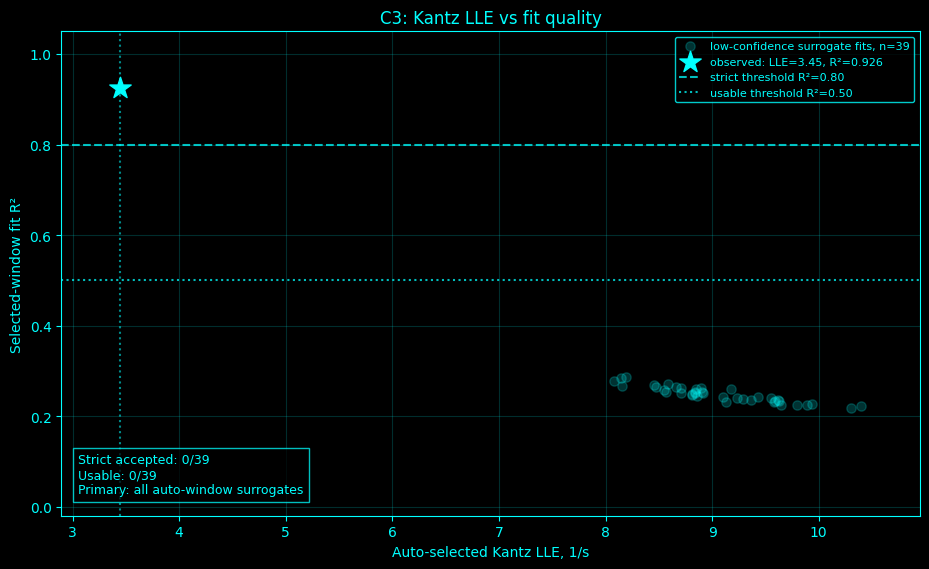

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_surrogate_lle_complete_insightful/plots/01_C3_LLE_vs_fit_quality_C3_m10_tau8_tsep8_K20_nRef2500_nS39_20260915_115958.png


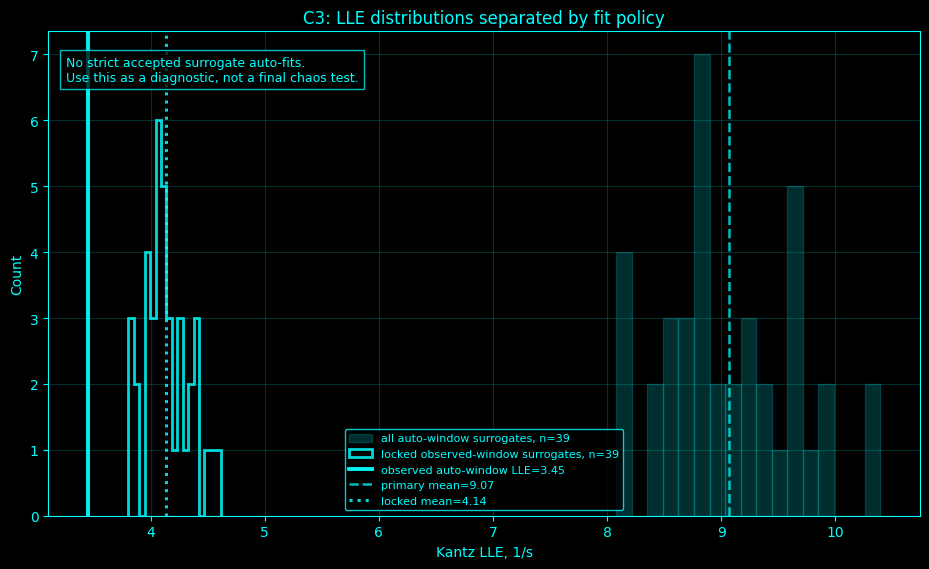

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_surrogate_lle_complete_insightful/plots/02_C3_LLE_distributions_by_policy_C3_m10_tau8_tsep8_K20_nRef2500_nS39_20260915_115958.png


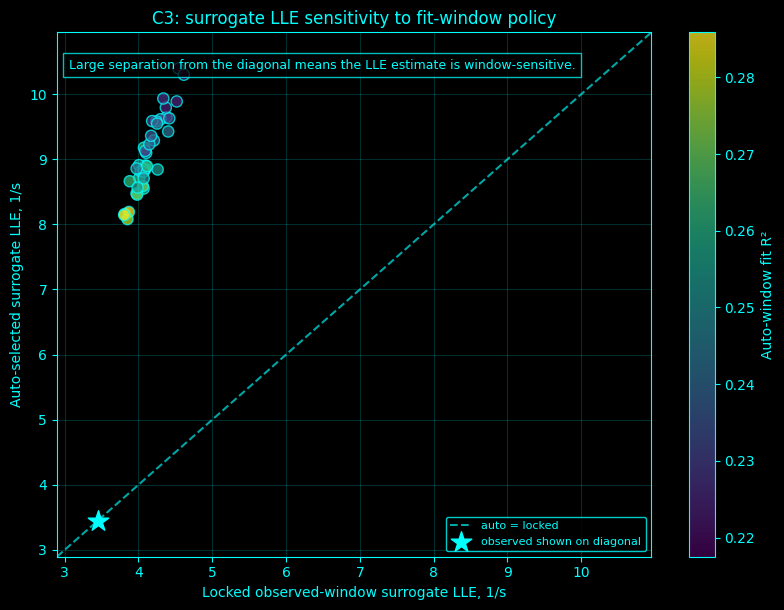

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_surrogate_lle_complete_insightful/plots/03_C3_auto_vs_locked_LLE_C3_m10_tau8_tsep8_K20_nRef2500_nS39_20260915_115958.png


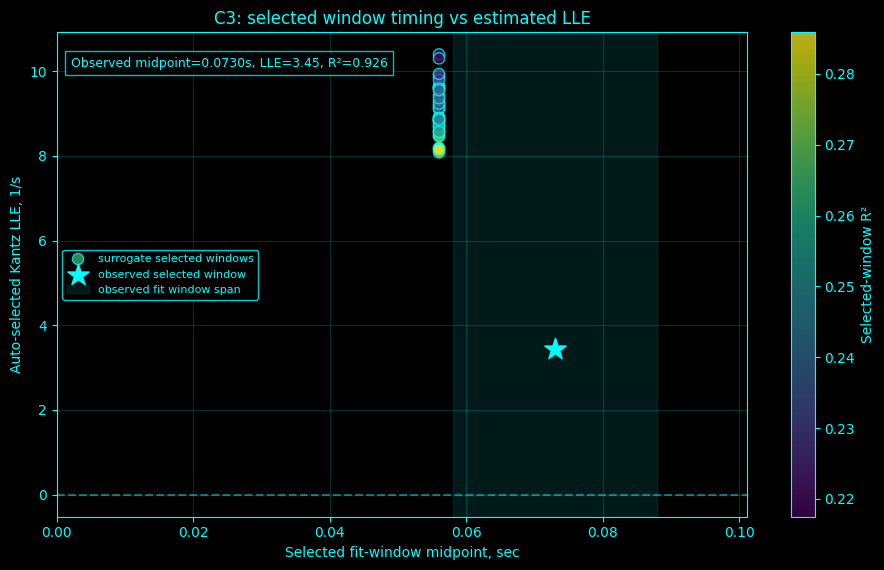

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_surrogate_lle_complete_insightful/plots/04_C3_selected_window_timing_vs_LLE_C3_m10_tau8_tsep8_K20_nRef2500_nS39_20260915_115958.png


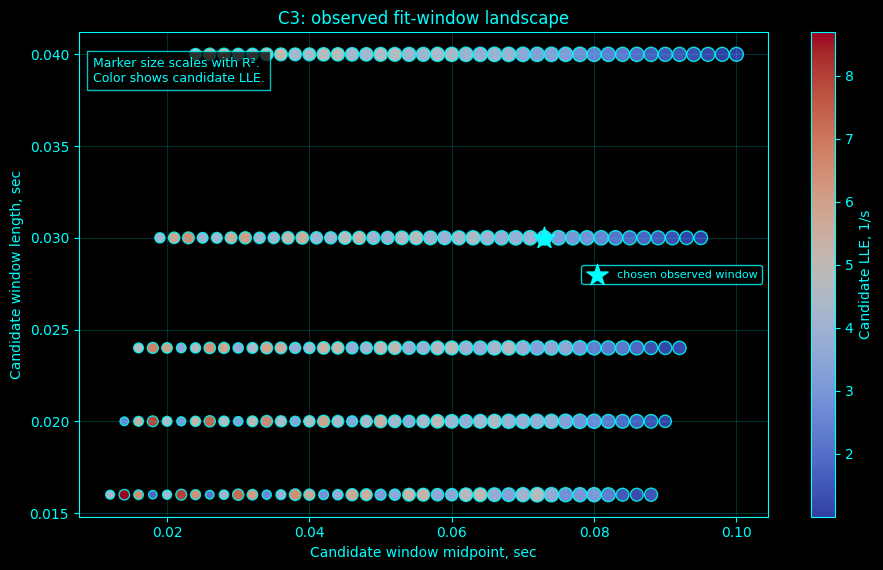

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_surrogate_lle_complete_insightful/plots/05_C3_observed_window_landscape_C3_m10_tau8_tsep8_K20_nRef2500_nS39_20260915_115958.png


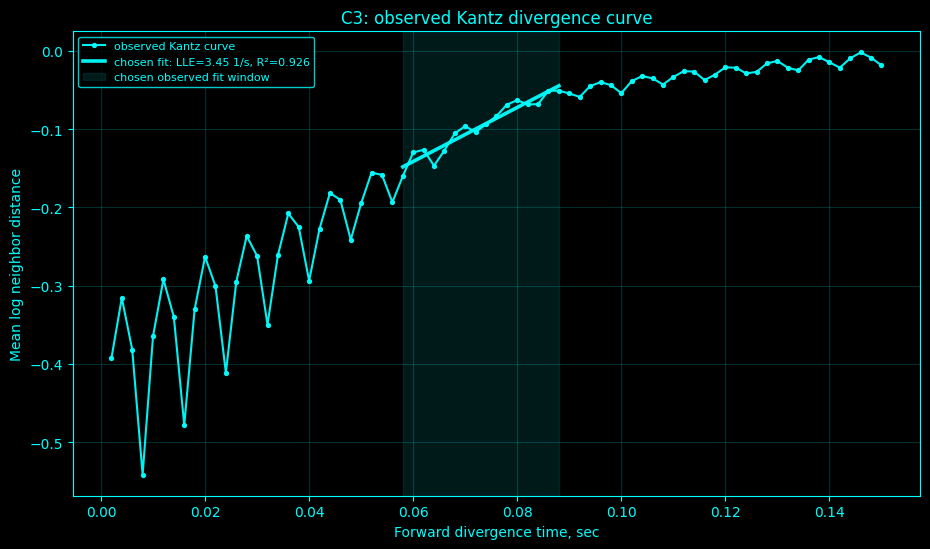

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_surrogate_lle_complete_insightful/plots/06_C3_observed_curve_with_fit_C3_m10_tau8_tsep8_K20_nRef2500_nS39_20260915_115958.png

=== Complete Kantz surrogate LLE summary ===
channel  LLE_obs_auto  fit_r2_obs_auto  fit_rmse_obs_auto  fit_status_obs_auto fit_confidence_obs_auto  fit_k0_obs_auto  fit_k1_obs_auto  fit_k0_seconds_obs_auto  fit_k1_seconds_obs_auto   primary_surrogate_policy                                                                                                               primary_surrogate_warning  primary_surr_mean  primary_surr_std  delta_LLE_primary  z_obs_vs_primary  p_high_primary_surr_ge_obs  p_low_primary_surr_le_obs  p_two_primary_centered  all_auto_surr_mean  all_auto_surr_std  delta_LLE_all_auto  z_obs_vs_all_auto  p_high_all_auto_surr_ge_obs  p_low_all_auto_surr_le_obs  p_two_all_auto_centered  accepted_surr_mean  accepted_surr_std  delta_LLE_accepted  z_obs_vs_accepted  p_high_accepted_

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FC5", "FC1", "FC2", "FC6", "M1", "T7", "C3", "Cz",
    "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6", "P7",
    "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

CHANNELS = ["C3"]

fs_original = 1000.0
start_time = 814.571
end_time = 921.515

start_idx = int(round(start_time * fs_original))
end_idx = int(round(end_time * fs_original))

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
FAST_MODE = FAST_OPTION in {"fast", "ultra"}
ULTRA_FAST_MODE = FAST_OPTION == "ultra"
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

emb_dim = 10
tau_original = 8
min_tsep_original = 8

_KANTZ_SPEED = {
    "full":     dict(kmax=200, n_ref=6000, K_search=400, n_surr=199, iaaft=200, tol=1e-4, min_it=80, check=20, dec=1, max_samples=None, fit_lo_max=120, fit_hi_max=170, fit_lengths=[15,20,25,30,40,50,60]),
    "balanced": dict(kmax=180, n_ref=4200, K_search=250, n_surr=99,  iaaft=140, tol=2e-4, min_it=55, check=15, dec=1, max_samples=45000, fit_lo_max=100, fit_hi_max=150, fit_lengths=[15,20,25,30,40,50]),
    "fast":     dict(kmax=150, n_ref=2500, K_search=120, n_surr=39,  iaaft=80,  tol=5e-4, min_it=30, check=10, dec=2, max_samples=30000, fit_lo_max=80,  fit_hi_max=120, fit_lengths=[15,20,25,30,40]),
    "ultra":    dict(kmax=100, n_ref=1200, K_search=80,  n_surr=19,  iaaft=45,  tol=1e-3, min_it=20, check=10, dec=4, max_samples=15000, fit_lo_max=60,  fit_hi_max=90,  fit_lengths=[15,20,25,30]),
}[FAST_OPTION]
kmax_original = _KANTZ_SPEED["kmax"]
n_ref = _KANTZ_SPEED["n_ref"]
K_use = 20
K_search = _KANTZ_SPEED["K_search"]
n_surrogates = _KANTZ_SPEED["n_surr"]
iaaft_iters = _KANTZ_SPEED["iaaft"]
iaaft_tol = _KANTZ_SPEED["tol"]
iaaft_min_iters = _KANTZ_SPEED["min_it"]
iaaft_check_every = _KANTZ_SPEED["check"]

seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = _KANTZ_SPEED["dec"]
max_samples = _KANTZ_SPEED["max_samples"]

standardize = True
linear_detrend = False

FIT_SEARCH_LO_MIN_ORIGINAL = 3
FIT_SEARCH_LO_MAX_ORIGINAL = _KANTZ_SPEED["fit_lo_max"]
FIT_SEARCH_HI_MAX_ORIGINAL = _KANTZ_SPEED["fit_hi_max"]
FIT_WINDOW_LENGTHS_ORIGINAL = _KANTZ_SPEED["fit_lengths"]

FIT_R2_ACCEPT = 0.80
FIT_R2_USABLE = 0.50
FIT_MONOTONE_FRAC_ACCEPT = 0.60
FIT_SLOPE_CV_ACCEPT = 2.50
FIT_REQUIRE_POSITIVE_SLOPE = True

MIN_VALID_SURROGATES_FOR_PRIMARY = 10

LOCAL_SLOPE_SMOOTH_WINDOW = 7
KANTZ_BATCH_SIZE = 64

MIN_USABLE_REFERENCE_FRACTION = 0.04
MIN_USABLE_REFERENCES_ABSOLUTE = 80

results_dir = os.path.join(
    base_dir,
    "results",
    "kantz_surrogate_lle_complete_insightful"
)

plots_dir = os.path.join(results_dir, "plots")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

tag = (
    f"C3_m{emb_dim}_tau{tau_original}_tsep{min_tsep_original}_"
    f"K{K_use}_nRef{n_ref}_nS{n_surrogates}_{timestamp}"
)

OUT_SUMMARY_CSV = os.path.join(results_dir, f"kantz_complete_summary_{tag}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"kantz_complete_surrogates_{tag}.csv")
OUT_CURVE_CSV = os.path.join(results_dir, f"kantz_complete_curves_{tag}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"kantz_complete_qc_{tag}.csv")
OUT_WINDOW_SCAN_CSV = os.path.join(results_dir, f"kantz_complete_observed_window_scan_{tag}.csv")
OUT_DIAGNOSTIC_CSV = os.path.join(results_dir, f"kantz_complete_diagnostic_comparison_{tag}.csv")
OUT_NPZ = os.path.join(results_dir, f"kantz_complete_arrays_{tag}.npz")
OUT_TXT = os.path.join(results_dir, f"kantz_complete_report_{tag}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})


def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)

        for text in leg.get_texts():
            text.set_color(ACCENT)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=180):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))


def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)

    coef = np.polyfit(t, x, 1)

    return x - np.polyval(coef, t)


def preprocess_signal(
    x,
    fs,
    decimate_factor=1,
    max_samples=None,
    standardize=True,
    detrend=False
):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]

    fs_eff = float(fs)

    if detrend:
        x = linear_detrend_1d(x)

    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]

        fs_eff = fs_eff / float(decimate_factor)

    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]

    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)

    return x.astype(np.float32), fs_eff


def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")

    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")

    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T

    if arr.shape[1] != len(channel_names):
        raise ValueError(
            f"Expected {len(channel_names)} channels, got shape {arr.shape}"
        )

    return arr


def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)

    missing = [ch for ch in CHANNELS if ch not in channel_names]

    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")

    return list(CHANNELS)


def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=np.float32)

    n = len(x)
    M = n - (m - 1) * tau

    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")

    X = np.column_stack([
        x[i * tau:i * tau + M]
        for i in range(m)
    ])

    return X.astype(np.float32)


def fill_nan_linear(y):
    y = np.asarray(y, dtype=float)
    out = y.copy()

    idx = np.arange(len(out))
    good = np.isfinite(out)

    if np.sum(good) == 0:
        return out

    if np.sum(good) == len(out):
        return out

    out[~good] = np.interp(idx[~good], idx[good], out[good])

    return out


def smooth_1d(y, window=7):
    y = fill_nan_linear(y)

    window = int(window)

    if window <= 1:
        return y

    if window % 2 == 0:
        window += 1

    pad = window // 2
    yp = np.pad(y, pad, mode="edge")

    kernel = np.ones(window, dtype=float) / float(window)

    return np.convolve(yp, kernel, mode="valid")


def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))

    return float(
        np.linalg.norm(mag_y - target_mag) /
        (np.linalg.norm(target_mag) + 1e-12)
    )


def iaaft_surrogate_fast(
    x_sorted,
    target_mag,
    n,
    seed,
    n_iter=80,
    tol=5e-4,
    min_iter=30,
    check_every=10
):
    rng = np.random.default_rng(seed)

    y = rng.permutation(x_sorted).astype(np.float32)

    final_err = np.nan
    used_iters = 0

    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))

        y = np.fft.irfft(target_mag * phase, n=n).astype(np.float32)

        ranks = np.argsort(y, kind="quicksort")

        y2 = np.empty_like(y)
        y2[ranks] = x_sorted

        y = y2
        used_iters = it

        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)

            if final_err <= tol:
                break

    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)

    return y.astype(np.float32), final_err, used_iters


def fit_curve_window(ks, y, k0, k1, fs_eff):
    ks = np.asarray(ks, dtype=int)
    y = np.asarray(y, dtype=float)

    k0 = int(k0)
    k1 = int(k1)

    if k1 <= k0 + 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    if k1 > int(np.max(ks)):
        return np.nan, np.nan, np.nan, np.nan, np.nan

    mask = (ks >= k0) & (ks <= k1) & np.isfinite(y)

    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    xw = ks[mask].astype(float)
    yw = y[mask].astype(float)

    coef = np.polyfit(xw, yw, 1)

    yhat = np.polyval(coef, xw)

    ss_res = float(np.sum((yw - yhat) ** 2))
    ss_tot = float(np.sum((yw - np.mean(yw)) ** 2))

    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yw - yhat) ** 2)))

    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)

    return slope_per_sample, intercept, lle_per_second, r2, rmse


def local_slope_curve(ks, y, fs_eff, smooth_window=7):
    ks = np.asarray(ks, dtype=float)

    ys = smooth_1d(y, smooth_window)

    return np.gradient(ys, ks) * fs_eff


def scan_candidate_fit_windows(
    ks,
    y,
    fs_eff,
    lo_min,
    lo_max,
    hi_max,
    lengths
):
    rows = []

    slopes_full = local_slope_curve(
        ks,
        y,
        fs_eff,
        LOCAL_SLOPE_SMOOTH_WINDOW
    )

    for lo in range(int(lo_min), int(lo_max) + 1):
        for length in lengths:
            hi = int(lo + length)

            if hi > hi_max or hi > int(np.max(ks)):
                continue

            slope, intercept, lle, r2, rmse = fit_curve_window(
                ks,
                y,
                lo,
                hi,
                fs_eff
            )

            if not np.isfinite(lle):
                continue

            mask = (ks >= lo) & (ks <= hi)

            local = slopes_full[mask]
            local = local[np.isfinite(local)]

            if len(local) == 0:
                local_mean = np.nan
                local_std = np.nan
                local_cv = np.nan
                monotone_frac = np.nan
            else:
                local_mean = float(np.mean(local))
                local_std = float(np.std(local))
                local_cv = float(local_std / (abs(local_mean) + 1e-12))
                monotone_frac = float(np.mean(local > 0))

            accepted = (
                np.isfinite(r2) and
                np.isfinite(local_cv) and
                np.isfinite(monotone_frac) and
                r2 >= FIT_R2_ACCEPT and
                monotone_frac >= FIT_MONOTONE_FRAC_ACCEPT and
                local_cv <= FIT_SLOPE_CV_ACCEPT and
                ((lle > 0) if FIT_REQUIRE_POSITIVE_SLOPE else True)
            )

            usable = (
                np.isfinite(r2) and
                r2 >= FIT_R2_USABLE and
                ((lle > 0) if FIT_REQUIRE_POSITIVE_SLOPE else True)
            )

            score = (
                1.50 * float(r2)
                + 0.25 * float(monotone_frac if np.isfinite(monotone_frac) else 0.0)
                - 0.08 * float(local_cv if np.isfinite(local_cv) else 10.0)
                - 0.02 * float(rmse if np.isfinite(rmse) else 10.0)
                - 0.0015 * float(lo)
            )

            if FIT_REQUIRE_POSITIVE_SLOPE and lle <= 0:
                score -= 2.0

            rows.append({
                "fit_lo": int(lo),
                "fit_hi": int(hi),
                "fit_mid": float(0.5 * (lo + hi)),
                "fit_length": int(hi - lo),
                "slope_per_sample": float(slope),
                "LLE": float(lle),
                "intercept": float(intercept),
                "fit_r2": float(r2),
                "fit_rmse": float(rmse),
                "local_slope_mean": float(local_mean),
                "local_slope_std": float(local_std),
                "local_slope_cv": float(local_cv),
                "monotone_fraction": float(monotone_frac),
                "accepted": bool(accepted),
                "usable": bool(usable),
                "score": float(score),
            })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise RuntimeError("No candidate fit windows could be evaluated.")

    return df.sort_values("score", ascending=False).reset_index(drop=True)


def choose_fit_window(scan_df):
    df = scan_df.copy()

    accepted = df[df["accepted"] == True].copy()

    if len(accepted) > 0:
        chosen = accepted.sort_values(
            ["score", "fit_lo"],
            ascending=[False, True]
        ).iloc[0].to_dict()

        status = "accepted_auto_window"

    else:
        usable = df[df["usable"] == True].copy()

        if len(usable) > 0:
            chosen = usable.sort_values(
                ["score", "fit_lo"],
                ascending=[False, True]
            ).iloc[0].to_dict()

            status = "usable_but_not_strict_auto_window"

        elif FIT_REQUIRE_POSITIVE_SLOPE and np.any(df["LLE"] > 0):
            chosen = df[df["LLE"] > 0].sort_values(
                "score",
                ascending=False
            ).iloc[0].to_dict()

            status = "low_confidence_best_positive_window"

        else:
            chosen = df.sort_values("score", ascending=False).iloc[0].to_dict()

            status = "low_confidence_best_available_window"

    chosen["fit_status"] = status

    return chosen


def auto_fit_kantz_curve(
    ks,
    y,
    fs_eff,
    lo_min,
    lo_max,
    hi_max,
    lengths
):
    scan_df = scan_candidate_fit_windows(
        ks,
        y,
        fs_eff,
        lo_min=lo_min,
        lo_max=lo_max,
        hi_max=hi_max,
        lengths=lengths
    )

    selected = choose_fit_window(scan_df)

    fit_lo = int(selected["fit_lo"])
    fit_hi = int(selected["fit_hi"])

    slope, intercept, lle, r2, rmse = fit_curve_window(
        ks,
        y,
        fit_lo,
        fit_hi,
        fs_eff
    )

    selected["fit_lo"] = fit_lo
    selected["fit_hi"] = fit_hi
    selected["slope_per_sample"] = float(slope)
    selected["intercept"] = float(intercept)
    selected["LLE"] = float(lle)
    selected["fit_r2"] = float(r2)
    selected["fit_rmse"] = float(rmse)

    return selected, scan_df


def kantz_curve_fixed_refs(
    x,
    m,
    tau,
    min_tsep,
    kmax,
    n_ref,
    K_use=20,
    K_search=120,
    rng=None,
    ref_idx=None,
    batch_size=64
):
    if rng is None:
        rng = np.random.default_rng()

    X = delay_embed_1d(x, m=m, tau=tau)

    M = len(X)
    kmax_eff = min(int(kmax), M - 2)

    if kmax_eff < 5:
        raise ValueError(
            f"kmax too large for embedded length: M={M}, kmax_eff={kmax_eff}"
        )

    last_ok = M - 1 - kmax_eff

    if last_ok <= 0:
        raise ValueError(
            f"Not enough points for kmax_eff={kmax_eff} with M={M}"
        )

    valid = np.arange(0, last_ok + 1)

    if ref_idx is None:
        n_ref_eff = min(int(n_ref), len(valid))
        ref_idx = np.sort(
            rng.choice(valid, size=n_ref_eff, replace=False)
        )
    else:
        ref_idx = np.asarray(ref_idx, dtype=int)
        ref_idx = np.sort(ref_idx[(ref_idx >= 0) & (ref_idx <= last_ok)])
        n_ref_eff = len(ref_idx)

    K_search_eff = min(int(K_search), M)
    K_search_eff = max(
        K_search_eff,
        K_use + min_tsep + 20,
        K_use + 20
    )
    K_search_eff = min(K_search_eff, M)

    nn = NearestNeighbors(
        n_neighbors=K_search_eff,
        algorithm="auto",
        n_jobs=1
    ).fit(X)

    _, inds = nn.kneighbors(X[ref_idx], return_distance=True)

    ref_keep = []
    neigh_keep = []

    for row, i in enumerate(ref_idx):
        cand = inds[row]
        cand = cand[cand != i]

        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > int(min_tsep)]

        cand = cand[cand <= last_ok]

        if len(cand) < K_use:
            continue

        ref_keep.append(int(i))
        neigh_keep.append(cand[:K_use].astype(int))

    min_required = max(
        MIN_USABLE_REFERENCES_ABSOLUTE,
        int(MIN_USABLE_REFERENCE_FRACTION * max(n_ref_eff, 1))
    )

    if len(ref_keep) < min_required:
        raise RuntimeError(
            f"Too few usable refs after filtering: {len(ref_keep)} of {n_ref_eff}."
        )

    ref_keep = np.asarray(ref_keep, dtype=int)
    neigh_keep = np.asarray(neigh_keep, dtype=int)

    ks = np.arange(1, kmax_eff + 1, dtype=int)

    y_acc = np.zeros(len(ks), dtype=float)
    counts = np.zeros(len(ks), dtype=int)

    eps = 1e-12

    for start in range(0, len(ref_keep), batch_size):
        stop = min(start + batch_size, len(ref_keep))

        rb = ref_keep[start:stop]
        nb = neigh_keep[start:stop]

        Xi = X[rb[:, None] + ks[None, :]]
        Xj = X[nb[:, :, None] + ks[None, None, :]]

        dist = np.linalg.norm(Xj - Xi[:, None, :, :], axis=3)

        log_mean = np.mean(np.log(dist + eps), axis=1)

        y_acc += np.sum(log_mean, axis=0)
        counts += log_mean.shape[0]

    y_mean = y_acc / np.maximum(counts, 1)

    info = {
        "M": int(M),
        "last_ok": int(last_ok),
        "kmax_eff": int(kmax_eff),
        "n_ref_requested": int(n_ref_eff),
        "n_ref_used": int(len(ref_keep)),
        "K_use": int(K_use),
        "K_search": int(K_search_eff),
        "min_tsep": int(min_tsep),
        "m": int(m),
        "tau": int(tau),
    }

    return ks, y_mean, counts, info, ref_idx


def empirical_p_values(obs, vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    delta = float(obs - mean)
    z = float((obs - mean) / (std + 1e-12))

    p_high = float((np.sum(vals >= obs) + 1.0) / (len(vals) + 1.0))
    p_low = float((np.sum(vals <= obs) + 1.0) / (len(vals) + 1.0))

    p_two_centered = float(
        (np.sum(np.abs(vals - mean) >= abs(obs - mean)) + 1.0) /
        (len(vals) + 1.0)
    )

    return mean, std, delta, z, p_high, p_low, p_two_centered


tau_eff = effective_sample_param(
    tau_original,
    decimate_factor,
    minimum=1
)

min_tsep_eff = effective_sample_param(
    min_tsep_original,
    decimate_factor,
    minimum=1
)

kmax_eff_target = effective_sample_param(
    kmax_original,
    decimate_factor,
    minimum=20
)

fit_search_lo_min_eff = effective_sample_param(
    FIT_SEARCH_LO_MIN_ORIGINAL,
    decimate_factor,
    minimum=1
)

fit_search_lo_max_eff = effective_sample_param(
    FIT_SEARCH_LO_MAX_ORIGINAL,
    decimate_factor,
    minimum=fit_search_lo_min_eff + 5
)

fit_search_hi_max_eff = effective_sample_param(
    FIT_SEARCH_HI_MAX_ORIGINAL,
    decimate_factor,
    minimum=fit_search_lo_max_eff + 5
)

fit_window_lengths_eff = sorted(set([
    effective_sample_param(v, decimate_factor, minimum=5)
    for v in FIT_WINDOW_LENGTHS_ORIGINAL
]))

print("Effective parameters:")
print("  FAST_MODE:", FAST_MODE)
print("  decimate_factor:", decimate_factor)
print("  max_samples:", max_samples)
print("  tau_eff:", tau_eff)
print("  min_tsep_eff:", min_tsep_eff)
print("  kmax_eff_target:", kmax_eff_target)
print("  n_ref:", n_ref)
print("  K_search:", K_search)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)
print("  comparison policy: observed and surrogates each get independent auto-selected windows")
print("  locked-window diagnostics are also computed for comparison")


EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)


summary_records = []
surrogate_records = []
curve_records = []
qc_records = []
window_scan_records = []
diagnostic_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "tau_eff": np.array([tau_eff], dtype=int),
    "min_tsep_eff": np.array([min_tsep_eff], dtype=int),
    "kmax_eff_target": np.array([kmax_eff_target], dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([decimate_factor], dtype=int),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
}

run_start = time.time()


for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)

    ch_i = channel_names.index(channel)
    x_raw = EEG[start_idx:end_idx, ch_i].astype(float)

    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )

    print(
        f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | "
        f"segment=[{start_time},{end_time}] s",
        flush=True
    )

    rng_obs = np.random.default_rng(seed)

    ks_obs, y_obs, counts_obs, info_obs, shared_ref_idx = kantz_curve_fixed_refs(
        x,
        m=emb_dim,
        tau=tau_eff,
        min_tsep=min_tsep_eff,
        kmax=kmax_eff_target,
        n_ref=n_ref,
        K_use=K_use,
        K_search=K_search,
        rng=rng_obs,
        ref_idx=None,
        batch_size=KANTZ_BATCH_SIZE
    )

    kmax_actual = int(np.max(ks_obs))

    fit_search_lo_max_local = min(fit_search_lo_max_eff, kmax_actual - 6)
    fit_search_hi_max_local = min(fit_search_hi_max_eff, kmax_actual)

    selected_obs, scan_df = auto_fit_kantz_curve(
        ks_obs,
        y_obs,
        fs_eff,
        lo_min=fit_search_lo_min_eff,
        lo_max=fit_search_lo_max_local,
        hi_max=fit_search_hi_max_local,
        lengths=fit_window_lengths_eff
    )

    fit_k0_obs = int(selected_obs["fit_lo"])
    fit_k1_obs = int(selected_obs["fit_hi"])

    slope_obs = float(selected_obs["slope_per_sample"])
    intercept_obs = float(selected_obs["intercept"])
    lle_obs = float(selected_obs["LLE"])
    r2_obs = float(selected_obs["fit_r2"])
    rmse_obs = float(selected_obs["fit_rmse"])
    fit_status_obs = str(selected_obs["fit_status"])

    if fit_status_obs == "accepted_auto_window":
        fit_confidence_obs = "OK_STRICT"
    elif fit_status_obs == "usable_but_not_strict_auto_window":
        fit_confidence_obs = "USABLE_BUT_NOT_STRICT"
    else:
        fit_confidence_obs = "LOW_CONFIDENCE_NO_ACCEPTABLE_LINEAR_WINDOW"

    print("\n=== Observed Kantz LLE ===")
    print(f"auto-window status={fit_status_obs}")
    print(f"fit window k=[{fit_k0_obs},{fit_k1_obs}] samples")
    print(f"fit window sec=[{fit_k0_obs / fs_eff:.4f},{fit_k1_obs / fs_eff:.4f}]")
    print(f"LLE={lle_obs:.6f} 1/s")
    print(f"fit R²={r2_obs:.4f} | RMSE={rmse_obs:.4g}")
    print(f"fit confidence={fit_confidence_obs}")
    print(f"refs used={info_obs['n_ref_used']} / {info_obs['n_ref_requested']}")

    scan_df = scan_df.copy()
    scan_df.insert(0, "channel", channel)

    for _, row in scan_df.iterrows():
        window_scan_records.append(row.to_dict())

    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)

    surrogate_lle_auto = []
    surrogate_lle_auto_accepted = []
    surrogate_lle_auto_usable = []
    surrogate_lle_locked = []

    surrogate_r2_auto = []
    surrogate_r2_auto_accepted = []
    surrogate_r2_auto_usable = []
    surrogate_r2_locked = []

    surr_errors = []
    surr_iters = []

    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 10000 * ch_num + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )

        ks_s, y_s, counts_s, info_s, _ = kantz_curve_fixed_refs(
            y,
            m=emb_dim,
            tau=tau_eff,
            min_tsep=min_tsep_eff,
            kmax=kmax_eff_target,
            n_ref=n_ref,
            K_use=K_use,
            K_search=K_search,
            rng=np.random.default_rng(seed + 1000 + s),
            ref_idx=shared_ref_idx,
            batch_size=KANTZ_BATCH_SIZE
        )

        selected_s, _ = auto_fit_kantz_curve(
            ks_s,
            y_s,
            fs_eff,
            lo_min=fit_search_lo_min_eff,
            lo_max=fit_search_lo_max_local,
            hi_max=fit_search_hi_max_local,
            lengths=fit_window_lengths_eff
        )

        locked_slope, locked_intercept, locked_lle, locked_r2, locked_rmse = fit_curve_window(
            ks_s,
            y_s,
            fit_k0_obs,
            fit_k1_obs,
            fs_eff
        )

        return {
            "surrogate_index": int(s + 1),
            "iaaft_error": float(final_err),
            "iaaft_iters_used": int(used_iters),
            "n_ref_used": int(info_s["n_ref_used"]),
            "n_ref_requested": int(info_s["n_ref_requested"]),
            "embedded_M": int(info_s["M"]),
            "last_ok": int(info_s["last_ok"]),
            "kmax_eff": int(info_s["kmax_eff"]),
            "auto_fit_status": str(selected_s["fit_status"]),
            "auto_fit_accepted": bool(selected_s["fit_status"] == "accepted_auto_window"),
            "auto_fit_usable": bool(selected_s["fit_status"] in ["accepted_auto_window", "usable_but_not_strict_auto_window"]),
            "auto_fit_lo": int(selected_s["fit_lo"]),
            "auto_fit_hi": int(selected_s["fit_hi"]),
            "auto_LLE": float(selected_s["LLE"]),
            "auto_slope_per_sample": float(selected_s["slope_per_sample"]),
            "auto_intercept": float(selected_s["intercept"]),
            "auto_fit_r2": float(selected_s["fit_r2"]),
            "auto_fit_rmse": float(selected_s["fit_rmse"]),
            "auto_monotone_fraction": float(selected_s["monotone_fraction"]),
            "auto_local_slope_cv": float(selected_s["local_slope_cv"]),
            "locked_fit_lo": int(fit_k0_obs),
            "locked_fit_hi": int(fit_k1_obs),
            "locked_LLE": float(locked_lle),
            "locked_slope_per_sample": float(locked_slope),
            "locked_intercept": float(locked_intercept),
            "locked_fit_r2": float(locked_r2),
            "locked_fit_rmse": float(locked_rmse),
        }

    print(
        f"\nGenerating {n_surrogates} IAAFT surrogates + fair auto-window Kantz LLE "
        f"with {n_workers} workers...",
        flush=True
    )

    completed = 0
    failed = 0

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [
            executor.submit(surrogate_worker, s)
            for s in range(n_surrogates)
        ]

        for fut in as_completed(futures):
            try:
                res = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue

            completed += 1

            surr_errors.append(res["iaaft_error"])
            surr_iters.append(res["iaaft_iters_used"])

            if np.isfinite(res["auto_LLE"]):
                surrogate_lle_auto.append(res["auto_LLE"])
                surrogate_r2_auto.append(res["auto_fit_r2"])

                if res["auto_fit_accepted"]:
                    surrogate_lle_auto_accepted.append(res["auto_LLE"])
                    surrogate_r2_auto_accepted.append(res["auto_fit_r2"])

                if res["auto_fit_usable"]:
                    surrogate_lle_auto_usable.append(res["auto_LLE"])
                    surrogate_r2_auto_usable.append(res["auto_fit_r2"])

            if np.isfinite(res["locked_LLE"]):
                surrogate_lle_locked.append(res["locked_LLE"])
                surrogate_r2_locked.append(res["locked_fit_r2"])

            surrogate_records.append({
                "channel": channel,
                **res
            })

            if completed % 10 == 0 or completed + failed == n_surrogates:
                print(
                    f"  completed {completed}/{n_surrogates} surrogates | "
                    f"failed={failed}",
                    flush=True
                )

    surrogate_lle_auto = np.asarray(surrogate_lle_auto, dtype=float)
    surrogate_lle_auto = surrogate_lle_auto[np.isfinite(surrogate_lle_auto)]

    surrogate_lle_auto_accepted = np.asarray(surrogate_lle_auto_accepted, dtype=float)
    surrogate_lle_auto_accepted = surrogate_lle_auto_accepted[np.isfinite(surrogate_lle_auto_accepted)]

    surrogate_lle_auto_usable = np.asarray(surrogate_lle_auto_usable, dtype=float)
    surrogate_lle_auto_usable = surrogate_lle_auto_usable[np.isfinite(surrogate_lle_auto_usable)]

    surrogate_lle_locked = np.asarray(surrogate_lle_locked, dtype=float)
    surrogate_lle_locked = surrogate_lle_locked[np.isfinite(surrogate_lle_locked)]

    surrogate_r2_auto = np.asarray(surrogate_r2_auto, dtype=float)
    surrogate_r2_auto_accepted = np.asarray(surrogate_r2_auto_accepted, dtype=float)
    surrogate_r2_auto_usable = np.asarray(surrogate_r2_auto_usable, dtype=float)
    surrogate_r2_locked = np.asarray(surrogate_r2_locked, dtype=float)

    if len(surrogate_lle_auto_accepted) >= MIN_VALID_SURROGATES_FOR_PRIMARY:
        primary_surr = surrogate_lle_auto_accepted.copy()
        primary_label = "strict accepted auto-window surrogates"
        primary_warning = ""
    elif len(surrogate_lle_auto_usable) >= MIN_VALID_SURROGATES_FOR_PRIMARY:
        primary_surr = surrogate_lle_auto_usable.copy()
        primary_label = "usable auto-window surrogates"
        primary_warning = (
            f"LOW_CONFIDENCE_STRICT_SURROGATE_FITS: only "
            f"{len(surrogate_lle_auto_accepted)} strict accepted surrogates; "
            f"using {len(surrogate_lle_auto_usable)} usable surrogates"
        )
    else:
        primary_surr = surrogate_lle_auto.copy()
        primary_label = "all auto-window surrogates"
        primary_warning = (
            f"LOW_CONFIDENCE_SURROGATE_FITS: only "
            f"{len(surrogate_lle_auto_accepted)} strict accepted and "
            f"{len(surrogate_lle_auto_usable)} usable surrogates; "
            f"using all {len(surrogate_lle_auto)} auto-window surrogates for diagnostics only"
        )

    primary_mean, primary_std, delta_primary, z_primary, p_high_primary, p_low_primary, p_two_primary = empirical_p_values(
        lle_obs,
        primary_surr
    )

    auto_mean, auto_std, auto_delta, auto_z, auto_p_high, auto_p_low, auto_p_two = empirical_p_values(
        lle_obs,
        surrogate_lle_auto
    )

    acc_mean, acc_std, acc_delta, acc_z, acc_p_high, acc_p_low, acc_p_two = empirical_p_values(
        lle_obs,
        surrogate_lle_auto_accepted
    )

    usable_mean, usable_std, usable_delta, usable_z, usable_p_high, usable_p_low, usable_p_two = empirical_p_values(
        lle_obs,
        surrogate_lle_auto_usable
    )

    locked_mean, locked_std, locked_delta, locked_z, locked_p_high, locked_p_low, locked_p_two = empirical_p_values(
        lle_obs,
        surrogate_lle_locked
    )

    n_auto_total = int(len(surrogate_lle_auto))
    n_auto_accepted = int(len(surrogate_lle_auto_accepted))
    n_auto_usable = int(len(surrogate_lle_auto_usable))
    n_locked_total = int(len(surrogate_lle_locked))

    diagnostic_rows_channel = [
        {
            "channel": channel,
            "distribution": "all_auto_surrogate_windows",
            "n": n_auto_total,
            "mean": auto_mean,
            "std": auto_std,
            "observed_minus_mean": auto_delta,
            "z": auto_z,
            "p_high_surr_ge_obs": auto_p_high,
            "p_low_surr_le_obs": auto_p_low,
            "p_two_centered": auto_p_two,
        },
        {
            "channel": channel,
            "distribution": "strict_accepted_auto_surrogate_windows",
            "n": n_auto_accepted,
            "mean": acc_mean,
            "std": acc_std,
            "observed_minus_mean": acc_delta,
            "z": acc_z,
            "p_high_surr_ge_obs": acc_p_high,
            "p_low_surr_le_obs": acc_p_low,
            "p_two_centered": acc_p_two,
        },
        {
            "channel": channel,
            "distribution": "usable_auto_surrogate_windows",
            "n": n_auto_usable,
            "mean": usable_mean,
            "std": usable_std,
            "observed_minus_mean": usable_delta,
            "z": usable_z,
            "p_high_surr_ge_obs": usable_p_high,
            "p_low_surr_le_obs": usable_p_low,
            "p_two_centered": usable_p_two,
        },
        {
            "channel": channel,
            "distribution": "locked_observed_window_surrogates",
            "n": n_locked_total,
            "mean": locked_mean,
            "std": locked_std,
            "observed_minus_mean": locked_delta,
            "z": locked_z,
            "p_high_surr_ge_obs": locked_p_high,
            "p_low_surr_le_obs": locked_p_low,
            "p_two_centered": locked_p_two,
        },
    ]

    diagnostic_records.extend(diagnostic_rows_channel)

    print("\n=== Fair surrogate test: Kantz LLE ===")
    print(f"Observed auto-window LLE: {lle_obs:.6f} 1/s")
    print(f"Observed fit status: {fit_status_obs}, R²={r2_obs:.4f}")
    print(f"Primary surrogate distribution: {primary_label}")
    print(f"Primary warning: {primary_warning}")
    print(f"Strict accepted surrogate fits: {n_auto_accepted}/{n_auto_total}")
    print(f"Usable surrogate fits: {n_auto_usable}/{n_auto_total}")
    print(f"Primary surrogate mean±std: {primary_mean:.6f} ± {primary_std:.6f} 1/s")
    print(f"Observed minus primary surrogate mean: {delta_primary:.6f} 1/s")
    print(f"Primary high-tail p=P(surr >= obs): {p_high_primary:.6g}")
    print(f"Primary low-tail  p=P(surr <= obs): {p_low_primary:.6g}")
    print(f"Primary two-sided centered p: {p_two_primary:.6g}")
    print(f"Locked-window surrogate mean±std: {locked_mean:.6f} ± {locked_std:.6f} 1/s")
    print(f"Locked-window high-tail p: {locked_p_high:.6g}")
    print(f"Locked-window low-tail p: {locked_p_low:.6g}")

    summary_records.append({
        "channel": channel,
        "LLE_obs_auto": float(lle_obs),
        "fit_r2_obs_auto": float(r2_obs),
        "fit_rmse_obs_auto": float(rmse_obs),
        "fit_status_obs_auto": fit_status_obs,
        "fit_confidence_obs_auto": fit_confidence_obs,
        "fit_k0_obs_auto": int(fit_k0_obs),
        "fit_k1_obs_auto": int(fit_k1_obs),
        "fit_k0_seconds_obs_auto": float(fit_k0_obs / fs_eff),
        "fit_k1_seconds_obs_auto": float(fit_k1_obs / fs_eff),
        "primary_surrogate_policy": primary_label,
        "primary_surrogate_warning": primary_warning,
        "primary_surr_mean": primary_mean,
        "primary_surr_std": primary_std,
        "delta_LLE_primary": delta_primary,
        "z_obs_vs_primary": float(z_primary),
        "p_high_primary_surr_ge_obs": float(p_high_primary),
        "p_low_primary_surr_le_obs": float(p_low_primary),
        "p_two_primary_centered": float(p_two_primary),
        "all_auto_surr_mean": auto_mean,
        "all_auto_surr_std": auto_std,
        "delta_LLE_all_auto": auto_delta,
        "z_obs_vs_all_auto": auto_z,
        "p_high_all_auto_surr_ge_obs": auto_p_high,
        "p_low_all_auto_surr_le_obs": auto_p_low,
        "p_two_all_auto_centered": auto_p_two,
        "accepted_surr_mean": acc_mean,
        "accepted_surr_std": acc_std,
        "delta_LLE_accepted": acc_delta,
        "z_obs_vs_accepted": acc_z,
        "p_high_accepted_surr_ge_obs": acc_p_high,
        "p_low_accepted_surr_le_obs": acc_p_low,
        "p_two_accepted_centered": acc_p_two,
        "usable_surr_mean": usable_mean,
        "usable_surr_std": usable_std,
        "delta_LLE_usable": usable_delta,
        "z_obs_vs_usable": usable_z,
        "p_high_usable_surr_ge_obs": usable_p_high,
        "p_low_usable_surr_le_obs": usable_p_low,
        "p_two_usable_centered": usable_p_two,
        "locked_surr_mean": locked_mean,
        "locked_surr_std": locked_std,
        "delta_LLE_locked": locked_delta,
        "z_obs_vs_locked": float(locked_z),
        "p_high_locked_surr_ge_obs": float(locked_p_high),
        "p_low_locked_surr_le_obs": float(locked_p_low),
        "p_two_locked_centered": float(locked_p_two),
        "n_surrogates_requested": int(n_surrogates),
        "n_surrogates_completed": int(completed),
        "n_surrogates_failed": int(failed),
        "n_auto_surrogates_total": n_auto_total,
        "n_auto_surrogates_strict_accepted": n_auto_accepted,
        "n_auto_surrogates_usable": n_auto_usable,
        "n_locked_surrogates_total": n_locked_total,
        "auto_surrogate_fit_r2_mean_all": float(np.nanmean(surrogate_r2_auto)) if len(surrogate_r2_auto) else np.nan,
        "auto_surrogate_fit_r2_mean_accepted": float(np.nanmean(surrogate_r2_auto_accepted)) if len(surrogate_r2_auto_accepted) else np.nan,
        "auto_surrogate_fit_r2_mean_usable": float(np.nanmean(surrogate_r2_auto_usable)) if len(surrogate_r2_auto_usable) else np.nan,
        "locked_surrogate_fit_r2_mean": float(np.nanmean(surrogate_r2_locked)) if len(surrogate_r2_locked) else np.nan,
        "fs_eff": float(fs_eff),
        "emb_dim": int(emb_dim),
        "tau_eff": int(tau_eff),
        "min_tsep_eff": int(min_tsep_eff),
        "kmax_eff": int(info_obs["kmax_eff"]),
        "n_ref_used_obs": int(info_obs["n_ref_used"]),
        "n_ref_requested_obs": int(info_obs["n_ref_requested"]),
        "K_use": int(K_use),
        "K_search": int(info_obs["K_search"]),
        "embedded_M": int(info_obs["M"]),
        "last_ok": int(info_obs["last_ok"]),
        "FAST_MODE": bool(FAST_MODE),
    })

    for i, k in enumerate(ks_obs):
        curve_records.append({
            "channel": channel,
            "k": int(k),
            "time_seconds": float(k / fs_eff),
            "observed_mean_log_distance": float(y_obs[i]),
            "observed_count": int(counts_obs[i]),
        })

    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
        "max_iaaft_iters_used": int(np.max(surr_iters)) if len(surr_iters) else -1,
        "surrogates_completed": int(completed),
        "surrogates_failed": int(failed),
    })

    npz_payload[f"{channel}_ks"] = ks_obs
    npz_payload[f"{channel}_y_obs"] = y_obs
    npz_payload[f"{channel}_counts_obs"] = counts_obs
    npz_payload[f"{channel}_surrogate_lle_auto_all"] = surrogate_lle_auto
    npz_payload[f"{channel}_surrogate_lle_auto_strict_accepted"] = surrogate_lle_auto_accepted
    npz_payload[f"{channel}_surrogate_lle_auto_usable"] = surrogate_lle_auto_usable
    npz_payload[f"{channel}_surrogate_lle_locked"] = surrogate_lle_locked

    scan_numeric_df = scan_df.select_dtypes(include=[np.number]).copy()

    npz_payload[f"{channel}_window_scan_numeric"] = scan_numeric_df.to_numpy(dtype=float)
    npz_payload[f"{channel}_window_scan_numeric_columns"] = np.array(
        scan_numeric_df.columns.astype(str),
        dtype=object
    )
    npz_payload[f"{channel}_window_scan_json"] = np.array(
        [scan_df.to_json(orient="records")],
        dtype=object
    )

    surr_df_tmp = pd.DataFrame(surrogate_records)
    surr_df_tmp = surr_df_tmp[surr_df_tmp["channel"] == channel].copy()

    valid_auto_df = surr_df_tmp[
        np.isfinite(surr_df_tmp["auto_LLE"]) &
        np.isfinite(surr_df_tmp["auto_fit_r2"])
    ].copy()

    strict_df = valid_auto_df[valid_auto_df["auto_fit_accepted"] == True].copy()
    usable_df = valid_auto_df[valid_auto_df["auto_fit_usable"] == True].copy()
    rejected_df = valid_auto_df[valid_auto_df["auto_fit_usable"] == False].copy()

    valid_locked_df = surr_df_tmp[
        np.isfinite(surr_df_tmp["locked_LLE"]) &
        np.isfinite(surr_df_tmp["locked_fit_r2"])
    ].copy()

    obs_mid = 0.5 * (fit_k0_obs + fit_k1_obs) / fs_eff

    fig, ax = plt.subplots(figsize=(9.4, 5.8), facecolor=BG)
    style_ax(ax)

    if len(rejected_df) > 0:
        ax.scatter(
            rejected_df["auto_LLE"],
            rejected_df["auto_fit_r2"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=45,
            alpha=0.20,
            label=f"low-confidence surrogate fits, n={len(rejected_df)}"
        )

    non_strict_usable_df = usable_df[usable_df["auto_fit_accepted"] == False].copy()

    if len(non_strict_usable_df) > 0:
        ax.scatter(
            non_strict_usable_df["auto_LLE"],
            non_strict_usable_df["auto_fit_r2"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=60,
            alpha=0.45,
            label=f"usable surrogate fits, n={len(non_strict_usable_df)}"
        )

    if len(strict_df) > 0:
        ax.scatter(
            strict_df["auto_LLE"],
            strict_df["auto_fit_r2"],
            color=ACCENT,
            edgecolor=ACCENT,
            s=80,
            alpha=0.80,
            label=f"strict accepted surrogate fits, n={len(strict_df)}"
        )

    ax.scatter(
        [lle_obs],
        [r2_obs],
        color=ACCENT,
        edgecolor=ACCENT,
        s=260,
        marker="*",
        label=f"observed: LLE={lle_obs:.3g}, R²={r2_obs:.3f}"
    )

    ax.axhline(
        FIT_R2_ACCEPT,
        color=ACCENT,
        linestyle="--",
        alpha=0.75,
        label=f"strict threshold R²={FIT_R2_ACCEPT:.2f}"
    )

    ax.axhline(
        FIT_R2_USABLE,
        color=ACCENT,
        linestyle=":",
        alpha=0.75,
        label=f"usable threshold R²={FIT_R2_USABLE:.2f}"
    )

    ax.axvline(
        lle_obs,
        color=ACCENT,
        linestyle=":",
        alpha=0.55
    )

    ax.set_title(f"{channel}: Kantz LLE vs fit quality")
    ax.set_xlabel("Auto-selected Kantz LLE, 1/s")
    ax.set_ylabel("Selected-window fit R²")
    ax.set_ylim(-0.02, 1.05)

    if len(valid_auto_df) > 0:
        xmin = min(float(valid_auto_df["auto_LLE"].min()), lle_obs)
        xmax = max(float(valid_auto_df["auto_LLE"].max()), lle_obs)
        pad = 0.08 * max(abs(xmax - xmin), 1.0)
        ax.set_xlim(xmin - pad, xmax + pad)

    note = (
        f"Strict accepted: {len(strict_df)}/{len(valid_auto_df)}\n"
        f"Usable: {len(usable_df)}/{len(valid_auto_df)}\n"
        f"Primary: {primary_label}"
    )

    ax.text(
        0.02,
        0.04,
        note,
        transform=ax.transAxes,
        color=ACCENT,
        ha="left",
        va="bottom",
        fontsize=9,
        bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
    )

    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)

    save_show_close(
        fig,
        os.path.join(plots_dir, f"01_{channel}_LLE_vs_fit_quality_{tag}.png")
    )

    fig, ax = plt.subplots(figsize=(9.4, 5.8), facecolor=BG)
    style_ax(ax)

    bins_source = []

    if len(surrogate_lle_auto) > 0:
        bins_source.extend(surrogate_lle_auto)

    if len(surrogate_lle_locked) > 0:
        bins_source.extend(surrogate_lle_locked)

    bins_source = np.asarray(bins_source, dtype=float)
    bins_source = bins_source[np.isfinite(bins_source)]

    bins = min(28, max(10, int(np.sqrt(max(len(bins_source), 1)) * 2)))

    if len(surrogate_lle_auto) > 0:
        ax.hist(
            surrogate_lle_auto,
            bins=bins,
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.18,
            label=f"all auto-window surrogates, n={len(surrogate_lle_auto)}"
        )

    if len(surrogate_lle_auto_usable) > 0:
        ax.hist(
            surrogate_lle_auto_usable,
            bins=bins,
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.38,
            label=f"usable auto-window surrogates, n={len(surrogate_lle_auto_usable)}"
        )

    if len(surrogate_lle_auto_accepted) > 0:
        ax.hist(
            surrogate_lle_auto_accepted,
            bins=bins,
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.60,
            label=f"strict accepted auto-window surrogates, n={len(surrogate_lle_auto_accepted)}"
        )

    if len(surrogate_lle_locked) > 0:
        ax.hist(
            surrogate_lle_locked,
            bins=bins,
            color=ACCENT,
            edgecolor=ACCENT,
            histtype="step",
            linewidth=2.0,
            alpha=0.85,
            label=f"locked observed-window surrogates, n={len(surrogate_lle_locked)}"
        )

    ax.axvline(
        lle_obs,
        color=ACCENT,
        linewidth=2.8,
        alpha=0.95,
        label=f"observed auto-window LLE={lle_obs:.3g}"
    )

    if np.isfinite(primary_mean):
        ax.axvline(
            primary_mean,
            color=ACCENT,
            linestyle="--",
            linewidth=1.8,
            alpha=0.75,
            label=f"primary mean={primary_mean:.3g}"
        )

    if np.isfinite(locked_mean):
        ax.axvline(
            locked_mean,
            color=ACCENT,
            linestyle=":",
            linewidth=2.2,
            alpha=0.85,
            label=f"locked mean={locked_mean:.3g}"
        )

    ax.set_title(f"{channel}: LLE distributions separated by fit policy")
    ax.set_xlabel("Kantz LLE, 1/s")
    ax.set_ylabel("Count")

    if len(surrogate_lle_auto_accepted) == 0:
        warn_text = "No strict accepted surrogate auto-fits.\nUse this as a diagnostic, not a final chaos test."
    elif len(surrogate_lle_auto_accepted) < MIN_VALID_SURROGATES_FOR_PRIMARY:
        warn_text = f"Only {len(surrogate_lle_auto_accepted)} strict accepted surrogates.\nPrimary comparison may be underpowered."
    else:
        warn_text = f"{len(surrogate_lle_auto_accepted)} strict accepted surrogate auto-fits available."

    ax.text(
        0.02,
        0.95,
        warn_text,
        transform=ax.transAxes,
        color=ACCENT,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
    )

    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)

    save_show_close(
        fig,
        os.path.join(plots_dir, f"02_{channel}_LLE_distributions_by_policy_{tag}.png")
    )

    fig, ax = plt.subplots(figsize=(8.2, 6.2), facecolor=BG)
    style_ax(ax)

    if len(valid_locked_df) > 0:
        sc = ax.scatter(
            valid_locked_df["locked_LLE"],
            valid_locked_df["auto_LLE"],
            c=valid_locked_df["auto_fit_r2"],
            cmap="viridis",
            s=65,
            alpha=0.75,
            edgecolor=ACCENT
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Auto-window fit R²")
        style_colorbar(cbar)

        xmin = float(np.nanmin([
            valid_locked_df["locked_LLE"].min(),
            valid_locked_df["auto_LLE"].min(),
            lle_obs
        ]))
        xmax = float(np.nanmax([
            valid_locked_df["locked_LLE"].max(),
            valid_locked_df["auto_LLE"].max(),
            lle_obs
        ]))

        pad = 0.08 * max(abs(xmax - xmin), 1.0)

        ax.plot(
            [xmin - pad, xmax + pad],
            [xmin - pad, xmax + pad],
            color=ACCENT,
            linestyle="--",
            alpha=0.65,
            label="auto = locked"
        )

        ax.set_xlim(xmin - pad, xmax + pad)
        ax.set_ylim(xmin - pad, xmax + pad)

    ax.scatter(
        [lle_obs],
        [lle_obs],
        color=ACCENT,
        edgecolor=ACCENT,
        s=240,
        marker="*",
        label="observed shown on diagonal"
    )

    ax.set_title(f"{channel}: surrogate LLE sensitivity to fit-window policy")
    ax.set_xlabel("Locked observed-window surrogate LLE, 1/s")
    ax.set_ylabel("Auto-selected surrogate LLE, 1/s")

    ax.text(
        0.02,
        0.95,
        "Large separation from the diagonal means the LLE estimate is window-sensitive.",
        transform=ax.transAxes,
        color=ACCENT,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
    )

    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)

    save_show_close(
        fig,
        os.path.join(plots_dir, f"03_{channel}_auto_vs_locked_LLE_{tag}.png")
    )

    fig, ax = plt.subplots(figsize=(9.4, 5.8), facecolor=BG)
    style_ax(ax)

    if len(valid_auto_df) > 0:
        mids = 0.5 * (
            valid_auto_df["auto_fit_lo"].to_numpy(dtype=float) +
            valid_auto_df["auto_fit_hi"].to_numpy(dtype=float)
        ) / fs_eff

        sc = ax.scatter(
            mids,
            valid_auto_df["auto_LLE"],
            c=valid_auto_df["auto_fit_r2"],
            cmap="viridis",
            s=65,
            alpha=0.75,
            edgecolor=ACCENT,
            label="surrogate selected windows"
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Selected-window R²")
        style_colorbar(cbar)

    ax.scatter(
        [obs_mid],
        [lle_obs],
        color=ACCENT,
        edgecolor=ACCENT,
        s=260,
        marker="*",
        label="observed selected window"
    )

    ax.axhline(
        0,
        color=ACCENT,
        linestyle="--",
        alpha=0.45
    )

    ax.axvspan(
        fit_k0_obs / fs_eff,
        fit_k1_obs / fs_eff,
        color=ACCENT,
        alpha=0.10,
        label="observed fit window span"
    )

    xmax = max(
        float(np.nanmax(0.5 * (valid_auto_df["auto_fit_lo"] + valid_auto_df["auto_fit_hi"]) / fs_eff)) if len(valid_auto_df) else obs_mid,
        fit_k1_obs / fs_eff
    )

    ax.set_xlim(0, xmax * 1.15)

    ax.set_title(f"{channel}: selected window timing vs estimated LLE")
    ax.set_xlabel("Selected fit-window midpoint, sec")
    ax.set_ylabel("Auto-selected Kantz LLE, 1/s")

    ax.text(
        0.02,
        0.95,
        f"Observed midpoint={obs_mid:.4f}s, LLE={lle_obs:.3g}, R²={r2_obs:.3f}",
        transform=ax.transAxes,
        color=ACCENT,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
    )

    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)

    save_show_close(
        fig,
        os.path.join(plots_dir, f"04_{channel}_selected_window_timing_vs_LLE_{tag}.png")
    )

    plot_scan = scan_df.copy()

    for col in [
        "fit_mid",
        "fit_length",
        "fit_r2",
        "LLE",
        "fit_lo",
        "fit_hi",
    ]:
        plot_scan[col] = pd.to_numeric(plot_scan[col], errors="coerce")

    plot_scan = plot_scan[
        np.isfinite(plot_scan["fit_mid"]) &
        np.isfinite(plot_scan["fit_length"]) &
        np.isfinite(plot_scan["fit_r2"]) &
        np.isfinite(plot_scan["LLE"])
    ].copy()

    fig, ax = plt.subplots(figsize=(9.6, 5.8), facecolor=BG)
    style_ax(ax)

    if len(plot_scan) > 0:
        sizes = 35 + 80 * np.clip(plot_scan["fit_r2"].to_numpy(dtype=float), 0, 1)

        sc = ax.scatter(
            plot_scan["fit_mid"] / fs_eff,
            plot_scan["fit_length"] / fs_eff,
            c=plot_scan["LLE"],
            s=sizes,
            cmap="coolwarm",
            alpha=0.85,
            edgecolor=ACCENT
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Candidate LLE, 1/s")
        style_colorbar(cbar)

    ax.scatter(
        [obs_mid],
        [(fit_k1_obs - fit_k0_obs) / fs_eff],
        color=ACCENT,
        edgecolor=ACCENT,
        s=260,
        marker="*",
        label="chosen observed window"
    )

    ax.set_title(f"{channel}: observed fit-window landscape")
    ax.set_xlabel("Candidate window midpoint, sec")
    ax.set_ylabel("Candidate window length, sec")

    ax.text(
        0.02,
        0.95,
        "Marker size scales with R².\nColor shows candidate LLE.",
        transform=ax.transAxes,
        color=ACCENT,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
    )

    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)

    save_show_close(
        fig,
        os.path.join(plots_dir, f"05_{channel}_observed_window_landscape_{tag}.png")
    )

    fit_mask = (ks_obs >= fit_k0_obs) & (ks_obs <= fit_k1_obs)

    fig, ax = plt.subplots(figsize=(9.4, 5.6), facecolor=BG)
    style_ax(ax)

    ax.plot(
        ks_obs / fs_eff,
        y_obs,
        color=ACCENT,
        marker="o",
        markersize=2.8,
        linewidth=1.5,
        alpha=0.95,
        label="observed Kantz curve"
    )

    if np.sum(fit_mask) >= 2:
        yfit = slope_obs * ks_obs[fit_mask] + intercept_obs

        ax.plot(
            ks_obs[fit_mask] / fs_eff,
            yfit,
            color=ACCENT,
            linewidth=2.6,
            alpha=0.95,
            label=f"chosen fit: LLE={lle_obs:.3g} 1/s, R²={r2_obs:.3f}"
        )

    ax.axvspan(
        fit_k0_obs / fs_eff,
        fit_k1_obs / fs_eff,
        color=ACCENT,
        alpha=0.10,
        label="chosen observed fit window"
    )

    ax.set_title(f"{channel}: observed Kantz divergence curve")
    ax.set_xlabel("Forward divergence time, sec")
    ax.set_ylabel("Mean log neighbor distance")

    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)

    save_show_close(
        fig,
        os.path.join(plots_dir, f"06_{channel}_observed_curve_with_fit_{tag}.png")
    )


summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
qc_df = pd.DataFrame(qc_records)
window_scan_df = pd.DataFrame(window_scan_records)
diagnostic_df = pd.DataFrame(diagnostic_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVE_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)
window_scan_df.to_csv(OUT_WINDOW_SCAN_CSV, index=False)
diagnostic_df.to_csv(OUT_DIAGNOSTIC_CSV, index=False)

npz_payload["summary_json"] = np.array(
    [summary_df.to_json(orient="records")],
    dtype=object
)

npz_payload["surrogate_json"] = np.array(
    [surrogate_df.to_json(orient="records")],
    dtype=object
)

npz_payload["curve_json"] = np.array(
    [curve_df.to_json(orient="records")],
    dtype=object
)

npz_payload["qc_json"] = np.array(
    [qc_df.to_json(orient="records")],
    dtype=object
)

npz_payload["window_scan_json"] = np.array(
    [window_scan_df.to_json(orient="records")],
    dtype=object
)

npz_payload["diagnostic_json"] = np.array(
    [diagnostic_df.to_json(orient="records")],
    dtype=object
)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Complete Kantz LLE + IAAFT Surrogate Test with Insightful Diagnostics\n")
    f.write("====================================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"FAST_MODE={FAST_MODE}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment=[{start_time},{end_time}] sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"max_samples={max_samples}\n")
    f.write(f"emb_dim={emb_dim}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"min_tsep_eff={min_tsep_eff}\n")
    f.write(f"kmax_eff_target={kmax_eff_target}\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"K_use={K_use}\n")
    f.write(f"K_search={K_search}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n")
    f.write(f"FIT_R2_ACCEPT={FIT_R2_ACCEPT}\n")
    f.write(f"FIT_R2_USABLE={FIT_R2_USABLE}\n")
    f.write(f"FIT_MONOTONE_FRAC_ACCEPT={FIT_MONOTONE_FRAC_ACCEPT}\n")
    f.write(f"FIT_SLOPE_CV_ACCEPT={FIT_SLOPE_CV_ACCEPT}\n")
    f.write(f"MIN_VALID_SURROGATES_FOR_PRIMARY={MIN_VALID_SURROGATES_FOR_PRIMARY}\n\n")

    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))

    f.write("\n\nDiagnostic comparisons:\n")
    f.write(diagnostic_df.to_string(index=False))

    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

    f.write("\n\nSurrogates:\n")
    f.write(surrogate_df.to_string(index=False))

    f.write("\n\nTop observed candidate windows:\n")

    if len(window_scan_df) > 0:
        f.write(
            window_scan_df
            .sort_values("score", ascending=False)
            .head(30)
            .to_string(index=False)
        )

print("\n=== Complete Kantz surrogate LLE summary ===")
print(summary_df.to_string(index=False))

print("\nDiagnostic comparison table:")
print(diagnostic_df.to_string(index=False))

print("\nSurrogate fit-status counts:")

if len(surrogate_df) > 0:
    print(surrogate_df["auto_fit_status"].value_counts().to_string())

print("\nTop 12 observed candidate fit windows:")

if len(window_scan_df) > 0:
    print(
        window_scan_df[
            [
                "channel",
                "fit_lo",
                "fit_hi",
                "LLE",
                "fit_r2",
                "fit_rmse",
                "monotone_fraction",
                "local_slope_cv",
                "accepted",
                "usable",
                "score",
            ]
        ]
        .sort_values("score", ascending=False)
        .head(12)
        .to_string(index=False)
    )

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVE_CSV)
print("QC CSV:", OUT_QC_CSV)
print("Window scan CSV:", OUT_WINDOW_SCAN_CSV)
print("Diagnostic CSV:", OUT_DIAGNOSTIC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

###  Kantz LLE robustness sweep + IAAFT surrogate test

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible robustness-sweep workflow for Kantz largest-Lyapunov-exponent estimation with IAAFT surrogate testing. It loads a
            scalar EEG segment from one channel (<code>C3</code>), reconstructs a delay embedding, computes the Kantz divergence curve, and then systematically sweeps
            three analysis choices: the temporal exclusion parameter <code>min_tsep</code>, the neighborhood size <code>K_use</code>, and the locked linear fit window
            used to estimate the divergence slope. For every parameter combination, it computes the observed LLE, compares it against <code>199</code> IAAFT surrogates,
            and saves numerical summaries and diagnostic plots. The key intent is to test whether the inferred instability is robust to reasonable changes in neighbor
            selection and fitting window rather than being an artifact of one particular analysis choice.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Kantz method estimates the largest Lyapunov exponent from the average divergence of nearby trajectories in reconstructed phase space. After delay
            embedding, a reference point <code>X_i</code> is paired with several nearby neighbors <code>X_j</code>, and the average future separation is tracked over
            forward steps <code>k</code>. In a regime of exponential divergence:
        </p>
        \[
            \|X_{i+k}-X_{j+k}\|\approx \|X_i-X_j\|e^{\lambda k\Delta t}
        \]
        <p>
            Taking logarithms and averaging across references and neighbors yields an approximately linear relation:
        </p>
        \[
            y(k)=\langle \log \|X_{i+k}-X_{j+k}\| \rangle \approx c+\lambda k\Delta t
        \]
        <p>
            Therefore, fitting a straight line to <code>y(k)</code> over a chosen window in <code>k</code> gives an estimate of the largest Lyapunov exponent. Since the
            slope is first estimated per sample and then multiplied by the sampling rate <code>fs</code>, the final LLE is reported in physical units of <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Parameter Sweep Logic</h2>
        <p>
            The scalar signal is reconstructed into delay vectors using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>:
        </p>
        \[
            X_t=[x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            The script then sweeps:
            <ul>
                <li><code>min_tsep = [\tau, 2\tau, 50]</code>, which controls temporal-neighbor exclusion,</li>
                <li><code>K_use = [10, 20, 40]</code>, which controls how many neighbors contribute to the Kantz average,</li>
                <li>several locked fit windows in <code>k</code>, such as <code>(5,30)</code>, <code>(10,60)</code>, and <code>(40,140)</code>.</li>
            </ul>
            This design makes it possible to see whether the observed divergence rate is stable across different local-geometry and fitting choices.
        </p>
        <h2>Data Model and Reference-Index Selection</h2>
        <p>
            The script expects a multichannel EEG array in <code>eeg_data_with_channels.npy</code>, where rows are time samples and columns correspond to the listed
            channel names. It extracts channel <code>C3</code> over the interval <code>[814.571, 921.515]</code> seconds at <code>1000 Hz</code>, then standardizes the
            scalar series. Reference indices are chosen so that forward evolution up to <code>kmax</code> remains valid, meaning each reference point satisfies the
            constraint that <code>i + kmax</code> stays within the embedded trajectory. This avoids out-of-bounds errors during divergence calculation.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target segment.</li>
                <li><b>Standardize</b> the scalar signal and construct a delay embedding with fixed <code>m</code> and <code>\(\tau\)</code>.</li>
                <li><b>Choose</b> valid reference indices that can be propagated safely up to the maximum forward lag.</li>
                <li><b>Compute</b> the observed Kantz divergence curve for each combination of <code>min_tsep</code>, <code>K_use</code>, and locked fit window.</li>
                <li><b>Fit</b> a straight line over the locked window to obtain the observed LLE.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates and repeat the same Kantz analysis for every surrogate under the identical locked settings.</li>
                <li><b>Estimate</b> a one-sided empirical p-value comparing surrogate LLEs against the observed LLE.</li>
                <li><b>Save</b> one <code>.npz</code>, one <code>.txt</code>, one divergence plot, and one histogram per parameter combination.</li>
                <li><b>Append</b> all results to one combined summary text file and one CSV-style table for later plotting or filtering.</li>
            </ol>
            This turns the script into a full parameter-sensitivity study rather than a single LLE estimate.
        </p>
        <h2>IAAFT Surrogates and Null Model</h2>
        <p>
            Each surrogate is generated with the IAAFT procedure, which alternates between enforcing the original Fourier magnitude spectrum and enforcing the original
            amplitude distribution through rank-order remapping. As a result, every surrogate preserves the signal histogram exactly and approximates the original power
            spectrum. These surrogates define a constrained null model that retains linear spectral structure while disrupting nonlinear temporal organization, making them
            suitable for testing whether the observed Kantz LLE is unusually large.
        </p>
        <h2>Hypothesis Test and Locked-Window Comparison</h2>
        <p>
            For each parameter setting, the observed LLE is compared with the surrogate LLE ensemble using a one-sided empirical p-value:
        </p>
        \[
            p_{\mathrm{one}}=\frac{\#\{\,\lambda_{\mathrm{surr}}\ge\lambda_{\mathrm{obs}}\,\}+1}{n_{\mathrm{surr}}+1}
        \]
        <p>
            The <code>+1</code> smoothing prevents a zero p-value in finite samples. Using the same locked fit window for both the observed signal and all surrogates is
            essential: it ensures that differences in LLE arise from the divergence curves themselves rather than from changing regression intervals. This makes the
            observed-versus-surrogate comparison methodologically consistent across the entire sweep.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in divergence plots:</b> forward lag <code>k</code> in samples.</li>
                <li><b>y-axis in divergence plots:</b> average log distance <code>\(&lt;\log distance&gt;\)</code> across references and neighbors.</li>
                <li><b>Shaded region:</b> the locked fit window used to estimate the slope for that parameter setting.</li>
                <li><b>x-axis in histogram plots:</b> surrogate LLE values in <code>1/s</code>.</li>
                <li><b>Vertical line in histogram plots:</b> the observed LLE for the same <code>min_tsep</code>, <code>K_use</code>, and fit window.</li>
            </ul>
            The divergence plot shows the geometric basis of the estimate, while the histogram shows where the observed estimate falls relative to the surrogate null
            distribution.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether the Kantz LLE remains stable when the fit window changes,</li>
                <li>Testing sensitivity to temporal exclusion and neighborhood size,</li>
                <li>Identifying parameter combinations that produce unstable or inflated divergence estimates,</li>
                <li>Separating robust observed-surrogate effects from effects that appear only under narrow tuning choices.</li>
            </ul>
            If the observed LLE stays consistently above the surrogate distribution across many settings, confidence in the robustness of the result is stronger. If the
            effect disappears for modest changes in <code>min_tsep</code>, <code>K_use</code>, or fit window, then the instability estimate should be interpreted more
            cautiously.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the channel, segment, embedding settings, surrogate count, sweep ranges, and random seed in the configuration block, and it saves both
            per-setting outputs and a global summary table. Because each filename encodes the parameter setting and timestamp, the full robustness sweep can be audited,
            filtered, and replotted later without ambiguity.
        </p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Kantz LLE with locked windows and IAAFT significance</h3><p>This block holds the Kantz fit window fixed while varying neighborhood/temporal-separation settings and generating IAAFT surrogates. Locking the fit region makes the observed and null slopes directly comparable.</p><p>IAAFT preserves the amplitude distribution and approximately the power spectrum, so a large observed-minus-surrogate LLE indicates divergence structure not explained by that null, subject to the usual finite-sample and embedding limitations.</p><p><b>Cell role.</b> High-tail significance, effect sizes, and fit diagnostics are reported together.</p></div>

$$p_{\mathrm{emp}}=\frac{1+\#\{\hat\lambda_s\ge\hat\lambda_{\mathrm{obs}}\}}{N_s+1}.$$

Effective parameters:
  FAST_MODE: True
  ULTRA_FAST_MODE: False
  decimate_factor: 2
  max_samples: 10500
  fs_original: 1000.0
  tau_original: 8
  tau_eff: 4
  m: 10
  kmax: 75
  n_ref: 2500
  n_surr: 39
  iaaft_iters: 80
  K_search_eff: 100
  K_uses: [10, 20, 40]
  min_tseps: [4, 8, 25]
  fit_windows: [(2, 15), (5, 30), (5, 40), (10, 50), (20, 70)]
  n_workers: 6

Loaded C3: raw N=106944 | used N=10500 | fs_eff=500 Hz
Embedded M=10464 | refs=2500 | last_ok=10388

Computing observed Kantz curves...
Observed settings: 45

Generating 39 IAAFT surrogates and locked-window Kantz fits...
  completed 5/39 surrogates | failed=0
  completed 10/39 surrogates | failed=0
  completed 15/39 surrogates | failed=0
  completed 20/39 surrogates | failed=0
  completed 25/39 surrogates | failed=0
  completed 30/39 surrogates | failed=0
  completed 35/39 surrogates | failed=0
  completed 39/39 surrogates | failed=0
Surrogate rows: 1755


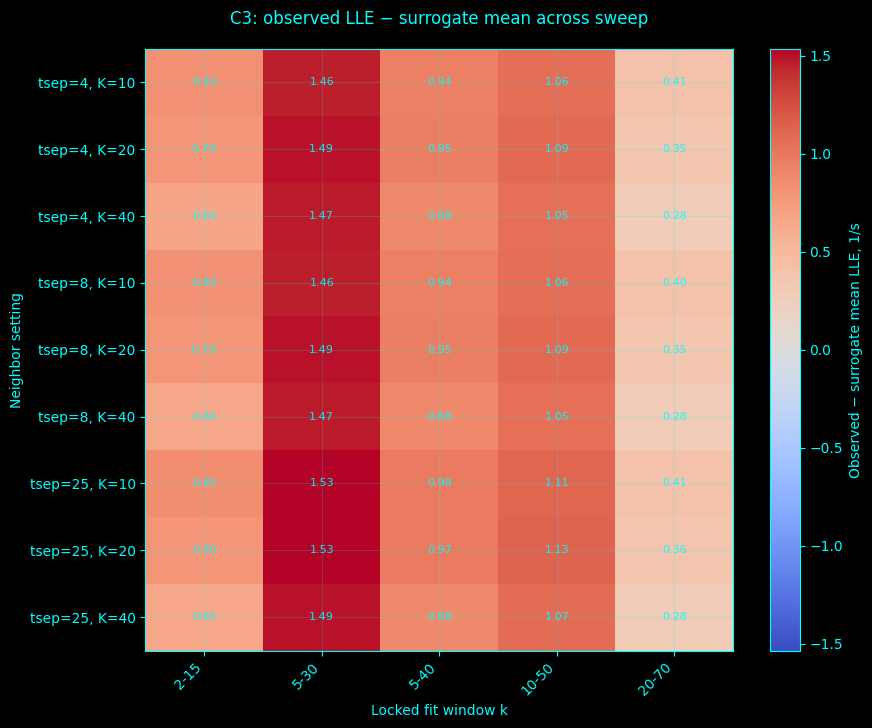

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/01_C3_delta_LLE_heatmap_C3_m10_tau4_20260915_120006.png


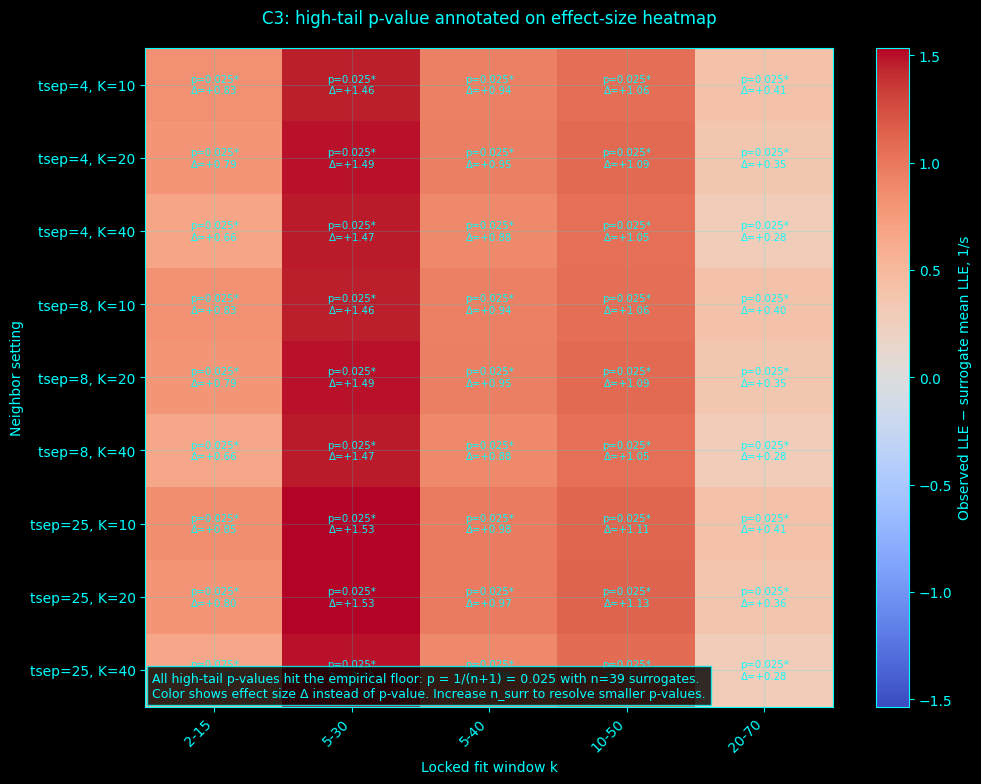

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/02_C3_p_high_annotated_on_delta_heatmap_FIXED_C3_m10_tau4_20260915_120006.png


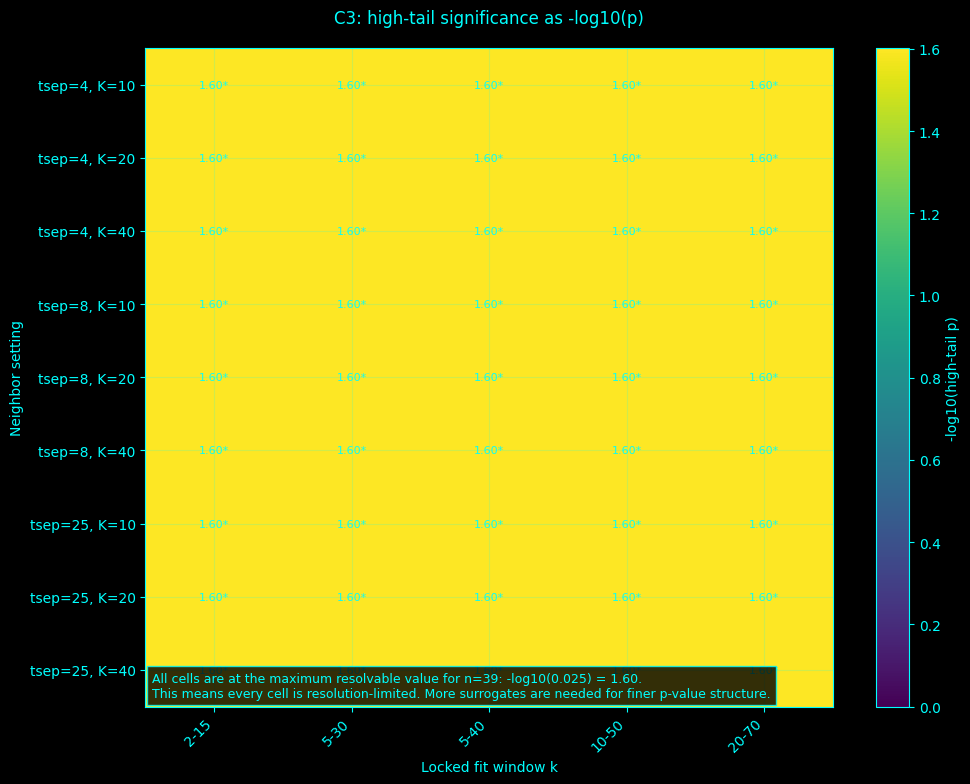

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/02B_C3_p_high_neglog10_heatmap_FIXED_C3_m10_tau4_20260915_120006.png


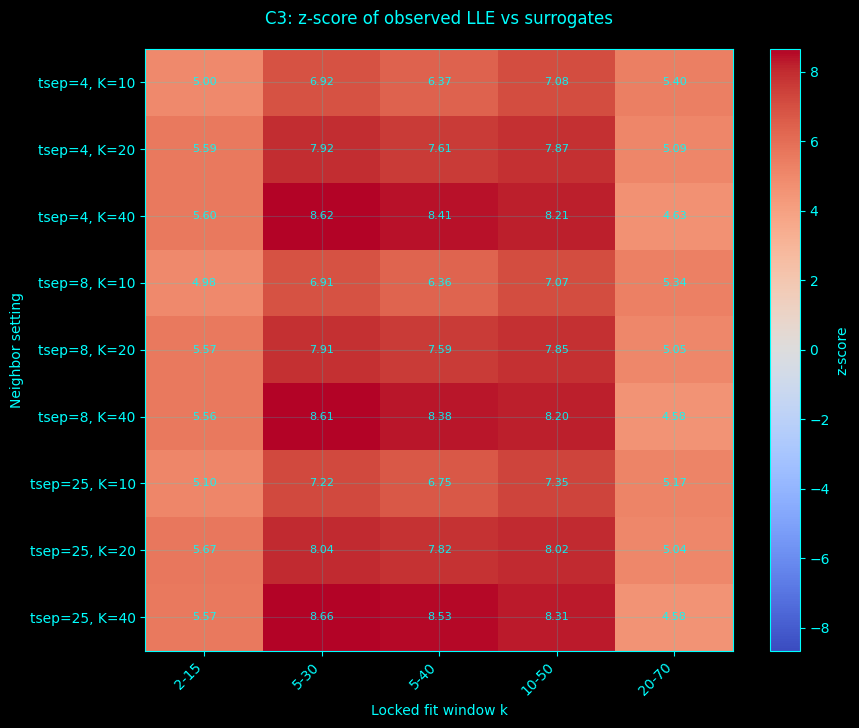

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/03_C3_z_score_heatmap_C3_m10_tau4_20260915_120006.png


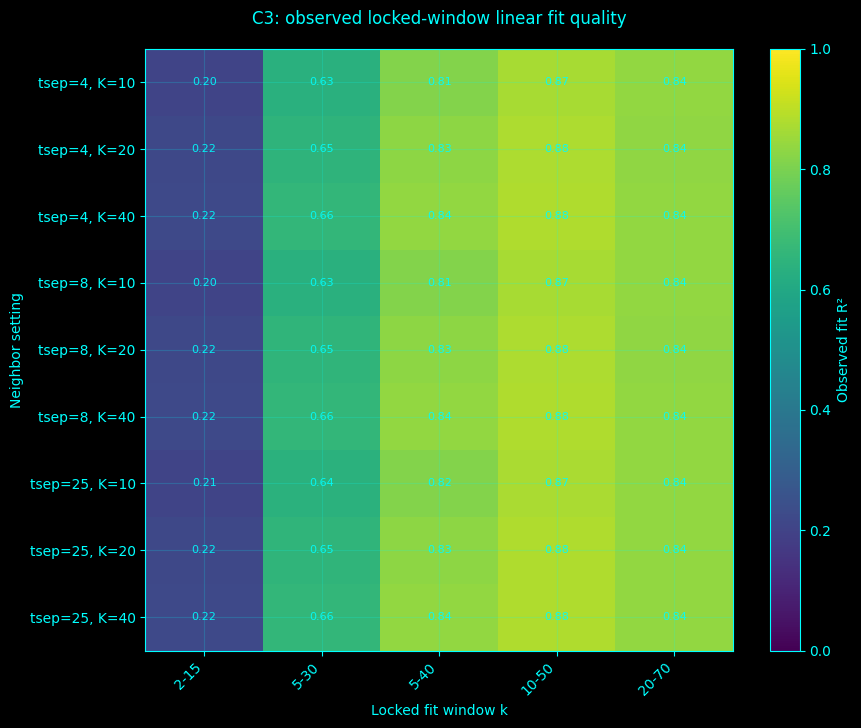

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/04_C3_observed_fit_r2_heatmap_C3_m10_tau4_20260915_120006.png


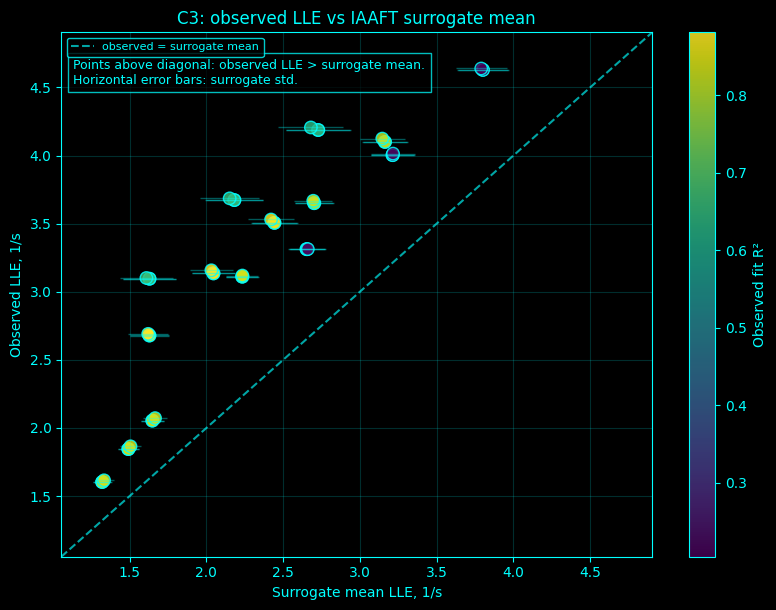

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/05_C3_observed_vs_surrogate_mean_C3_m10_tau4_20260915_120006.png


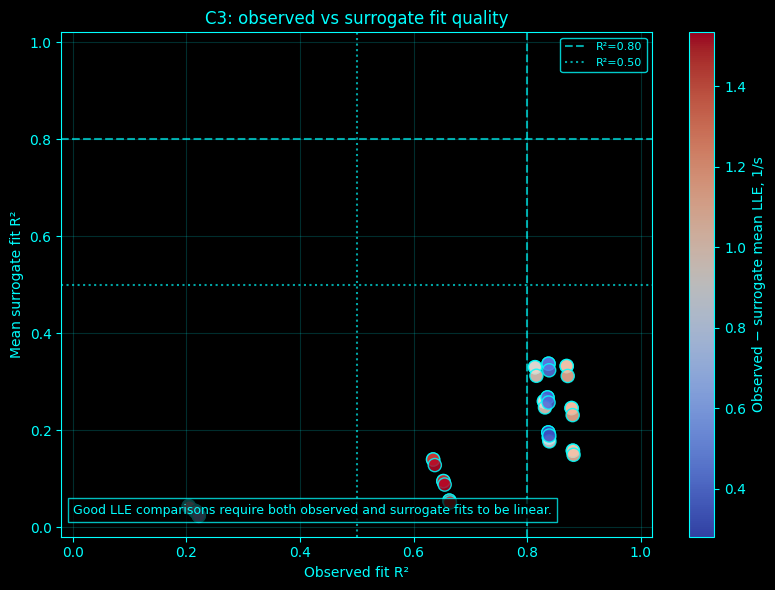

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/06_C3_fit_quality_comparison_C3_m10_tau4_20260915_120006.png


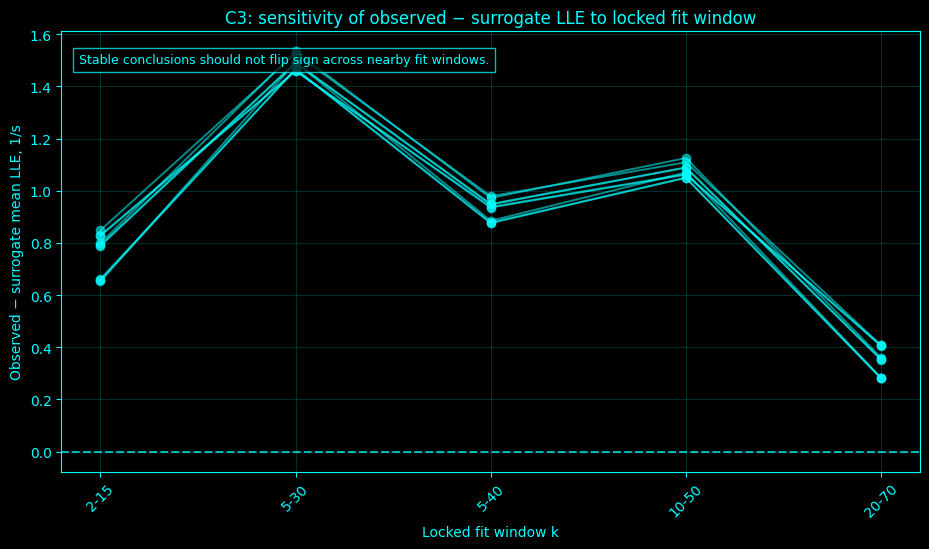

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/07_C3_fit_window_sensitivity_C3_m10_tau4_20260915_120006.png


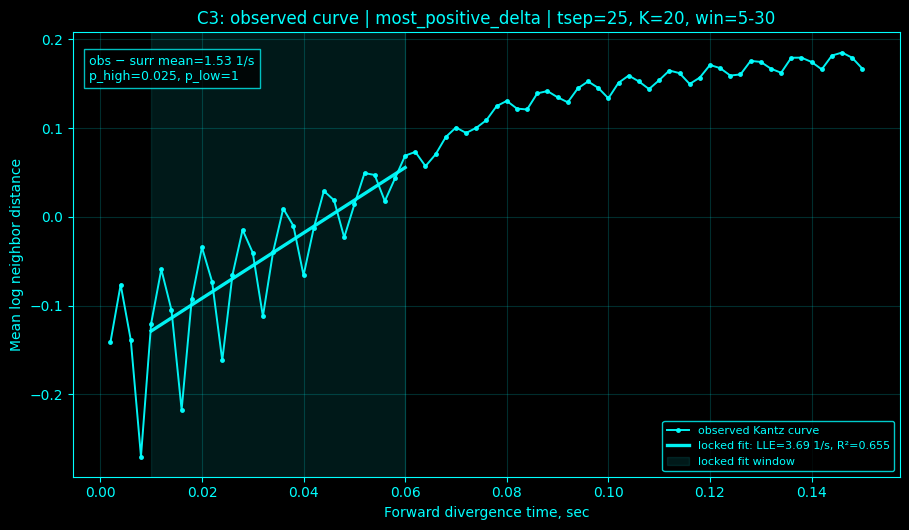

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/08_C3_most_positive_delta_observed_curve_tsep25_K20_win5-30_C3_m10_tau4_20260915_120006.png


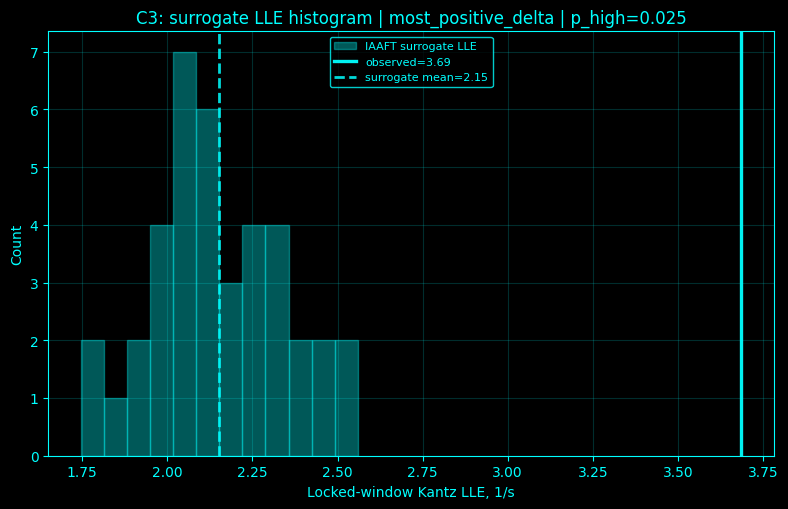

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/09_C3_most_positive_delta_surrogate_hist_tsep25_K20_win5-30_C3_m10_tau4_20260915_120006.png


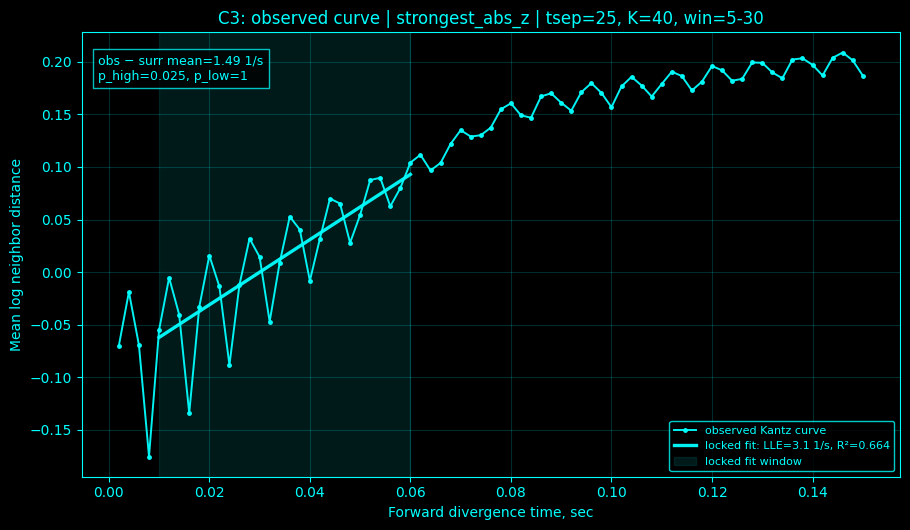

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/08_C3_strongest_abs_z_observed_curve_tsep25_K40_win5-30_C3_m10_tau4_20260915_120006.png


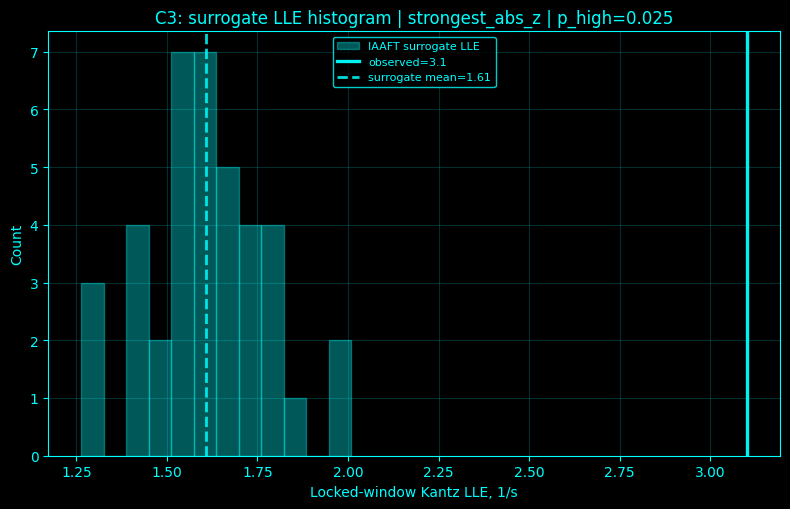

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_locked_window_sweep_fast_insightful/plots/09_C3_strongest_abs_z_surrogate_hist_tsep25_K40_win5-30_C3_m10_tau4_20260915_120006.png

=== Kantz locked-window sweep summary ===
 min_tsep  K_use fit_window_label  obs_LLE  surr_mean  surr_std  obs_minus_surr_mean  z_obs_vs_surr  p_high_surr_ge_obs  p_low_surr_le_obs  obs_fit_r2  surr_fit_r2_mean  obs_refs_used
       25     20             5-30 3.685916   2.151511  0.190937             1.534405       8.036181               0.025                1.0    0.654663          0.087539           2500
       25     10             5-30 4.206437   2.680751  0.211226             1.525686       7.223017               0.025                1.0    0.637296          0.127708           2500
       25     40             5-30 3.101212   1.609064  0.172319             1.492148       8.659230               0.025                1.0    0.663970          0.050771           2500
        4     20     

In [2]:
import os

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "kantz_locked_window_sweep_fast_insightful")
plots_dir = os.path.join(out_dir, "plots")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

channel = "C3"

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FC5", "FC1", "FC2", "FC6", "M1", "T7", "C3", "Cz",
    "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

fs_original = 1000.0
segment = (814.571, 921.515)

FAST_MODE = FAST_OPTION in {"fast", "ultra"}
ULTRA_FAST_MODE = FAST_OPTION == "ultra"

m = 10
tau_original = 8

fit_windows_original = [
    (5, 30),
    (10, 60),
    (10, 80),
    (20, 100),
    (40, 140),
]

min_tseps_original = [
    tau_original,
    2 * tau_original,
    50,
]

K_uses_full = [10, 20, 40]

seed = 0
eps = 1e-12

if ULTRA_FAST_MODE:
    decimate_factor = 2
    max_samples = _speed_count(20000, minimum=250)
    n_surr = 19
    iaaft_iters = 50
    iaaft_tol = 1e-3
    iaaft_min_iters = 20
    iaaft_check_every = 10
    n_ref = 1200
    K_uses = [10, 20]
    min_tseps_original = [tau_original, 50]
    fit_windows_original = [(10, 60), (20, 100), (40, 140)]
    K_search = 80
elif FAST_MODE:
    decimate_factor = 2
    max_samples = _speed_count(30000, minimum=250)
    n_surr = 39
    iaaft_iters = 80
    iaaft_tol = 5e-4
    iaaft_min_iters = 30
    iaaft_check_every = 10
    n_ref = 2500
    K_uses = K_uses_full
    K_search = 100
else:
    decimate_factor = 1
    max_samples = None
    n_surr = 199
    iaaft_iters = 200
    iaaft_tol = 1e-4
    iaaft_min_iters = 80
    iaaft_check_every = 20
    n_ref = 6000
    K_uses = K_uses_full
    K_search = 120

n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))
RUN_PARALLEL = True

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})


def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)

        for text in leg.get_texts():
            text.set_color(ACCENT)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=180):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


def make_timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))


def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)

    return x.astype(np.float32)


def preprocess_signal(x, fs, decimate_factor=1, max_samples=None):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]

    fs_eff = float(fs)

    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]

        fs_eff = fs_eff / float(decimate_factor)

    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]

    x = standardize_1d(x)

    return x, fs_eff


def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=np.float32)

    N = len(x)
    M = N - (m - 1) * tau

    if M <= 1:
        raise ValueError(f"Embedding failed: N={N}, m={m}, tau={tau}")

    X = np.column_stack([
        x[i * tau:i * tau + M]
        for i in range(m)
    ])

    return X.astype(np.float32)


def pick_reference_indices(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax

    if last_ok <= 10:
        return np.array([], dtype=int), last_ok

    n_ref_eff = min(int(n_ref), last_ok + 1)

    refs = rng.choice(
        np.arange(0, last_ok + 1),
        size=n_ref_eff,
        replace=False
    )

    refs = np.sort(refs.astype(int))

    return refs, int(last_ok)


def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))

    return float(
        np.linalg.norm(mag_y - target_mag) /
        (np.linalg.norm(target_mag) + 1e-12)
    )


def iaaft_surrogate_fast(
    x_sorted,
    target_mag,
    n,
    seed,
    n_iter=80,
    tol=5e-4,
    min_iter=30,
    check_every=10
):
    rng = np.random.default_rng(seed)

    y = rng.permutation(x_sorted).astype(np.float32)

    final_err = np.nan
    used_iters = 0

    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))

        y = np.fft.irfft(target_mag * phase, n=n).astype(np.float32)

        ranks = np.argsort(y, kind="quicksort")

        y2 = np.empty_like(y)
        y2[ranks] = x_sorted

        y = y2
        used_iters = it

        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)

            if final_err <= tol:
                break

    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)

    return y.astype(np.float32), final_err, used_iters


def precompute_neighbor_indices(X, refs, K_search):
    M = len(X)

    n_neighbors = min(max(2, int(K_search) + 1), M)

    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        algorithm="auto",
        n_jobs=1
    ).fit(X)

    _, idxs = nn.kneighbors(X[refs], return_distance=True)

    return idxs


def kantz_divergence_curve_from_indices(
    X,
    refs,
    idxs,
    min_tsep,
    kmax,
    K_use,
    batch_size=64
):
    M, dim = X.shape

    refs = np.asarray(refs, dtype=int)
    idxs = np.asarray(idxs, dtype=int)

    kmax = int(kmax)
    min_tsep = int(min_tsep)
    K_use = int(K_use)

    ref_keep = []
    neigh_keep = []

    for row, i in enumerate(refs):
        cand = idxs[row]
        cand = cand[cand != i]

        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]

        cand = cand[cand + kmax < M]

        if len(cand) < K_use:
            continue

        ref_keep.append(int(i))
        neigh_keep.append(cand[:K_use].astype(int))

    if len(ref_keep) == 0:
        ks = np.arange(1, kmax + 1, dtype=int)
        y = np.full(kmax, np.nan, dtype=float)

        info = {
            "M": int(M),
            "refs_used": 0,
            "refs_requested": int(len(refs)),
            "kmax_eff": int(kmax),
            "neighbor_fail": True,
        }

        return ks, y, info

    ref_keep = np.asarray(ref_keep, dtype=int)
    neigh_keep = np.asarray(neigh_keep, dtype=int)

    ks = np.arange(1, kmax + 1, dtype=int)

    y_acc = np.zeros(len(ks), dtype=float)
    counts = np.zeros(len(ks), dtype=int)

    for start in range(0, len(ref_keep), batch_size):
        stop = min(start + batch_size, len(ref_keep))

        rb = ref_keep[start:stop]
        nb = neigh_keep[start:stop]

        Xi = X[rb[:, None] + ks[None, :]]
        Xj = X[nb[:, :, None] + ks[None, None, :]]

        dist = np.linalg.norm(Xj - Xi[:, None, :, :], axis=3)

        log_mean = np.mean(np.log(dist + eps), axis=1)

        y_acc += np.sum(log_mean, axis=0)
        counts += log_mean.shape[0]

    y = y_acc / np.maximum(counts, 1)

    info = {
        "M": int(M),
        "refs_used": int(len(ref_keep)),
        "refs_requested": int(len(refs)),
        "kmax_eff": int(kmax),
        "neighbor_fail": False,
    }

    return ks, y, info


def fit_slope_locked(ks, y, fit_lo, fit_hi, fs_eff):
    ks = np.asarray(ks, dtype=int)
    y = np.asarray(y, dtype=float)

    fit_lo = int(fit_lo)
    fit_hi = int(fit_hi)

    mask = (ks >= fit_lo) & (ks <= fit_hi) & np.isfinite(y)

    kfit = ks[mask].astype(float)
    yfit = y[mask].astype(float)

    if len(kfit) < 5:
        return {
            "slope_per_sample": np.nan,
            "LLE": np.nan,
            "intercept": np.nan,
            "fit_r2": np.nan,
            "fit_rmse": np.nan,
            "nfit": int(len(kfit)),
        }

    coef = np.polyfit(kfit, yfit, 1)

    yhat = np.polyval(coef, kfit)

    ss_res = float(np.sum((yfit - yhat) ** 2))
    ss_tot = float(np.sum((yfit - np.mean(yfit)) ** 2))

    fit_r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    fit_rmse = float(np.sqrt(np.mean((yfit - yhat) ** 2)))

    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    LLE = float(slope_per_sample * fs_eff)

    return {
        "slope_per_sample": slope_per_sample,
        "LLE": LLE,
        "intercept": intercept,
        "fit_r2": fit_r2,
        "fit_rmse": fit_rmse,
        "nfit": int(len(kfit)),
    }


def empirical_p_values(obs, vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0 or not np.isfinite(obs):
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "delta": np.nan,
            "z": np.nan,
            "p_high": np.nan,
            "p_low": np.nan,
            "p_two": np.nan,
        }

    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    delta = float(obs - mean)
    z = float((obs - mean) / (std + 1e-12))

    p_high = float((np.sum(vals >= obs) + 1.0) / (len(vals) + 1.0))
    p_low = float((np.sum(vals <= obs) + 1.0) / (len(vals) + 1.0))

    p_two = float(
        (np.sum(np.abs(vals - mean) >= abs(obs - mean)) + 1.0) /
        (len(vals) + 1.0)
    )

    return {
        "n": int(len(vals)),
        "mean": mean,
        "std": std,
        "delta": delta,
        "z": z,
        "p_high": p_high,
        "p_low": p_low,
        "p_two": p_two,
    }


tau_eff = effective_sample_param(
    tau_original,
    decimate_factor,
    minimum=1
)

fit_windows = [
    (
        effective_sample_param(lo, decimate_factor, minimum=1),
        effective_sample_param(hi, decimate_factor, minimum=5)
    )
    for lo, hi in fit_windows_original
]

fit_windows = [
    (lo, max(hi, lo + 5))
    for lo, hi in fit_windows
]

fit_windows = sorted(set(fit_windows))

min_tseps = [
    effective_sample_param(v, decimate_factor, minimum=1)
    for v in min_tseps_original
]

min_tseps = sorted(set(min_tseps))

kmax = max(hi for _, hi in fit_windows) + 5

K_search_eff = max(
    int(K_search),
    int(max(K_uses) + max(min_tseps) + 20)
)

run_id = f"{channel}_m{m}_tau{tau_eff}_{make_timestamp()}"

OUT_SUMMARY_CSV = os.path.join(out_dir, f"summary_{run_id}.csv")
OUT_OBSERVED_CSV = os.path.join(out_dir, f"observed_settings_{run_id}.csv")
OUT_SURROGATE_CSV = os.path.join(out_dir, f"surrogate_settings_{run_id}.csv")
OUT_CURVE_CSV = os.path.join(out_dir, f"observed_curves_{run_id}.csv")
OUT_QC_CSV = os.path.join(out_dir, f"qc_{run_id}.csv")
OUT_NPZ = os.path.join(out_dir, f"arrays_{run_id}.npz")
OUT_TXT = os.path.join(out_dir, f"report_{run_id}.txt")

print("Effective parameters:")
print("  FAST_MODE:", FAST_MODE)
print("  ULTRA_FAST_MODE:", ULTRA_FAST_MODE)
print("  decimate_factor:", decimate_factor)
print("  max_samples:", max_samples)
print("  fs_original:", fs_original)
print("  tau_original:", tau_original)
print("  tau_eff:", tau_eff)
print("  m:", m)
print("  kmax:", kmax)
print("  n_ref:", n_ref)
print("  n_surr:", n_surr)
print("  iaaft_iters:", iaaft_iters)
print("  K_search_eff:", K_search_eff)
print("  K_uses:", K_uses)
print("  min_tseps:", min_tseps)
print("  fit_windows:", fit_windows)
print("  n_workers:", n_workers)


EEG = np.load(eeg_path, allow_pickle=True)

if EEG.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG.shape}")

if EEG.shape[0] == len(eeg_channel_names) and EEG.shape[1] != len(eeg_channel_names):
    EEG = EEG.T

if EEG.shape[1] != len(eeg_channel_names):
    raise ValueError(
        f"Expected {len(eeg_channel_names)} channels, got EEG shape {EEG.shape}"
    )

if channel not in eeg_channel_names:
    raise ValueError(f"Channel {channel} not found.")

ch_idx = eeg_channel_names.index(channel)

start_idx = int(segment[0] * fs_original)
end_idx = int(segment[1] * fs_original)

x_raw = EEG[start_idx:end_idx, ch_idx].astype(float)

x, fs_eff = preprocess_signal(
    x_raw,
    fs=fs_original,
    decimate_factor=decimate_factor,
    max_samples=max_samples
)

print(f"\nLoaded {channel}: raw N={len(x_raw)} | used N={len(x)} | fs_eff={fs_eff:g} Hz")

Xobs = delay_embed_1d(x, m=m, tau=tau_eff)

rng = np.random.default_rng(seed)

refs, last_ok = pick_reference_indices(
    M=len(Xobs),
    kmax=kmax,
    n_ref=n_ref,
    rng=rng
)

if len(refs) == 0:
    raise ValueError("No valid reference indices. kmax may be too large.")

print(f"Embedded M={len(Xobs)} | refs={len(refs)} | last_ok={last_ok}")

run_start = time.time()

observed_rows = []
observed_curve_rows = []
observed_curve_cache = {}

print("\nComputing observed Kantz curves...")

obs_idxs = precompute_neighbor_indices(
    Xobs,
    refs=refs,
    K_search=K_search_eff
)

for min_tsep in min_tseps:
    for K_use in K_uses:
        ks, y_obs, info_obs = kantz_divergence_curve_from_indices(
            Xobs,
            refs=refs,
            idxs=obs_idxs,
            min_tsep=min_tsep,
            kmax=kmax,
            K_use=K_use,
            batch_size=64
        )

        observed_curve_cache[(min_tsep, K_use)] = {
            "ks": ks,
            "y": y_obs,
            "info": info_obs,
        }

        for i, k in enumerate(ks):
            observed_curve_rows.append({
                "channel": channel,
                "min_tsep": int(min_tsep),
                "K_use": int(K_use),
                "k": int(k),
                "time_seconds": float(k / fs_eff),
                "mean_log_distance": float(y_obs[i]),
                "refs_used": int(info_obs["refs_used"]),
                "refs_requested": int(info_obs["refs_requested"]),
                "neighbor_fail": bool(info_obs["neighbor_fail"]),
            })

        for fit_lo, fit_hi in fit_windows:
            fit = fit_slope_locked(
                ks,
                y_obs,
                fit_lo=fit_lo,
                fit_hi=fit_hi,
                fs_eff=fs_eff
            )

            observed_rows.append({
                "channel": channel,
                "min_tsep": int(min_tsep),
                "K_use": int(K_use),
                "fit_lo": int(fit_lo),
                "fit_hi": int(fit_hi),
                "fit_window_label": f"{fit_lo}-{fit_hi}",
                "fit_lo_seconds": float(fit_lo / fs_eff),
                "fit_hi_seconds": float(fit_hi / fs_eff),
                "obs_slope_per_sample": float(fit["slope_per_sample"]),
                "obs_LLE": float(fit["LLE"]),
                "obs_fit_r2": float(fit["fit_r2"]),
                "obs_fit_rmse": float(fit["fit_rmse"]),
                "obs_nfit": int(fit["nfit"]),
                "obs_refs_used": int(info_obs["refs_used"]),
                "obs_refs_requested": int(info_obs["refs_requested"]),
                "neighbor_fail": bool(info_obs["neighbor_fail"]),
            })

observed_df = pd.DataFrame(observed_rows)
observed_curve_df = pd.DataFrame(observed_curve_rows)

print("Observed settings:", len(observed_df))

x_sorted = np.sort(x)
target_mag = np.abs(np.fft.rfft(x))
n = len(x)

surrogate_rows = []
surrogate_qc_rows = []


def surrogate_worker(s_idx):
    xs, final_err, used_iters = iaaft_surrogate_fast(
        x_sorted=x_sorted,
        target_mag=target_mag,
        n=n,
        seed=seed + 10000 + int(s_idx),
        n_iter=iaaft_iters,
        tol=iaaft_tol,
        min_iter=iaaft_min_iters,
        check_every=iaaft_check_every
    )

    Xs = delay_embed_1d(xs, m=m, tau=tau_eff)

    idxs_s = precompute_neighbor_indices(
        Xs,
        refs=refs,
        K_search=K_search_eff
    )

    rows = []

    for min_tsep in min_tseps:
        for K_use in K_uses:
            ks_s, y_s, info_s = kantz_divergence_curve_from_indices(
                Xs,
                refs=refs,
                idxs=idxs_s,
                min_tsep=min_tsep,
                kmax=kmax,
                K_use=K_use,
                batch_size=64
            )

            for fit_lo, fit_hi in fit_windows:
                fit = fit_slope_locked(
                    ks_s,
                    y_s,
                    fit_lo=fit_lo,
                    fit_hi=fit_hi,
                    fs_eff=fs_eff
                )

                rows.append({
                    "channel": channel,
                    "surrogate_index": int(s_idx + 1),
                    "min_tsep": int(min_tsep),
                    "K_use": int(K_use),
                    "fit_lo": int(fit_lo),
                    "fit_hi": int(fit_hi),
                    "fit_window_label": f"{fit_lo}-{fit_hi}",
                    "surr_slope_per_sample": float(fit["slope_per_sample"]),
                    "surr_LLE": float(fit["LLE"]),
                    "surr_fit_r2": float(fit["fit_r2"]),
                    "surr_fit_rmse": float(fit["fit_rmse"]),
                    "surr_nfit": int(fit["nfit"]),
                    "surr_refs_used": int(info_s["refs_used"]),
                    "surr_refs_requested": int(info_s["refs_requested"]),
                    "neighbor_fail": bool(info_s["neighbor_fail"]),
                    "iaaft_final_spectrum_relative_error": float(final_err),
                    "iaaft_iters_used": int(used_iters),
                })

    qc = {
        "surrogate_index": int(s_idx + 1),
        "iaaft_final_spectrum_relative_error": float(final_err),
        "iaaft_iters_used": int(used_iters),
    }

    return rows, qc


print(f"\nGenerating {n_surr} IAAFT surrogates and locked-window Kantz fits...")

if RUN_PARALLEL:
    completed = 0
    failed = 0

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [
            executor.submit(surrogate_worker, s_idx)
            for s_idx in range(n_surr)
        ]

        for fut in as_completed(futures):
            try:
                rows, qc = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue

            surrogate_rows.extend(rows)
            surrogate_qc_rows.append(qc)

            completed += 1

            if completed % 5 == 0 or completed + failed == n_surr:
                print(f"  completed {completed}/{n_surr} surrogates | failed={failed}", flush=True)

else:
    completed = 0
    failed = 0

    for s_idx in range(n_surr):
        try:
            rows, qc = surrogate_worker(s_idx)
            surrogate_rows.extend(rows)
            surrogate_qc_rows.append(qc)
            completed += 1
        except Exception as e:
            failed += 1
            print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)

        if completed % 5 == 0 or completed + failed == n_surr:
            print(f"  completed {completed}/{n_surr} surrogates | failed={failed}", flush=True)

surrogate_df = pd.DataFrame(surrogate_rows)
surrogate_qc_df = pd.DataFrame(surrogate_qc_rows)

print("Surrogate rows:", len(surrogate_df))

summary_rows = []

for _, obs_row in observed_df.iterrows():
    mask = (
        (surrogate_df["channel"] == obs_row["channel"]) &
        (surrogate_df["min_tsep"] == obs_row["min_tsep"]) &
        (surrogate_df["K_use"] == obs_row["K_use"]) &
        (surrogate_df["fit_lo"] == obs_row["fit_lo"]) &
        (surrogate_df["fit_hi"] == obs_row["fit_hi"])
    )

    sgroup = surrogate_df.loc[mask].copy()

    vals = sgroup["surr_LLE"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    stats = empirical_p_values(obs_row["obs_LLE"], vals)

    surr_r2 = sgroup["surr_fit_r2"].to_numpy(dtype=float)
    surr_r2 = surr_r2[np.isfinite(surr_r2)]

    surr_refs = sgroup["surr_refs_used"].to_numpy(dtype=float)
    surr_refs = surr_refs[np.isfinite(surr_refs)]

    summary_rows.append({
        "channel": obs_row["channel"],
        "min_tsep": int(obs_row["min_tsep"]),
        "K_use": int(obs_row["K_use"]),
        "fit_lo": int(obs_row["fit_lo"]),
        "fit_hi": int(obs_row["fit_hi"]),
        "fit_window_label": obs_row["fit_window_label"],
        "fit_lo_seconds": float(obs_row["fit_lo_seconds"]),
        "fit_hi_seconds": float(obs_row["fit_hi_seconds"]),
        "setting_label": f"tsep={int(obs_row['min_tsep'])}, K={int(obs_row['K_use'])}",
        "obs_LLE": float(obs_row["obs_LLE"]),
        "obs_fit_r2": float(obs_row["obs_fit_r2"]),
        "obs_fit_rmse": float(obs_row["obs_fit_rmse"]),
        "obs_refs_used": int(obs_row["obs_refs_used"]),
        "surr_n": int(stats["n"]),
        "surr_mean": float(stats["mean"]),
        "surr_std": float(stats["std"]),
        "obs_minus_surr_mean": float(stats["delta"]),
        "z_obs_vs_surr": float(stats["z"]),
        "p_high_surr_ge_obs": float(stats["p_high"]),
        "p_low_surr_le_obs": float(stats["p_low"]),
        "p_two_centered": float(stats["p_two"]),
        "surr_fit_r2_mean": float(np.mean(surr_r2)) if len(surr_r2) else np.nan,
        "surr_fit_r2_std": float(np.std(surr_r2, ddof=1)) if len(surr_r2) > 1 else np.nan,
        "surr_refs_used_mean": float(np.mean(surr_refs)) if len(surr_refs) else np.nan,
        "surr_refs_used_min": float(np.min(surr_refs)) if len(surr_refs) else np.nan,
        "surr_refs_used_max": float(np.max(surr_refs)) if len(surr_refs) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(
    ["min_tsep", "K_use", "fit_lo", "fit_hi"]
).reset_index(drop=True)

qc_df = pd.DataFrame([{
    "channel": channel,
    "FAST_MODE": FAST_MODE,
    "ULTRA_FAST_MODE": ULTRA_FAST_MODE,
    "fs_original": fs_original,
    "fs_eff": fs_eff,
    "segment_start": segment[0],
    "segment_end": segment[1],
    "raw_N": int(len(x_raw)),
    "used_N": int(len(x)),
    "embedded_M": int(len(Xobs)),
    "m": int(m),
    "tau_original": int(tau_original),
    "tau_eff": int(tau_eff),
    "decimate_factor": int(decimate_factor),
    "max_samples": -1 if max_samples is None else int(max_samples),
    "kmax": int(kmax),
    "n_ref_requested": int(n_ref),
    "refs_actual": int(len(refs)),
    "K_search_eff": int(K_search_eff),
    "n_surr_requested": int(n_surr),
    "n_surr_completed": int(len(surrogate_qc_df)),
    "iaaft_iters": int(iaaft_iters),
    "iaaft_error_mean": float(surrogate_qc_df["iaaft_final_spectrum_relative_error"].mean()) if len(surrogate_qc_df) else np.nan,
    "iaaft_error_max": float(surrogate_qc_df["iaaft_final_spectrum_relative_error"].max()) if len(surrogate_qc_df) else np.nan,
    "runtime_minutes": float((time.time() - run_start) / 60.0),
}])

observed_df.to_csv(OUT_OBSERVED_CSV, index=False)
surrogate_df.to_csv(OUT_SURROGATE_CSV, index=False)
observed_curve_df.to_csv(OUT_CURVE_CSV, index=False)
summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

np.savez_compressed(
    OUT_NPZ,
    x=x,
    refs=refs,
    summary_json=np.array([summary_df.to_json(orient="records")], dtype=object),
    observed_json=np.array([observed_df.to_json(orient="records")], dtype=object),
    surrogate_json=np.array([surrogate_df.to_json(orient="records")], dtype=object),
    observed_curve_json=np.array([observed_curve_df.to_json(orient="records")], dtype=object),
    qc_json=np.array([qc_df.to_json(orient="records")], dtype=object),
)

with open(OUT_TXT, "w") as f:
    f.write("Fast Kantz Locked-Window Sweep with IAAFT Surrogates\n")
    f.write("===================================================\n\n")
    f.write(f"channel={channel}\n")
    f.write(f"segment={segment} sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"fs_eff={fs_eff}\n")
    f.write(f"FAST_MODE={FAST_MODE}\n")
    f.write(f"ULTRA_FAST_MODE={ULTRA_FAST_MODE}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"max_samples={max_samples}\n")
    f.write(f"m={m}\n")
    f.write(f"tau_original={tau_original}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"kmax={kmax}\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"refs_actual={len(refs)}\n")
    f.write(f"K_search_eff={K_search_eff}\n")
    f.write(f"K_uses={K_uses}\n")
    f.write(f"min_tseps={min_tseps}\n")
    f.write(f"fit_windows={fit_windows}\n")
    f.write(f"n_surr={n_surr}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"seed={seed}\n\n")

    f.write("QC:\n")
    f.write(qc_df.to_string(index=False))

    f.write("\n\nTop settings by obs_minus_surr_mean:\n")
    f.write(
        summary_df
        .sort_values("obs_minus_surr_mean", ascending=False)
        .head(20)
        .to_string(index=False)
    )

    f.write("\n\nTop settings by high-tail significance:\n")
    f.write(
        summary_df
        .sort_values(["p_high_surr_ge_obs", "obs_minus_surr_mean"], ascending=[True, False])
        .head(20)
        .to_string(index=False)
    )

setting_labels = [
    f"tsep={t}, K={k}"
    for t in min_tseps
    for k in K_uses
]

window_labels = [
    f"{lo}-{hi}"
    for lo, hi in fit_windows
]


def plot_heatmap(
    df,
    value_col,
    title,
    colorbar_label,
    out_path,
    symmetric=False,
    cmap="coolwarm",
    fmt=".2g",
    fixed_vmin=None,
    fixed_vmax=None,
    note_text=None
):
    pivot = df.pivot_table(
        index="setting_label",
        columns="fit_window_label",
        values=value_col,
        aggfunc="mean"
    )

    pivot = pivot.reindex(index=setting_labels, columns=window_labels)

    Z = pivot.to_numpy(dtype=float)

    fig_w = max(8, 1.2 * len(window_labels) + 3)
    fig_h = max(5.5, 0.52 * len(setting_labels) + 2.7)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor=BG)
    style_ax(ax)

    if fixed_vmin is not None and fixed_vmax is not None:
        vmin = fixed_vmin
        vmax = fixed_vmax
    elif symmetric:
        vmax = np.nanmax(np.abs(Z)) if np.isfinite(Z).any() else 1.0
        vmax = max(vmax, 1e-12)
        vmin = -vmax
    else:
        vmin = np.nanmin(Z) if np.isfinite(Z).any() else 0.0
        vmax = np.nanmax(Z) if np.isfinite(Z).any() else 1.0

        if not np.isfinite(vmin) or not np.isfinite(vmax):
            vmin, vmax = 0.0, 1.0

        if vmin == vmax:
            pad = max(abs(vmin) * 0.05, 1e-6)
            vmin = vmin - pad
            vmax = vmax + pad

    im = ax.imshow(
        Z,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, pad=18)
    ax.set_xlabel("Locked fit window k")
    ax.set_ylabel("Neighbor setting")

    ax.set_xticks(np.arange(len(window_labels)))
    ax.set_xticklabels(window_labels, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(setting_labels)))
    ax.set_yticklabels(setting_labels)

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            if np.isfinite(Z[i, j]):
                ax.text(
                    j,
                    i,
                    format(Z[i, j], fmt),
                    ha="center",
                    va="center",
                    color=ACCENT,
                    fontsize=8,
                    alpha=0.90
                )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)
    style_colorbar(cbar)

    if note_text is not None:
        ax.text(
            0.01,
            0.01,
            note_text,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            color=ACCENT,
            fontsize=9,
            bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.78)
        )

    save_show_close(fig, out_path)


plot_heatmap(
    summary_df,
    value_col="obs_minus_surr_mean",
    title=f"{channel}: observed LLE − surrogate mean across sweep",
    colorbar_label="Observed − surrogate mean LLE, 1/s",
    out_path=os.path.join(plots_dir, f"01_{channel}_delta_LLE_heatmap_{run_id}.png"),
    symmetric=True,
    cmap="coolwarm",
    fmt=".2f"
)

p_col = "p_high_surr_ge_obs"

p_pivot = summary_df.pivot_table(
    index="setting_label",
    columns="fit_window_label",
    values=p_col,
    aggfunc="mean"
)

delta_pivot = summary_df.pivot_table(
    index="setting_label",
    columns="fit_window_label",
    values="obs_minus_surr_mean",
    aggfunc="mean"
)

z_pivot = summary_df.pivot_table(
    index="setting_label",
    columns="fit_window_label",
    values="z_obs_vs_surr",
    aggfunc="mean"
)

p_pivot = p_pivot.reindex(index=setting_labels, columns=window_labels)
delta_pivot = delta_pivot.reindex(index=setting_labels, columns=window_labels)
z_pivot = z_pivot.reindex(index=setting_labels, columns=window_labels)

P = p_pivot.to_numpy(dtype=float)
D = delta_pivot.to_numpy(dtype=float)
Zscore = z_pivot.to_numpy(dtype=float)

n_for_min_p = (
    int(summary_df["surr_n"].dropna().median())
    if "surr_n" in summary_df.columns and summary_df["surr_n"].notna().any()
    else n_surr
)

min_possible_p = 1.0 / (n_for_min_p + 1.0)
max_resolvable_logp = -np.log10(min_possible_p)

finite_p = P[np.isfinite(P)]

all_same_p = False
all_at_floor = False

if len(finite_p) > 0:
    all_same_p = np.nanmax(finite_p) - np.nanmin(finite_p) < 1e-12
    all_at_floor = np.all(np.isclose(finite_p, min_possible_p, atol=1e-12, rtol=0))

fig_w = max(9, 1.25 * len(window_labels) + 4)
fig_h = max(6.2, 0.55 * len(setting_labels) + 3.0)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor=BG)
style_ax(ax)

finite_d = D[np.isfinite(D)]

if len(finite_d) > 0:
    vmax_d = np.nanmax(np.abs(finite_d))
    vmax_d = max(vmax_d, 1e-12)
else:
    vmax_d = 1.0

im = ax.imshow(
    D,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-vmax_d,
    vmax=vmax_d
)

ax.set_title(
    f"{channel}: high-tail p-value annotated on effect-size heatmap",
    pad=18
)

ax.set_xlabel("Locked fit window k")
ax.set_ylabel("Neighbor setting")

ax.set_xticks(np.arange(len(window_labels)))
ax.set_xticklabels(window_labels, rotation=45, ha="right")

ax.set_yticks(np.arange(len(setting_labels)))
ax.set_yticklabels(setting_labels)

for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        if np.isfinite(P[i, j]):
            p_text = f"p={P[i, j]:.3g}"

            if np.isclose(P[i, j], min_possible_p, atol=1e-12, rtol=0):
                p_text += "*"

            if np.isfinite(D[i, j]):
                d_text = f"Δ={D[i, j]:+.2f}"
            else:
                d_text = "Δ=nan"

            ax.text(
                j,
                i,
                p_text + "\n" + d_text,
                ha="center",
                va="center",
                color=ACCENT,
                fontsize=7.3,
                alpha=0.95
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Observed LLE − surrogate mean LLE, 1/s")
style_colorbar(cbar)

if all_at_floor:
    note = (
        f"All high-tail p-values hit the empirical floor: p = 1/(n+1) = {min_possible_p:.3g} with n={n_for_min_p} surrogates.\n"
        "Color shows effect size Δ instead of p-value. Increase n_surr to resolve smaller p-values."
    )
elif all_same_p:
    note = (
        f"All high-tail p-values are identical: p={finite_p[0]:.3g}.\n"
        "Color shows effect size Δ instead of p-value."
    )
else:
    note = (
        f"Minimum possible empirical p-value with n={n_for_min_p} surrogates: {min_possible_p:.3g}.\n"
        "* marks cells at that empirical resolution floor."
    )

ax.text(
    0.01,
    0.01,
    note,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=ACCENT,
    fontsize=9,
    bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.80)
)

save_show_close(
    fig,
    os.path.join(plots_dir, f"02_{channel}_p_high_annotated_on_delta_heatmap_FIXED_{run_id}.png")
)

P_safe = np.clip(P, 1e-300, 1.0)
P_log = -np.log10(P_safe)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor=BG)
style_ax(ax)

finite_log = P_log[np.isfinite(P_log)]

if len(finite_log) > 0:
    vmax_log = max(max_resolvable_logp, np.nanmax(finite_log))
else:
    vmax_log = max_resolvable_logp

vmax_log = max(vmax_log, 1.0)

im = ax.imshow(
    P_log,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=0.0,
    vmax=vmax_log
)

ax.set_title(f"{channel}: high-tail significance as -log10(p)", pad=18)
ax.set_xlabel("Locked fit window k")
ax.set_ylabel("Neighbor setting")

ax.set_xticks(np.arange(len(window_labels)))
ax.set_xticklabels(window_labels, rotation=45, ha="right")

ax.set_yticks(np.arange(len(setting_labels)))
ax.set_yticklabels(setting_labels)

for i in range(P_log.shape[0]):
    for j in range(P_log.shape[1]):
        if np.isfinite(P_log[i, j]):
            text = f"{P_log[i, j]:.2f}"

            if np.isclose(P[i, j], min_possible_p, atol=1e-12, rtol=0):
                text += "*"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color=ACCENT,
                fontsize=8,
                alpha=0.95
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("-log10(high-tail p)")
style_colorbar(cbar)

if all_at_floor:
    note = (
        f"All cells are at the maximum resolvable value for n={n_for_min_p}: "
        f"-log10({min_possible_p:.3g}) = {max_resolvable_logp:.2f}.\n"
        "This means every cell is resolution-limited. More surrogates are needed for finer p-value structure."
    )
else:
    note = (
        f"For n={n_for_min_p} surrogates, the maximum resolvable value is "
        f"-log10({min_possible_p:.3g}) = {max_resolvable_logp:.2f}."
    )

ax.text(
    0.01,
    0.01,
    note,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=ACCENT,
    fontsize=9,
    bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.80)
)

save_show_close(
    fig,
    os.path.join(plots_dir, f"02B_{channel}_p_high_neglog10_heatmap_FIXED_{run_id}.png")
)

plot_heatmap(
    summary_df,
    value_col="z_obs_vs_surr",
    title=f"{channel}: z-score of observed LLE vs surrogates",
    colorbar_label="z-score",
    out_path=os.path.join(plots_dir, f"03_{channel}_z_score_heatmap_{run_id}.png"),
    symmetric=True,
    cmap="coolwarm",
    fmt=".2f"
)

plot_heatmap(
    summary_df,
    value_col="obs_fit_r2",
    title=f"{channel}: observed locked-window linear fit quality",
    colorbar_label="Observed fit R²",
    out_path=os.path.join(plots_dir, f"04_{channel}_observed_fit_r2_heatmap_{run_id}.png"),
    symmetric=False,
    cmap="viridis",
    fmt=".2f",
    fixed_vmin=0.0,
    fixed_vmax=1.0
)

fig, ax = plt.subplots(figsize=(8.2, 6.2), facecolor=BG)
style_ax(ax)

valid = summary_df[
    np.isfinite(summary_df["obs_LLE"]) &
    np.isfinite(summary_df["surr_mean"])
].copy()

if len(valid) > 0:
    sc = ax.scatter(
        valid["surr_mean"],
        valid["obs_LLE"],
        c=valid["obs_fit_r2"],
        cmap="viridis",
        s=80,
        alpha=0.85,
        edgecolor=ACCENT
    )

    ax.errorbar(
        valid["surr_mean"],
        valid["obs_LLE"],
        xerr=valid["surr_std"],
        fmt="none",
        ecolor=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    xmin = float(np.nanmin([valid["surr_mean"].min(), valid["obs_LLE"].min()]))
    xmax = float(np.nanmax([valid["surr_mean"].max(), valid["obs_LLE"].max()]))

    pad = 0.08 * max(abs(xmax - xmin), 1.0)

    ax.plot(
        [xmin - pad, xmax + pad],
        [xmin - pad, xmax + pad],
        linestyle="--",
        color=ACCENT,
        alpha=0.65,
        label="observed = surrogate mean"
    )

    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(xmin - pad, xmax + pad)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Observed fit R²")
    style_colorbar(cbar)

ax.set_title(f"{channel}: observed LLE vs IAAFT surrogate mean")
ax.set_xlabel("Surrogate mean LLE, 1/s")
ax.set_ylabel("Observed LLE, 1/s")

ax.text(
    0.02,
    0.95,
    "Points above diagonal: observed LLE > surrogate mean.\nHorizontal error bars: surrogate std.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    color=ACCENT,
    fontsize=9,
    bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
)

leg = ax.legend(loc="best", fontsize=8)
style_legend(leg)

save_show_close(
    fig,
    os.path.join(plots_dir, f"05_{channel}_observed_vs_surrogate_mean_{run_id}.png")
)

fig, ax = plt.subplots(figsize=(8.2, 6.0), facecolor=BG)
style_ax(ax)

valid = summary_df[
    np.isfinite(summary_df["obs_fit_r2"]) &
    np.isfinite(summary_df["surr_fit_r2_mean"])
].copy()

if len(valid) > 0:
    sc = ax.scatter(
        valid["obs_fit_r2"],
        valid["surr_fit_r2_mean"],
        c=valid["obs_minus_surr_mean"],
        cmap="coolwarm",
        s=90,
        alpha=0.85,
        edgecolor=ACCENT
    )

    ax.axhline(0.8, color=ACCENT, linestyle="--", alpha=0.65, label="R²=0.80")
    ax.axvline(0.8, color=ACCENT, linestyle="--", alpha=0.65)

    ax.axhline(0.5, color=ACCENT, linestyle=":", alpha=0.65, label="R²=0.50")
    ax.axvline(0.5, color=ACCENT, linestyle=":", alpha=0.65)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Observed − surrogate mean LLE, 1/s")
    style_colorbar(cbar)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

ax.set_title(f"{channel}: observed vs surrogate fit quality")
ax.set_xlabel("Observed fit R²")
ax.set_ylabel("Mean surrogate fit R²")

ax.text(
    0.02,
    0.04,
    "Good LLE comparisons require both observed and surrogate fits to be linear.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=ACCENT,
    fontsize=9,
    bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
)

leg = ax.legend(loc="best", fontsize=8)
style_legend(leg)

save_show_close(
    fig,
    os.path.join(plots_dir, f"06_{channel}_fit_quality_comparison_{run_id}.png")
)

fig, ax = plt.subplots(figsize=(9.4, 5.6), facecolor=BG)
style_ax(ax)

for setting_label, g in summary_df.groupby("setting_label"):
    g = g.sort_values("fit_lo")

    ax.plot(
        g["fit_window_label"],
        g["obs_minus_surr_mean"],
        marker="o",
        linewidth=1.4,
        alpha=0.55,
        color=ACCENT
    )

ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.70)

ax.set_title(f"{channel}: sensitivity of observed − surrogate LLE to locked fit window")
ax.set_xlabel("Locked fit window k")
ax.set_ylabel("Observed − surrogate mean LLE, 1/s")
ax.tick_params(axis="x", rotation=45)

ax.text(
    0.02,
    0.95,
    "Stable conclusions should not flip sign across nearby fit windows.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    color=ACCENT,
    fontsize=9,
    bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
)

save_show_close(
    fig,
    os.path.join(plots_dir, f"07_{channel}_fit_window_sensitivity_{run_id}.png")
)

valid_delta = summary_df[
    np.isfinite(summary_df["obs_minus_surr_mean"]) &
    np.isfinite(summary_df["p_high_surr_ge_obs"])
].copy()

if len(valid_delta) > 0:
    best_positive = valid_delta.sort_values(
        ["obs_minus_surr_mean", "p_high_surr_ge_obs"],
        ascending=[False, True]
    ).iloc[0]

    strongest_abs = valid_delta.assign(
        abs_z=lambda d: np.abs(d["z_obs_vs_surr"])
    ).sort_values("abs_z", ascending=False).iloc[0]

    representative_rows = [
        ("most_positive_delta", best_positive),
        ("strongest_abs_z", strongest_abs),
    ]

    used_keys = set()

    for label, row in representative_rows:
        key = (
            int(row["min_tsep"]),
            int(row["K_use"]),
            int(row["fit_lo"]),
            int(row["fit_hi"]),
        )

        if key in used_keys:
            continue

        used_keys.add(key)

        min_tsep = int(row["min_tsep"])
        K_use = int(row["K_use"])
        fit_lo = int(row["fit_lo"])
        fit_hi = int(row["fit_hi"])

        cache = observed_curve_cache[(min_tsep, K_use)]

        ks = cache["ks"]
        y = cache["y"]

        fit_mask = (ks >= fit_lo) & (ks <= fit_hi)

        fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
        style_ax(ax)

        ax.plot(
            ks / fs_eff,
            y,
            color=ACCENT,
            marker="o",
            markersize=2.5,
            linewidth=1.4,
            alpha=0.95,
            label="observed Kantz curve"
        )

        if np.sum(fit_mask) >= 2:
            coef = np.polyfit(ks[fit_mask], y[fit_mask], 1)
            yfit = np.polyval(coef, ks[fit_mask])

            ax.plot(
                ks[fit_mask] / fs_eff,
                yfit,
                color=ACCENT,
                linewidth=2.4,
                alpha=0.95,
                label=f"locked fit: LLE={row['obs_LLE']:.3g} 1/s, R²={row['obs_fit_r2']:.3f}"
            )

        ax.axvspan(
            fit_lo / fs_eff,
            fit_hi / fs_eff,
            color=ACCENT,
            alpha=0.10,
            label="locked fit window"
        )

        ax.set_title(
            f"{channel}: observed curve | {label} | tsep={min_tsep}, K={K_use}, win={fit_lo}-{fit_hi}"
        )
        ax.set_xlabel("Forward divergence time, sec")
        ax.set_ylabel("Mean log neighbor distance")

        ax.text(
            0.02,
            0.95,
            (
                f"obs − surr mean={row['obs_minus_surr_mean']:.3g} 1/s\n"
                f"p_high={row['p_high_surr_ge_obs']:.3g}, p_low={row['p_low_surr_le_obs']:.3g}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            color=ACCENT,
            fontsize=9,
            bbox=dict(facecolor=BG, edgecolor=ACCENT, alpha=0.75)
        )

        leg = ax.legend(loc="best", fontsize=8)
        style_legend(leg)

        save_show_close(
            fig,
            os.path.join(
                plots_dir,
                f"08_{channel}_{label}_observed_curve_tsep{min_tsep}_K{K_use}_win{fit_lo}-{fit_hi}_{run_id}.png"
            )
        )

        mask = (
            (surrogate_df["min_tsep"] == min_tsep) &
            (surrogate_df["K_use"] == K_use) &
            (surrogate_df["fit_lo"] == fit_lo) &
            (surrogate_df["fit_hi"] == fit_hi)
        )

        vals = surrogate_df.loc[mask, "surr_LLE"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]

        fig, ax = plt.subplots(figsize=(8.0, 5.2), facecolor=BG)
        style_ax(ax)

        if len(vals) > 0:
            ax.hist(
                vals,
                bins=min(28, max(8, int(np.sqrt(len(vals)) * 2))),
                color=ACCENT,
                edgecolor=ACCENT,
                alpha=0.35,
                label="IAAFT surrogate LLE"
            )

        ax.axvline(
            row["obs_LLE"],
            color=ACCENT,
            linewidth=2.4,
            alpha=0.95,
            label=f"observed={row['obs_LLE']:.3g}"
        )

        ax.axvline(
            row["surr_mean"],
            color=ACCENT,
            linestyle="--",
            linewidth=2.0,
            alpha=0.85,
            label=f"surrogate mean={row['surr_mean']:.3g}"
        )

        ax.set_title(
            f"{channel}: surrogate LLE histogram | {label} | p_high={row['p_high_surr_ge_obs']:.3g}"
        )
        ax.set_xlabel("Locked-window Kantz LLE, 1/s")
        ax.set_ylabel("Count")

        leg = ax.legend(loc="best", fontsize=8)
        style_legend(leg)

        save_show_close(
            fig,
            os.path.join(
                plots_dir,
                f"09_{channel}_{label}_surrogate_hist_tsep{min_tsep}_K{K_use}_win{fit_lo}-{fit_hi}_{run_id}.png"
            )
        )

print("\n=== Kantz locked-window sweep summary ===")
print(
    summary_df[
        [
            "min_tsep",
            "K_use",
            "fit_window_label",
            "obs_LLE",
            "surr_mean",
            "surr_std",
            "obs_minus_surr_mean",
            "z_obs_vs_surr",
            "p_high_surr_ge_obs",
            "p_low_surr_le_obs",
            "obs_fit_r2",
            "surr_fit_r2_mean",
            "obs_refs_used",
        ]
    ]
    .sort_values(["p_high_surr_ge_obs", "obs_minus_surr_mean"], ascending=[True, False])
    .head(20)
    .to_string(index=False)
)

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Observed settings CSV:", OUT_OBSERVED_CSV)
print("Surrogate settings CSV:", OUT_SURROGATE_CSV)
print("Observed curves CSV:", OUT_CURVE_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Kantz LLE: sweep min_tsep + fit window (+ optional K_use) with IAAFT surrogate test

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible Kantz largest-Lyapunov-exponent workflow with locked-window surrogate comparison. It loads one EEG segment from channel
            <code>C3</code>, standardizes the scalar signal, reconstructs a delay embedding, computes the Kantz mean-log-divergence curve, estimates the observed
            largest Lyapunov exponent (LLE) over fixed fit windows, and compares that estimate against <code>199</code> IAAFT surrogates. The key intent is to test
            whether the inferred instability remains robust across temporal-separation settings and fit-window choices while keeping the observed and surrogate fits
            methodologically identical.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Kantz method estimates the largest Lyapunov exponent from the average divergence of nearby trajectories in reconstructed phase space. If
            <code>X_i</code> is a reference state and <code>X_j</code> is one of its valid neighbors, then for exponential separation:
        </p>
        \[
            \|X_{i+k}-X_{j+k}\|\approx \|X_i-X_j\|e^{\lambda k\Delta t}
        \]
        <p>
            Taking logarithms and averaging across neighbors and reference points gives an approximately linear divergence curve:
        </p>
        \[
            y(k)=\left\langle \log \|X_{i+k}-X_{j+k}\| \right\rangle \approx c+\lambda k\Delta t
        \]
        <p>
            Therefore, fitting a straight line to <code>y(k)</code> over a chosen window in lag index <code>k</code> yields an estimate of the largest Lyapunov
            exponent. Since the slope is first estimated per sample and then multiplied by the sampling rate <code>fs</code>, the final LLE is reported in physical
            units of <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Neighborhood Geometry</h2>
        <p>
            The scalar EEG signal is reconstructed into delay vectors using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>:
        </p>
        \[
            X_t=[x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            For each reference point, the code searches a local neighborhood in this embedded space and keeps <code>K_use</code> nearest valid neighbors after applying
            a temporal-exclusion rule <code>min_tsep</code>. This exclusion acts like a Theiler window, preventing trivial neighbors that are close only because they
            are adjacent in time from dominating the divergence estimate.
        </p>
        <h2>Data Model and Sweep Structure</h2>
        <p>
            The script expects a multichannel EEG array stored in <code>eeg_data_with_channels.npy</code>, where rows are time samples and columns correspond to the
            listed channel names. It extracts channel <code>C3</code> over the segment <code>[814.571, 921.515]</code> seconds at <code>1000 Hz</code>, standardizes
            the signal, and then sweeps:
            <ul>
                <li><code>K_use = [20]</code> by default, with the option to expand to <code>[10,20,40]</code>,</li>
                <li><code>min_tsep = [\tau, 2\tau, 50]</code>,</li>
                <li>fit windows <code>(5,30)</code>, <code>(10,60)</code>, <code>(10,80)</code>, and <code>(20,100)</code>.</li>
            </ul>
            This structure makes the script a robustness analysis rather than a single one-shot LLE estimate.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target time interval.</li>
                <li><b>Standardize</b> the scalar series to zero mean and unit variance.</li>
                <li><b>Construct</b> a delay embedding with fixed <code>m=10</code> and <code>tau=8</code>.</li>
                <li><b>Select</b> valid reference indices that can be propagated safely up to <code>kmax=200</code>.</li>
                <li><b>Compute</b> the observed Kantz divergence curve for each combination of <code>K_use</code>, <code>min_tsep</code>, and locked fit window.</li>
                <li><b>Fit</b> the locked window to obtain the observed LLE in <code>1/s</code>.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates and repeat the identical Kantz analysis for each surrogate.</li>
                <li><b>Estimate</b> a one-sided empirical p-value comparing surrogate LLEs to the observed LLE.</li>
                <li><b>Save</b> one <code>.npz</code>, one divergence plot, and one surrogate histogram per parameter setting, plus a global summary text file.</li>
            </ol>
            This makes the script suitable for sensitivity analysis, null-model comparison, and reproducible storage of all outputs.
        </p>
        <h2>IAAFT Surrogates and Null Model</h2>
        <p>
            The surrogate generator uses the Iterative Amplitude Adjusted Fourier Transform method. Each surrogate alternates between two constraints:
            <ul>
                <li><b>Spectral constraint:</b> enforce the Fourier magnitude spectrum of the original signal.</li>
                <li><b>Amplitude constraint:</b> enforce the original amplitude distribution through rank-order remapping.</li>
            </ul>
            The resulting surrogate preserves the histogram exactly and approximately preserves the power spectrum, while disrupting nonlinear temporal organization.
            This provides a constrained null model for testing whether the observed Kantz LLE is unusually large.
        </p>
        <h2>Locked Fit Windows and Hypothesis Test</h2>
        <p>
            A central design choice is that the same fit window is used for both the observed data and all of its surrogates under a given setting. This prevents the
            surrogate comparison from being biased by different regression intervals. For each setting, the code computes the one-sided empirical p-value:
        </p>
        \[
            p_{\mathrm{one}}=\frac{\#\{\,\lambda_{\mathrm{surr}}\ge\lambda_{\mathrm{obs}}\,\}+1}{n_{\mathrm{surr}}+1}
        \]
        <p>
            The <code>+1</code> smoothing avoids a zero p-value in finite samples. A small value indicates that only a small fraction of surrogates produce an LLE at
            least as large as the observed signal under the same analysis window and neighborhood rules.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in divergence plots:</b> forward lag <code>k</code> in samples.</li>
                <li><b>y-axis in divergence plots:</b> average log distance <code>\(&lt;\log distance&gt;\)</code> across references and neighbors.</li>
                <li><b>Shaded region:</b> the locked fit window used to estimate the slope for that setting.</li>
                <li><b>x-axis in histogram plots:</b> surrogate Kantz LLE values in <code>1/s</code>.</li>
                <li><b>Vertical line in histogram plots:</b> the observed LLE for the same <code>K_use</code>, <code>min_tsep</code>, and fit window.</li>
            </ul>
            The divergence plot visualizes the geometric basis of the estimate, while the histogram shows the null-distribution comparison for statistical
            interpretation.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether the observed Kantz LLE is stable across different locked fit windows,</li>
                <li>Testing sensitivity to temporal-exclusion strength,</li>
                <li>Evaluating whether the observed divergence exceeds what is expected from IAAFT surrogates,</li>
                <li>Building a compact but complete audit trail of observed and surrogate results across a small parameter sweep.</li>
            </ul>
            If the observed LLE remains consistently above the surrogate ensemble across multiple windows and <code>min_tsep</code> choices, confidence in the
            robustness of the instability estimate is stronger. If the result changes sharply with window placement, it should be interpreted more cautiously.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the channel, segment, embedding parameters, surrogate count, and sweep settings in the configuration block, uses deterministic labeling
            through timestamped filenames, and writes both per-setting outputs and one global summary file. This makes the full locked-window Kantz sweep easy to rerun,
            compare, and audit later without ambiguity.
        </p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Kantz parameter sweep over neighbors, Theiler separation, and fit windows</h3><p>Kantz estimates depend on the local-neighborhood size, exclusion of temporally adjacent points, and the time interval used to fit the divergence slope. This cell varies those choices and plots the resulting LLE and surrogate effect size.</p><p>The purpose is sensitivity analysis: a physically interpretable estimate should not rely on one isolated combination of parameters.</p><p><b>Cell role.</b> Speed modes reduce the sweep density while retaining the same parameter definitions.</p></div>

$$\hat\lambda_1(K,W,[a,b])=\operatorname{slope}_{k\in[a,b]}S_{K,W}(k)/\Delta t.$$

Effective parameters:
  decimate_factor: 1
  tau_eff: 8
  min_tseps_eff: [8, 16, 50]
  K_uses: [20]
  kmax_eff: 105
  fit_windows_eff: [(5, 30), (10, 60), (10, 80), (20, 100)]
  n_surrogates: 70
  iaaft_iters: 200
  n_workers: 6

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=106944 | fs_eff=1000 Hz | segment=(814.571, 921.515)
Embedded M=106872 | refs=6000 | last_ok=106766

Observed fits:
  K=20 tsep=8 win=5-30 | LLE=6.32982 | R2=0.1785 | refs=6000
  K=20 tsep=8 win=10-60 | LLE=3.8466 | R2=0.3947 | refs=6000
  K=20 tsep=8 win=10-80 | LLE=4.01708 | R2=0.6386 | refs=6000
  K=20 tsep=8 win=20-100 | LLE=3.41351 | R2=0.7095 | refs=6000
  K=20 tsep=16 win=5-30 | LLE=6.32958 | R2=0.1786 | refs=6000
  K=20 tsep=16 win=10-60 | LLE=3.84734 | R2=0.3949 | refs=6000
  K=20 tsep=16 win=10-80 | LLE=4.01753 | R2=0.6388 | refs=6000
  K=20 tsep=16 win=20-100 | LLE=3.41399 | R2=0.7099 | refs

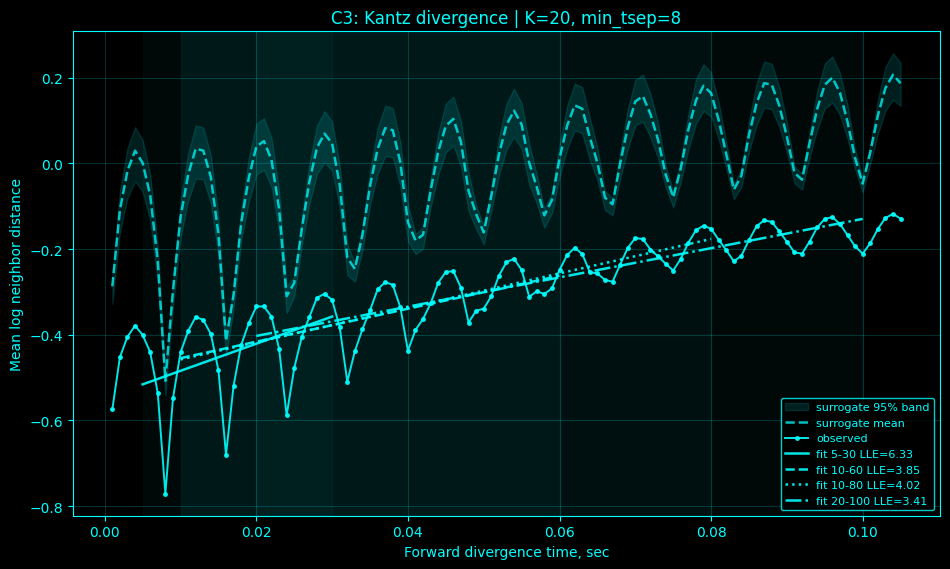

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/01_C3_divergence_K20_tsep8_C3_m10_tau8_nS70_20260915_120036.png


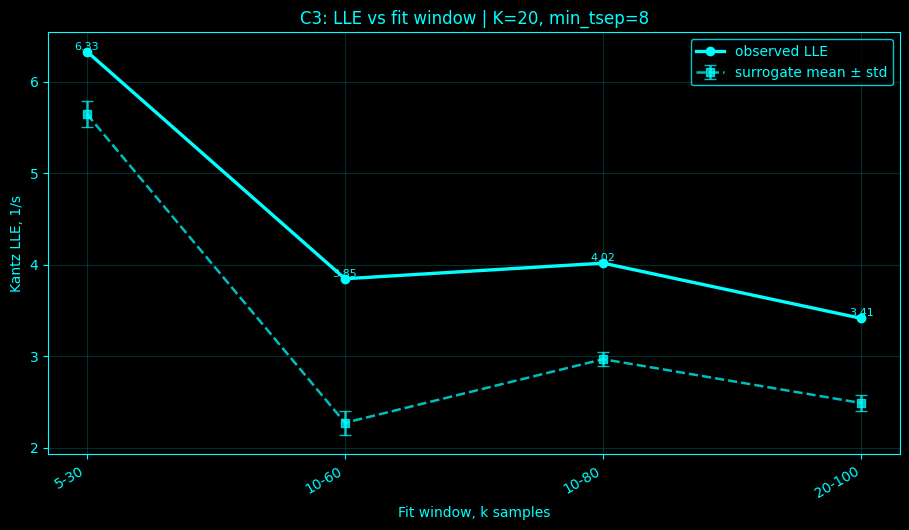

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/02_C3_LLE_by_window_K20_tsep8_C3_m10_tau8_nS70_20260915_120036.png


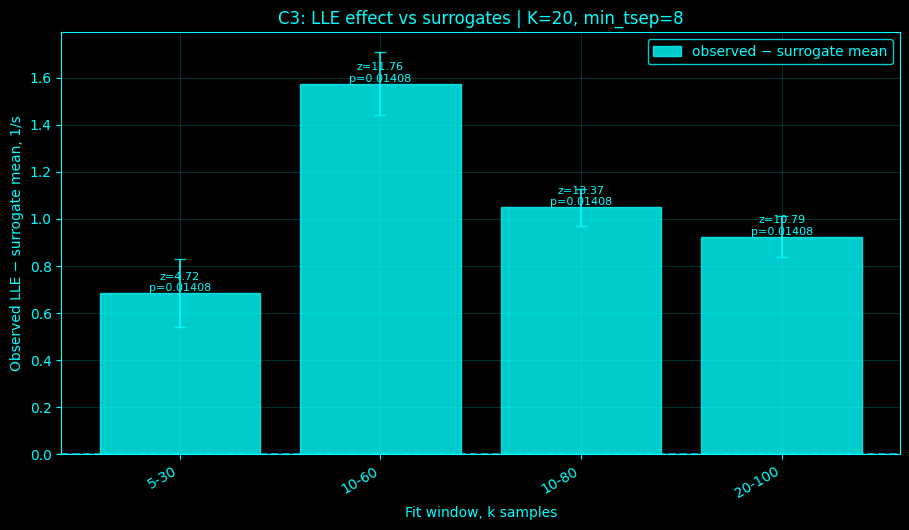

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/03_C3_effect_by_window_K20_tsep8_C3_m10_tau8_nS70_20260915_120036.png


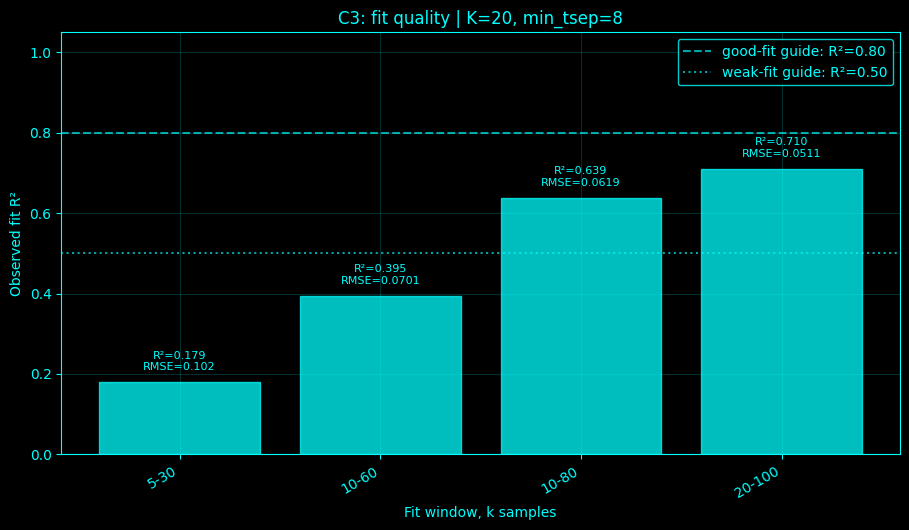

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/04_C3_fit_quality_K20_tsep8_C3_m10_tau8_nS70_20260915_120036.png


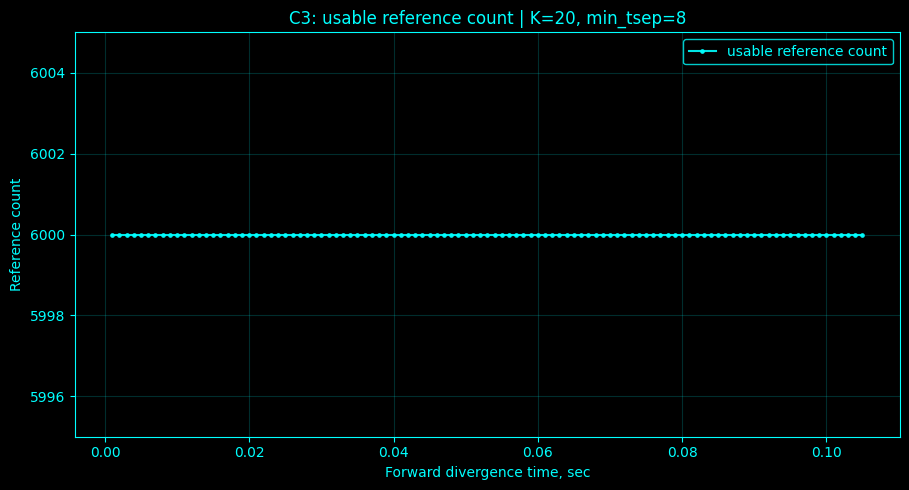

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/05_C3_counts_K20_tsep8_C3_m10_tau8_nS70_20260915_120036.png


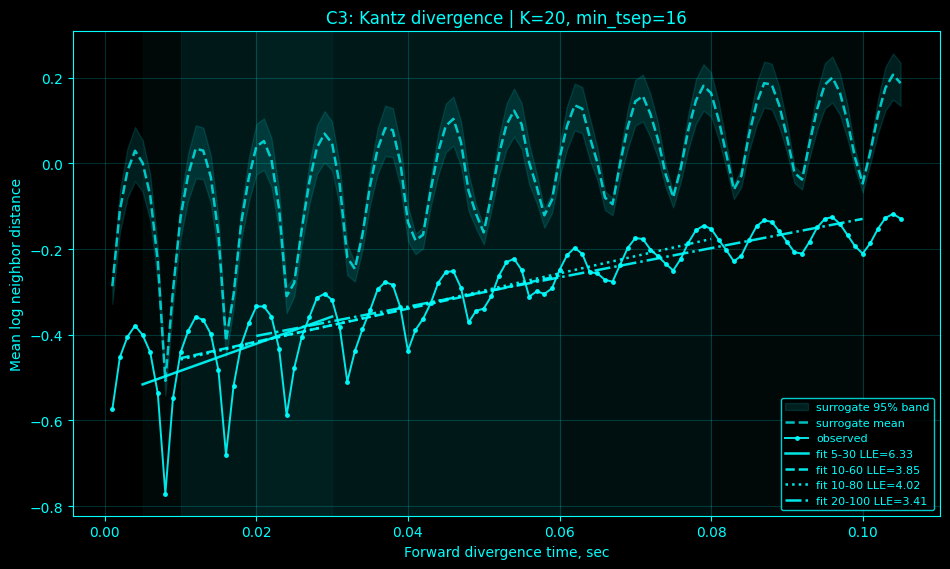

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/01_C3_divergence_K20_tsep16_C3_m10_tau8_nS70_20260915_120036.png


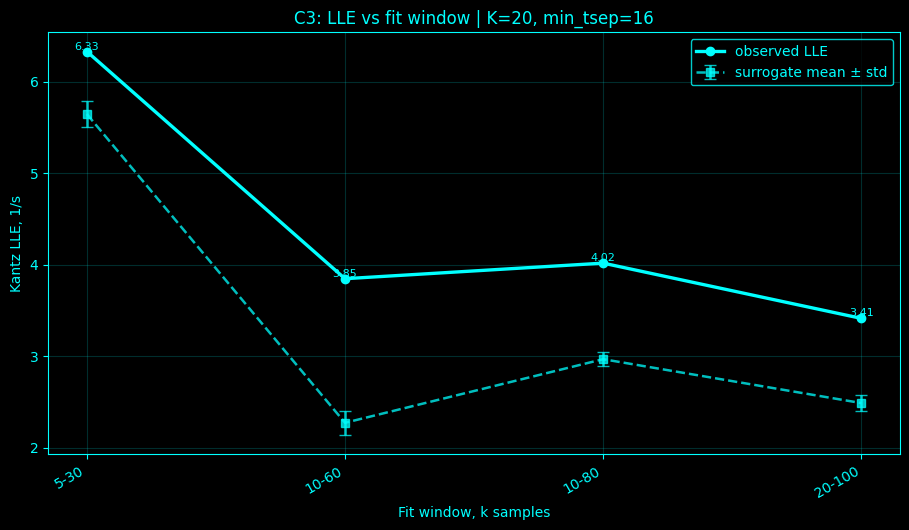

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/02_C3_LLE_by_window_K20_tsep16_C3_m10_tau8_nS70_20260915_120036.png


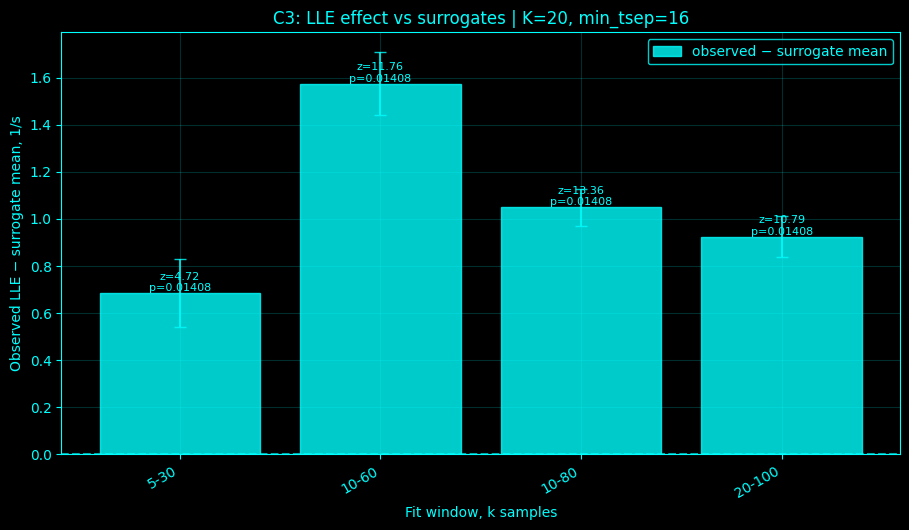

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/03_C3_effect_by_window_K20_tsep16_C3_m10_tau8_nS70_20260915_120036.png


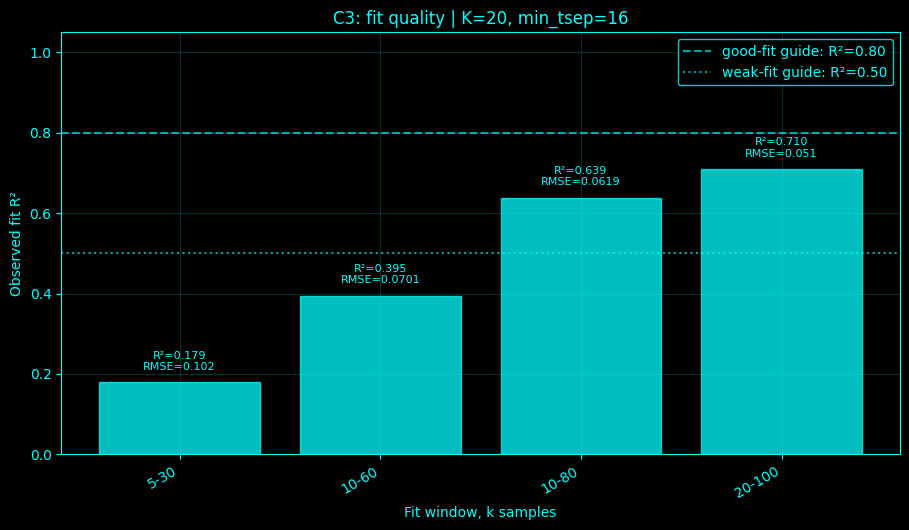

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/04_C3_fit_quality_K20_tsep16_C3_m10_tau8_nS70_20260915_120036.png


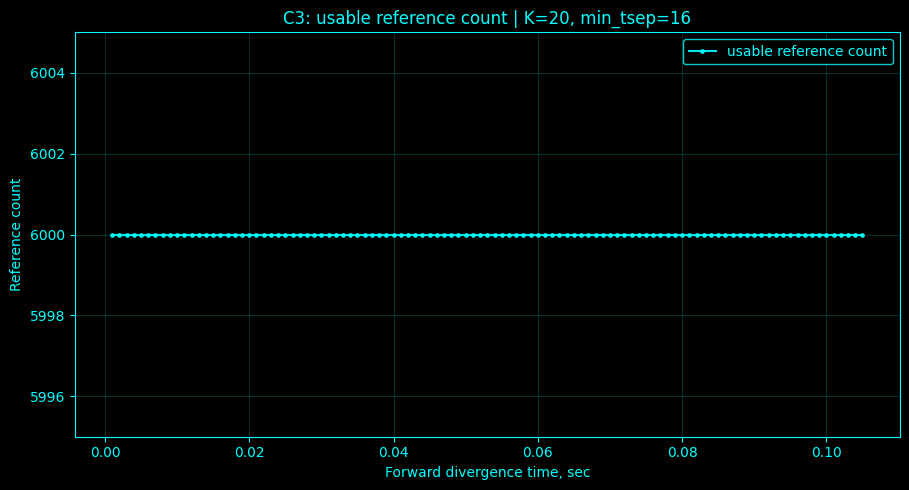

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/05_C3_counts_K20_tsep16_C3_m10_tau8_nS70_20260915_120036.png


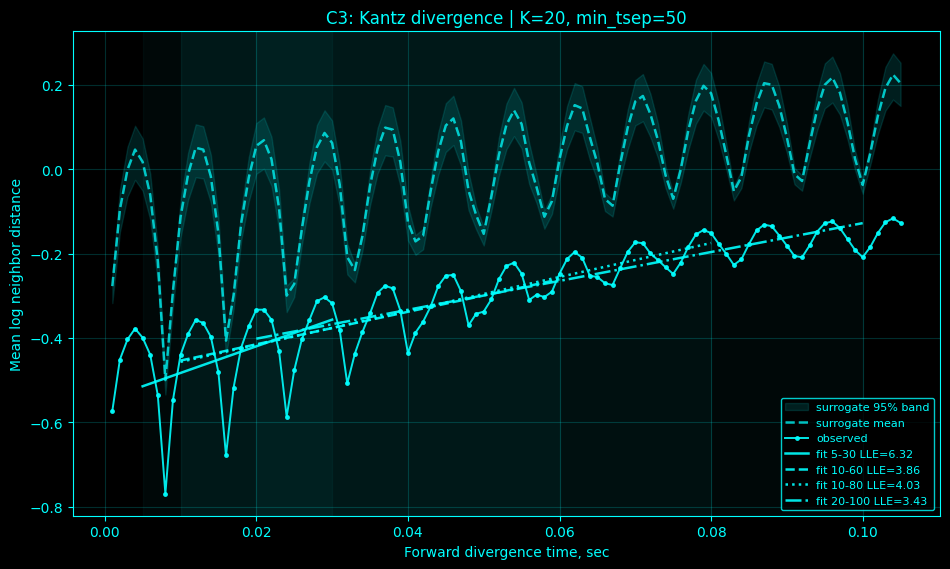

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/01_C3_divergence_K20_tsep50_C3_m10_tau8_nS70_20260915_120036.png


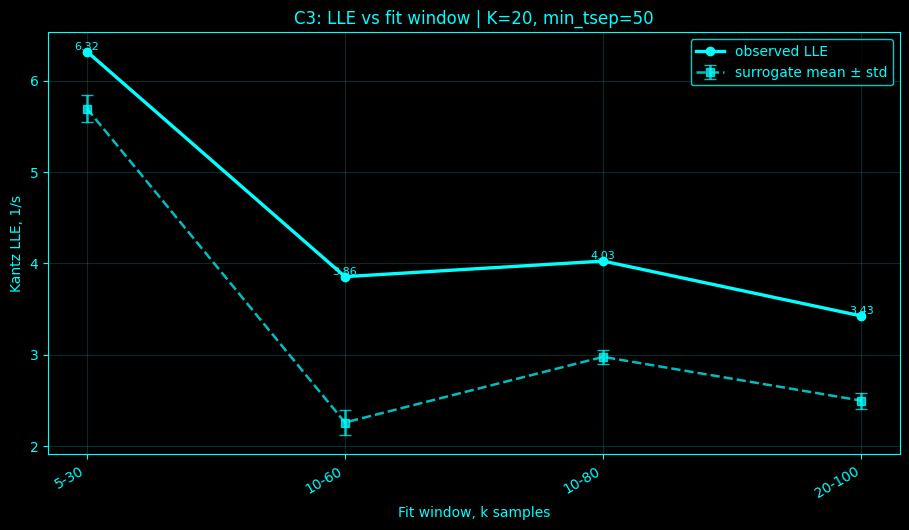

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/02_C3_LLE_by_window_K20_tsep50_C3_m10_tau8_nS70_20260915_120036.png


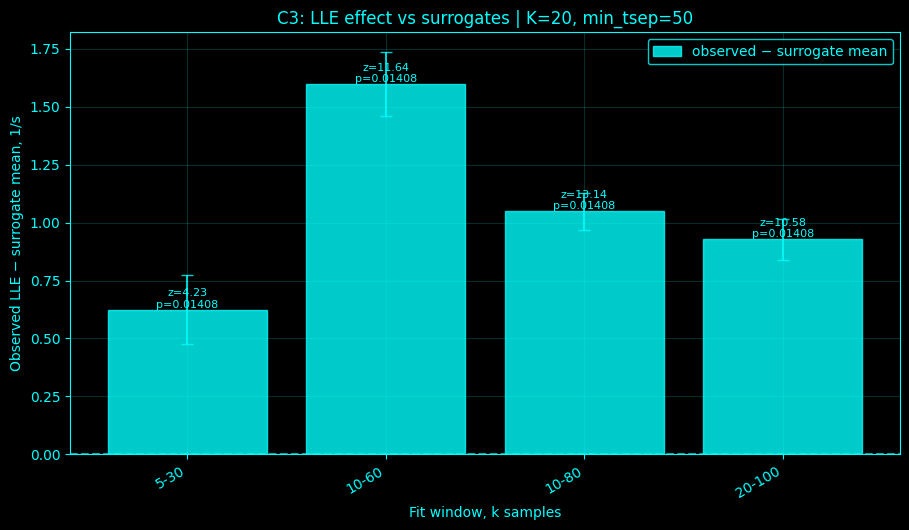

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/03_C3_effect_by_window_K20_tsep50_C3_m10_tau8_nS70_20260915_120036.png


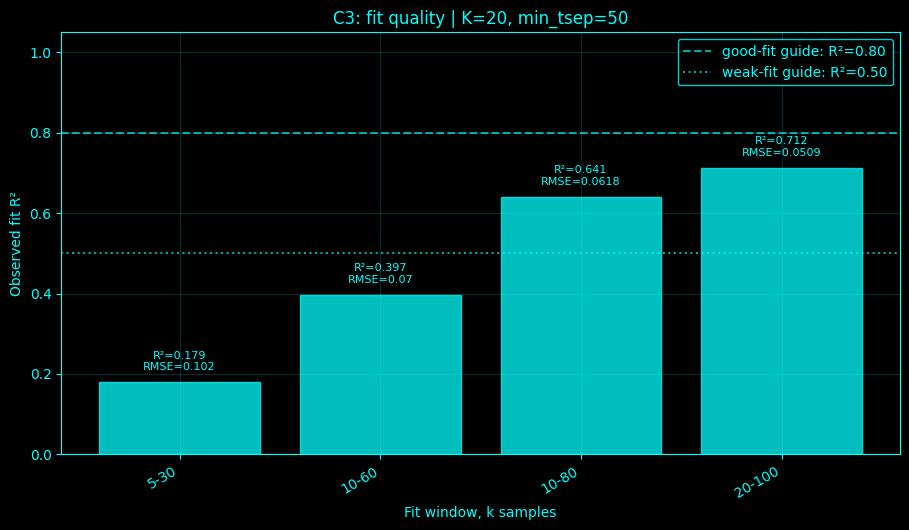

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/04_C3_fit_quality_K20_tsep50_C3_m10_tau8_nS70_20260915_120036.png


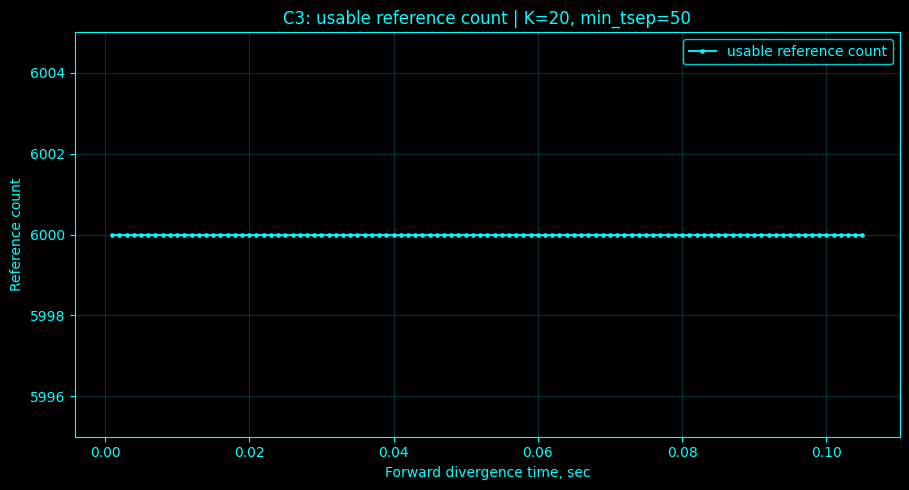

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/kantz_sweep_locked_window_fast/plots/05_C3_counts_K20_tsep50_C3_m10_tau8_nS70_20260915_120036.png

=== Fast Kantz sweep summary ===
channel  min_tsep  K_use  fit_lo  fit_hi window_label  LLE_obs  LLE_surr_mean  LLE_surr_std  LLE_surr_q025  LLE_surr_q975  delta_LLE  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  fit_r2_obs  fit_rmse_obs  slope_obs_per_sample  fit_intercept_obs  refs_used_obs  refs_requested  K_search_effective  fit_window_min_count  fit_window_median_count  n_surrogates_requested  n_surrogates_completed  n_surrogates_failed  fs_eff  emb_dim  tau_eff  kmax_eff  iaaft_iters  iaaft_tol
     C3         8     20       5      30         5-30 6.329819       5.645758      0.144851       5.434980       5.913057   0.684062             4.722522           0.014085        0.014085    0.178542      0.101830              0.006330          -0.547355           6000            6000                 100               

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000
segment = (814.571, 921.515)

emb_dim = 10
tau_original = 8

n_ref = 6000
K_search = 60
K_uses = [20]
# K_uses = [10, 20, 40]

min_tseps_original = [tau_original, 2 * tau_original, 50]
fit_windows_original = [(5, 30), (10, 60), (10, 80), (20, 100)]

n_surrogates = _speed_count(199, minimum=20)
iaaft_iters = 200
iaaft_tol = 1e-4
iaaft_min_iters = 80
iaaft_check_every = 20

seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = 1
max_samples = None
standardize = True
linear_detrend = False

eps = 1e-12

results_dir = os.path.join(base_dir, "results", "kantz_sweep_locked_window_fast")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"C3_m{emb_dim}_tau{tau_original}_nS{n_surrogates}_{timestamp}"

OUT_SUMMARY_CSV = os.path.join(results_dir, f"kantz_sweep_summary_{tag}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"kantz_sweep_surrogates_{tag}.csv")
OUT_CURVE_CSV = os.path.join(results_dir, f"kantz_sweep_curves_{tag}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"kantz_sweep_qc_{tag}.csv")
OUT_NPZ = os.path.join(results_dir, f"kantz_sweep_arrays_{tag}.npz")
OUT_TXT = os.path.join(results_dir, f"kantz_sweep_report_{tag}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for text in leg.get_texts():
            text.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))

def effective_window(win_original, decimate_factor, kmax_eff):
    lo = effective_sample_param(win_original[0], decimate_factor, minimum=1)
    hi = effective_sample_param(win_original[1], decimate_factor, minimum=lo + 5)
    hi = min(hi, kmax_eff - 1)
    if hi <= lo + 4:
        hi = min(kmax_eff - 1, lo + 5)
    return int(lo), int(hi)

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def pick_reference_indices(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(int(n_ref), last_ok + 1)
    refs = np.sort(rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False))
    return refs, last_ok

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=200, tol=1e-4, min_iter=80, check_every=20):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def fit_curve_window(ks, y, fit_lo, fit_hi, fs_eff):
    fit_lo = int(fit_lo)
    fit_hi = int(fit_hi)
    mask = (ks >= fit_lo) & (ks <= fit_hi) & np.isfinite(y)
    kfit = ks[mask]
    yfit = y[mask]
    if len(kfit) < 5:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    coef = np.polyfit(kfit, yfit, 1)
    yhat = np.polyval(coef, kfit)
    ss_res = float(np.sum((yfit - yhat) ** 2))
    ss_tot = float(np.sum((yfit - np.mean(yfit)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yfit - yhat) ** 2)))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def fit_all_windows(ks, y, windows, fs_eff):
    out = {}
    for win in windows:
        fit_lo, fit_hi = int(win[0]), int(win[1])
        slope, intercept, lle, r2, rmse = fit_curve_window(ks, y, fit_lo, fit_hi, fs_eff)
        out[(fit_lo, fit_hi)] = {
            "slope_per_sample": slope,
            "intercept": intercept,
            "LLE": lle,
            "fit_r2": r2,
            "fit_rmse": rmse,
        }
    return out

def kantz_curves_sweep_from_embedding(X, refs, min_tseps, K_uses, kmax, K_search, eps=1e-12):
    X = np.asarray(X, dtype=float)
    M, dim = X.shape
    kmax = int(kmax)
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        raise ValueError(f"No valid reference region: M={M}, kmax={kmax}")
    refs = np.asarray(refs, dtype=int)
    refs = refs[(refs >= 0) & (refs <= last_ok)]
    if len(refs) == 0:
        raise ValueError("No valid refs after last_ok filtering.")
    max_tsep = int(max(min_tseps))
    max_K = int(max(K_uses))
    k_query = min(M, max(int(K_search) + 1, max_K + max_tsep + 20, max_tsep + 50, 4 * dim + 20))
    nn = NearestNeighbors(n_neighbors=k_query, algorithm="auto").fit(X)
    _, idxs = nn.kneighbors(X[refs])
    ks = np.arange(1, kmax + 1, dtype=int)
    curves = {}
    counts = {}
    info = {}
    for min_tsep in min_tseps:
        min_tsep = int(min_tsep)
        candidate_sets = []
        for rr, i in enumerate(refs):
            cand = idxs[rr, 1:]
            cand = cand[np.abs(cand - i) > min_tsep]
            cand = cand[cand <= last_ok]
            if len(cand) >= 1:
                candidate_sets.append((int(i), cand.astype(int)))
        for K_use in K_uses:
            K_use = int(K_use)
            neighbor_sets = []
            for i, cand in candidate_sets:
                if len(cand) >= K_use:
                    neighbor_sets.append((i, cand[:K_use]))
            y_acc = np.zeros(kmax, dtype=float)
            k_counts = np.zeros(kmax, dtype=int)
            used_refs = 0
            if len(neighbor_sets) > 0:
                for i, neighs in neighbor_sets:
                    valid_neighs = neighs[neighs + kmax < M]
                    if len(valid_neighs) < K_use:
                        continue
                    valid_neighs = valid_neighs[:K_use]
                    Xi = X[i + ks]
                    Xj = X[valid_neighs[:, None] + ks[None, :]]
                    dif = Xj - Xi[None, :, :]
                    dist = np.linalg.norm(dif, axis=2)
                    y_acc += np.mean(np.log(dist + eps), axis=0)
                    k_counts += 1
                    used_refs += 1
            if used_refs == 0:
                y_mean = np.full(kmax, np.nan, dtype=float)
            else:
                y_mean = y_acc / float(used_refs)
            key = (min_tsep, K_use)
            curves[key] = y_mean
            counts[key] = k_counts
            info[key] = {
                "M": int(M),
                "last_ok": int(last_ok),
                "refs_requested": int(len(refs)),
                "refs_used": int(used_refs),
                "min_tsep": int(min_tsep),
                "K_use": int(K_use),
                "K_search_effective": int(k_query),
                "neighbor_fail": bool(used_refs == 0),
            }
    return ks, curves, counts, info

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_high = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two_centered = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_high, p_two_centered

tau_eff = effective_sample_param(tau_original, decimate_factor, minimum=1)
min_tseps_eff = sorted(set([effective_sample_param(v, decimate_factor, minimum=1) for v in min_tseps_original]))
kmax_eff = effective_sample_param(max(hi for _, hi in fit_windows_original) + 5, decimate_factor, minimum=20)
fit_windows_eff = [effective_window(w, decimate_factor, kmax_eff) for w in fit_windows_original]
fit_windows_eff = sorted(set(fit_windows_eff), key=lambda w: (w[0], w[1]))

print("Effective parameters:")
print("  decimate_factor:", decimate_factor)
print("  tau_eff:", tau_eff)
print("  min_tseps_eff:", min_tseps_eff)
print("  K_uses:", K_uses)
print("  kmax_eff:", kmax_eff)
print("  fit_windows_eff:", fit_windows_eff)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)

summary_records = []
surrogate_records = []
curve_records = []
qc_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "K_uses": np.array(K_uses, dtype=int),
    "min_tseps_eff": np.array(min_tseps_eff, dtype=int),
    "fit_windows_eff": np.array(fit_windows_eff, dtype=int),
    "tau_eff": np.array([tau_eff], dtype=int),
    "kmax_eff": np.array([kmax_eff], dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([decimate_factor], dtype=int),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)
    ch_i = channel_names.index(channel)
    start_idx = int(segment[0] * fs_original)
    end_idx = int(segment[1] * fs_original)
    x_raw = EEG[start_idx:end_idx, ch_i].astype(float)
    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )
    print(f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | segment={segment}", flush=True)
    Xobs = delay_embed_1d(x, m=emb_dim, tau=tau_eff)
    rng_refs = np.random.default_rng(seed)
    refs, last_ok = pick_reference_indices(M=len(Xobs), kmax=kmax_eff, n_ref=n_ref, rng=rng_refs)
    if len(refs) == 0:
        raise ValueError("No valid refs. kmax may be too large.")
    print(f"Embedded M={len(Xobs)} | refs={len(refs)} | last_ok={last_ok}", flush=True)
    ks_obs, obs_curves, obs_counts, obs_info = kantz_curves_sweep_from_embedding(
        Xobs,
        refs=refs,
        min_tseps=min_tseps_eff,
        K_uses=K_uses,
        kmax=kmax_eff,
        K_search=K_search,
        eps=eps
    )
    obs_fits = {}
    for key, y_obs in obs_curves.items():
        obs_fits[key] = fit_all_windows(ks_obs, y_obs, fit_windows_eff, fs_eff)
    print("\nObserved fits:", flush=True)
    for min_tsep in min_tseps_eff:
        for K_use in K_uses:
            key = (int(min_tsep), int(K_use))
            info = obs_info[key]
            for win in fit_windows_eff:
                fit = obs_fits[key][win]
                print(
                    f"  K={K_use} tsep={min_tsep} win={win[0]}-{win[1]} | "
                    f"LLE={fit['LLE']:.6g} | R2={fit['fit_r2']:.4f} | refs={info['refs_used']}",
                    flush=True
                )
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)
    surr_lle = {}
    surr_curves = {}
    for min_tsep in min_tseps_eff:
        for K_use in K_uses:
            key = (int(min_tsep), int(K_use))
            surr_curves[key] = []
            for win in fit_windows_eff:
                surr_lle[(int(min_tsep), int(K_use), int(win[0]), int(win[1]))] = []
    surr_errors = []
    surr_iters = []
    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 10000 * ch_num + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )
        Xs = delay_embed_1d(y, m=emb_dim, tau=tau_eff)
        ks_s, curves_s, counts_s, info_s = kantz_curves_sweep_from_embedding(
            Xs,
            refs=refs,
            min_tseps=min_tseps_eff,
            K_uses=K_uses,
            kmax=kmax_eff,
            K_search=K_search,
            eps=eps
        )
        out = {
            "surrogate_index": int(s + 1),
            "iaaft_error": float(final_err),
            "iaaft_iters_used": int(used_iters),
            "curves": curves_s,
            "counts": counts_s,
            "info": info_s,
            "fits": {},
        }
        for key, curve in curves_s.items():
            out["fits"][key] = fit_all_windows(ks_s, curve, fit_windows_eff, fs_eff)
        return out
    print(f"\nRunning {n_surrogates} IAAFT surrogates with {n_workers} workers...", flush=True)
    completed = 0
    failed = 0
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(surrogate_worker, s) for s in range(n_surrogates)]
        for fut in as_completed(futures):
            try:
                res = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue
            completed += 1
            sidx = int(res["surrogate_index"])
            surr_errors.append(res["iaaft_error"])
            surr_iters.append(res["iaaft_iters_used"])
            for min_tsep in min_tseps_eff:
                for K_use in K_uses:
                    key = (int(min_tsep), int(K_use))
                    surr_curves[key].append(res["curves"][key])
                    for win in fit_windows_eff:
                        fit = res["fits"][key][win]
                        row_key = (int(min_tsep), int(K_use), int(win[0]), int(win[1]))
                        surr_lle[row_key].append(fit["LLE"])
                        surrogate_records.append({
                            "channel": channel,
                            "surrogate_index": sidx,
                            "min_tsep": int(min_tsep),
                            "K_use": int(K_use),
                            "fit_lo": int(win[0]),
                            "fit_hi": int(win[1]),
                            "window_label": f"{win[0]}-{win[1]}",
                            "LLE_surr": float(fit["LLE"]),
                            "slope_per_sample": float(fit["slope_per_sample"]),
                            "intercept": float(fit["intercept"]),
                            "fit_r2": float(fit["fit_r2"]),
                            "fit_rmse": float(fit["fit_rmse"]),
                            "refs_used": int(res["info"][key]["refs_used"]),
                            "K_search_effective": int(res["info"][key]["K_search_effective"]),
                            "iaaft_final_spectrum_relative_error": float(res["iaaft_error"]),
                            "iaaft_iters_used": int(res["iaaft_iters_used"]),
                        })
            if completed % 25 == 0 or completed + failed == n_surrogates:
                print(f"  completed {completed}/{n_surrogates} surrogates | failed={failed}", flush=True)
    for min_tsep in min_tseps_eff:
        for K_use in K_uses:
            key = (int(min_tsep), int(K_use))
            y_obs = obs_curves[key]
            count_obs = obs_counts[key]
            info = obs_info[key]
            curve_stack = np.asarray(surr_curves[key], dtype=float)
            for win in fit_windows_eff:
                fit_obs = obs_fits[key][win]
                obs_val = float(fit_obs["LLE"])
                row_key = (int(min_tsep), int(K_use), int(win[0]), int(win[1]))
                vals = np.asarray(surr_lle[row_key], dtype=float)
                vals = vals[np.isfinite(vals)]
                if len(vals) > 0:
                    z, p_one, p_two = empirical_p_values(obs_val, vals)
                    s_mean = float(np.mean(vals))
                    s_std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
                    s_q025 = float(np.percentile(vals, 2.5))
                    s_q975 = float(np.percentile(vals, 97.5))
                else:
                    z, p_one, p_two = np.nan, np.nan, np.nan
                    s_mean, s_std, s_q025, s_q975 = np.nan, np.nan, np.nan, np.nan
                fit_mask = (ks_obs >= win[0]) & (ks_obs <= win[1])
                fit_counts = count_obs[fit_mask]
                summary_records.append({
                    "channel": channel,
                    "min_tsep": int(min_tsep),
                    "K_use": int(K_use),
                    "fit_lo": int(win[0]),
                    "fit_hi": int(win[1]),
                    "window_label": f"{win[0]}-{win[1]}",
                    "LLE_obs": obs_val,
                    "LLE_surr_mean": s_mean,
                    "LLE_surr_std": s_std,
                    "LLE_surr_q025": s_q025,
                    "LLE_surr_q975": s_q975,
                    "delta_LLE": float(obs_val - s_mean) if np.isfinite(s_mean) else np.nan,
                    "z_obs_vs_surrogates": float(z),
                    "p_one_surr_ge_obs": float(p_one),
                    "p_two_centered": float(p_two),
                    "fit_r2_obs": float(fit_obs["fit_r2"]),
                    "fit_rmse_obs": float(fit_obs["fit_rmse"]),
                    "slope_obs_per_sample": float(fit_obs["slope_per_sample"]),
                    "fit_intercept_obs": float(fit_obs["intercept"]),
                    "refs_used_obs": int(info["refs_used"]),
                    "refs_requested": int(info["refs_requested"]),
                    "K_search_effective": int(info["K_search_effective"]),
                    "fit_window_min_count": int(np.nanmin(fit_counts)) if len(fit_counts) else -1,
                    "fit_window_median_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
                    "n_surrogates_requested": int(n_surrogates),
                    "n_surrogates_completed": int(len(vals)),
                    "n_surrogates_failed": int(failed),
                    "fs_eff": float(fs_eff),
                    "emb_dim": int(emb_dim),
                    "tau_eff": int(tau_eff),
                    "kmax_eff": int(kmax_eff),
                    "iaaft_iters": int(iaaft_iters),
                    "iaaft_tol": float(iaaft_tol),
                })
            for i, k in enumerate(ks_obs):
                rec = {
                    "channel": channel,
                    "min_tsep": int(min_tsep),
                    "K_use": int(K_use),
                    "k": int(k),
                    "time_seconds": float(k / fs_eff),
                    "observed_log_distance": float(y_obs[i]),
                    "observed_count": int(count_obs[i]),
                }
                if curve_stack.size > 0 and curve_stack.ndim == 2:
                    rec.update({
                        "surrogate_mean_log_distance": float(np.nanmean(curve_stack[:, i])),
                        "surrogate_std_log_distance": float(np.nanstd(curve_stack[:, i])),
                        "surrogate_q025_log_distance": float(np.nanpercentile(curve_stack[:, i], 2.5)),
                        "surrogate_q975_log_distance": float(np.nanpercentile(curve_stack[:, i], 97.5)),
                    })
                else:
                    rec.update({
                        "surrogate_mean_log_distance": np.nan,
                        "surrogate_std_log_distance": np.nan,
                        "surrogate_q025_log_distance": np.nan,
                        "surrogate_q975_log_distance": np.nan,
                    })
                curve_records.append(rec)
            npz_payload[f"{channel}_obs_curve_tsep{min_tsep}_K{K_use}"] = y_obs
            npz_payload[f"{channel}_obs_counts_tsep{min_tsep}_K{K_use}"] = count_obs
            if curve_stack.size > 0:
                npz_payload[f"{channel}_surr_curves_tsep{min_tsep}_K{K_use}"] = curve_stack
    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "embedded_M": int(len(Xobs)),
        "refs_used": int(len(refs)),
        "last_ok": int(last_ok),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
        "max_iaaft_iters_used": int(np.max(surr_iters)) if len(surr_iters) else -1,
        "surrogates_completed": int(completed),
        "surrogates_failed": int(failed),
    })
    npz_payload[f"{channel}_ks"] = ks_obs
    npz_payload[f"{channel}_refs"] = refs
    summary_ch = pd.DataFrame([r for r in summary_records if r["channel"] == channel])
    for min_tsep in min_tseps_eff:
        for K_use in K_uses:
            key = (int(min_tsep), int(K_use))
            sub = summary_ch[
                (summary_ch["min_tsep"] == int(min_tsep)) &
                (summary_ch["K_use"] == int(K_use))
            ].sort_values(["fit_lo", "fit_hi"]).copy()
            if len(sub) == 0:
                continue
            curve_stack = np.asarray(surr_curves[key], dtype=float)
            y_obs = obs_curves[key]
            fig, ax = plt.subplots(figsize=(9.6, 5.8), facecolor=BG)
            style_ax(ax)
            if curve_stack.size > 0 and curve_stack.ndim == 2:
                s_mean = np.nanmean(curve_stack, axis=0)
                s_q025 = np.nanpercentile(curve_stack, 2.5, axis=0)
                s_q975 = np.nanpercentile(curve_stack, 97.5, axis=0)
                ax.fill_between(ks_obs / fs_eff, s_q025, s_q975, color=ACCENT, alpha=0.12, label="surrogate 95% band")
                ax.plot(ks_obs / fs_eff, s_mean, color=ACCENT, linestyle="--", linewidth=1.8, alpha=0.75, label="surrogate mean")
            ax.plot(ks_obs / fs_eff, y_obs, color=ACCENT, marker="o", markersize=2.5, linewidth=1.4, alpha=0.9, label="observed")
            linestyles = ["-", "--", ":", "-."]
            for wi, win in enumerate(fit_windows_eff):
                fit = obs_fits[key][win]
                kfit = ks_obs[(ks_obs >= win[0]) & (ks_obs <= win[1])]
                yfit = fit["slope_per_sample"] * kfit + fit["intercept"]
                ax.plot(kfit / fs_eff, yfit, color=ACCENT, linestyle=linestyles[wi % len(linestyles)], linewidth=1.8, alpha=0.9, label=f"fit {win[0]}-{win[1]} LLE={fit['LLE']:.2f}")
                ax.axvspan(win[0] / fs_eff, win[1] / fs_eff, color=ACCENT, alpha=0.035)
            ax.set_title(f"{channel}: Kantz divergence | K={K_use}, min_tsep={min_tsep}")
            ax.set_xlabel("Forward divergence time, sec")
            ax.set_ylabel("Mean log neighbor distance")
            leg = ax.legend(loc="best", fontsize=8)
            style_legend(leg)
            plot_path = os.path.join(plots_dir, f"01_{channel}_divergence_K{K_use}_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)
            xpos = np.arange(len(sub))
            labels = sub["window_label"].values
            fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
            style_ax(ax)
            ax.errorbar(
                xpos,
                sub["LLE_surr_mean"],
                yerr=sub["LLE_surr_std"],
                color=ACCENT,
                linestyle="--",
                marker="s",
                capsize=4,
                linewidth=1.8,
                alpha=0.75,
                label="surrogate mean ± std"
            )
            ax.plot(
                xpos,
                sub["LLE_obs"],
                color=ACCENT,
                marker="o",
                linewidth=2.4,
                label="observed LLE"
            )
            for i, row in sub.reset_index(drop=True).iterrows():
                ax.text(i, row["LLE_obs"], f"{row['LLE_obs']:.2f}", color=ACCENT, ha="center", va="bottom", fontsize=8)
            ax.set_xticks(xpos)
            ax.set_xticklabels(labels, rotation=30, ha="right")
            ax.set_title(f"{channel}: LLE vs fit window | K={K_use}, min_tsep={min_tsep}")
            ax.set_xlabel("Fit window, k samples")
            ax.set_ylabel("Kantz LLE, 1/s")
            leg = ax.legend()
            style_legend(leg)
            plot_path = os.path.join(plots_dir, f"02_{channel}_LLE_by_window_K{K_use}_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)
            fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
            style_ax(ax)
            ax.bar(
                xpos,
                sub["delta_LLE"],
                color=ACCENT,
                edgecolor=ACCENT,
                alpha=0.8,
                label="observed − surrogate mean"
            )
            ax.errorbar(
                xpos,
                sub["delta_LLE"],
                yerr=sub["LLE_surr_std"],
                fmt="none",
                ecolor=ACCENT,
                elinewidth=1.5,
                capsize=4,
                alpha=0.8
            )
            ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)
            for i, row in sub.reset_index(drop=True).iterrows():
                ax.text(
                    i,
                    row["delta_LLE"],
                    f"z={row['z_obs_vs_surrogates']:.2f}\np={row['p_one_surr_ge_obs']:.4g}",
                    color=ACCENT,
                    ha="center",
                    va="bottom" if row["delta_LLE"] >= 0 else "top",
                    fontsize=8
                )
            ax.set_xticks(xpos)
            ax.set_xticklabels(labels, rotation=30, ha="right")
            ax.set_title(f"{channel}: LLE effect vs surrogates | K={K_use}, min_tsep={min_tsep}")
            ax.set_xlabel("Fit window, k samples")
            ax.set_ylabel("Observed LLE − surrogate mean, 1/s")
            leg = ax.legend()
            style_legend(leg)
            plot_path = os.path.join(plots_dir, f"03_{channel}_effect_by_window_K{K_use}_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)
            fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
            style_ax(ax)
            ax.bar(xpos, sub["fit_r2_obs"], color=ACCENT, edgecolor=ACCENT, alpha=0.75)
            ax.axhline(0.80, color=ACCENT, linestyle="--", alpha=0.65, label="good-fit guide: R²=0.80")
            ax.axhline(0.50, color=ACCENT, linestyle=":", alpha=0.65, label="weak-fit guide: R²=0.50")
            for i, row in sub.reset_index(drop=True).iterrows():
                ax.text(i, row["fit_r2_obs"] + 0.025, f"R²={row['fit_r2_obs']:.3f}\nRMSE={row['fit_rmse_obs']:.3g}", color=ACCENT, ha="center", va="bottom", fontsize=8)
            ax.set_xticks(xpos)
            ax.set_xticklabels(labels, rotation=30, ha="right")
            ax.set_ylim(0, 1.05)
            ax.set_title(f"{channel}: fit quality | K={K_use}, min_tsep={min_tsep}")
            ax.set_xlabel("Fit window, k samples")
            ax.set_ylabel("Observed fit R²")
            leg = ax.legend()
            style_legend(leg)
            plot_path = os.path.join(plots_dir, f"04_{channel}_fit_quality_K{K_use}_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)
            fig, ax = plt.subplots(figsize=(9.2, 5.0), facecolor=BG)
            style_ax(ax)
            ax.plot(
                ks_obs / fs_eff,
                obs_counts[key],
                color=ACCENT,
                marker="o",
                markersize=2.4,
                linewidth=1.5,
                alpha=0.9,
                label="usable reference count"
            )
            cmin = float(np.nanmin(obs_counts[key]))
            cmax = float(np.nanmax(obs_counts[key]))
            pad = max(5.0, 0.03 * max(abs(cmax - cmin), 1.0))
            ax.set_ylim(cmin - pad, cmax + pad)
            ax.set_title(f"{channel}: usable reference count | K={K_use}, min_tsep={min_tsep}")
            ax.set_xlabel("Forward divergence time, sec")
            ax.set_ylabel("Reference count")
            leg = ax.legend()
            style_legend(leg)
            plot_path = os.path.join(plots_dir, f"05_{channel}_counts_K{K_use}_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVE_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast Kantz Sweep with Locked Fit Windows and IAAFT Surrogates\n")
    f.write("============================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment={segment}\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"emb_dim={emb_dim}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"K_uses={K_uses}\n")
    f.write(f"min_tseps_eff={min_tseps_eff}\n")
    f.write(f"fit_windows_eff={fit_windows_eff}\n")
    f.write(f"kmax_eff={kmax_eff}\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"K_search={K_search}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

print("\n=== Fast Kantz sweep summary ===")
print(summary_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVE_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Robustness grid for LLE vs (tau, m) with IAAFT surrogate comparison

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Rosenstein/Kantz LLE robustness grid with IAAFT surrogates</h3><p>Rosenstein uses one temporally admissible nearest neighbor per reference state, whereas Kantz averages a neighborhood. This cell compares both constructions over a parameter grid and against IAAFT nulls.</p><p>Agreement between methods and across reasonable parameter choices is a robustness diagnostic; disagreement is scientifically informative and should not be hidden by selecting the most favorable cell of the grid.</p><p><b>Cell role.</b> The code reports both observed slopes and surrogate comparisons.</p></div>

$$D_R(k)=\langle\log\|X_{i+k}-X_{j(i)+k}\|\rangle_i,$$

$$D_K(k)=\left\langle\log\left[\frac1{|\mathcal N_i|}\sum_{j\in\mathcal N_i}\|X_{i+k}-X_{j+k}\|\right]\right\rangle_i.$$

Configuration:
  CHANNELS: ['C3']
  taus: [6, 8, 10, 12]
  ms: [8, 10, 12]
  fit_window_sec: (0.01, 0.06)
  n_surrogates: 20
  iaaft_iters: 200
  n_workers: 6
  results_dir: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325

[1/1] Loaded C3: N=106944 | fs_eff=1000 Hz
Locked fit window: k=[10,60] sec=[0.0100,0.0600]
kmax_ros=70 | kmax_kan=70

Generating IAAFT surrogates once for tau=6...
  tau=6: generated 10/20 surrogates | failed=0
  tau=6: generated 20/20 surrogates | failed=0
tau=6: completed=20, failed=0

Generating IAAFT surrogates once for tau=8...
  tau=8: generated 10/20 surrogates | failed=0
  tau=8: generated 20/20 surrogates | failed=0
tau=8: completed=20, failed=0

Generating IAAFT surrogates once for tau=10...
  tau=10: generated 10/20 surrogates | failed=0
  tau=10: generated 20/20 surrogates | failed=0
tau=10: completed=20, failed=0

Generating IAAFT surrogates once for tau=12...
  tau=12: generated 10/20 surrogates | faile

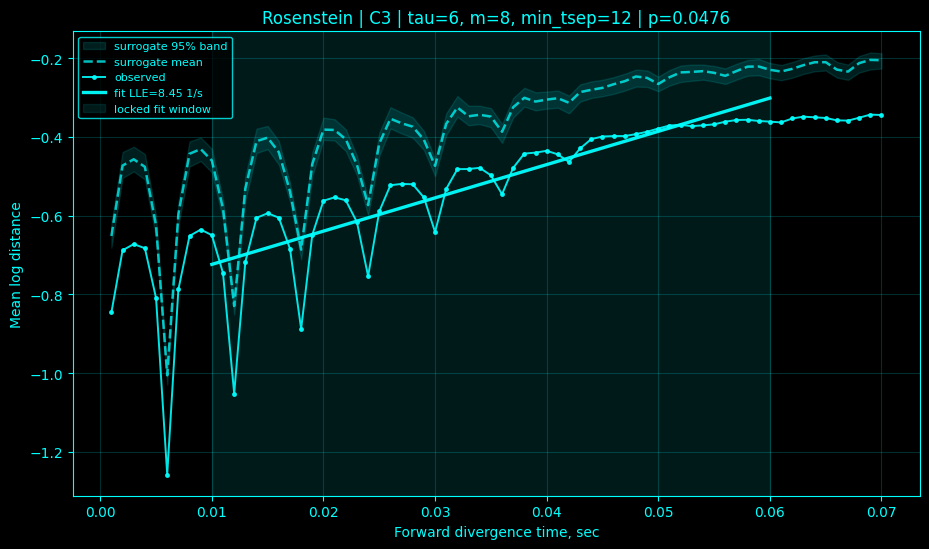

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau6_m8_divergence_20260915_120325.png


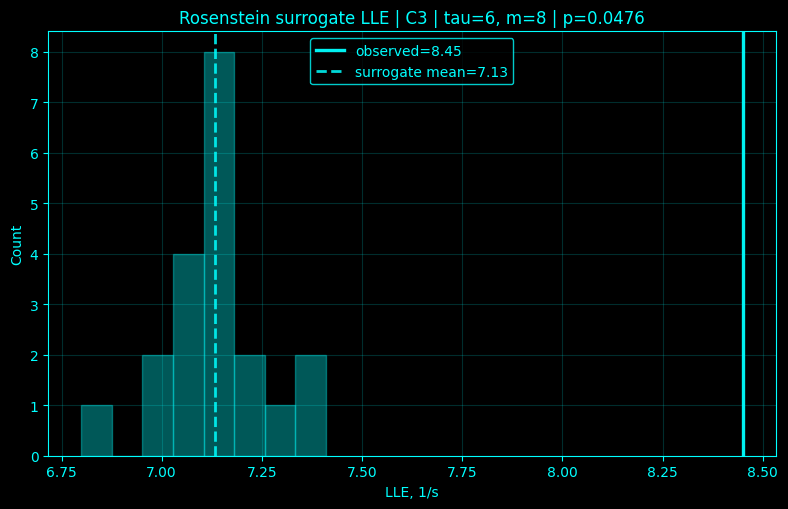

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau6_m8_hist_20260915_120325.png


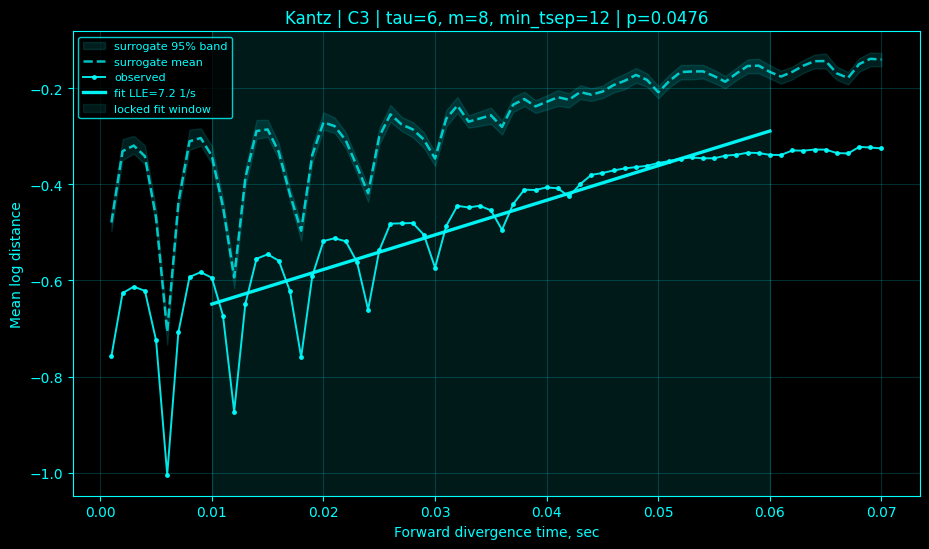

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau6_m8_divergence_20260915_120325.png


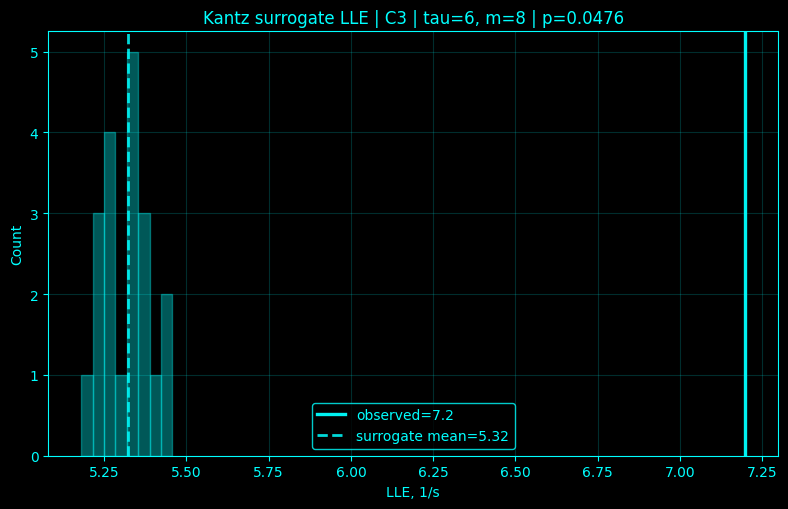

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau6_m8_hist_20260915_120325.png

Grid point: channel=C3 tau=6 m=10 min_tsep=12
  Observed Rosenstein: LLE=7.84992 | R2=0.7081 | refs=6000
  Observed Kantz:      LLE=6.33082 | R2=0.7484 | refs=6000
  tau=6 m=10: processed 10/20 surrogate curves | failed=0
  tau=6 m=10: processed 20/20 surrogate curves | failed=0


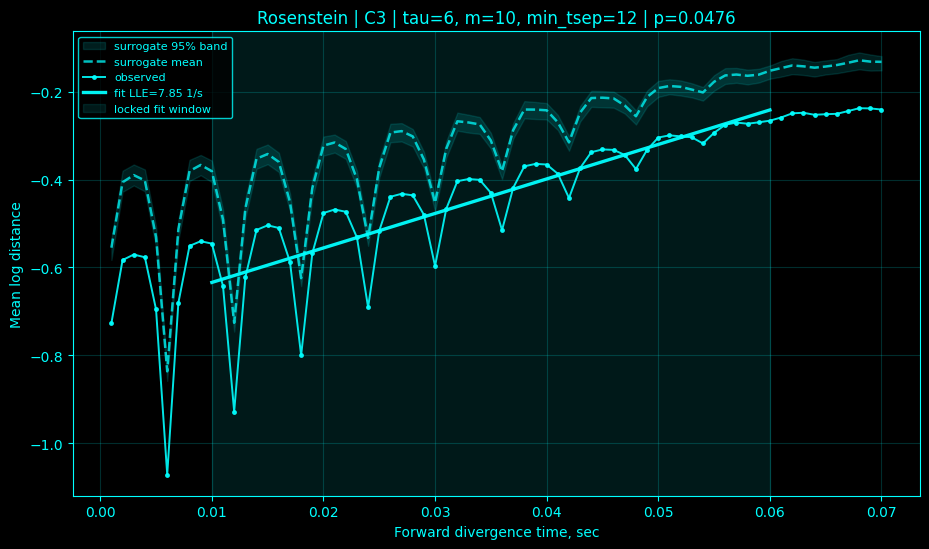

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau6_m10_divergence_20260915_120325.png


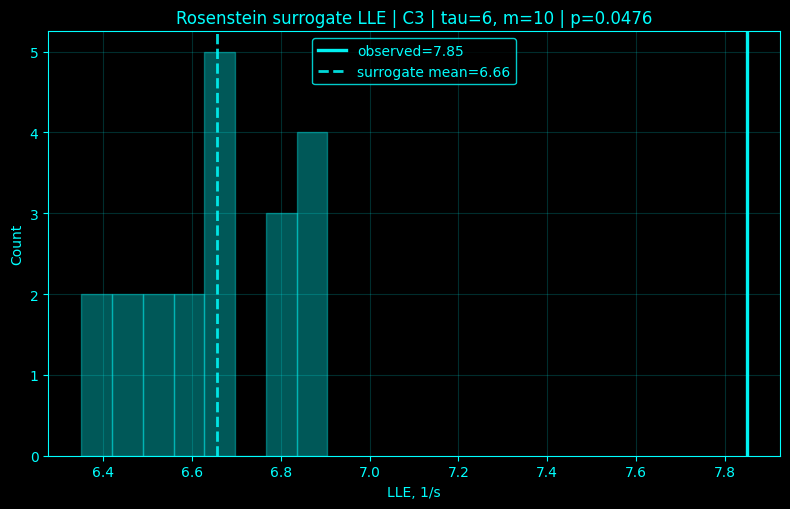

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau6_m10_hist_20260915_120325.png


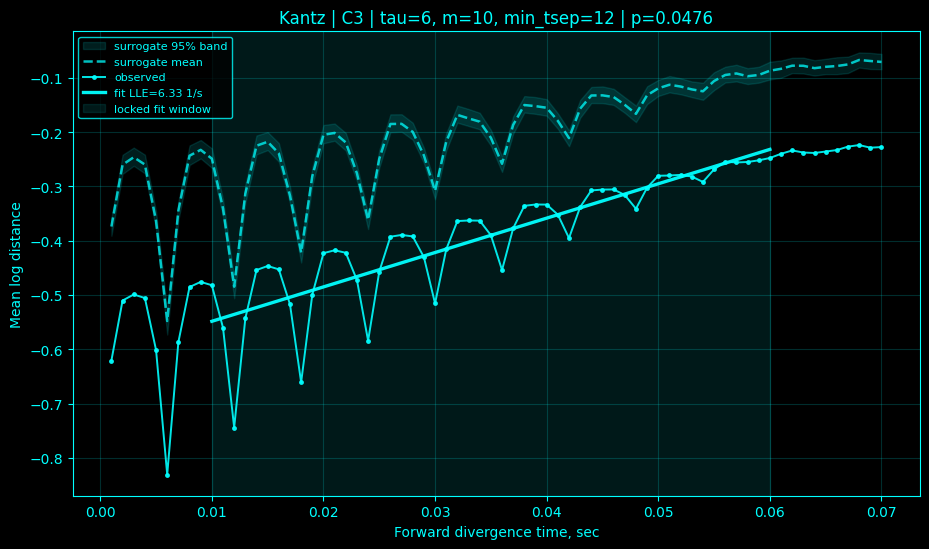

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau6_m10_divergence_20260915_120325.png


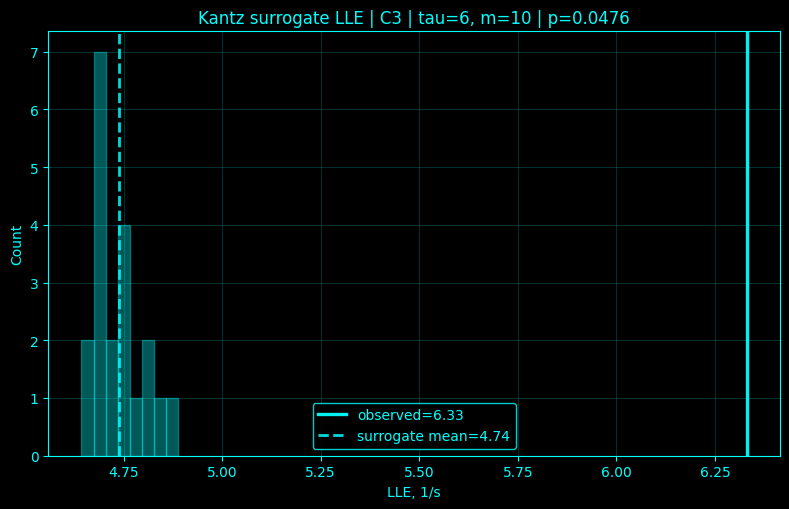

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau6_m10_hist_20260915_120325.png

Grid point: channel=C3 tau=6 m=12 min_tsep=12
  Observed Rosenstein: LLE=6.56529 | R2=0.6188 | refs=6000
  Observed Kantz:      LLE=5.23197 | R2=0.6682 | refs=6000
  tau=6 m=12: processed 10/20 surrogate curves | failed=0
  tau=6 m=12: processed 20/20 surrogate curves | failed=0


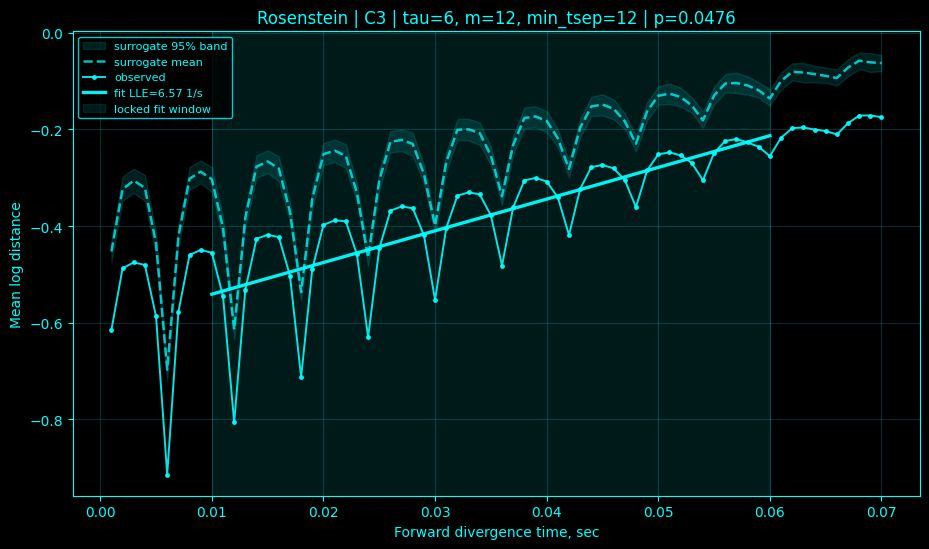

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau6_m12_divergence_20260915_120325.png


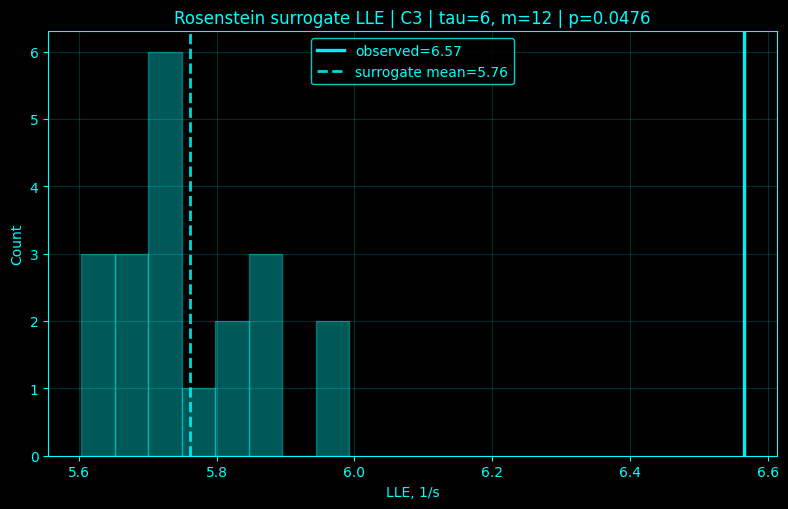

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau6_m12_hist_20260915_120325.png


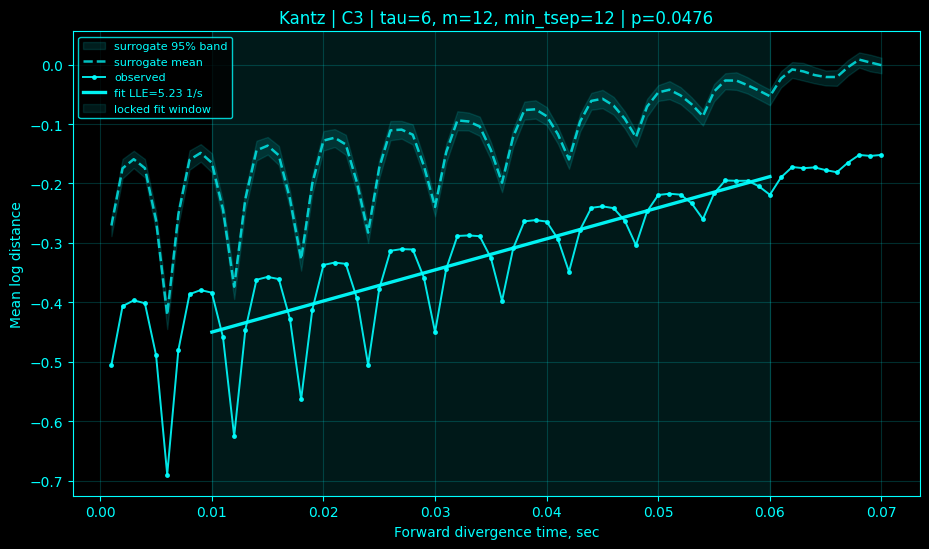

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau6_m12_divergence_20260915_120325.png


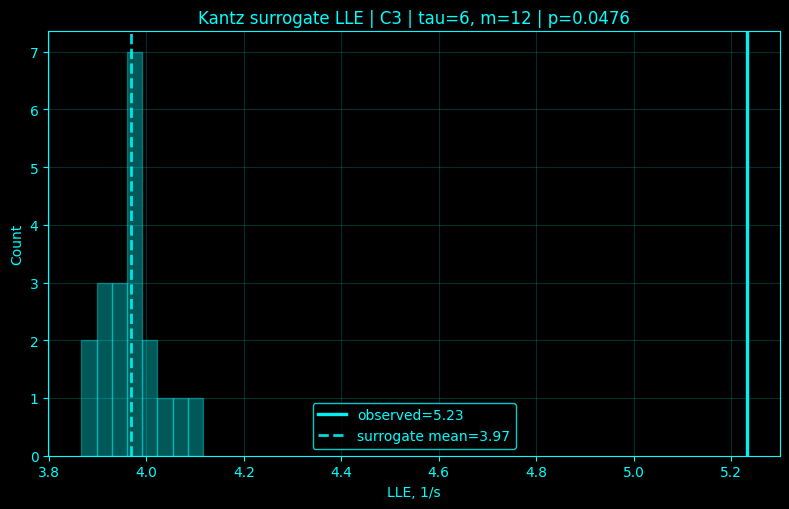

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau6_m12_hist_20260915_120325.png

Grid point: channel=C3 tau=8 m=8 min_tsep=16
  Observed Rosenstein: LLE=5.94519 | R2=0.4483 | refs=6000
  Observed Kantz:      LLE=4.84191 | R2=0.4202 | refs=6000
  tau=8 m=8: processed 10/20 surrogate curves | failed=0
  tau=8 m=8: processed 20/20 surrogate curves | failed=0


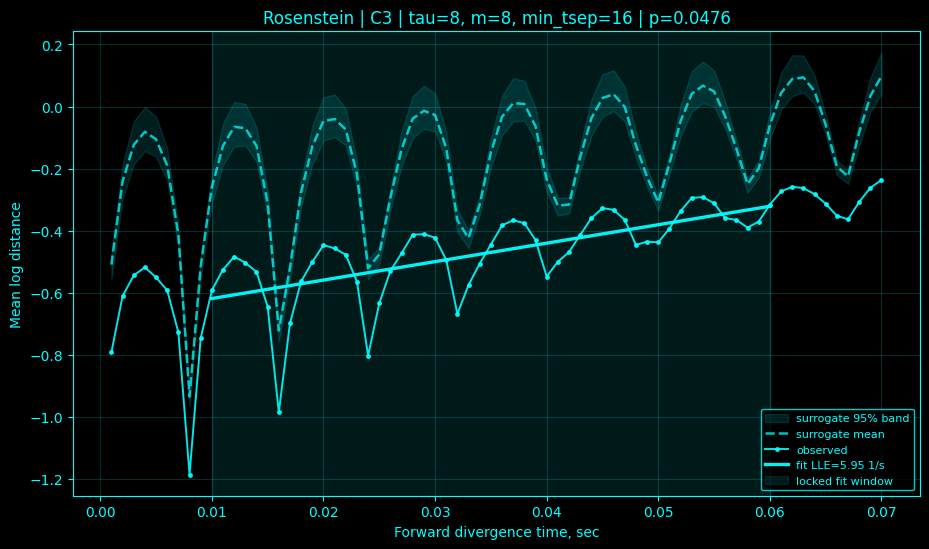

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau8_m8_divergence_20260915_120325.png


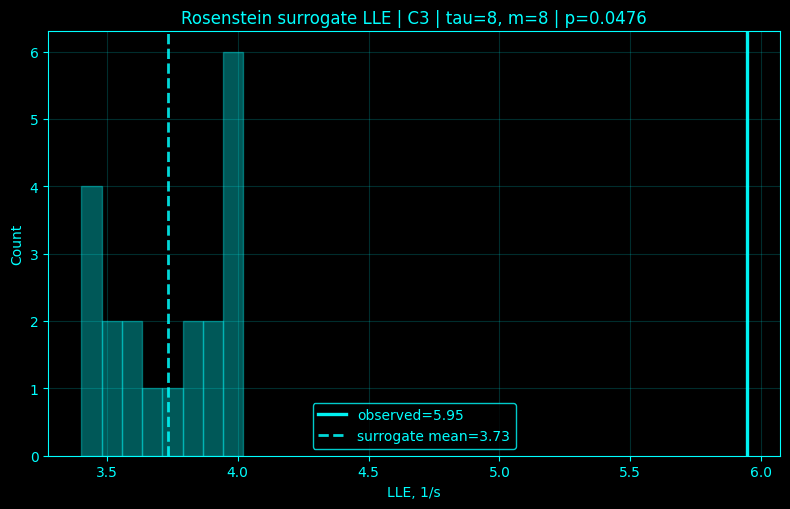

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau8_m8_hist_20260915_120325.png


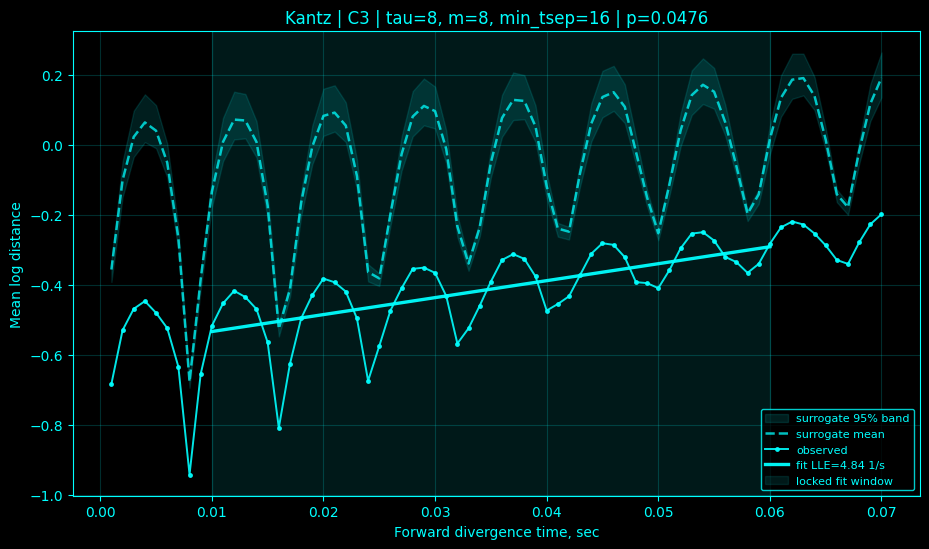

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau8_m8_divergence_20260915_120325.png


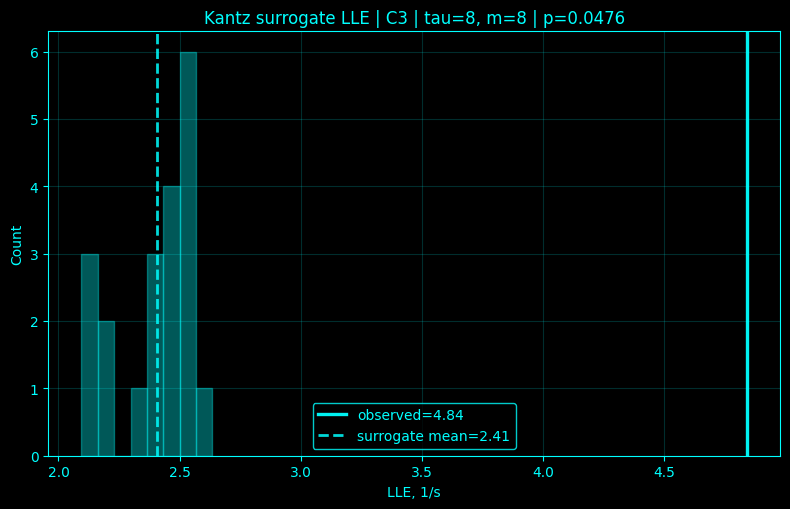

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau8_m8_hist_20260915_120325.png

Grid point: channel=C3 tau=8 m=10 min_tsep=16
  Observed Rosenstein: LLE=4.94521 | R2=0.4086 | refs=6000
  Observed Kantz:      LLE=3.94026 | R2=0.4131 | refs=6000
  tau=8 m=10: processed 10/20 surrogate curves | failed=0
  tau=8 m=10: processed 20/20 surrogate curves | failed=0


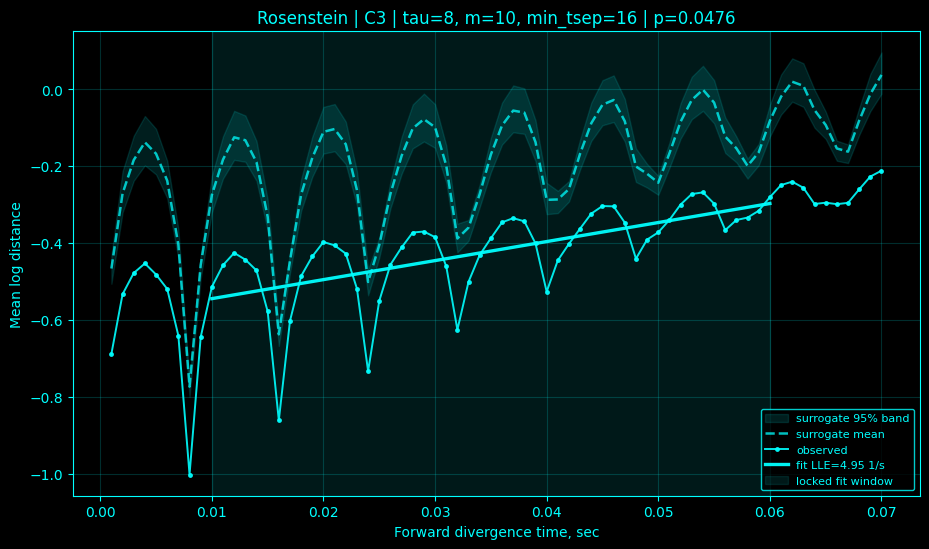

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau8_m10_divergence_20260915_120325.png


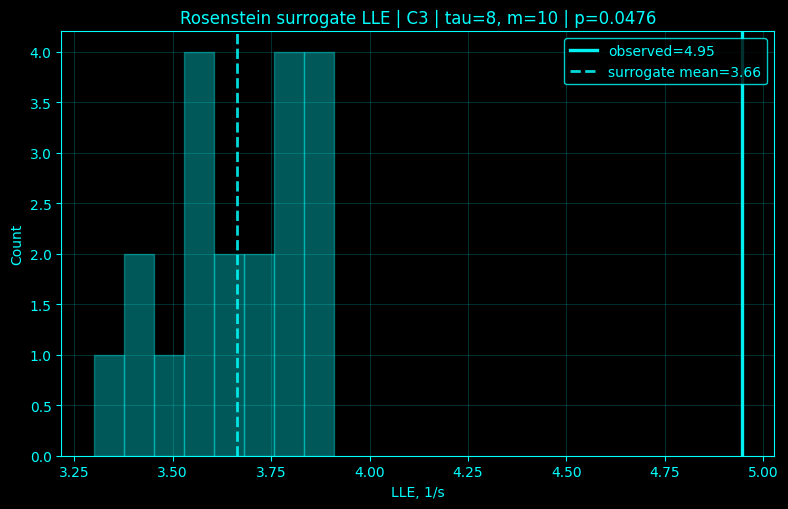

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau8_m10_hist_20260915_120325.png


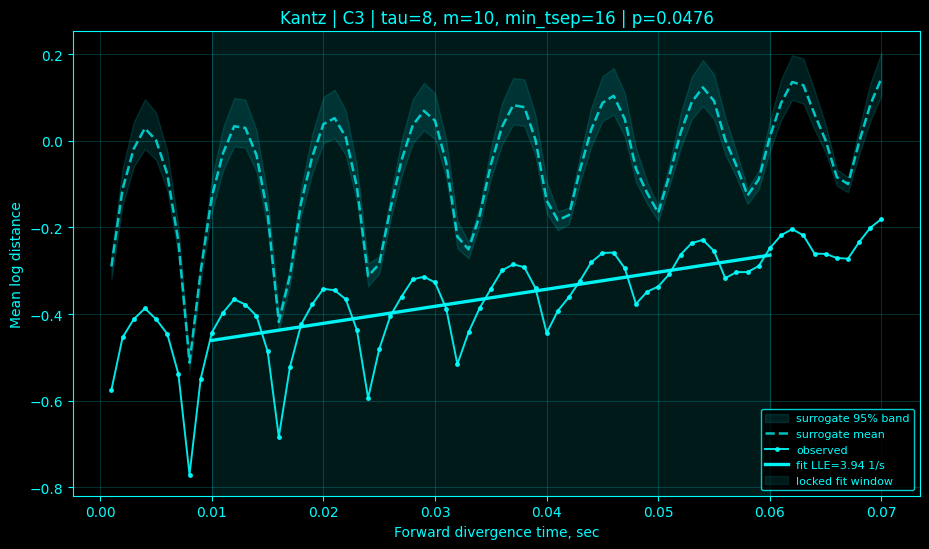

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau8_m10_divergence_20260915_120325.png


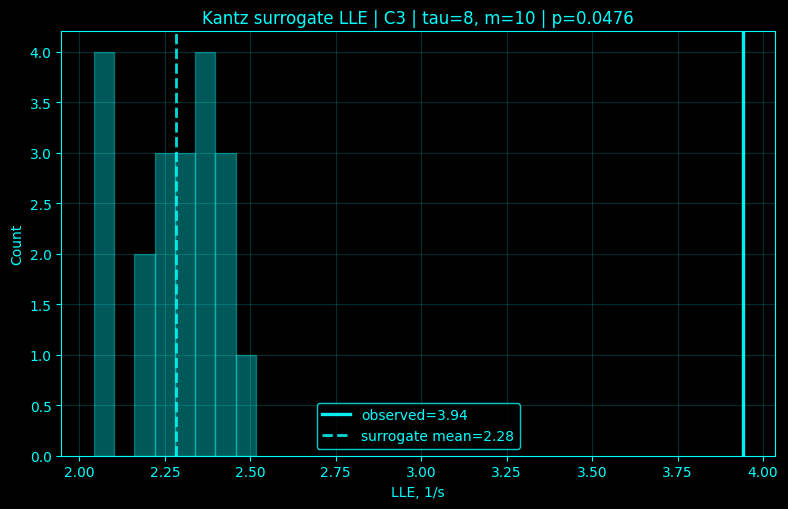

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau8_m10_hist_20260915_120325.png

Grid point: channel=C3 tau=8 m=12 min_tsep=16
  Observed Rosenstein: LLE=4.1469 | R2=0.3674 | refs=6000
  Observed Kantz:      LLE=3.2839 | R2=0.3828 | refs=6000
  tau=8 m=12: processed 10/20 surrogate curves | failed=0
  tau=8 m=12: processed 20/20 surrogate curves | failed=0


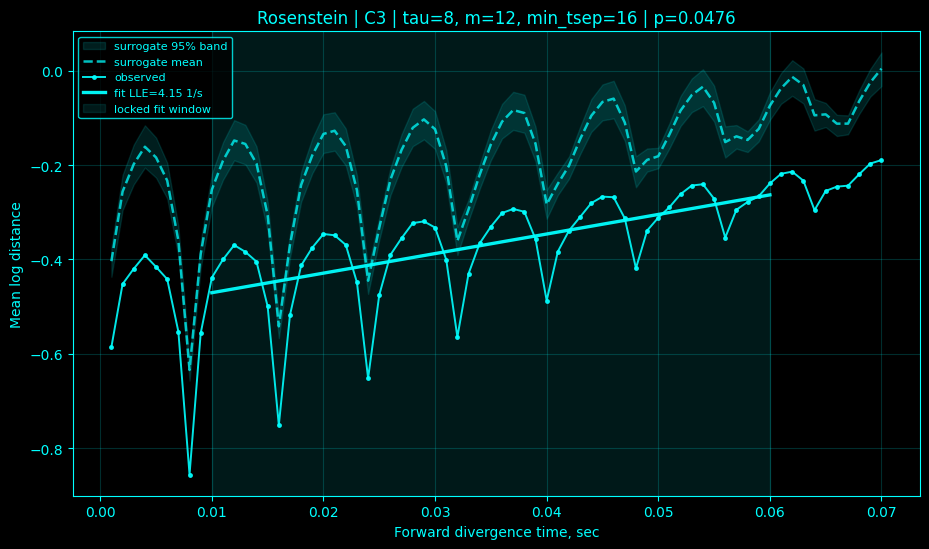

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau8_m12_divergence_20260915_120325.png


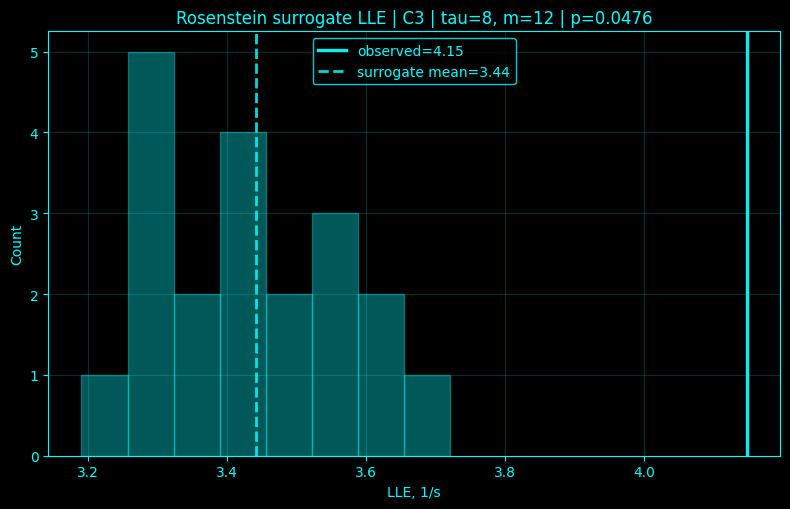

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau8_m12_hist_20260915_120325.png


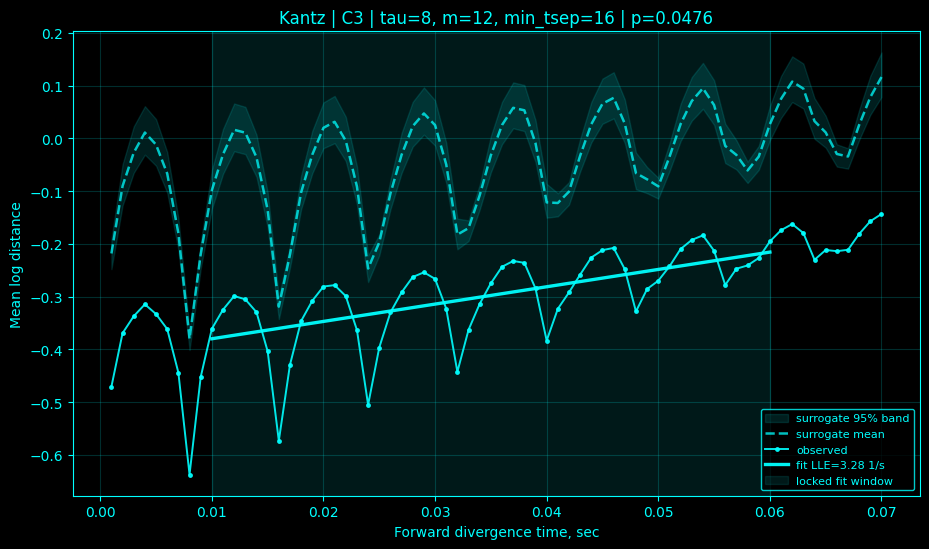

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau8_m12_divergence_20260915_120325.png


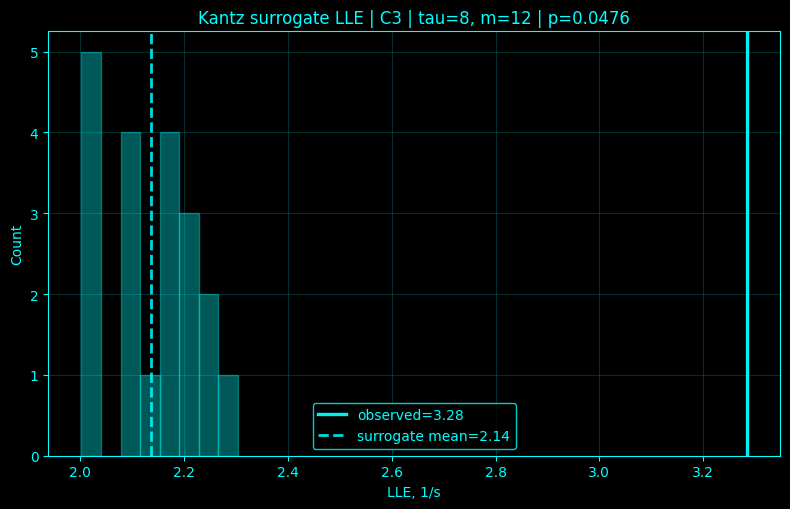

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau8_m12_hist_20260915_120325.png

Grid point: channel=C3 tau=10 m=8 min_tsep=20
  Observed Rosenstein: LLE=5.58127 | R2=0.3015 | refs=6000
  Observed Kantz:      LLE=4.37195 | R2=0.2938 | refs=6000
  tau=10 m=8: processed 10/20 surrogate curves | failed=0
  tau=10 m=8: processed 20/20 surrogate curves | failed=0


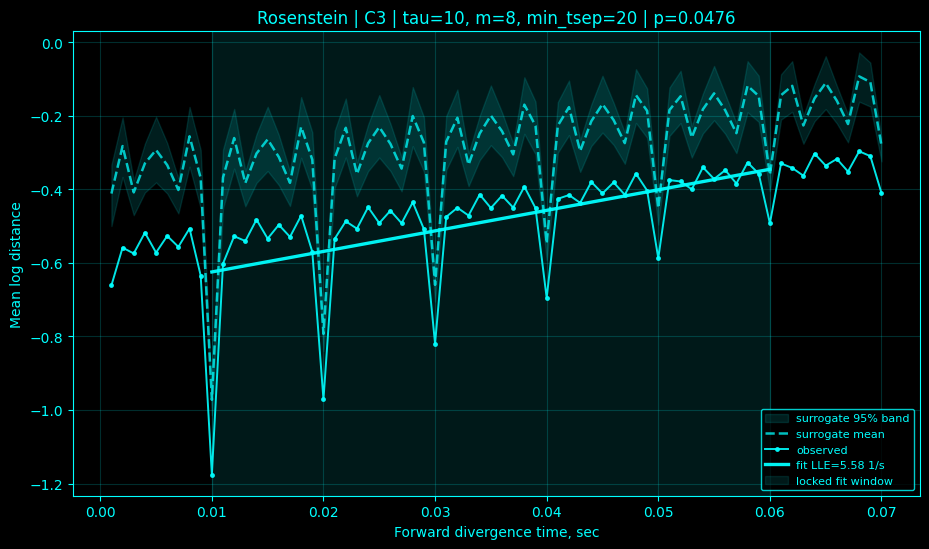

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau10_m8_divergence_20260915_120325.png


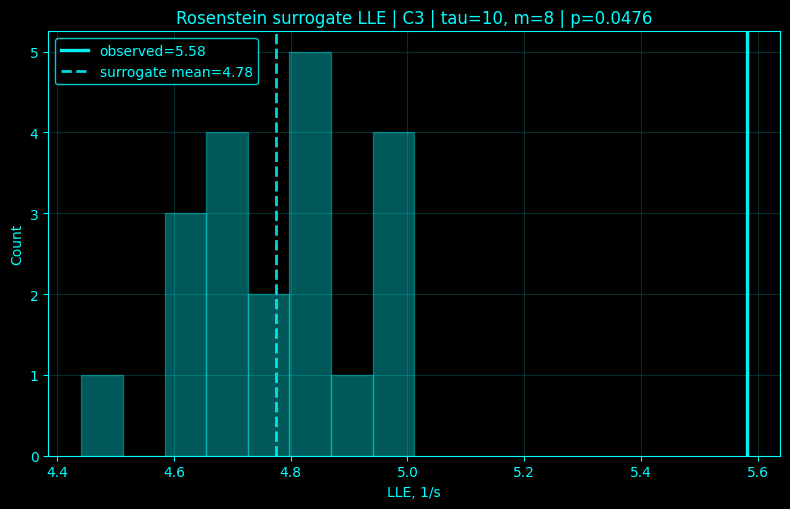

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau10_m8_hist_20260915_120325.png


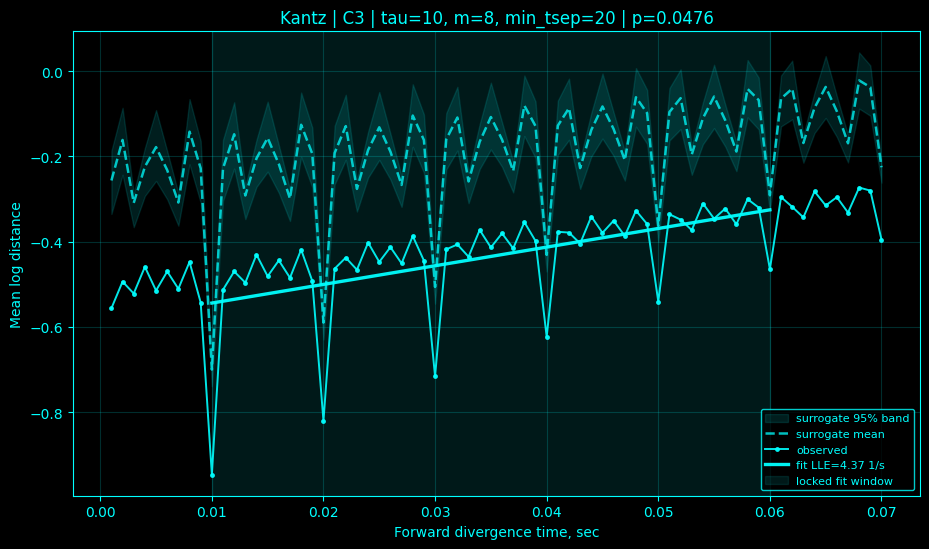

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau10_m8_divergence_20260915_120325.png


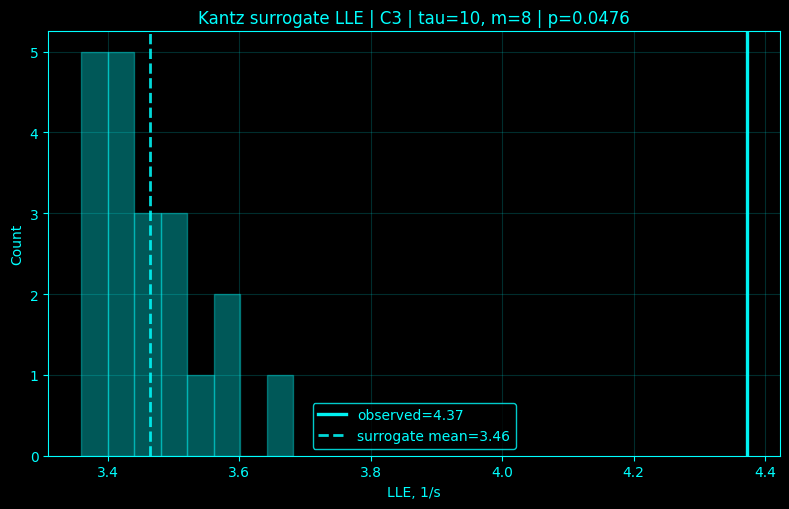

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau10_m8_hist_20260915_120325.png

Grid point: channel=C3 tau=10 m=10 min_tsep=20
  Observed Rosenstein: LLE=4.56782 | R2=0.2322 | refs=6000
  Observed Kantz:      LLE=3.47146 | R2=0.2291 | refs=6000
  tau=10 m=10: processed 10/20 surrogate curves | failed=0
  tau=10 m=10: processed 20/20 surrogate curves | failed=0


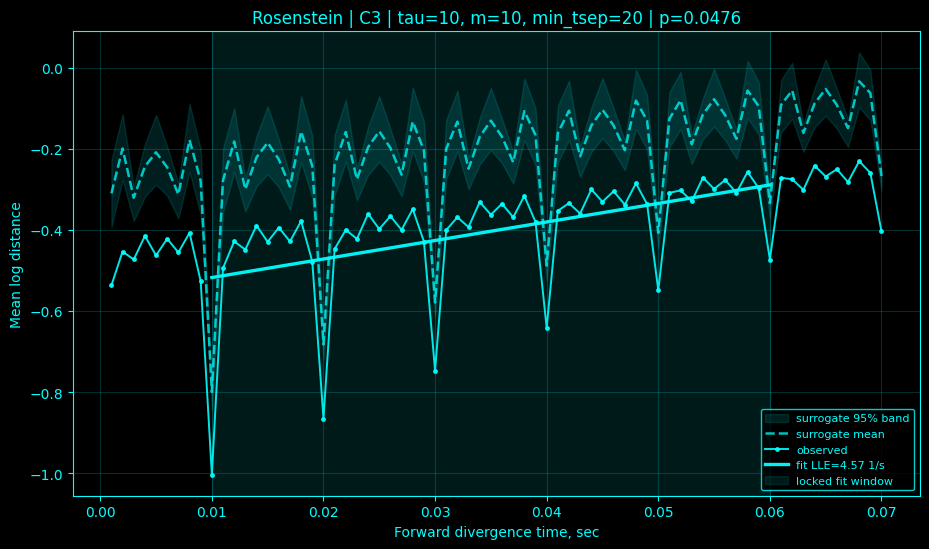

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau10_m10_divergence_20260915_120325.png


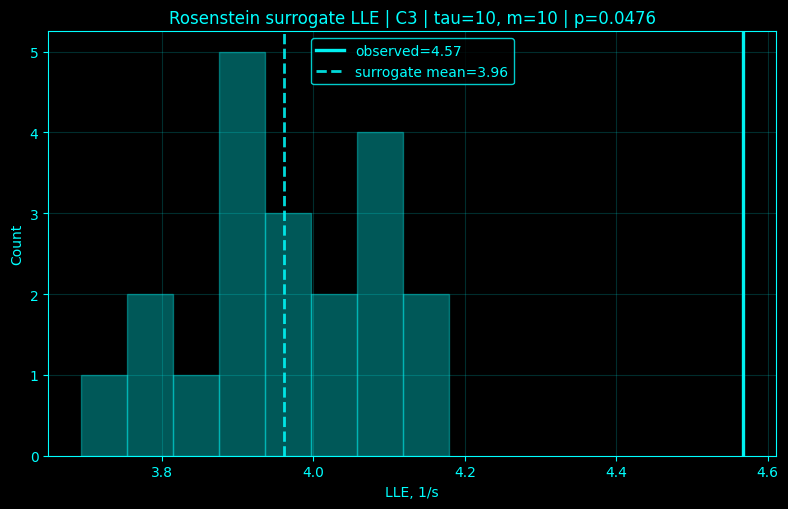

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau10_m10_hist_20260915_120325.png


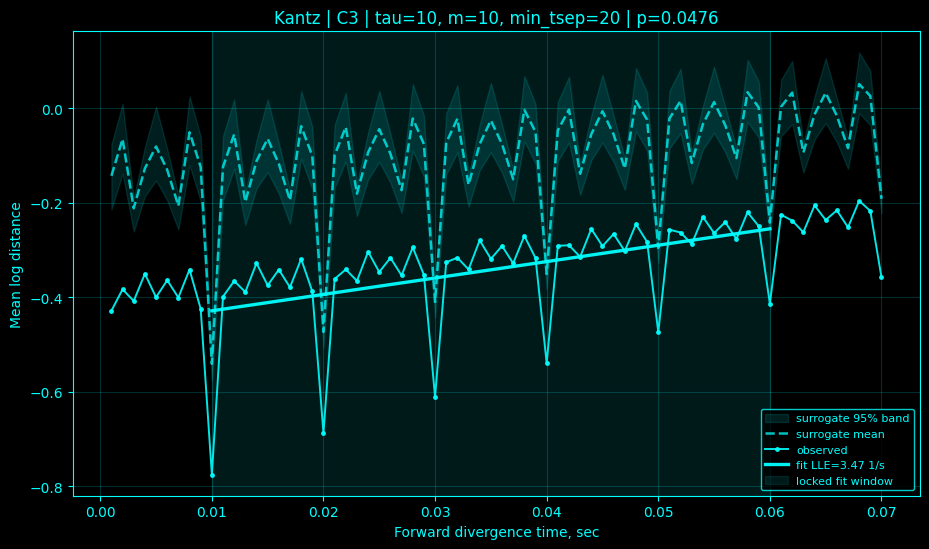

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau10_m10_divergence_20260915_120325.png


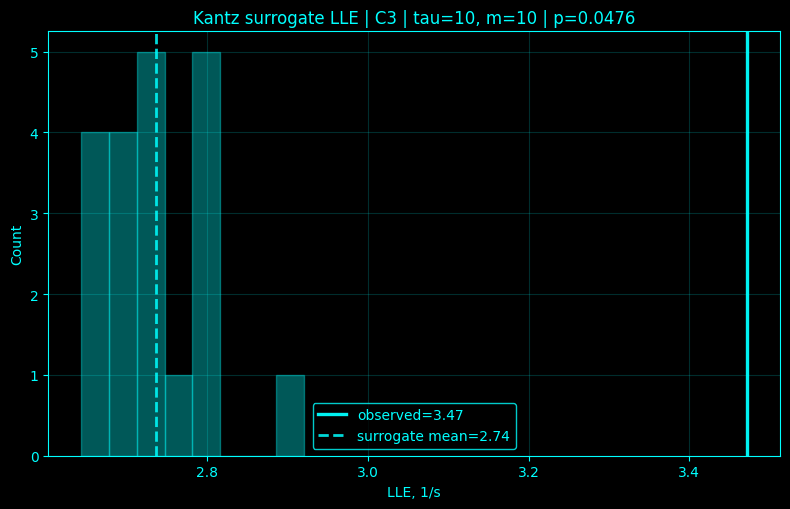

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau10_m10_hist_20260915_120325.png

Grid point: channel=C3 tau=10 m=12 min_tsep=20
  Observed Rosenstein: LLE=3.71908 | R2=0.1852 | refs=6000
  Observed Kantz:      LLE=2.82793 | R2=0.1798 | refs=6000
  tau=10 m=12: processed 10/20 surrogate curves | failed=0
  tau=10 m=12: processed 20/20 surrogate curves | failed=0


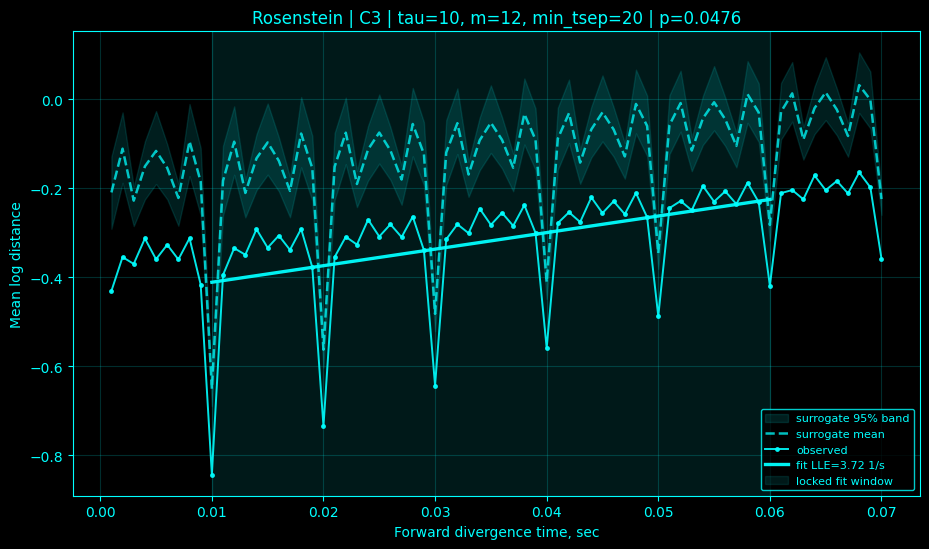

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau10_m12_divergence_20260915_120325.png


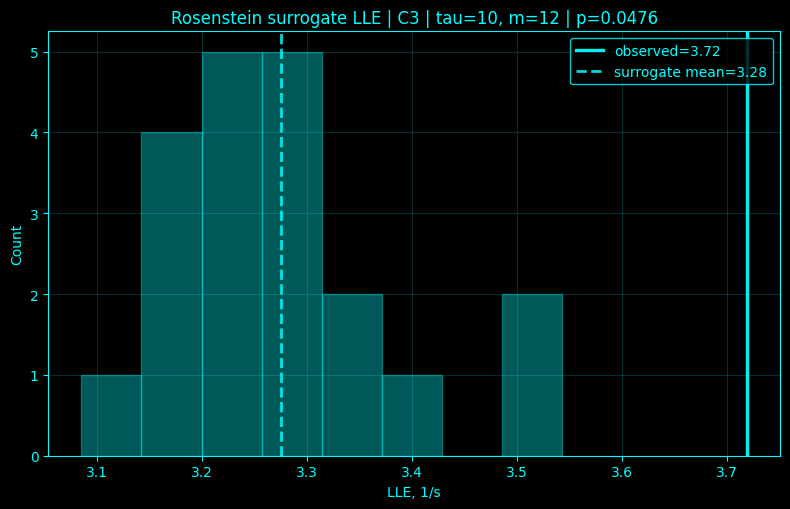

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau10_m12_hist_20260915_120325.png


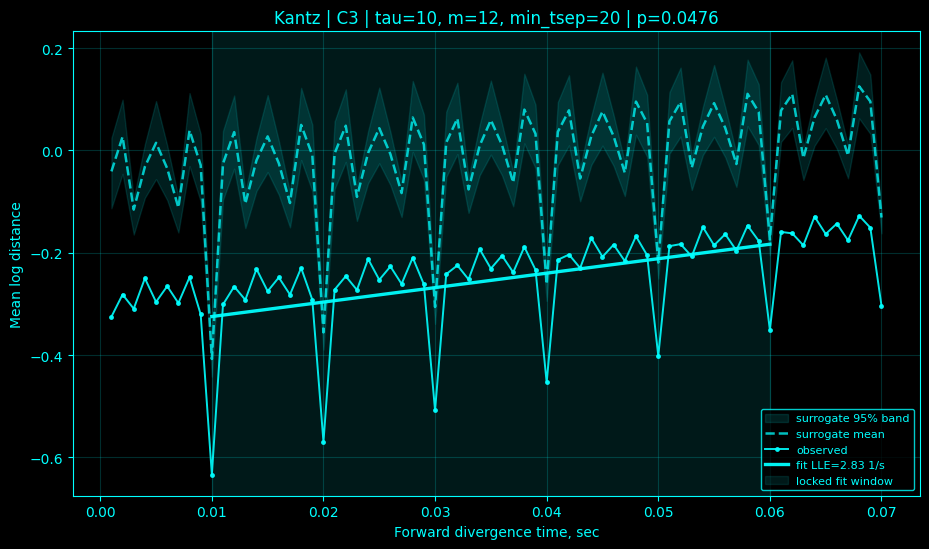

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau10_m12_divergence_20260915_120325.png


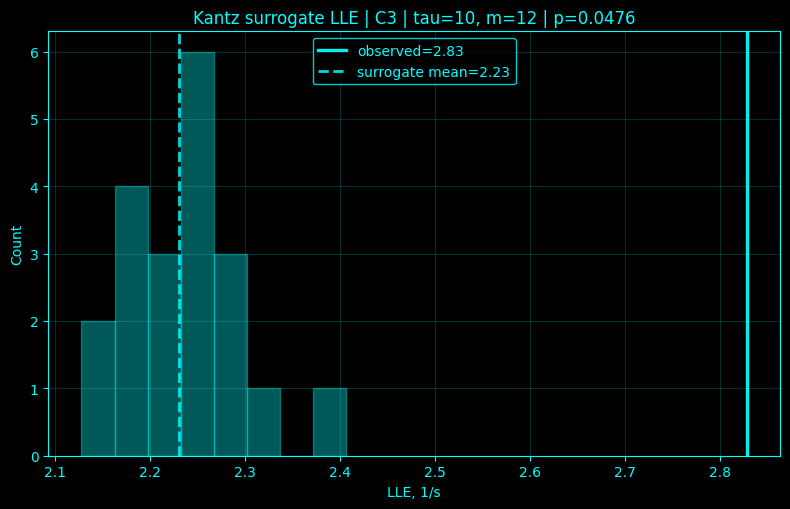

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau10_m12_hist_20260915_120325.png

Grid point: channel=C3 tau=12 m=8 min_tsep=24
  Observed Rosenstein: LLE=4.60857 | R2=0.2735 | refs=6000
  Observed Kantz:      LLE=3.60526 | R2=0.3158 | refs=6000
  tau=12 m=8: processed 10/20 surrogate curves | failed=0
  tau=12 m=8: processed 20/20 surrogate curves | failed=0


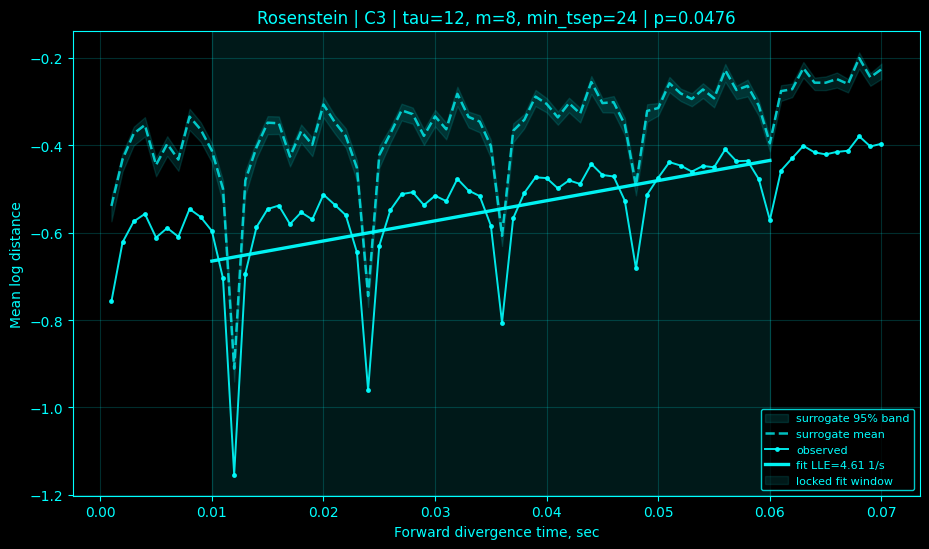

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau12_m8_divergence_20260915_120325.png


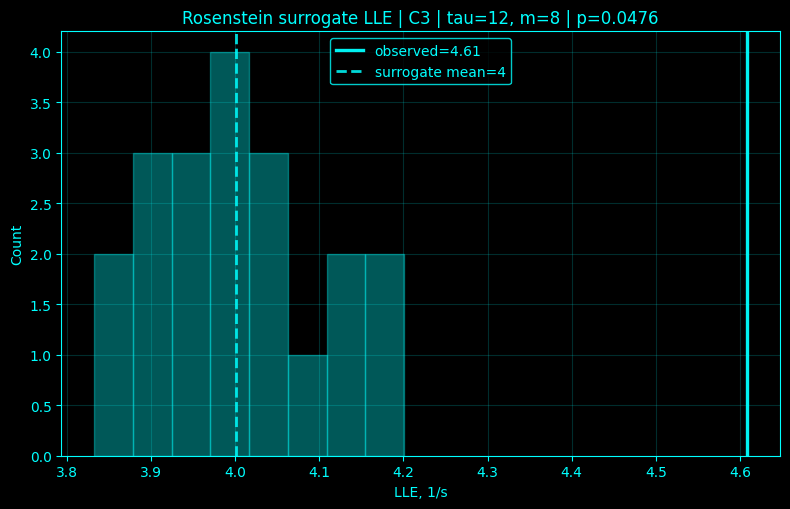

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau12_m8_hist_20260915_120325.png


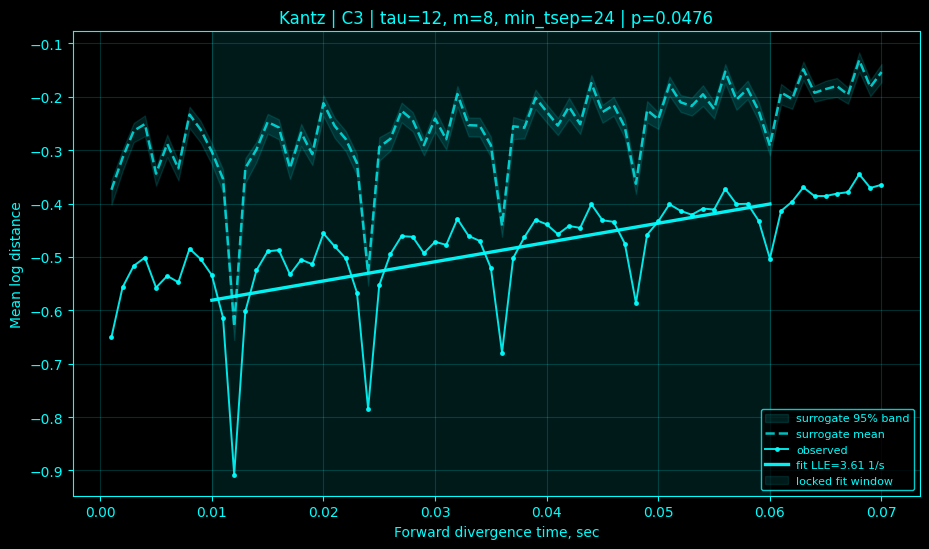

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau12_m8_divergence_20260915_120325.png


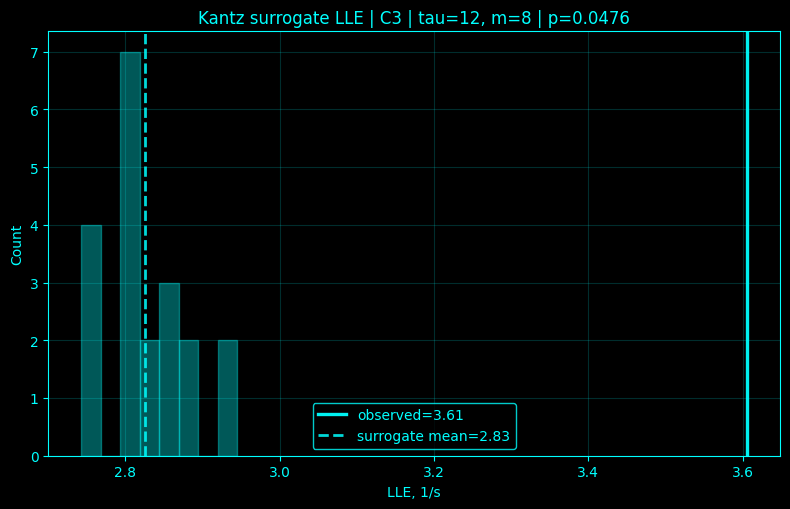

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau12_m8_hist_20260915_120325.png

Grid point: channel=C3 tau=12 m=10 min_tsep=24
  Observed Rosenstein: LLE=3.73992 | R2=0.2199 | refs=6000
  Observed Kantz:      LLE=2.83075 | R2=0.2465 | refs=6000
  tau=12 m=10: processed 10/20 surrogate curves | failed=0
  tau=12 m=10: processed 20/20 surrogate curves | failed=0


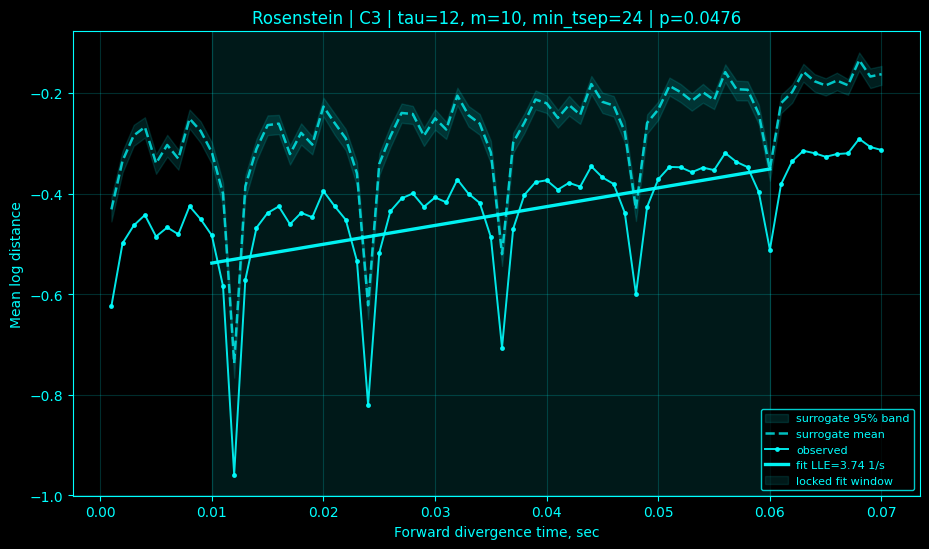

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau12_m10_divergence_20260915_120325.png


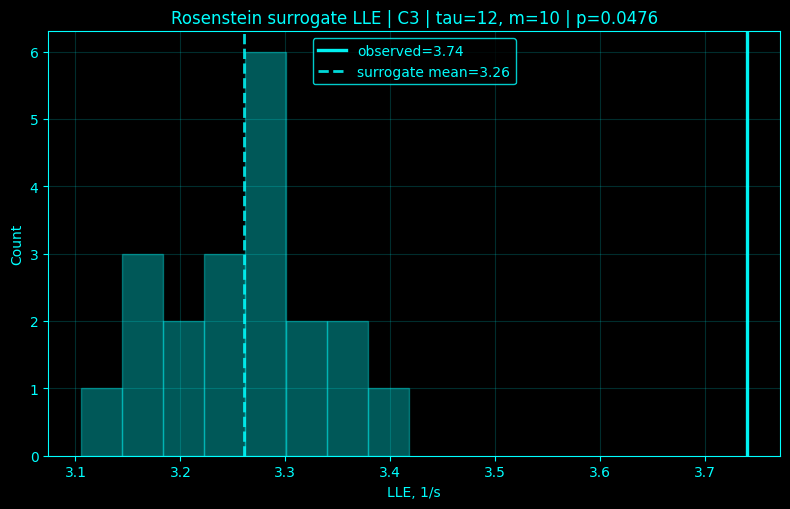

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau12_m10_hist_20260915_120325.png


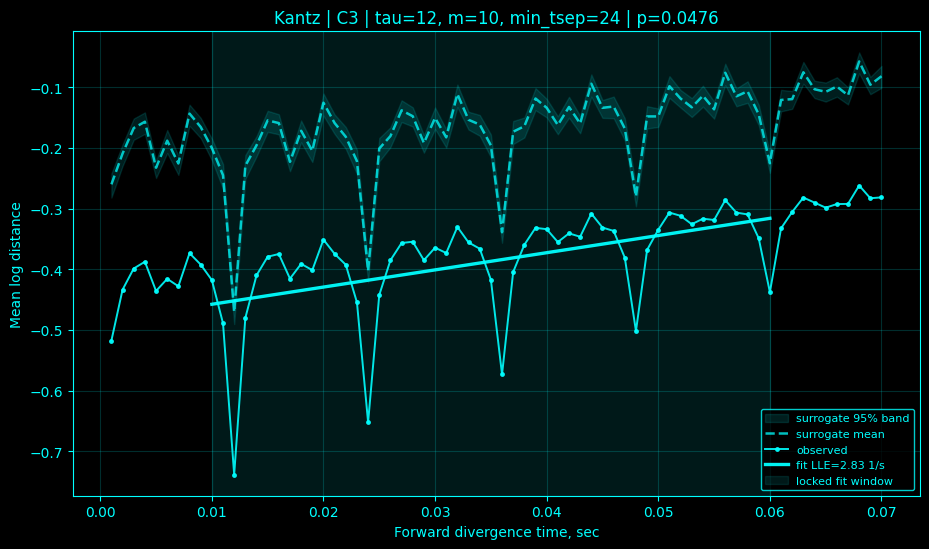

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau12_m10_divergence_20260915_120325.png


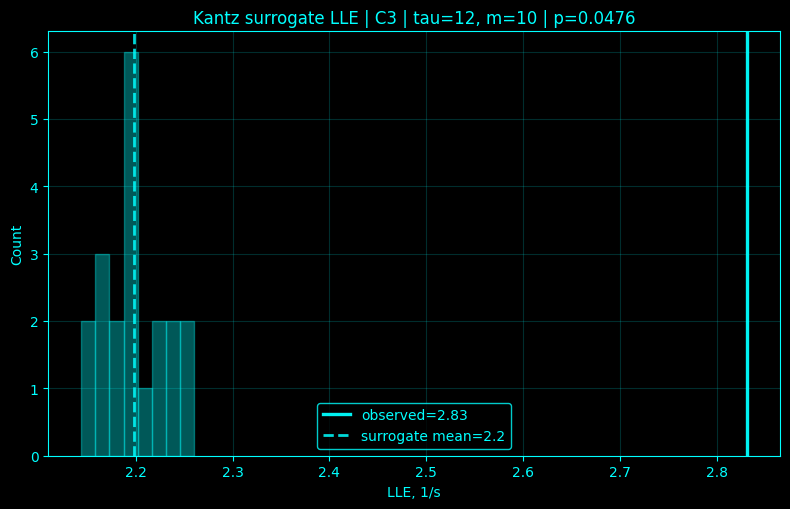

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau12_m10_hist_20260915_120325.png

Grid point: channel=C3 tau=12 m=12 min_tsep=24
  Observed Rosenstein: LLE=3.01611 | R2=0.1772 | refs=6000
  Observed Kantz:      LLE=2.22811 | R2=0.1941 | refs=6000
  tau=12 m=12: processed 10/20 surrogate curves | failed=0
  tau=12 m=12: processed 20/20 surrogate curves | failed=0


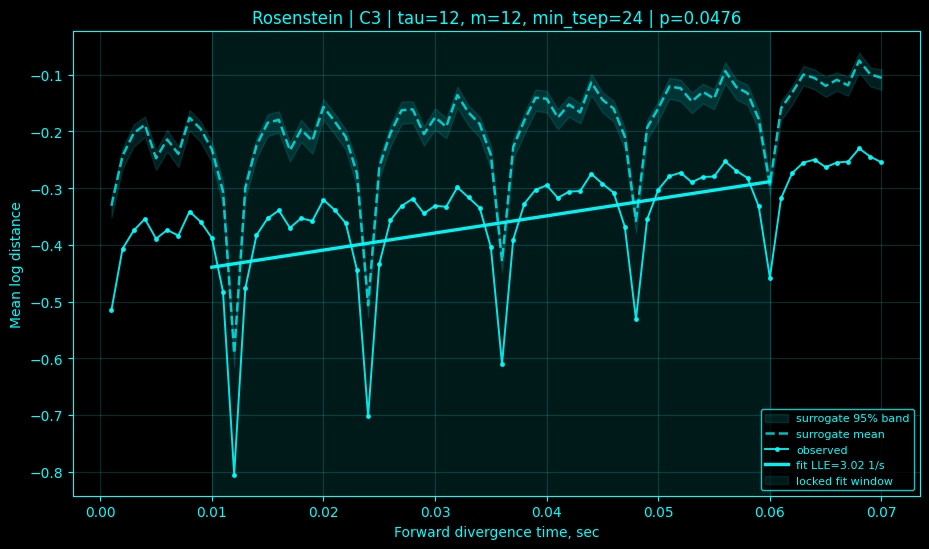

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_rosenstein_C3_tau12_m12_divergence_20260915_120325.png


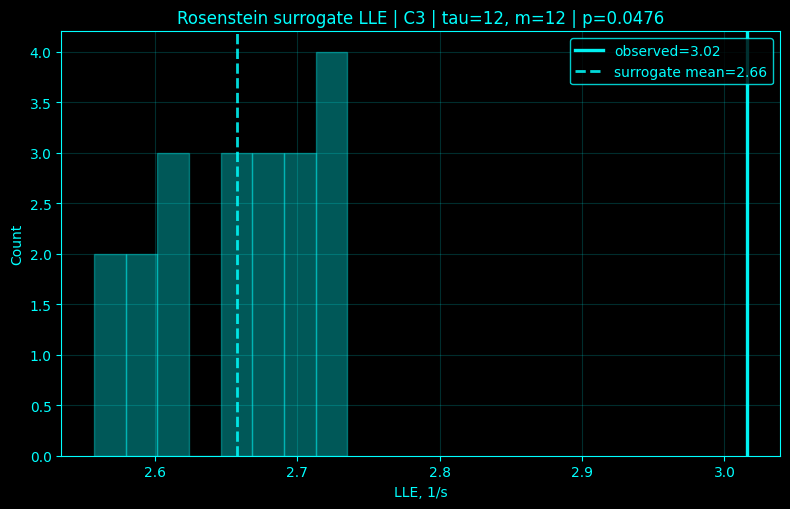

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_rosenstein_C3_tau12_m12_hist_20260915_120325.png


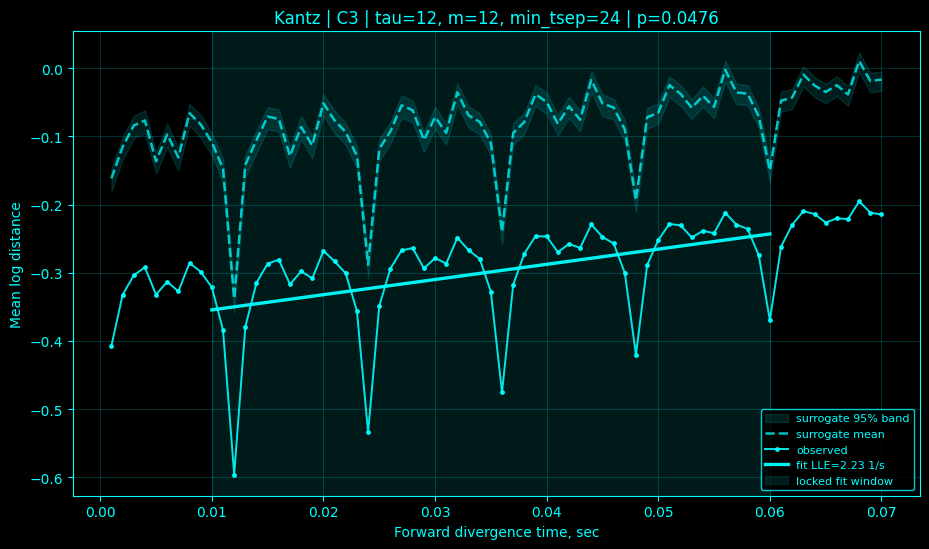

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/01_kantz_C3_tau12_m12_divergence_20260915_120325.png


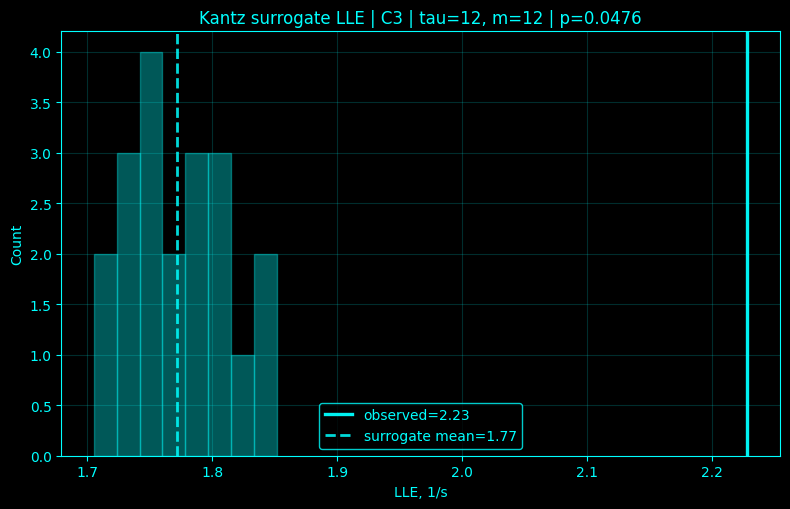

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/02_kantz_C3_tau12_m12_hist_20260915_120325.png


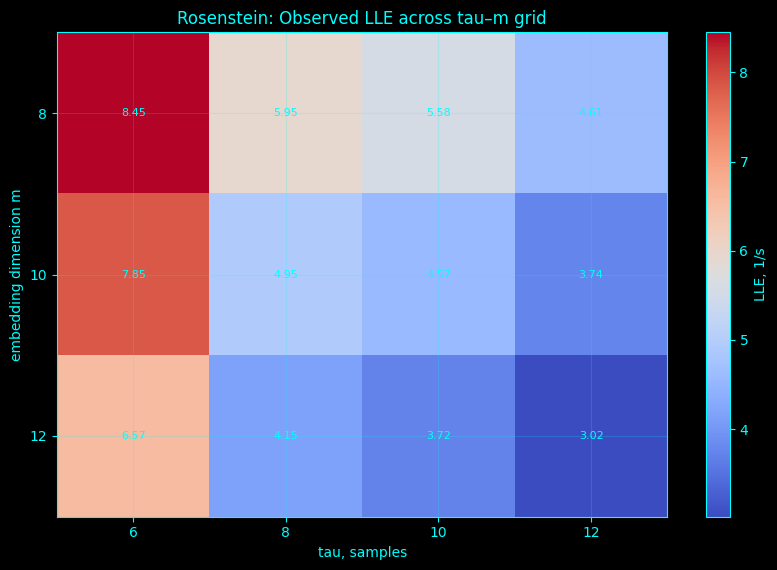

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_rosenstein_observed_LLE_grid_20260915_120325.png


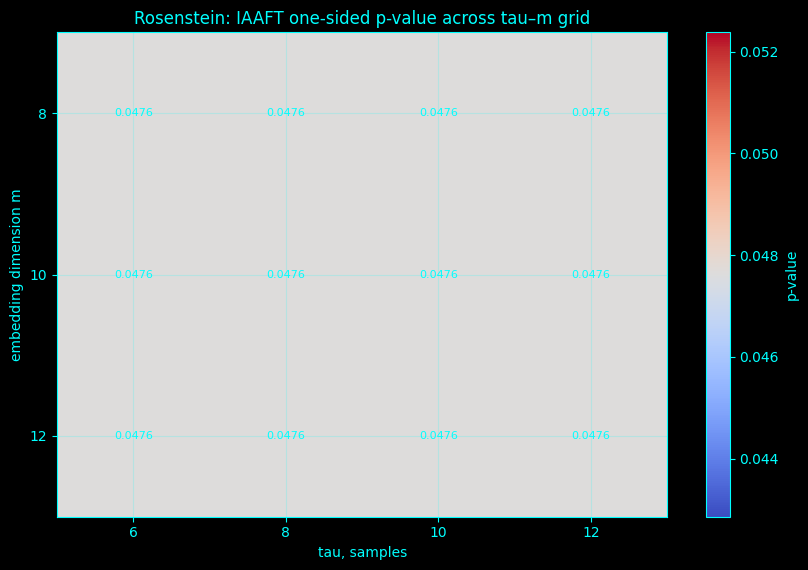

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_rosenstein_p_one_grid_20260915_120325.png


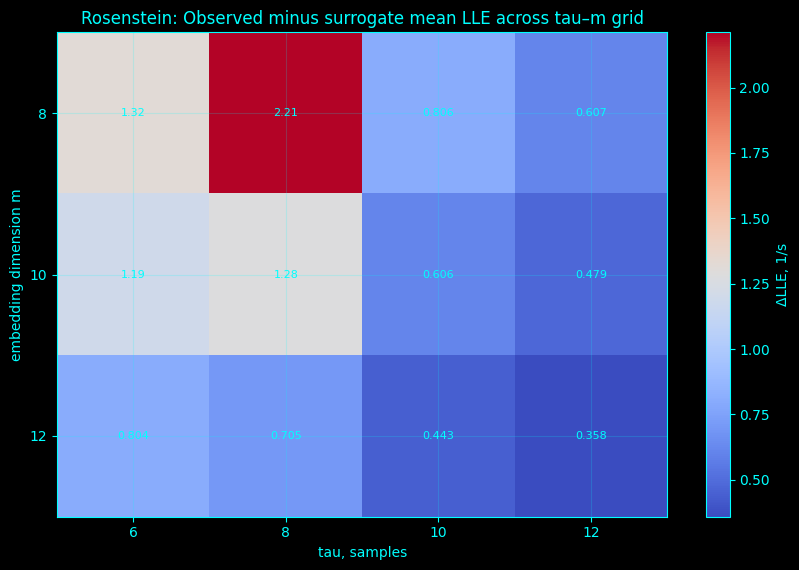

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_rosenstein_delta_LLE_grid_20260915_120325.png


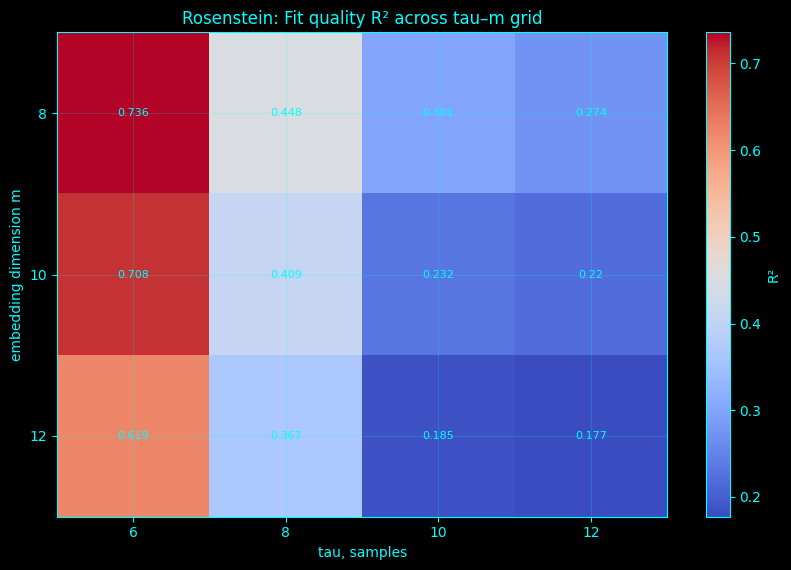

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_rosenstein_fit_R2_grid_20260915_120325.png


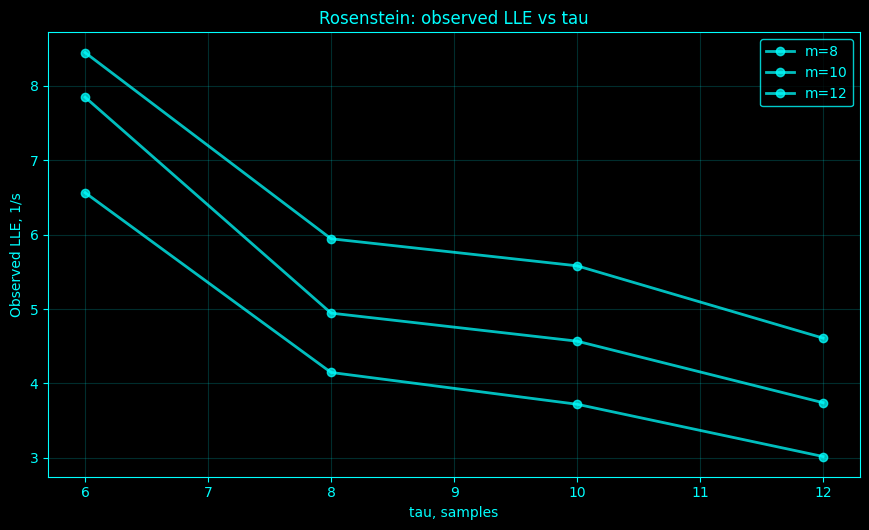

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/04_rosenstein_LLE_vs_tau_lines_20260915_120325.png


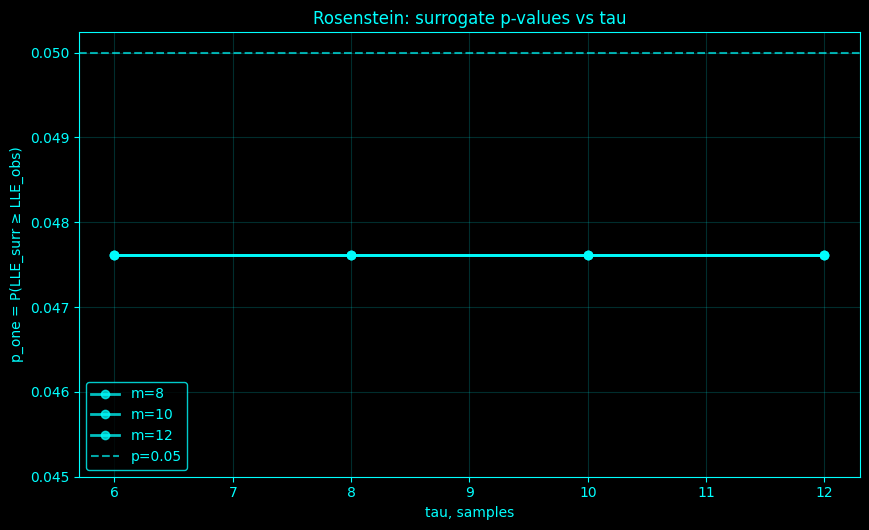

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/05_rosenstein_pvalue_vs_tau_lines_20260915_120325.png


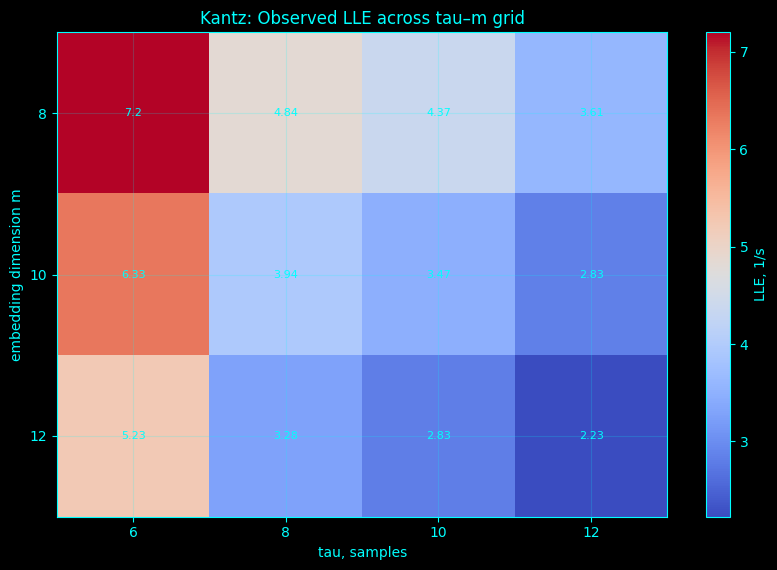

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_kantz_observed_LLE_grid_20260915_120325.png


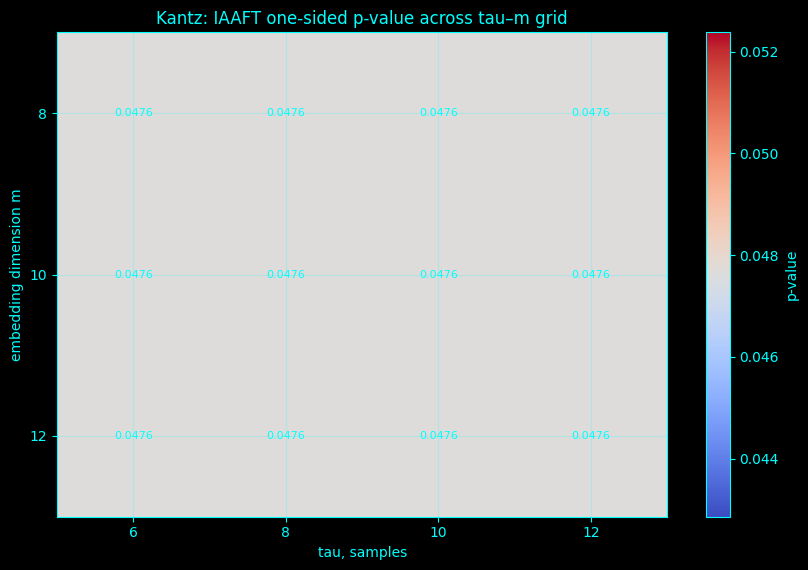

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_kantz_p_one_grid_20260915_120325.png


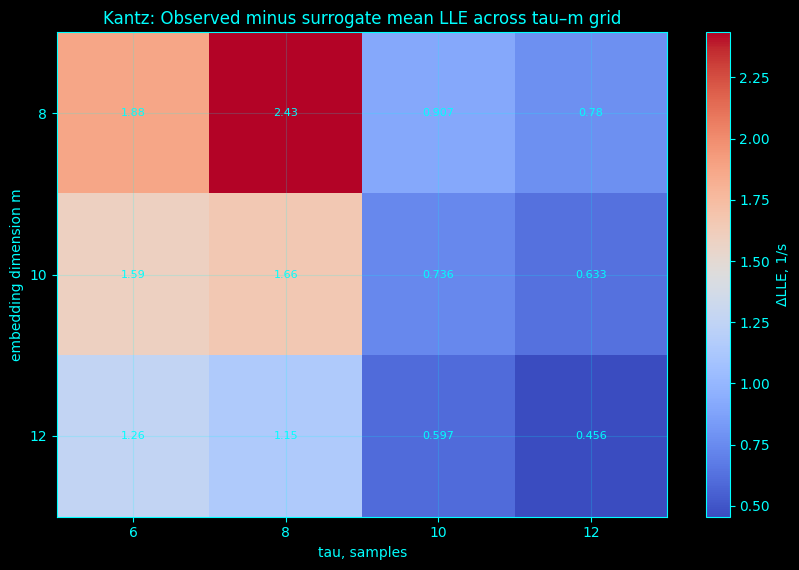

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_kantz_delta_LLE_grid_20260915_120325.png


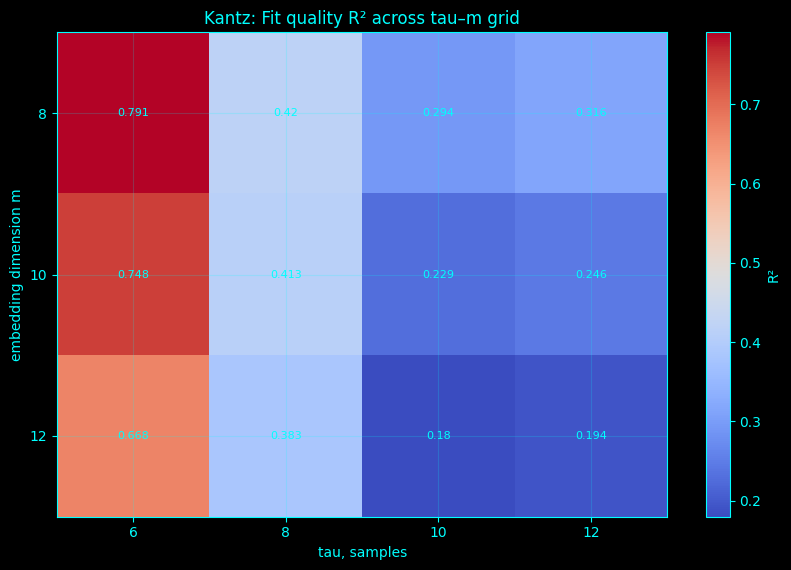

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/03_kantz_fit_R2_grid_20260915_120325.png


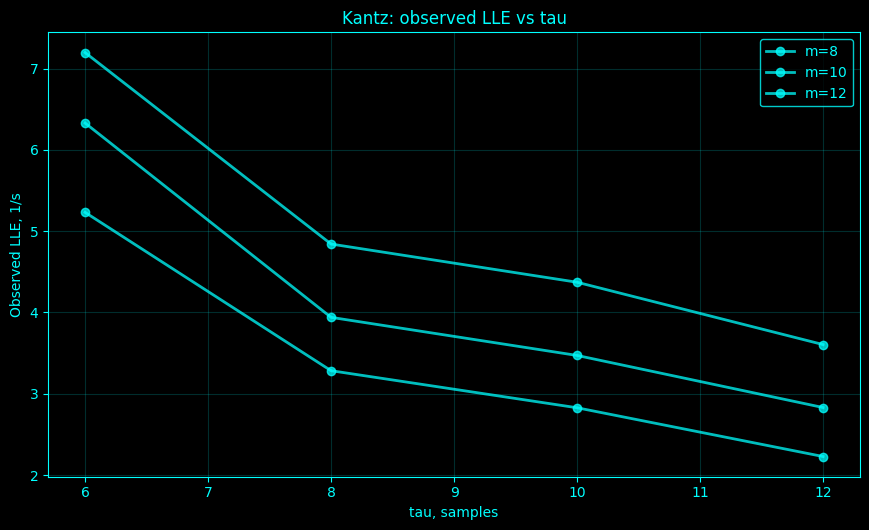

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/04_kantz_LLE_vs_tau_lines_20260915_120325.png


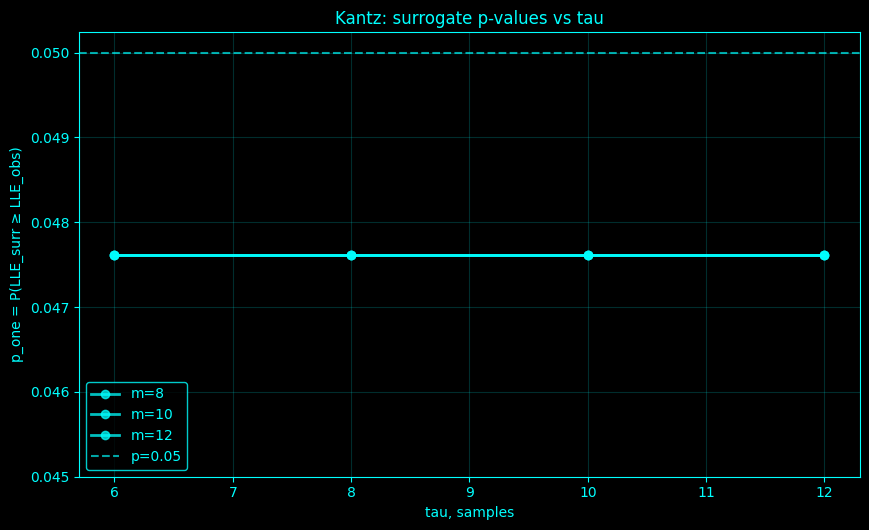

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/robustness_grid_LLE_fast_20260915_120325/plots/05_kantz_pvalue_vs_tau_lines_20260915_120325.png

=== Robustness grid summary ===
channel     method  tau  m  min_tsep  fit_k0  fit_k1  fit_k0_seconds  fit_k1_seconds  LLE_obs  LLE_surr_mean  LLE_surr_std  LLE_surr_q025  LLE_surr_q975  delta_LLE  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  fit_r2_obs  fit_rmse_obs  slope_obs_per_sample  fit_intercept_obs  refs_used_obs  n_surrogates_requested  n_surrogates_completed  n_curve_workers_failed  fs_eff notes
     C3 rosenstein    6  8        12      10      60            0.01            0.06 8.450065       7.133147      0.135421       6.886103       7.406509   1.316917             9.724650           0.047619        0.047619    0.735718      0.074548              0.008450          -0.808373           6000                      20                      20                       0  1000.0      
     C3      kantz    6  8     

In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000.0
segment_sec = (814.571, 921.515)

taus = [6, 8, 10, 12]
ms = [8, 10, 12]

fit_window_sec = (0.010, 0.060)

n_ref_ros = 6000
k_query_ros = 80
kmax_ros_original = 200

n_ref_kan = 6000
K_search_kan = 80
K_use_kan = 20
kmax_kan_original = 200

n_surrogates = _speed_count(39, minimum=20)
iaaft_iters = 200
iaaft_tol = 1e-4
iaaft_min_iters = 80
iaaft_check_every = 20

seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = 1
max_samples = None
standardize = True
linear_detrend = False

eps = 1e-12

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = os.path.join(base_dir, f"results/robustness_grid_LLE_fast_{timestamp}")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

OUT_SUMMARY_CSV = os.path.join(results_dir, f"robustness_grid_summary_{timestamp}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"robustness_grid_surrogates_{timestamp}.csv")
OUT_CURVE_CSV = os.path.join(results_dir, f"robustness_grid_curves_{timestamp}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"robustness_grid_qc_{timestamp}.csv")
OUT_NPZ = os.path.join(results_dir, f"robustness_grid_arrays_{timestamp}.npz")
OUT_TXT = os.path.join(results_dir, f"robustness_grid_report_{timestamp}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for text in leg.get_texts():
            text.set_color(ACCENT)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=200, tol=1e-4, min_iter=80, check_every=20):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def generate_iaaft_surrogates_parallel(x, tau, n_surrogates, n_workers):
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)
    surrogates = [None] * n_surrogates
    errors = np.full(n_surrogates, np.nan, dtype=float)
    iters_used = np.zeros(n_surrogates, dtype=int)

    def worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 100000 * int(tau) + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )
        return s, y.astype(np.float32), final_err, used_iters

    completed = 0
    failed = 0

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(worker, s) for s in range(n_surrogates)]
        for fut in as_completed(futures):
            try:
                s, y, err, used = fut.result()
            except Exception as e:
                failed += 1
                print(f"  IAAFT surrogate ERROR tau={tau}: {type(e).__name__}: {e}", flush=True)
                continue
            surrogates[s] = y
            errors[s] = err
            iters_used[s] = used
            completed += 1
            if completed % 10 == 0 or completed + failed == n_surrogates:
                print(f"  tau={tau}: generated {completed}/{n_surrogates} surrogates | failed={failed}", flush=True)

    good = [s for s in surrogates if s is not None]

    return good, errors[np.isfinite(errors)], iters_used[iters_used > 0], completed, failed

def pick_refs(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(int(n_ref), last_ok + 1)
    refs = np.sort(rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False))
    return refs, last_ok

def fit_curve_window(ks, y, k0, k1, fs_eff):
    ks = np.asarray(ks, dtype=int)
    y = np.asarray(y, dtype=float)
    mask = (ks >= int(k0)) & (ks <= int(k1)) & np.isfinite(y)
    kfit = ks[mask]
    yfit = y[mask]
    if len(kfit) < 5:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    coef = np.polyfit(kfit, yfit, 1)
    yhat = np.polyval(coef, kfit)
    ss_res = float(np.sum((yfit - yhat) ** 2))
    ss_tot = float(np.sum((yfit - np.mean(yfit)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yfit - yhat) ** 2)))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def rosenstein_curve_from_X(X, min_tsep, kmax=200, n_ref=6000, k_query=80, rng=None, batch_size=512):
    if rng is None:
        rng = np.random.default_rng()
    X = np.asarray(X, dtype=float)
    N = len(X)
    if N <= kmax + 2:
        return None, None, None, {"refs_used": 0, "M": int(N), "last_ok": -1}
    refs, last_ok = pick_refs(N, kmax, n_ref, rng)
    if len(refs) == 0:
        return None, None, None, {"refs_used": 0, "M": int(N), "last_ok": int(last_ok)}
    kq = min(N, max(int(k_query) + 1, int(min_tsep) + 40, 4 * X.shape[1] + 20))
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(X)
    _, idxs = nn.kneighbors(X[refs])
    nn_idx = np.full(len(refs), -1, dtype=int)
    for r_i, i in enumerate(refs):
        cand = idxs[r_i, 1:]
        cand = cand[np.abs(cand - int(i)) > int(min_tsep)]
        cand = cand[cand <= last_ok]
        if len(cand) > 0:
            nn_idx[r_i] = int(cand[0])
    good = nn_idx >= 0
    refs_g = refs[good]
    nn_g = nn_idx[good]
    if len(refs_g) < 50:
        return None, None, None, {
            "refs_used": int(len(refs_g)),
            "M": int(N),
            "last_ok": int(last_ok),
            "k_query_effective": int(kq),
        }
    ks = np.arange(1, kmax + 1, dtype=int)
    y_sum = np.zeros(kmax, dtype=float)
    counts = np.zeros(kmax, dtype=int)
    for start in range(0, len(refs_g), batch_size):
        stop = min(start + batch_size, len(refs_g))
        r_batch = refs_g[start:stop]
        n_batch = nn_g[start:stop]
        a = r_batch[:, None] + ks[None, :]
        b = n_batch[:, None] + ks[None, :]
        valid = (a < N) & (b < N)
        dist = np.linalg.norm(X[a] - X[b], axis=2)
        logd = np.log(dist + eps)
        logd[~valid] = np.nan
        y_sum += np.nansum(logd, axis=0)
        counts += np.sum(np.isfinite(logd), axis=0)
    log_div = y_sum / np.maximum(counts, 1)
    log_div[counts == 0] = np.nan
    info = {
        "refs_used": int(len(refs_g)),
        "M": int(N),
        "last_ok": int(last_ok),
        "k_query_effective": int(kq),
    }
    return ks, log_div, counts, info

def kantz_curve_from_X(X, refs, min_tsep, kmax=200, K_use=20, K_search=80):
    X = np.asarray(X, dtype=float)
    M = len(X)
    if M <= kmax + 2:
        return None, None, None, {"refs_used": 0, "M": int(M), "last_ok": -1}
    last_ok = M - 1 - kmax
    refs = np.asarray(refs, dtype=int)
    refs = refs[(refs >= 0) & (refs <= last_ok)]
    if len(refs) == 0:
        return None, None, None, {"refs_used": 0, "M": int(M), "last_ok": int(last_ok)}
    k_nn = min(M, max(int(K_search) + 1, int(K_use) + int(min_tsep) + 40, 4 * X.shape[1] + 20))
    nn = NearestNeighbors(n_neighbors=k_nn, algorithm="auto").fit(X)
    _, idxs = nn.kneighbors(X[refs])
    neighbor_sets = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        cand = cand[np.abs(cand - int(i)) > int(min_tsep)]
        cand = cand[cand <= last_ok]
        if len(cand) >= int(K_use):
            neighbor_sets.append((int(i), cand[:int(K_use)].astype(int)))
    if len(neighbor_sets) < 50:
        return None, None, None, {
            "refs_used": int(len(neighbor_sets)),
            "M": int(M),
            "last_ok": int(last_ok),
            "K_search_effective": int(k_nn),
        }
    ks = np.arange(1, kmax + 1, dtype=int)
    y_sum = np.zeros(kmax, dtype=float)
    counts = np.zeros(kmax, dtype=int)
    for i, neighs in neighbor_sets:
        Xi = X[i + ks]
        Xj = X[neighs[:, None] + ks[None, :]]
        dist = np.linalg.norm(Xj - Xi[None, :, :], axis=2)
        y_sum += np.mean(np.log(dist + eps), axis=0)
        counts += 1
    y = y_sum / np.maximum(counts, 1)
    y[counts == 0] = np.nan
    info = {
        "refs_used": int(len(neighbor_sets)),
        "M": int(M),
        "last_ok": int(last_ok),
        "K_search_effective": int(k_nn),
    }
    return ks, y, counts, info

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_one = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_one, p_two

def safe_summary_stats(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.nan, np.nan
    mu = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    q025 = float(np.percentile(vals, 2.5))
    q975 = float(np.percentile(vals, 97.5))
    return mu, sd, q025, q975

print("Configuration:")
print("  CHANNELS:", CHANNELS)
print("  taus:", taus)
print("  ms:", ms)
print("  fit_window_sec:", fit_window_sec)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)
print("  results_dir:", results_dir)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

summary_records = []
surrogate_records = []
curve_records = []
qc_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "taus": np.array(taus, dtype=int),
    "ms": np.array(ms, dtype=int),
    "fit_window_sec": np.array(fit_window_sec, dtype=float),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
    "seed": np.array([seed], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    ch_i = channel_names.index(channel)
    start_idx = int(segment_sec[0] * fs_original)
    end_idx = int(segment_sec[1] * fs_original)
    x_raw = EEG[start_idx:end_idx, ch_i].astype(float)
    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )
    fit_k0 = int(round(fit_window_sec[0] * fs_eff))
    fit_k1 = int(round(fit_window_sec[1] * fs_eff))
    if fit_k1 <= fit_k0 + 5:
        raise ValueError(f"Fit window too short after preprocessing: k={fit_k0}-{fit_k1}")
    kmax_ros = min(int(round(kmax_ros_original / max(decimate_factor, 1))), max(fit_k1 + 10, 20))
    kmax_kan = min(int(round(kmax_kan_original / max(decimate_factor, 1))), max(fit_k1 + 10, 20))
    print(f"\n[{ch_num}/{len(channels_to_run)}] Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz")
    print(f"Locked fit window: k=[{fit_k0},{fit_k1}] sec=[{fit_k0/fs_eff:.4f},{fit_k1/fs_eff:.4f}]")
    print(f"kmax_ros={kmax_ros} | kmax_kan={kmax_kan}")

    tau_surrogates = {}

    for tau in taus:
        print(f"\nGenerating IAAFT surrogates once for tau={tau}...")
        Ys, err_tau, it_tau, completed_tau, failed_tau = generate_iaaft_surrogates_parallel(
            x,
            tau=tau,
            n_surrogates=n_surrogates,
            n_workers=n_workers
        )
        tau_surrogates[int(tau)] = {
            "signals": Ys,
            "errors": err_tau,
            "iters": it_tau,
            "completed": completed_tau,
            "failed": failed_tau,
        }
        print(f"tau={tau}: completed={completed_tau}, failed={failed_tau}")

    for tau in taus:
        tau = int(tau)
        min_tsep = int(2 * tau)
        Ys = tau_surrogates[tau]["signals"]

        for m in ms:
            m = int(m)
            print(f"\nGrid point: channel={channel} tau={tau} m={m} min_tsep={min_tsep}", flush=True)

            Xobs = delay_embed_1d(x, m=m, tau=tau)
            if Xobs is None:
                for method in ["rosenstein", "kantz"]:
                    summary_records.append({
                        "channel": channel,
                        "method": method,
                        "tau": tau,
                        "m": m,
                        "min_tsep": min_tsep,
                        "fit_k0": fit_k0,
                        "fit_k1": fit_k1,
                        "LLE_obs": np.nan,
                        "notes": "embedding_failed",
                    })
                continue

            rng_ros = np.random.default_rng(seed + 1111 + 100 * tau + m)
            rng_kan = np.random.default_rng(seed + 2222 + 100 * tau + m)

            ks_ros_obs, y_ros_obs, counts_ros_obs, info_ros_obs = rosenstein_curve_from_X(
                Xobs,
                min_tsep=min_tsep,
                kmax=kmax_ros,
                n_ref=n_ref_ros,
                k_query=k_query_ros,
                rng=rng_ros
            )

            refs_kan, last_ok_kan = pick_refs(len(Xobs), kmax_kan, n_ref_kan, rng_kan)

            ks_kan_obs, y_kan_obs, counts_kan_obs, info_kan_obs = kantz_curve_from_X(
                Xobs,
                refs=refs_kan,
                min_tsep=min_tsep,
                kmax=kmax_kan,
                K_use=K_use_kan,
                K_search=K_search_kan
            )

            obs_results = {}

            if ks_ros_obs is not None:
                slope, intercept, lle, r2, rmse = fit_curve_window(
                    ks_ros_obs,
                    y_ros_obs,
                    fit_k0,
                    fit_k1,
                    fs_eff
                )
                obs_results["rosenstein"] = {
                    "ks": ks_ros_obs,
                    "curve": y_ros_obs,
                    "counts": counts_ros_obs,
                    "info": info_ros_obs,
                    "slope": slope,
                    "intercept": intercept,
                    "LLE": lle,
                    "fit_r2": r2,
                    "fit_rmse": rmse,
                }
                print(f"  Observed Rosenstein: LLE={lle:.6g} | R2={r2:.4f} | refs={info_ros_obs['refs_used']}")
            else:
                obs_results["rosenstein"] = None
                print("  Observed Rosenstein failed.")

            if ks_kan_obs is not None:
                slope, intercept, lle, r2, rmse = fit_curve_window(
                    ks_kan_obs,
                    y_kan_obs,
                    fit_k0,
                    fit_k1,
                    fs_eff
                )
                obs_results["kantz"] = {
                    "ks": ks_kan_obs,
                    "curve": y_kan_obs,
                    "counts": counts_kan_obs,
                    "info": info_kan_obs,
                    "slope": slope,
                    "intercept": intercept,
                    "LLE": lle,
                    "fit_r2": r2,
                    "fit_rmse": rmse,
                }
                print(f"  Observed Kantz:      LLE={lle:.6g} | R2={r2:.4f} | refs={info_kan_obs['refs_used']}")
            else:
                obs_results["kantz"] = None
                print("  Observed Kantz failed.")

            method_surr_lle = {"rosenstein": [], "kantz": []}
            method_surr_curve = {"rosenstein": [], "kantz": []}

            def curve_worker(si, y_surr):
                Xs = delay_embed_1d(y_surr, m=m, tau=tau)
                out = {
                    "surrogate_index": int(si + 1),
                    "rosenstein": None,
                    "kantz": None,
                }
                if Xs is None:
                    return out

                rng_s_ros = np.random.default_rng(seed + 300000 + 10000 * tau + 100 * m + si)

                ks_r, y_r, counts_r, info_r = rosenstein_curve_from_X(
                    Xs,
                    min_tsep=min_tsep,
                    kmax=kmax_ros,
                    n_ref=n_ref_ros,
                    k_query=k_query_ros,
                    rng=rng_s_ros
                )

                if ks_r is not None:
                    slope_r, intercept_r, lle_r, r2_r, rmse_r = fit_curve_window(
                        ks_r,
                        y_r,
                        fit_k0,
                        fit_k1,
                        fs_eff
                    )
                    out["rosenstein"] = {
                        "ks": ks_r,
                        "curve": y_r,
                        "counts": counts_r,
                        "info": info_r,
                        "slope": slope_r,
                        "intercept": intercept_r,
                        "LLE": lle_r,
                        "fit_r2": r2_r,
                        "fit_rmse": rmse_r,
                    }

                ks_k, y_k, counts_k, info_k = kantz_curve_from_X(
                    Xs,
                    refs=refs_kan,
                    min_tsep=min_tsep,
                    kmax=kmax_kan,
                    K_use=K_use_kan,
                    K_search=K_search_kan
                )

                if ks_k is not None:
                    slope_k, intercept_k, lle_k, r2_k, rmse_k = fit_curve_window(
                        ks_k,
                        y_k,
                        fit_k0,
                        fit_k1,
                        fs_eff
                    )
                    out["kantz"] = {
                        "ks": ks_k,
                        "curve": y_k,
                        "counts": counts_k,
                        "info": info_k,
                        "slope": slope_k,
                        "intercept": intercept_k,
                        "LLE": lle_k,
                        "fit_r2": r2_k,
                        "fit_rmse": rmse_k,
                    }

                return out

            completed_curves = 0
            failed_curves = 0

            with ThreadPoolExecutor(max_workers=n_workers) as executor:
                futures = [executor.submit(curve_worker, si, y) for si, y in enumerate(Ys)]
                for fut in as_completed(futures):
                    try:
                        res = fut.result()
                    except Exception as e:
                        failed_curves += 1
                        print(f"  curve worker ERROR tau={tau}, m={m}: {type(e).__name__}: {e}", flush=True)
                        continue

                    sidx = int(res["surrogate_index"])

                    for method in ["rosenstein", "kantz"]:
                        r = res[method]
                        if r is None:
                            continue

                        method_surr_lle[method].append(float(r["LLE"]))
                        method_surr_curve[method].append(np.asarray(r["curve"], dtype=float))

                        surrogate_records.append({
                            "channel": channel,
                            "method": method,
                            "tau": tau,
                            "m": m,
                            "min_tsep": min_tsep,
                            "surrogate_index": sidx,
                            "LLE_surr": float(r["LLE"]),
                            "slope_per_sample": float(r["slope"]),
                            "intercept": float(r["intercept"]),
                            "fit_r2": float(r["fit_r2"]),
                            "fit_rmse": float(r["fit_rmse"]),
                            "refs_used": int(r["info"].get("refs_used", 0)),
                            "fit_k0": int(fit_k0),
                            "fit_k1": int(fit_k1),
                        })

                    completed_curves += 1
                    if completed_curves % 10 == 0 or completed_curves + failed_curves == len(Ys):
                        print(f"  tau={tau} m={m}: processed {completed_curves}/{len(Ys)} surrogate curves | failed={failed_curves}", flush=True)

            for method in ["rosenstein", "kantz"]:
                obs = obs_results[method]

                if obs is None:
                    summary_records.append({
                        "channel": channel,
                        "method": method,
                        "tau": tau,
                        "m": m,
                        "min_tsep": min_tsep,
                        "fit_k0": fit_k0,
                        "fit_k1": fit_k1,
                        "LLE_obs": np.nan,
                        "notes": "observed_curve_failed",
                    })
                    continue

                svals = np.asarray(method_surr_lle[method], dtype=float)
                svals = svals[np.isfinite(svals)]
                mu, sd, q025, q975 = safe_summary_stats(svals)
                z, p_one, p_two = empirical_p_values(obs["LLE"], svals)

                notes = ""
                if len(svals) < max(10, n_surrogates // 2):
                    notes = f"few_surrogates({len(svals)})"

                summary_records.append({
                    "channel": channel,
                    "method": method,
                    "tau": tau,
                    "m": m,
                    "min_tsep": min_tsep,
                    "fit_k0": int(fit_k0),
                    "fit_k1": int(fit_k1),
                    "fit_k0_seconds": float(fit_k0 / fs_eff),
                    "fit_k1_seconds": float(fit_k1 / fs_eff),
                    "LLE_obs": float(obs["LLE"]),
                    "LLE_surr_mean": mu,
                    "LLE_surr_std": sd,
                    "LLE_surr_q025": q025,
                    "LLE_surr_q975": q975,
                    "delta_LLE": float(obs["LLE"] - mu) if np.isfinite(mu) else np.nan,
                    "z_obs_vs_surrogates": float(z),
                    "p_one_surr_ge_obs": float(p_one),
                    "p_two_centered": float(p_two),
                    "fit_r2_obs": float(obs["fit_r2"]),
                    "fit_rmse_obs": float(obs["fit_rmse"]),
                    "slope_obs_per_sample": float(obs["slope"]),
                    "fit_intercept_obs": float(obs["intercept"]),
                    "refs_used_obs": int(obs["info"].get("refs_used", 0)),
                    "n_surrogates_requested": int(n_surrogates),
                    "n_surrogates_completed": int(len(svals)),
                    "n_curve_workers_failed": int(failed_curves),
                    "fs_eff": float(fs_eff),
                    "notes": notes,
                })

                curve_stack = np.asarray(method_surr_curve[method], dtype=float)

                for i, k in enumerate(obs["ks"]):
                    rec = {
                        "channel": channel,
                        "method": method,
                        "tau": tau,
                        "m": m,
                        "min_tsep": min_tsep,
                        "k": int(k),
                        "time_seconds": float(k / fs_eff),
                        "observed_log_distance": float(obs["curve"][i]),
                        "observed_count": int(obs["counts"][i]),
                    }

                    if curve_stack.size > 0 and curve_stack.ndim == 2:
                        rec.update({
                            "surrogate_mean_log_distance": float(np.nanmean(curve_stack[:, i])),
                            "surrogate_std_log_distance": float(np.nanstd(curve_stack[:, i])),
                            "surrogate_q025_log_distance": float(np.nanpercentile(curve_stack[:, i], 2.5)),
                            "surrogate_q975_log_distance": float(np.nanpercentile(curve_stack[:, i], 97.5)),
                        })
                    else:
                        rec.update({
                            "surrogate_mean_log_distance": np.nan,
                            "surrogate_std_log_distance": np.nan,
                            "surrogate_q025_log_distance": np.nan,
                            "surrogate_q975_log_distance": np.nan,
                        })

                    curve_records.append(rec)

                npz_prefix = f"{channel}_{method}_tau{tau}_m{m}"
                npz_payload[f"{npz_prefix}_ks"] = obs["ks"]
                npz_payload[f"{npz_prefix}_obs_curve"] = obs["curve"]
                npz_payload[f"{npz_prefix}_obs_counts"] = obs["counts"]
                npz_payload[f"{npz_prefix}_surr_LLE"] = svals

                if curve_stack.size > 0:
                    npz_payload[f"{npz_prefix}_surr_curves"] = curve_stack

                fig, ax = plt.subplots(figsize=(9.4, 5.6), facecolor=BG)
                style_ax(ax)

                if curve_stack.size > 0 and curve_stack.ndim == 2:
                    s_mean = np.nanmean(curve_stack, axis=0)
                    s_q025 = np.nanpercentile(curve_stack, 2.5, axis=0)
                    s_q975 = np.nanpercentile(curve_stack, 97.5, axis=0)
                    ax.fill_between(obs["ks"] / fs_eff, s_q025, s_q975, color=ACCENT, alpha=0.12, label="surrogate 95% band")
                    ax.plot(obs["ks"] / fs_eff, s_mean, color=ACCENT, linestyle="--", linewidth=1.8, alpha=0.75, label="surrogate mean")

                ax.plot(obs["ks"] / fs_eff, obs["curve"], color=ACCENT, marker="o", markersize=2.5, linewidth=1.4, alpha=0.9, label="observed")

                kfit = obs["ks"][(obs["ks"] >= fit_k0) & (obs["ks"] <= fit_k1)]
                yfit = obs["slope"] * kfit + obs["intercept"]

                ax.plot(kfit / fs_eff, yfit, color=ACCENT, linewidth=2.4, alpha=0.95, label=f"fit LLE={obs['LLE']:.3g} 1/s")
                ax.axvspan(fit_k0 / fs_eff, fit_k1 / fs_eff, color=ACCENT, alpha=0.10, label="locked fit window")

                ax.set_title(f"{method.title()} | {channel} | tau={tau}, m={m}, min_tsep={min_tsep} | p={p_one:.3g}")
                ax.set_xlabel("Forward divergence time, sec")
                ax.set_ylabel("Mean log distance")

                leg = ax.legend(loc="best", fontsize=8)
                style_legend(leg)

                plot_path = os.path.join(plots_dir, f"01_{method}_{channel}_tau{tau}_m{m}_divergence_{timestamp}.png")
                save_show_close(fig, plot_path)

                if len(svals) > 0:
                    fig, ax = plt.subplots(figsize=(8.0, 5.2), facecolor=BG)
                    style_ax(ax)

                    ax.hist(
                        svals,
                        bins=min(24, max(8, int(np.sqrt(len(svals)) * 2))),
                        color=ACCENT,
                        edgecolor=ACCENT,
                        alpha=0.35
                    )

                    ax.axvline(obs["LLE"], color=ACCENT, linewidth=2.4, alpha=0.95, label=f"observed={obs['LLE']:.3g}")
                    ax.axvline(mu, color=ACCENT, linewidth=2.0, linestyle="--", alpha=0.85, label=f"surrogate mean={mu:.3g}")

                    ax.set_title(f"{method.title()} surrogate LLE | {channel} | tau={tau}, m={m} | p={p_one:.3g}")
                    ax.set_xlabel("LLE, 1/s")
                    ax.set_ylabel("Count")

                    leg = ax.legend()
                    style_legend(leg)

                    plot_path = os.path.join(plots_dir, f"02_{method}_{channel}_tau{tau}_m{m}_hist_{timestamp}.png")
                    save_show_close(fig, plot_path)

    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "decimate_factor": int(decimate_factor),
        "max_samples": int(max_samples) if max_samples is not None else -1,
        "fit_k0": int(fit_k0),
        "fit_k1": int(fit_k1),
        "n_surrogates_requested": int(n_surrogates),
    })

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVE_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast Robustness Grid LLE: Rosenstein + Kantz with IAAFT Surrogates\n")
    f.write("==================================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment_sec={segment_sec}\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"taus={taus}\n")
    f.write(f"ms={ms}\n")
    f.write(f"fit_window_sec={fit_window_sec}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

for method in ["rosenstein", "kantz"]:
    method_df = summary_df[
        (summary_df["method"] == method) &
        np.isfinite(summary_df["LLE_obs"])
    ].copy()

    if len(method_df) == 0:
        continue

    taus_u = sorted(method_df["tau"].dropna().astype(int).unique())
    ms_u = sorted(method_df["m"].dropna().astype(int).unique())

    for value_col, title_suffix, fname_suffix, cbar_label in [
        ("LLE_obs", "Observed LLE", "observed_LLE", "LLE, 1/s"),
        ("p_one_surr_ge_obs", "IAAFT one-sided p-value", "p_one", "p-value"),
        ("delta_LLE", "Observed minus surrogate mean LLE", "delta_LLE", "ΔLLE, 1/s"),
        ("fit_r2_obs", "Fit quality R²", "fit_R2", "R²"),
    ]:
        Z = np.full((len(ms_u), len(taus_u)), np.nan, dtype=float)

        for _, row in method_df.iterrows():
            mi = ms_u.index(int(row["m"]))
            ti = taus_u.index(int(row["tau"]))
            Z[mi, ti] = float(row[value_col])

        fig, ax = plt.subplots(figsize=(8.4, 5.8), facecolor=BG)
        style_ax(ax)

        im = ax.imshow(Z, aspect="auto", interpolation="nearest", cmap="coolwarm")

        ax.set_xticks(np.arange(len(taus_u)))
        ax.set_xticklabels([str(t) for t in taus_u])
        ax.set_yticks(np.arange(len(ms_u)))
        ax.set_yticklabels([str(m) for m in ms_u])

        ax.set_title(f"{method.title()}: {title_suffix} across tau–m grid")
        ax.set_xlabel("tau, samples")
        ax.set_ylabel("embedding dimension m")

        for i in range(Z.shape[0]):
            for j in range(Z.shape[1]):
                val = Z[i, j]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.3g}", ha="center", va="center", color=ACCENT, fontsize=8)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(cbar_label)
        style_colorbar(cbar)

        plot_path = os.path.join(plots_dir, f"03_{method}_{fname_suffix}_grid_{timestamp}.png")
        save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    for m in ms_u:
        sub = method_df[method_df["m"] == m].sort_values("tau")
        ax.plot(
            sub["tau"],
            sub["LLE_obs"],
            color=ACCENT,
            marker="o",
            linewidth=2.0,
            alpha=0.75,
            label=f"m={m}"
        )

    ax.set_title(f"{method.title()}: observed LLE vs tau")
    ax.set_xlabel("tau, samples")
    ax.set_ylabel("Observed LLE, 1/s")

    leg = ax.legend()
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"04_{method}_LLE_vs_tau_lines_{timestamp}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    for m in ms_u:
        sub = method_df[method_df["m"] == m].sort_values("tau")
        ax.plot(
            sub["tau"],
            sub["p_one_surr_ge_obs"],
            color=ACCENT,
            marker="o",
            linewidth=2.0,
            alpha=0.75,
            label=f"m={m}"
        )

    ax.axhline(0.05, color=ACCENT, linestyle="--", alpha=0.65, label="p=0.05")

    ax.set_title(f"{method.title()}: surrogate p-values vs tau")
    ax.set_xlabel("tau, samples")
    ax.set_ylabel("p_one = P(LLE_surr ≥ LLE_obs)")

    leg = ax.legend()
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05_{method}_pvalue_vs_tau_lines_{timestamp}.png")
    save_show_close(fig, plot_path)

print("\n=== Robustness grid summary ===")
print(summary_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVE_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### TIME-ROBUSTNESS TEST

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — time-resolved robustness of largest Lyapunov estimates</h3><p>A single LLE can hide nonstationarity. This cell repeats Rosenstein/Kantz estimation in successive time windows and compares each estimate with surrogate behavior, making temporal stability of the conclusion explicit.</p><p>A windowed LLE is a local finite-record statistic. It should not be interpreted as the global asymptotic Lyapunov exponent of a stationary autonomous system unless stationarity and model assumptions are independently justified.</p><p><b>Cell role.</b> Faster modes reduce the number of windows, references, or surrogates rather than changing the divergence definition.</p></div>

$$\hat\lambda_1(t_w)=\operatorname{slope}\,D_{t_w}(k)/\Delta t.$$

In [7]:
# ================================
# MUST BE FIRST: limit BLAS threads
# ================================
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from concurrent.futures import ThreadPoolExecutor, as_completed

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -----------------------------
# CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel = "C3"
fs = 1000
segment = (814.571, 921.515)

m = 10
tau = 8
min_tsep = 16
kmax = 200
fit_lo, fit_hi = 10, 60

# refs (reduce if needed)
ros_n_ref   = _speed_count(3000, 700)
kantz_n_ref = _speed_count(3000, 700)

# Kantz
K_use = 20
K_search = 60

# Surrogates
n_surr = _speed_count(19, 5)
iaaft_iters = _speed_count(100, 35)
seed = 0
eps = 1e-12

# Windowing
win_len_sec = 20.0
overlap = 0.5

# Thread workers (Jupyter-safe)
workers = min(_speed_count(8, 2), max(1, os.cpu_count() or 2))

run_id = time.strftime("%Y%m%d_%H%M%S")
out_dir = os.path.join(base_dir, f"time_robustness_LLE_{channel}_{run_id}")
os.makedirs(out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

# -----------------------------
# Helpers
# -----------------------------
def standardize_1d(x):
    x = np.asarray(x, float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M,m)

def pick_refs(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(n_ref, last_ok + 1)
    refs = rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False)
    refs.sort()
    return refs, last_ok

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def fit_slope_locked(ks, y, fit_lo, fit_hi):
    mask = (ks >= fit_lo) & (ks <= fit_hi) & np.isfinite(y)
    kfit = ks[mask].astype(float)
    yfit = y[mask].astype(float)
    if len(kfit) < 5:
        return np.nan, np.nan
    a, b = np.polyfit(kfit, yfit, 1)
    return float(a), float(b)

# -----------------------------
# Rosenstein
# -----------------------------
def rosenstein_curve_from_X(X, min_tsep, kmax, refs):
    M = len(X)
    nn = NearestNeighbors(n_neighbors=min(50, M), algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    pairs = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        cand = cand[cand + kmax < M]
        if len(cand) == 0:
            continue
        pairs.append((int(i), int(cand[0])))

    if len(pairs) < 50:
        return None

    ks = np.arange(0, kmax + 1, dtype=int)
    log_div = np.full_like(ks, np.nan, dtype=float)

    for k in ks:
        ds = []
        for i, j in pairs:
            ds.append(np.linalg.norm(X[i + k] - X[j + k]))
        ds = np.asarray(ds, float)
        log_div[k] = np.mean(np.log(ds + eps))

    return ks, log_div, {"pairs_used": len(pairs), "M": M}

# -----------------------------
# Kantz
# -----------------------------
def kantz_curve(X, refs, min_tsep, kmax, K_use, K_search):
    M = len(X)
    nn = NearestNeighbors(n_neighbors=min(K_search + 1, M), algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    neighbor_sets = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        cand = cand[cand + kmax < M]
        if len(cand) < K_use:
            continue
        neighbor_sets.append((int(i), cand[:K_use]))

    if len(neighbor_sets) == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {"refs_used": 0, "M": M}

    y = np.zeros(kmax + 1, dtype=float)
    count = 0
    for i, neighs in neighbor_sets:
        for k in range(1, kmax + 1):
            dif = X[i + k] - X[neighs + k]
            dist_k = np.linalg.norm(dif, axis=1)
            y[k] += np.mean(np.log(dist_k + eps))
        count += 1

    y[1:] /= max(count, 1)
    return np.arange(1, kmax + 1), y, {"refs_used": count, "M": M}

# -----------------------------
# One surrogate evaluation (thread-safe)
# -----------------------------
def surrogate_metrics(xw, refs_ros, refs_kantz, win_seed):
    rng = np.random.default_rng(win_seed)
    xs = iaaft_surrogate(xw, n_iter=iaaft_iters, rng=rng)
    xs = standardize_1d(xs)
    Xs = embed_1d(xs, m, tau)
    if Xs is None:
        return (np.nan, np.nan)

    # Rosenstein
    ros = rosenstein_curve_from_X(Xs, min_tsep, kmax, refs_ros)
    ros_lle = np.nan
    if ros is not None:
        ks, ld, _ = ros
        a, _ = fit_slope_locked(ks, ld, fit_lo, fit_hi)
        ros_lle = a * fs

    # Kantz
    ks_k, y_k, _ = kantz_curve(Xs, refs_kantz, min_tsep, kmax, K_use, K_search)
    # y_k is length kmax+1 indexed by k; fit expects ks 0..kmax
    a_k, _ = fit_slope_locked(np.arange(0, kmax + 1), y_k, fit_lo, fit_hi)
    kantz_lle = a_k * fs

    return (ros_lle, kantz_lle)

def summarize_surr(surr, obs):
    surr = np.asarray(surr, float)
    surr = surr[np.isfinite(surr)]
    if len(surr) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(surr))
    sd = float(np.std(surr, ddof=1)) if len(surr) > 1 else 0.0
    p = (np.sum(surr >= obs) + 1) / (len(surr) + 1)
    return float(p), mu, sd

# -----------------------------
# Main
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
ch_idx = eeg_channel_names.index(channel)

start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
x = standardize_1d(EEG[start_idx:end_idx, ch_idx].astype(float))

N = len(x)
win_len = int(round(win_len_sec * fs))
step = int(round(win_len * (1 - overlap)))
starts = np.arange(0, N - win_len + 1, step, dtype=int)

print(f"Loaded {channel}: N={N} | segment={segment} s | fs={fs}")
print("Output folder:", out_dir)
print(f"LOCKED params: m={m} tau={tau} min_tsep={min_tsep} fit=[{fit_lo},{fit_hi}] kmax={kmax}")
print(f"Windowing: win={win_len_sec:.1f}s overlap={overlap:.2f} => step={step/fs:.1f}s | windows={len(starts)}")
print(f"Surrogates/window: n_surr={n_surr} it={iaaft_iters} | workers={workers}")
print("NOTE: Jupyter-safe threading (no multiprocessing pickling).")

rows = []

for w_idx, s0 in enumerate(starts):
    s1 = s0 + win_len
    xw = x[s0:s1].copy()

    print("\n" + "="*60)
    print(f"Window {w_idx+1}/{len(starts)}  samples [{s0},{s1})  time [{s0/fs:.2f},{s1/fs:.2f}] s")

    Xw = embed_1d(xw, m, tau)
    if Xw is None:
        print("Embedding failed, skipping window.")
        continue

    rngw = np.random.default_rng(seed + 10000*w_idx)
    refs_ros, _ = pick_refs(len(Xw), kmax, ros_n_ref, rngw)
    refs_kantz, _ = pick_refs(len(Xw), kmax, kantz_n_ref, rngw)
    if len(refs_ros) == 0 or len(refs_kantz) == 0:
        print("No refs, skipping window.")
        continue

    # Observed
    ros_obs = np.nan
    ros_curve = rosenstein_curve_from_X(Xw, min_tsep, kmax, refs_ros)
    if ros_curve is not None:
        ks, ld, info = ros_curve
        a, _ = fit_slope_locked(ks, ld, fit_lo, fit_hi)
        ros_obs = a * fs

    ks_k, y_k, info_k = kantz_curve(Xw, refs_kantz, min_tsep, kmax, K_use, K_search)
    a_k, _ = fit_slope_locked(np.arange(0, kmax + 1), y_k, fit_lo, fit_hi)
    kantz_obs = a_k * fs

    print(f"Observed: Rosenstein={ros_obs:.6g} 1/s | Kantz={kantz_obs:.6g} 1/s")

    # Surrogates (threads)
    t_start = time.time()
    ros_s = np.full(n_surr, np.nan, float)
    kantz_s = np.full(n_surr, np.nan, float)

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = {}
        for j in range(n_surr):
            win_seed = seed + 999*w_idx + j
            fut = ex.submit(surrogate_metrics, xw, refs_ros, refs_kantz, win_seed)
            futures[fut] = j

        done = 0
        for fut in as_completed(futures):
            j = futures[fut]
            r, k = fut.result()
            ros_s[j] = r
            kantz_s[j] = k
            done += 1
            if done % 5 == 0 or done == n_surr:
                print(f"  surrogates {done}/{n_surr}")

    dt = time.time() - t_start

    ros_p, ros_mu, ros_sd = summarize_surr(ros_s, ros_obs)
    kantz_p, kantz_mu, kantz_sd = summarize_surr(kantz_s, kantz_obs)

    print(f"Done window surrogates in {dt/60:.2f} min")
    print(f"Rosenstein: surr mean±std = {ros_mu:.6g}±{ros_sd:.6g} | p={ros_p:.4g}")
    print(f"Kantz     : surr mean±std = {kantz_mu:.6g}±{kantz_sd:.6g} | p={kantz_p:.4g}")

    row = dict(
        win=w_idx, t0_samp=int(s0), t1_samp=int(s1),
        t0_sec=float(s0/fs), t1_sec=float(s1/fs),
        ros_obs=float(ros_obs), ros_mu=float(ros_mu), ros_sd=float(ros_sd), ros_p=float(ros_p),
        kantz_obs=float(kantz_obs), kantz_mu=float(kantz_mu), kantz_sd=float(kantz_sd), kantz_p=float(kantz_p),
        n_surr=int(n_surr), iaaft_iters=int(iaaft_iters),
        refs_ros=int(len(refs_ros)), refs_kantz=int(len(refs_kantz))
    )
    rows.append(row)

    # Save partial each window
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, "summary_partial.csv"), index=False)

    np.savez(
        os.path.join(out_dir, f"window_{w_idx:03d}.npz"),
        channel=channel, segment=np.array(segment), fs=fs,
        m=m, tau=tau, min_tsep=min_tsep, kmax=kmax, fit_window=np.array([fit_lo, fit_hi]),
        s0=s0, s1=s1,
        ros_obs=ros_obs, ros_surr=ros_s, ros_p=ros_p,
        kantz_obs=kantz_obs, kantz_surr=kantz_s, kantz_p=kantz_p
    )

# Final save
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "summary.csv")
df.to_csv(csv_path, index=False)
print("\nSaved summary:", csv_path)
print("Done:", out_dir)

Loaded C3: N=106944 | segment=(814.571, 921.515) s | fs=1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/time_robustness_LLE_C3_20260915_130115
LOCKED params: m=10 tau=8 min_tsep=16 fit=[10,60] kmax=200
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Surrogates/window: n_surr=7 it=35 | workers=3
NOTE: Jupyter-safe threading (no multiprocessing pickling).

Window 1/9  samples [0,20000)  time [0.00,20.00] s
Observed: Rosenstein=4.53926 1/s | Kantz=2.9184 1/s
  surrogates 5/7
  surrogates 7/7
Done window surrogates in 0.41 min
Rosenstein: surr mean±std = 4.91151±0.57894 | p=0.75
Kantz     : surr mean±std = 3.18755±0.295738 | p=0.875

Window 2/9  samples [10000,30000)  time [10.00,30.00] s
Observed: Rosenstein=4.29475 1/s | Kantz=3.55326 1/s
  surrogates 5/7
  surrogates 7/7
Done window surrogates in 0.41 min
Rosenstein: surr mean±std = 2.85988±0.32399 | p=0.125
Kantz     : surr mean±std = 1.46385±0.20156 | p=0.125

Window 3/9  samples [20000,40000)  time [2

### Cross-channel NONLINEAR coupling via (simple) CCM-style cross mapping

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — convergent cross mapping network</h3><p>Convergent cross mapping (CCM) asks whether the reconstructed state of a source variable contains enough information to estimate contemporaneous values of a target variable because both participate in the same underlying dynamical system. Nearby source-manifold states are weighted to predict the target.</p><p>The cross-map skill is the correlation between observed and reconstructed target values. Causal interpretation in CCM requires more than a large $\rho$: skill should improve with library size and should be checked against synchronization/common-driver and surrogate alternatives.</p><p><b>Cell role.</b> The cell constructs a directed channel-by-channel cross-map-skill network.</p></div>

$$\hat y_i=\sum_{j\in\mathcal N_i}w_{ij}y_j,\qquad \rho_{Y\leftarrow X}=\operatorname{corr}(y_i,\hat y_i).$$

In [8]:
# - Builds delay embeddings for ALL channels (shared m,tau)
# - For each "source" channel j, uses its manifold to predict every "target" channel i
# - Outputs:
#     1) rho[i,j] = corr( x_i(t), xhat_i_from_manifold_of_j(t) )
#     2) directed matrix: D[i,j] = rho[i,j] - rho[j,i]
# - Interpretation (Sugihara CCM intuition):
#     If i -> j (i drives j), then manifold(j) can reconstruct i => rho[i,j] tends to be high.
#
# Saves everything under:
#   /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_<timestamp>/

import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "ultra" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -----------------------------
# CONFIG (edit these)
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)  # seconds
m = 10
tau = 8
THEILER = 16                  # use your locked min_tsep (tau or 2*tau also ok)

# CCM parameters
n_ref = _speed_count(6000, 1200)                  # number of reference points (subsampled times t) used per source channel
K_use = m + 1                 # common CCM choice: E+1 neighbors
K_search = 6 * K_use          # fetch extra neighbors then filter Theiler
seed = 0

# Optional: restrict to a subset of channels (leave as None for all)
# e.g. subset = ["C3","C4","Cz","T7","T8"]
subset = None

# Plots
MAKE_PLOTS = True
DPI = 170

# -----------------------------
# Helpers
# -----------------------------
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    # returns shape (M, m) where M = N-(m-1)*tau
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def pearsonr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    a = a - a.mean()
    b = b - b.mean()
    den = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / den)

def pick_refs(M, kmax_dummy, n_ref, rng):
    # For CCM we don't need kmax, but we must be valid indices in [0, M)
    # Avoid extreme ends a bit to reduce edge effects (optional)
    lo = 0
    hi = M - 1
    n_eff = min(n_ref, hi - lo + 1)
    refs = rng.choice(np.arange(lo, hi + 1), size=n_eff, replace=False)
    refs.sort()
    return refs

def build_neighbor_table_for_source(Xsrc, refs, theiler, K_use, K_search):
    """
    For each ref index r in refs:
      - find candidate neighbors in source embedding space
      - apply Theiler exclusion |j-r|>theiler
      - keep first K_use
      - compute weights w ~ exp(-(d - d0)/d0) (stable)
    Returns:
      ref_keep (idxs into refs array),
      neigh_idx  (n_keep, K_use),
      weights    (n_keep, K_use)
    """
    M = len(Xsrc)
    n_neighbors = min(M, K_search + 1)  # +1 so we can drop self
    nn = NearestNeighbors(n_neighbors=n_neighbors, algorithm="auto").fit(Xsrc)
    dists, idxs = nn.kneighbors(Xsrc[refs], return_distance=True)

    ref_keep = []
    neigh_idx = []
    weights = []

    for rr, r in enumerate(refs):
        cand = idxs[rr, 1:]      # drop self
        dcand = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - r) > theiler
            cand = cand[mask]
            dcand = dcand[mask]

        if len(cand) < K_use:
            continue

        cand = cand[:K_use]
        dcand = dcand[:K_use]

        # weights: standard CCM uses exponential with scale d1
        d1 = dcand[0] + 1e-12
        w = np.exp(-(dcand - d1) / d1)
        w = w / (np.sum(w) + 1e-12)

        ref_keep.append(rr)
        neigh_idx.append(cand)
        weights.append(w)

    if len(ref_keep) == 0:
        return np.array([], dtype=int), np.empty((0, K_use), int), np.empty((0, K_use), float)

    return (np.array(ref_keep, dtype=int),
            np.vstack(neigh_idx).astype(int),
            np.vstack(weights).astype(float))

def ccm_predict_from_source(base_target, refs, ref_keep, neigh_idx, weights):
    """
    base_target: array length M (aligned to embedding rows)
    refs: chosen ref indices into [0,M)
    ref_keep: indices into refs list (which refs survived neighbor filtering)
    neigh_idx, weights: (n_keep, K_use)
    Returns (y_true, y_pred)
    """
    kept_refs = refs[ref_keep]                # actual time indices r
    y_true = base_target[kept_refs]           # (n_keep,)
    # weighted avg of neighbor times on target series
    y_pred = np.sum(weights * base_target[neigh_idx], axis=1)
    return y_true, y_pred

# -----------------------------
# Load data
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)

start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

if subset is None:
    use_channels = channel_names
else:
    use_channels = [c for c in subset if c in channel_names]
    if len(use_channels) == 0:
        raise ValueError("subset had no valid channel names.")

ch_to_i = {c:i for i,c in enumerate(channel_names)}
use_idx = [ch_to_i[c] for c in use_channels]

Xseg = EEG[start_idx:end_idx, :][:, use_idx].astype(float)  # shape (N, C)
N, C = Xseg.shape
print(f"Loaded segment: N={N} samples | channels={C} | seg={segment} s | fs={fs}")

# standardize each channel
Xz = np.zeros_like(Xseg, dtype=float)
for j in range(C):
    Xz[:, j] = standardize_1d(Xseg[:, j])

# embeddings for all channels
Emb = []
Base = []
for j in range(C):
    Ej = delay_embed_1d(Xz[:, j], m=m, tau=tau)
    if Ej is None:
        raise ValueError(f"Embedding failed for channel {use_channels[j]}")
    Emb.append(Ej)
    Base.append(Xz[:len(Ej), j])  # length M

# ensure common M
Ms = [e.shape[0] for e in Emb]
M = min(Ms)
if not all(mm == M for mm in Ms):
    # truncate all to common M (should be equal if same N,m,tau)
    Emb = [e[:M] for e in Emb]
    Base = [b[:M] for b in Base]

print(f"Embedding: m={m}, tau={tau} => M={M} rows per channel")

# output folder
out_dir = os.path.join(base_dir, f"ccm_network_{ts()}")
os.makedirs(out_dir, exist_ok=True)
print("Output folder:", out_dir)

# choose refs once (shared across all sources for comparability)
rng = np.random.default_rng(seed)
refs = pick_refs(M, kmax_dummy=0, n_ref=n_ref, rng=rng)
print(f"Refs: {len(refs)} (requested {n_ref}) | THEILER={THEILER} | K_use={K_use} | K_search={K_search}")

# -----------------------------
# CCM matrix
# -----------------------------
rho = np.full((C, C), np.nan, dtype=float)
n_kept = np.zeros((C,), dtype=int)

for j_src in range(C):
    # build neighbor table once per source channel
    ref_keep, neigh_idx, wts = build_neighbor_table_for_source(
        Emb[j_src], refs=refs, theiler=THEILER, K_use=K_use, K_search=K_search
    )
    n_kept[j_src] = len(ref_keep)
    if len(ref_keep) == 0:
        print(f"[WARN] source {use_channels[j_src]}: no valid refs after Theiler/neighbor filtering.")
        continue

    # predict each target channel using neighbors from source manifold
    for i_tgt in range(C):
        y_true, y_pred = ccm_predict_from_source(Base[i_tgt], refs, ref_keep, neigh_idx, wts)
        rho[i_tgt, j_src] = pearsonr(y_true, y_pred)

    if (j_src + 1) % 4 == 0 or j_src == C - 1:
        print(f"Built CCM from sources: {j_src+1}/{C}")

# directed asymmetry
D = rho - rho.T

# -----------------------------
# Save outputs
# -----------------------------
# CSV
csv_path = os.path.join(out_dir, "ccm_rho.csv")
with open(csv_path, "w") as f:
    f.write("target,source,rho\n")
    for i in range(C):
        for j in range(C):
            f.write(f"{use_channels[i]},{use_channels[j]},{rho[i,j]}\n")

csvD_path = os.path.join(out_dir, "ccm_directed_diff.csv")
with open(csvD_path, "w") as f:
    f.write("i,j,D_ij\n")
    for i in range(C):
        for j in range(C):
            f.write(f"{use_channels[i]},{use_channels[j]},{D[i,j]}\n")

npz_path = os.path.join(out_dir, "ccm_network_outputs.npz")
np.savez(
    npz_path,
    channels=np.array(use_channels, dtype=object),
    fs=fs, segment=np.array(segment),
    m=m, tau=tau, theiler=THEILER,
    n_ref=len(refs), refs=refs, K_use=K_use, K_search=K_search,
    rho=rho, D=D, n_kept_by_source=n_kept
)

# small text summary
txt_path = os.path.join(out_dir, "summary.txt")
with open(txt_path, "w") as f:
    f.write("CCM-style Cross Mapping Summary\n")
    f.write("================================\n")
    f.write(f"segment={segment} s | fs={fs}\n")
    f.write(f"m={m}, tau={tau}, THEILER={THEILER}\n")
    f.write(f"n_ref={len(refs)}, K_use={K_use}, K_search={K_search}\n\n")
    f.write("Valid refs kept per SOURCE channel (after Theiler filtering):\n")
    for j in range(C):
        f.write(f"{use_channels[j]}: {n_kept[j]}\n")
    f.write("\nNotes:\n")
    f.write("- rho[target,source] = corr( target(t), target_hat(t) using neighbors on source manifold )\n")
    f.write("- If i drives j, then manifold(j) can reconstruct i, so rho[i,j] tends to be high.\n")

print("\nSaved:")
print("  NPZ :", npz_path)
print("  rho :", csv_path)
print("  D   :", csvD_path)
print("  txt :", txt_path)

# -----------------------------
# Plots
# -----------------------------
if MAKE_PLOTS:
    # rho heatmap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(rho, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="CCM skill ρ (target from source manifold)")
    plt.xticks(range(C), use_channels, rotation=90)
    plt.yticks(range(C), use_channels)
    plt.title("CCM-style cross mapping skill (ρ): target (rows) predicted from source manifold (cols)")
    plt.tight_layout()
    fig1 = os.path.join(out_dir, "ccm_rho_heatmap.png")
    plt.savefig(fig1, dpi=DPI)
    plt.close()

    # directed difference heatmap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(D, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Directed asymmetry D = ρ(i←j) - ρ(j←i)")
    plt.xticks(range(C), use_channels, rotation=90)
    plt.yticks(range(C), use_channels)
    plt.title("Directed asymmetry (D): positive means stronger reconstruction i from j than j from i")
    plt.tight_layout()
    fig2 = os.path.join(out_dir, "ccm_directed_diff_heatmap.png")
    plt.savefig(fig2, dpi=DPI)
    plt.close()

    # top edges list + plot
    # (exclude diagonal)
    edges = []
    for i in range(C):
        for j in range(C):
            if i == j or not np.isfinite(rho[i,j]):
                continue
            edges.append((rho[i,j], use_channels[i], use_channels[j]))
    edges.sort(reverse=True, key=lambda x: x[0])

    topk = min(30, len(edges))
    top_path = os.path.join(out_dir, "top_edges.txt")
    with open(top_path, "w") as f:
        f.write("Top CCM edges (highest rho):\n")
        f.write("rho\ttarget\tsource\n")
        for k in range(topk):
            r, ti, sj = edges[k]
            f.write(f"{r:.6f}\t{ti}\t{sj}\n")

    # bar plot of top edges
    labels = [f"{edges[k][1]}<-{edges[k][2]}" for k in range(topk)]
    vals = [edges[k][0] for k in range(topk)]
    plt.figure(figsize=(12, 6))
    plt.bar(range(topk), vals)
    plt.xticks(range(topk), labels, rotation=90)
    plt.ylabel("ρ")
    plt.title("Top CCM-style reconstruction edges")
    plt.tight_layout()
    fig3 = os.path.join(out_dir, "top_edges_bar.png")
    plt.savefig(fig3, dpi=DPI)
    plt.close()

    print("\nSaved plots:")
    print(" ", fig1)
    print(" ", fig2)
    print(" ", top_path)
    print(" ", fig3)

print("\nDONE.")

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Embedding: m=10, tau=8 => M=106872 rows per channel
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_130725
Refs: 2100 (requested 2100) | THEILER=16 | K_use=11 | K_search=66
Built CCM from sources: 4/32
Built CCM from sources: 8/32
Built CCM from sources: 12/32
Built CCM from sources: 16/32
Built CCM from sources: 20/32
Built CCM from sources: 24/32
Built CCM from sources: 28/32
Built CCM from sources: 32/32

Saved:
  NPZ : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_130725/ccm_network_outputs.npz
  rho : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_130725/ccm_rho.csv
  D   : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_130725/ccm_directed_diff.csv
  txt : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_130725/summary.txt

Saved plots:
  /home/a/projects/Complete-Neural-S

### CCM validation and convergence

The next cells test the channel-wise CCM network rather than introducing a different causal estimator. They use IAAFT surrogates to define a spectrum/amplitude-preserving null and then examine whether cross-map skill increases with library size, which is the convergence behavior expected in a well-resolved CCM analysis.

### Convergence ($\rho$ vs library size) + IAAFT surrogate edge tests


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — IAAFT surrogate validation of CCM edges</h3><p>This cell tests observed CCM edge strengths against IAAFT-surrogate source signals. The surrogate null preserves each source's amplitude distribution and approximate spectrum while disrupting the specific cross-variable temporal relationship.</p><p>An empirical one-sided p-value measures how often surrogate cross-map skill equals or exceeds the observed skill. This is a validation layer for CCM, not a substitute for convergence with library size.</p><p><b>Cell role.</b> Both wide and long saved CCM matrices are handled before validation.</p></div>

$$p=\frac{1+\#\{\rho_s\ge\rho_{\mathrm{obs}}\}}{N_s+1}.$$

In [ ]:
# Option A (FIXED): CCM validation using ccm_rho.csv (handles your file shape (1024,2))
# - Your ccm_rho.csv is in "long" format (1024 rows = 32*32, 2 cols)
# - This code detects/handles both "wide" (32x32) and "long" formats
# - Selects top edges (excluding self) and validates with IAAFT surrogates
# - Jupyter-safe (no multiprocessing), writes everything to a new folder

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -----------------------------
# CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Data
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]
fs = 1000
segment = (814.571, 921.515)  # seconds for labeling
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

# Embedding / CCM params (use your locked choices)
m = 10
tau = 8
THEILER = 16
K_use = 11
K_search = 66
n_ref = _speed_count(6000, 1200)

# Validation params
top_k_edges = _speed_count(30, 6)          # how many top edges to validate
n_surr = _speed_count(39, 7)               # IAAFT surrogates per edge (39 => p resolution 1/40)
iaaft_iters = _speed_count(200, 50)
seed = 0

# -----------------------------
# Helpers
# -----------------------------
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_reference_indices(M, theiler, n_ref, rng):
    lo = theiler + 1
    hi = M - theiler - 2
    if hi <= lo + 10:
        return np.array([], dtype=int)
    n_eff = min(n_ref, hi - lo + 1)
    return rng.choice(np.arange(lo, hi + 1), size=n_eff, replace=False)

def ccm_rho_target_from_source(Xt, Xs, refs, theiler, K_use, K_search):
    """
    Predict target scalar Xt[:,0] at refs using weights from nearest neighbors in SOURCE manifold Xs.
    Returns rho(pred, true) and number of valid refs used.
    """
    M = len(Xt)
    nnb = NearestNeighbors(n_neighbors=min(K_search + 1, M), algorithm="auto").fit(Xs)
    dists, idxs = nnb.kneighbors(Xs[refs])

    y_true = Xt[refs, 0]
    y_pred = np.full_like(y_true, np.nan, dtype=float)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]    # drop self
        cdst = dists[rr, 1:]
        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            cdst = cdst[mask]
        if len(cand) < K_use:
            continue

        j = cand[:K_use]
        dj = cdst[:K_use]
        d1 = max(dj[0], 1e-12)
        w = np.exp(-dj / d1)
        w = w / (np.sum(w) + 1e-12)
        y_pred[rr] = np.dot(w, Xt[j, 0])

    ok = np.isfinite(y_pred)
    if ok.sum() < 50:
        return np.nan, int(ok.sum())

    yt = y_true[ok] - np.mean(y_true[ok])
    yp = y_pred[ok] - np.mean(y_pred[ok])
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

def load_ccm_edges_from_csv(rho_csv_path, top_k=30):
    """
    Supports:
    1) WIDE format: 32x32 with index=targets and columns=sources
    2) LONG format: 1024 rows with columns like:
       - (target, source, rho)  OR
       - (target, source) with values in one column
       - or two columns where one is rho and the other is a composite string
    We'll robustly coerce to columns: target, source, rho.
    """
    df = pd.read_csv(rho_csv_path)

    # Case A: wide matrix saved with index_col=0 (first col is target names)
    # Detect if first column is unnamed and remaining columns look like channel names.
    if df.shape[0] == len(channel_names) and df.shape[1] == len(channel_names) + 1:
        # first col is row labels
        df_w = pd.read_csv(rho_csv_path, index_col=0)
        # ensure numeric
        mat = df_w.apply(pd.to_numeric, errors="coerce")
        # build long
        long = (
            mat.stack(dropna=False)
               .reset_index()
               .rename(columns={"level_0":"target", "level_1":"source", 0:"rho"})
        )
        long["rho"] = pd.to_numeric(long["rho"], errors="coerce")
        long = long.dropna(subset=["rho"])
        long = long[long["target"] != long["source"]]
        long = long.sort_values("rho", ascending=False).head(top_k).copy()
        return long

    # Otherwise, treat as long-ish
    df2 = df.copy()

    # Try common schemas
    cols = [c.lower() for c in df2.columns]

    # If it already has target/source/rho columns
    if ("target" in cols) and ("source" in cols):
        tcol = df2.columns[cols.index("target")]
        scol = df2.columns[cols.index("source")]
        if "rho" in cols:
            rcol = df2.columns[cols.index("rho")]
        else:
            # pick numeric column as rho
            num_candidates = [c for c in df2.columns if pd.api.types.is_numeric_dtype(df2[c])]
            if len(num_candidates) == 0:
                # try coercion for each col
                for c in df2.columns:
                    df2[c+"_num"] = pd.to_numeric(df2[c], errors="coerce")
                num_candidates = [c for c in df2.columns if c.endswith("_num")]
            rcol = num_candidates[0]
        out = df2[[tcol, scol, rcol]].rename(columns={tcol:"target", scol:"source", rcol:"rho"}).copy()
        out["rho"] = pd.to_numeric(out["rho"], errors="coerce")
        out = out.dropna(subset=["rho"])
        out = out[out["target"] != out["source"]]
        out = out.sort_values("rho", ascending=False).head(top_k).copy()
        return out

    # If it has exactly 2 columns (your case: (1024,2)), we need to infer:
    # - one column should be rho (numeric or numeric-coercible)
    # - the other column should encode (target, source) somehow
    if df2.shape[1] == 2:
        c0, c1 = df2.columns[0], df2.columns[1]
        x0 = pd.to_numeric(df2[c0], errors="coerce")
        x1 = pd.to_numeric(df2[c1], errors="coerce")

        # rho column is the one with more numeric entries
        if x0.notna().sum() >= x1.notna().sum():
            rcol, ecol = c0, c1
            rho = x0
            enc = df2[ecol].astype(str)
        else:
            rcol, ecol = c1, c0
            rho = x1
            enc = df2[ecol].astype(str)

        # Parse enc as "target,source" or "target|source" or "target<-source" etc.
        targets = []
        sources = []
        for s in enc:
            s = s.strip()
            if "<-" in s:
                t, src = s.split("<-", 1)
            elif "->" in s:
                src, t = s.split("->", 1)
            elif "|" in s:
                t, src = s.split("|", 1)
            elif "," in s:
                t, src = s.split(",", 1)
            elif "\t" in s:
                t, src = s.split("\t", 1)
            else:
                # fallback: space-separated two tokens
                parts = s.split()
                if len(parts) >= 2:
                    t, src = parts[0], parts[1]
                else:
                    t, src = None, None
            targets.append(t.strip() if t is not None else None)
            sources.append(src.strip() if src is not None else None)

        out = pd.DataFrame({"target": targets, "source": sources, "rho": rho})
        out["rho"] = pd.to_numeric(out["rho"], errors="coerce")
        out = out.dropna(subset=["target","source","rho"])
        out = out[out["target"] != out["source"]]
        out = out.sort_values("rho", ascending=False).head(top_k).copy()
        return out

    # Last resort: try treat as wide with index col 0
    df_w = pd.read_csv(rho_csv_path, index_col=0)
    mat = df_w.apply(pd.to_numeric, errors="coerce")
    long = (
        mat.stack(dropna=False)
           .reset_index()
           .rename(columns={"level_0":"target", "level_1":"source", 0:"rho"})
    )
    long["rho"] = pd.to_numeric(long["rho"], errors="coerce")
    long = long.dropna(subset=["rho"])
    long = long[long["target"] != long["source"]]
    long = long.sort_values("rho", ascending=False).head(top_k).copy()
    return long

# -----------------------------
# Locate newest CCM folder + load edges
# -----------------------------
ccm_candidates = sorted(glob.glob(os.path.join(base_dir, "ccm_network_*")), reverse=True)
if not ccm_candidates:
    raise FileNotFoundError("No ccm_network_* folder found in base_dir.")
ccm_dir = ccm_candidates[0]

rho_csv = os.path.join(ccm_dir, "ccm_rho.csv")
if not os.path.exists(rho_csv):
    raise FileNotFoundError(f"Missing rho CSV: {rho_csv}")

edges_df = load_ccm_edges_from_csv(rho_csv, top_k=top_k_edges)

print("Using CCM folder:", ccm_dir)
print("Loaded rho CSV, selected edges:", edges_df.shape)
print(edges_df.head(12))

# -----------------------------
# Output folder
# -----------------------------
out_dir = os.path.join(base_dir, f"ccm_validation_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

# -----------------------------
# Load EEG segment and build embeddings for all channels
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)

X_all = {}
for ch in channel_names:
    ci = channel_names.index(ch)
    x = EEG[start_idx:end_idx, ci].astype(float)
    x = standardize_1d(x)
    X = delay_embed_1d(x, m=m, tau=tau)
    if X is None:
        raise ValueError(f"Embedding failed for {ch}")
    X_all[ch] = X

M = len(next(iter(X_all.values())))
print(f"\nLoaded segment: N={end_idx-start_idx} samples | channels={len(channel_names)} | seg={segment} s | fs={fs}")
print(f"Embedding: m={m}, tau={tau} => M={M} rows per channel")
print(f"Validation output folder: {out_dir}")

rng = np.random.default_rng(seed)
refs = pick_reference_indices(M=M, theiler=THEILER, n_ref=n_ref, rng=rng)
if len(refs) == 0:
    raise ValueError("No valid refs; reduce THEILER or n_ref.")
print(f"Refs: {len(refs)} | THEILER={THEILER} | K_use={K_use} | K_search={K_search}")

# -----------------------------
# Validate each edge with surrogates
# -----------------------------
results = []
for ei, row in edges_df.iterrows():
    rho_net = float(row["rho"])
    tgt = str(row["target"])
    src = str(row["source"])

    if (tgt not in X_all) or (src not in X_all):
        print(f"Skipping edge (unknown channel name): {tgt} <- {src}")
        continue

    Xt = X_all[tgt]
    Xs = X_all[src]

    # Observed rho
    rho_obs, n_used = ccm_rho_target_from_source(Xt, Xs, refs, THEILER, K_use, K_search)

    # Surrogates: surrogate the SOURCE time series, rebuild source manifold, recompute rho
    ci = channel_names.index(src)
    x_src = EEG[start_idx:end_idx, ci].astype(float)
    x_src = standardize_1d(x_src)

    rho_s = np.empty(n_surr, dtype=float)
    for s in range(n_surr):
        xs = iaaft_surrogate(x_src, n_iter=iaaft_iters, rng=rng)
        Xs_surr = delay_embed_1d(xs, m=m, tau=tau)
        r, _ = ccm_rho_target_from_source(Xt, Xs_surr, refs, THEILER, K_use, K_search)
        rho_s[s] = r
        if (s + 1) % 10 == 0:
            print(f"Edge {ei+1}/{len(edges_df)} {tgt}<-{src}: surrogates {s+1}/{n_surr}")

    valid = np.isfinite(rho_s)
    rho_s_v = rho_s[valid]
    p_one = (np.sum(rho_s_v >= rho_obs) + 1) / (len(rho_s_v) + 1)  # P(surr >= obs)

    mu = float(np.mean(rho_s_v)) if len(rho_s_v) else np.nan
    sd = float(np.std(rho_s_v, ddof=1)) if len(rho_s_v) > 1 else np.nan

    results.append({
        "target": tgt,
        "source": src,
        "rho_network": rho_net,
        "rho_obs": float(rho_obs),
        "rho_surr_mean": mu,
        "rho_surr_std": sd,
        "p_one": float(p_one),
        "n_refs_used": int(n_used),
        "n_surr_valid": int(len(rho_s_v))
    })

    # Per-edge histogram
    plt.figure(figsize=(7,4))
    plt.hist(rho_s_v, bins=20)
    plt.axvline(rho_obs, linewidth=2, label=f"obs={rho_obs:.3f}")
    plt.title(f"CCM validation (IAAFT) | {tgt} <- {src} | p={p_one:.3g}")
    plt.xlabel("rho")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"hist_{tgt}_from_{src}.png"), dpi=160)
    plt.close()

# -----------------------------
# Save summary + plots
# -----------------------------
res_df = pd.DataFrame(results)
res_df = res_df.sort_values(["p_one", "rho_obs"], ascending=[True, False]).reset_index(drop=True)
res_csv = os.path.join(out_dir, "ccm_validation_results.csv")
res_df.to_csv(res_csv, index=False)

# Plot: observed vs surrogate mean
plt.figure(figsize=(8,5))
plt.scatter(res_df["rho_surr_mean"], res_df["rho_obs"])
mn = float(np.nanmin(np.r_[res_df["rho_surr_mean"].values, res_df["rho_obs"].values]))
mx = float(np.nanmax(np.r_[res_df["rho_surr_mean"].values, res_df["rho_obs"].values]))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("surrogate mean rho")
plt.ylabel("observed rho")
plt.title("CCM validation: observed vs surrogate mean")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "obs_vs_surrmean.png"), dpi=160)
plt.close()

# Plot: -log10(p) ranked
plt.figure(figsize=(10,4))
pvals = np.clip(res_df["p_one"].values.astype(float), 1e-12, 1.0)
plt.plot(-np.log10(pvals), marker="o", linewidth=1)
plt.title("CCM edge validation significance (-log10 p)")
plt.xlabel("edge rank (sorted by p then rho_obs)")
plt.ylabel("-log10(p_one)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pvals_ranked.png"), dpi=160)
plt.close()

# Save a simple text summary
txt_path = os.path.join(out_dir, "summary.txt")
with open(txt_path, "w") as f:
    f.write(f"CCM validation Option A\n")
    f.write(f"Base: {base_dir}\n")
    f.write(f"CCM folder: {ccm_dir}\n")
    f.write(f"Segment: {segment} s | fs={fs} | N={end_idx-start_idx}\n")
    f.write(f"Embedding: m={m}, tau={tau} | THEILER={THEILER} | refs={len(refs)}\n")
    f.write(f"K_use={K_use} | K_search={K_search}\n")
    f.write(f"Surrogates: n_surr={n_surr} | iters={iaaft_iters}\n")
    f.write(f"Top edges validated: {len(res_df)}\n\n")
    f.write(res_df.head(30).to_string(index=False))
    f.write("\n")

print("\nSaved validation results to:")
print("  Folder:", out_dir)
print("  CSV   :", res_csv)
print("  TXT   :", txt_path)
print("\nTop validated edges (smallest p):")
print(res_df.head(15))

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_130725
Loaded rho CSV, selected edges: (10, 3)
    target source       rho
534     C4    CP6  0.995296
720    CP6     C4  0.992462
368    FC6     C4  0.991147
374    FC6    CP6  0.989402
523     C4    FC6  0.989126
715    CP6    FC6  0.986546
369    FC6     T8  0.983324
669    CP1     O1  0.983316
555     T8    FC6  0.982911
299    FC1    FC6  0.981455

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Embedding: m=10, tau=8 => M=106872 rows per channel
Validation output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_validation_optionA_20260915_130839
Refs: 2100 | THEILER=16 | K_use=11 | K_search=66
Edge 535/10 C4<-CP6: surrogates 10/14
Edge 721/10 CP6<-C4: surrogates 10/14
Edge 369/10 FC6<-C4: surrogates 10/14
Edge 375/10 FC6<-CP6: surrogates 10/14
Edge 524/10 C4<-FC6: surrogates 10/14


### Library-length convergence test

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — CCM convergence with library size</h3><p>A defining CCM diagnostic is that cross-map prediction should improve as the library of reconstructed states grows. This cell evaluates $\rho(L)$ over increasing library sizes and compares the observed convergence curve with IAAFT-surrogate curves.</p><p>A high value at one library size is weaker evidence than a reproducible increasing/saturating curve that separates from the null.</p><p><b>Cell role.</b> Only top non-self edges are evaluated to control computational cost.</p></div>

$$\rho(L)=\operatorname{corr}\!\left(y,\hat y_L(X)\right).$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# ============================================================
# - For each top edge (target <- source), compute CCM rho vs library size L
# - Compare observed curve vs IAAFT-surrogate source curves (null)
# - Saves per-edge plots + a tidy CSV for later analysis
# ============================================================

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from datetime import datetime

# -----------------------------
# USER CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# If you know the folder, set it explicitly:
ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")

# Or leave as None to auto-pick the newest ccm_network_* folder:
# ccm_folder = None

rho_csv_name = "ccm_rho.csv"  # produced by your CCM network run

# Data
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
fs = 1000
segment = (814.571, 921.515)  # seconds

eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

# Embedding (use your locked choice)
m = 10
tau = 8

# CCM / neighbor params (match network build)
THEILER = 16
K_use   = 11
K_search = 66

# Refs used to score rho (match your network run)
n_refs = _speed_count(6000, 1200)
seed = 0

# Which edges to validate
top_k_edges = _speed_count(12, 4)   # keep small; convergence is more expensive per edge

# Library sizes (in embedded samples) — tune as needed
# M is ~106872 here. These are reasonable spacings.
L_list = {
    "full": [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000],
    "balanced": [500, 1000, 2000, 4000, 8000, 16000, 32000],
    "fast": [500, 1000, 2000, 4000, 8000, 16000],
    "ultra": [500, 1000, 2000, 4000, 8000],
}[FAST_OPTION]

# Surrogates (IAAFT on SOURCE only)
n_surr = _speed_count(39, 7)        # bump to 199 for finer p-resolution (slower)
iaaft_iters = _speed_count(200, 50)

# Plot settings
PLOT_PER_EDGE = True

# -----------------------------
# HELPERS
# -----------------------------
def ts():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    """
    IAAFT surrogate: preserves amplitude distribution + power spectrum (approximately).
    """
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))

    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def auto_pick_latest_ccm_folder(base_dir):
    cand = sorted(glob.glob(os.path.join(base_dir, "ccm_network_*")))
    if not cand:
        raise FileNotFoundError("No ccm_network_* folder found under base_dir.")
    return cand[-1]

def load_top_edges_from_rho_csv(rho_csv_path, top_k=20):
    """
    Your rho CSV is in long form: columns include target, source, rho.
    We sort descending by rho and return top_k edges (excluding target==source).
    """
    df = pd.read_csv(rho_csv_path)
    # normalize column names
    cols = {c.lower(): c for c in df.columns}
    if "target" not in cols or "source" not in cols:
        raise ValueError(f"rho CSV must contain target/source columns. Got: {df.columns.tolist()}")
    # rho column may be named 'rho' already
    rho_col = cols.get("rho", None)
    if rho_col is None:
        # try common alternatives
        for c in df.columns:
            if "rho" in c.lower():
                rho_col = c
                break
    if rho_col is None:
        raise ValueError(f"Couldn't find rho column in {df.columns.tolist()}")

    df = df.rename(columns={cols["target"]:"target", cols["source"]:"source", rho_col:"rho"})
    df = df[df["target"] != df["source"]].copy()
    df["rho"] = pd.to_numeric(df["rho"], errors="coerce")
    df = df.dropna(subset=["rho"]).sort_values("rho", ascending=False).head(top_k)
    df = df.reset_index(drop=True)
    return df

def pick_refs(M, kmax, n_refs, rng):
    """
    Refs indices where we can safely evaluate (need neighbors + Theiler + weights).
    CCM here does not use kmax; keep signature consistent.
    We'll just sample refs from [0, M-1].
    """
    n_refs_eff = min(n_refs, M)
    refs = rng.choice(np.arange(M), size=n_refs_eff, replace=False)
    refs.sort()
    return refs

def ccm_rho_from_source_manifold(Xs, y_target, refs, lib_idx, theiler, K_use, K_search):
    """
    Compute CCM cross-map skill rho(target <- source):
      - Xs: source delay-embedding manifold, shape (M, m)
      - y_target: target scalar series aligned with Xs length M, shape (M,)
      - refs: indices at which we predict y_target
      - lib_idx: indices used as the "library" where neighbors are drawn from
      - theiler: exclude |j - i| <= theiler
      - K_use: number of neighbors used for simplex
      - K_search: neighbors to query before filtering; must be >= K_use
    """
    M = len(Xs)
    if len(lib_idx) < max(K_use+1, 10):
        return np.nan

    lib_idx = np.asarray(lib_idx, dtype=int)
    lib_mask = np.zeros(M, dtype=bool)
    lib_mask[lib_idx] = True

    # Fit NN on library points only
    nn = NearestNeighbors(n_neighbors=min(K_search, len(lib_idx)), algorithm="auto")
    nn.fit(Xs[lib_idx])

    y_hat = np.full(len(refs), np.nan, dtype=float)
    y_true = y_target[refs].astype(float)

    for rr, i in enumerate(refs):
        # Query neighbors in library manifold-space
        dists, nbrs = nn.kneighbors(Xs[i].reshape(1, -1), return_distance=True)
        dists = dists.ravel()
        nbrs = nbrs.ravel()
        cand = lib_idx[nbrs]

        # Apply Theiler exclusion w.r.t. reference i
        if theiler > 0:
            keep = np.abs(cand - i) > theiler
            cand = cand[keep]
            dists = dists[keep]

        if len(cand) < K_use:
            continue

        cand = cand[:K_use]
        dists = dists[:K_use]

        # Simplex weights (Sugihara-style)
        d0 = max(dists[0], 1e-12)
        w = np.exp(-dists / d0)
        w = w / (np.sum(w) + 1e-12)

        y_hat[rr] = np.sum(w * y_target[cand])

    good = np.isfinite(y_hat) & np.isfinite(y_true)
    if np.sum(good) < 50:
        return np.nan

    # Pearson correlation
    a = y_true[good]
    b = y_hat[good]
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
    return float(np.dot(a, b) / denom)

# -----------------------------
# Locate CCM folder + load edges
# -----------------------------
if ccm_folder is None:
    ccm_folder = auto_pick_latest_ccm_folder(base_dir)

rho_csv_path = os.path.join(ccm_folder, rho_csv_name)
if not os.path.exists(rho_csv_path):
    raise FileNotFoundError(f"Missing rho CSV: {rho_csv_path}")

edges_df = load_top_edges_from_rho_csv(rho_csv_path, top_k=top_k_edges)

print("Using CCM folder:", ccm_folder)
print("Loaded rho CSV, selected edges:", edges_df.shape)
print(edges_df.head(12))

# -----------------------------
# Load EEG segment (all channels)
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

Xseg = EEG[start_idx:end_idx, :].astype(float)  # (N, 32)
N = Xseg.shape[0]
print(f"\nLoaded segment: N={N} samples | channels={Xseg.shape[1]} | seg={segment} s | fs={fs}")

# Standardize each channel (important)
Xseg_z = np.zeros_like(Xseg)
for ci in range(Xseg.shape[1]):
    Xseg_z[:, ci] = standardize_1d(Xseg[:, ci])

# Prepare embeddings for all channels once (speed)
M = N - (m - 1) * tau
if M <= 10:
    raise ValueError("Embedding too short. Check N, m, tau.")
print(f"Embedding: m={m}, tau={tau} => M={M} rows per channel")

embeddings = {}
for name, ci in zip(eeg_channel_names, range(len(eeg_channel_names))):
    x = Xseg_z[:, ci]
    Xemb = delay_embed_1d(x, m=m, tau=tau)
    if Xemb is None or len(Xemb) != M:
        raise RuntimeError(f"Embedding failed for channel {name}")
    embeddings[name] = Xemb

# The target observable aligned to embedding is just the first M samples of the (standardized) target time series
targets = {name: Xseg_z[:M, ci] for name, ci in zip(eeg_channel_names, range(len(eeg_channel_names)))}

# Refs
rng = np.random.default_rng(seed)
refs = pick_refs(M=M, kmax=0, n_refs=n_refs, rng=rng)
print(f"Refs: {len(refs)} | THEILER={THEILER} | K_use={K_use} | K_search={K_search}")

# Output folder
out_dir = os.path.join(base_dir, f"ccm_convergence_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)
print("Output folder:", out_dir)

# Clip L_list to <= M
L_list = [L for L in L_list if L < M]
if L_list[-1] < M:
    L_list = L_list + [M]  # include full library
L_list = sorted(list(dict.fromkeys(L_list)))  # unique sorted
print("Library sizes L:", L_list)

# -----------------------------
# Run convergence validation
# -----------------------------
rows = []

for ei, row in edges_df.iterrows():
    target = row["target"]
    source = row["source"]
    rho_network = float(row["rho"])

    Xs_obs = embeddings[source]
    y_tgt  = targets[target]

    # For fair L comparison, pre-generate ONE nested library ordering (random permutation)
    perm = rng.permutation(np.arange(M))

    rho_obs_curve = []
    rho_s_mu = []
    rho_s_sd = []
    p_one_curve = []

    print("\n" + "="*60)
    print(f"Edge {ei+1}/{len(edges_df)}: {target} <- {source} | rho_network={rho_network:.6f}")

    for L in L_list:
        lib_idx = perm[:L]

        # Observed rho(L)
        rho_obs = ccm_rho_from_source_manifold(
            Xs_obs, y_tgt, refs=refs, lib_idx=lib_idx,
            theiler=THEILER, K_use=K_use, K_search=K_search
        )

        # Surrogates: IAAFT on SOURCE (destroy coupling while preserving spectrum+amplitude)
        rho_s = np.zeros(n_surr, dtype=float)
        for s in range(n_surr):
            xs = iaaft_surrogate(Xseg_z[:, eeg_channel_names.index(source)], n_iter=iaaft_iters, rng=rng)
            xs = standardize_1d(xs)
            Xs = delay_embed_1d(xs, m=m, tau=tau)
            rho_s[s] = ccm_rho_from_source_manifold(
                Xs, y_tgt, refs=refs, lib_idx=lib_idx,
                theiler=THEILER, K_use=K_use, K_search=K_search
            )

        mu = float(np.nanmean(rho_s))
        sd = float(np.nanstd(rho_s))
        # one-sided p: surrogate >= observed
        p_one = (np.sum(rho_s >= rho_obs) + 1) / (np.sum(np.isfinite(rho_s)) + 1)

        rho_obs_curve.append(float(rho_obs))
        rho_s_mu.append(mu)
        rho_s_sd.append(sd)
        p_one_curve.append(float(p_one))

        rows.append({
            "target": target,
            "source": source,
            "rho_network": rho_network,
            "L": int(L),
            "rho_obs": float(rho_obs),
            "rho_surr_mean": mu,
            "rho_surr_std": sd,
            "p_one": float(p_one),
            "n_surr": int(n_surr),
            "iaaft_iters": int(iaaft_iters),
            "m": int(m),
            "tau": int(tau),
            "THEILER": int(THEILER),
            "K_use": int(K_use),
            "K_search": int(K_search),
            "n_refs": int(len(refs)),
            "segment_t0": float(segment[0]),
            "segment_t1": float(segment[1]),
            "fs": int(fs),
        })

        print(f"  L={L:6d} | rho_obs={rho_obs: .6f} | surr={mu: .6f}±{sd:.6f} | p={p_one:.4g}")

    # Plot rho vs L
    if PLOT_PER_EDGE:
        Ls = np.array(L_list, dtype=int)
        obs = np.array(rho_obs_curve, dtype=float)
        mu  = np.array(rho_s_mu, dtype=float)
        sd  = np.array(rho_s_sd, dtype=float)

        plt.figure(figsize=(8,5))
        plt.plot(Ls, obs, marker="o", label="Observed CCM rho(L)")
        plt.plot(Ls, mu, marker="o", label="IAAFT mean rho(L)")
        plt.fill_between(Ls, mu - 2*sd, mu + 2*sd, alpha=0.2, label="IAAFT ±2σ")

        plt.axhline(rho_network, linestyle="--", linewidth=1, label="Network rho (full run)")
        plt.title(f"CCM convergence: {target} <- {source}")
        plt.xlabel("Library size L (samples in embedded space)")
        plt.ylabel("CCM skill ρ")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"ccm_convergence_{target}_from_{source}.png"), dpi=160)
        plt.close()

        # Plot p vs L
        plt.figure(figsize=(8,4))
        plt.plot(Ls, p_one_curve, marker="o")
        plt.axhline(0.05, linestyle="--", linewidth=1)
        plt.title(f"p-value vs L (one-sided): {target} <- {source}")
        plt.xlabel("Library size L")
        plt.ylabel("p_one = P(ρ_surr ≥ ρ_obs)")
        plt.ylim(-0.02, 1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"ccm_p_vs_L_{target}_from_{source}.png"), dpi=160)
        plt.close()

# Save table
res_df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_convergence_results.csv")
res_df.to_csv(csv_path, index=False)

# Quick summary per edge at max L
summary = (res_df.sort_values(["target","source","L"])
                 .groupby(["target","source"], as_index=False)
                 .tail(1)
                 .sort_values("p_one", ascending=True))

summary_path = os.path.join(out_dir, "summary_at_maxL.csv")
summary.to_csv(summary_path, index=False)

print("\nSaved:")
print("  Results CSV:", csv_path)
print("  Summary max-L:", summary_path)
print("  Plots folder:", out_dir)
print("DONE.")

### Sliding-window CCM on TOP edges

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — sliding-window CCM with surrogate inference</h3><p>Sliding-window CCM applies the same cross-map estimator in successive windows to study nonstationary directed dependence. Each window uses raw-window IAAFT surrogates and then embeds them, preserving the intended null construction.</p><p>The resulting $\rho_{\mathrm{obs}}(t)$ and p-values are time-resolved finite-sample quantities; changes can reflect genuine dynamics, estimator variance, or changing signal quality.</p><p><b>Cell role.</b> The top non-self edges are followed through time.</p></div>

$$\rho_w=\operatorname{corr}(y_w,\hat y_w),\qquad p_w=\frac{1+\#\{\rho_{w,s}\ge\rho_w\}}{N_s+1}.$$

In [6]:
# Sliding-window CCM on TOP NON-SELF edges (Option A)
# Fixes:
#  - exclude self edges when selecting top edges
#  - surrogates generated from RAW window series (length win_samp), then embedded
#  - target aligned to embedded length to avoid length mismatch

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "ultra" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = _speed_count(12, 4)
exclude_self_edges = True

# refs per window
n_ref = _speed_count(2000, 500)
seed = 0

# surrogates
n_surr = _speed_count(19, 5)        # set 0 to disable
iaaft_iters = _speed_count(100, 35)

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("Loaded rho CSV, selected edges:", edges_df.shape)
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {}
for ch in used_channels:
    xseg_by_ch[ch] = standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float))

# windows
win_samp = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # Raw window series per channel (length win_samp)
    xw_by_ch = {}
    for ch in used_channels:
        xw_by_ch[ch] = xseg_by_ch[ch][a:b]

    # Embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target to embed length
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)  # length win_samp
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                # Align target to embedded length (same length as Xs)
                ys_target = xw_by_ch[target][:len(Xs)]

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs[refs < len(Xs)],  # refs are from Mwin; safe-clip if needed
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 5 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean()
t_mid = 0.5*(times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# Heatmap rho_obs
plt.figure(figsize=(max(10, 0.55*len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
if n_surr > 0:
    p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
    p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

    plt.figure(figsize=(max(10, 0.55*len(p_pivot.columns)), 6))
    plt.imshow(p_pivot.values, aspect="auto")
    plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
    plt.title("Sliding-window CCM surrogate p-values (one-sided)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
    plt.close()

# Edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# Summary stats per edge
summ = df.groupby(["edge","target","source"])[["rho_obs","p_one"]].agg(["mean","std","min","max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

print("Saved plots + pivots + summary to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results.csv")
print("  - rho_obs_heatmap.png")
print("  - rho_obs_timeseries.png")
if n_surr > 0:
    print("  - p_one_heatmap.png")
print("  - summary_by_edge.csv")
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260915_130055


FileNotFoundError: [Errno 2] No such file or directory: '/home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv'

### Sliding-window CCM on TOP NON-SELF edges 

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — sliding-window CCM from independently loaded EEG</h3><p>This is a self-contained version of the sliding-window CCM analysis: it reloads the EEG, reconstructs each window, computes observed cross-map skill, and compares with raw-window IAAFT surrogates.</p><p>Using the same embedding and alignment convention for observed and surrogate windows is necessary for a fair null comparison.</p><p><b>Cell role.</b> The method is mathematically the same as the preceding windowed CCM block; the distinction is execution independence.</p></div>

$$\rho_w=\operatorname{corr}(y_w,\hat y_w).$$

In [ ]:
# Loads EEG segment from disk (no notebook memory assumptions).
# Improvements:
#  - excludes self edges
#  - surrogates from RAW window series, then embedded
#  - target aligned to embedded length (prevents mismatch)
#  - higher surrogate count for better p-value resolution
#  - optional directionality summary when reverse edge exists

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# =========================
# CONFIG (EDIT THESE)
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = _speed_count(12, 4)
exclude_self_edges = True

# refs per window (on embedded points)
n_ref = _speed_count(2000, 500)
seed = 0

# surrogates
n_surr = _speed_count(99, 5)          # <-- key change: 19 -> 99 (min p=0.01)
iaaft_iters = _speed_count(100, 35)

# =========================
# OUTPUT
# =========================
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected edges:")
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment (DISK)
# =========================
EEG = np.load(eeg_path, allow_pickle=True)  # expects shape (Nsamp_total, 32)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {ch: standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float)) for ch in used_channels}

# windows
win_samp = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f})")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # Raw window series per channel (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # Embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]  # safe if lengths ever differ
                if len(refs_s) < 20:
                    continue

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 10 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean()
t_mid = 0.5*(times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# Heatmap rho_obs
plt.figure(figsize=(max(10, 0.55*len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
plt.figure(figsize=(max(10, 0.55*len(p_pivot.columns)), 6))
plt.imshow(p_pivot.values, aspect="auto")
plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
plt.title("Sliding-window CCM surrogate p-values (one-sided)")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
plt.close()

# Edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# Summary stats per edge
summ = df.groupby(["edge","target","source"])[["rho_obs","p_one"]].agg(["mean","std","min","max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

# Optional: directionality summary if reverse edge exists
rev = {f"{r['target']}<-{r['source']}": f"{r['source']}<-{r['target']}" for _, r in edges_df.iterrows()}
pairs = []
for e in pivot.columns:
    er = rev.get(e, None)
    if er is not None and er in pivot.columns and (er, e) not in pairs:
        pairs.append((e, er))

if len(pairs) > 0:
    drows = []
    for e, er in pairs:
        d = pivot[e].values - pivot[er].values
        drows.append({"pair": f"{e} minus {er}", "diff_mean": float(np.nanmean(d)), "diff_std": float(np.nanstd(d, ddof=1))})
    pd.DataFrame(drows).to_csv(os.path.join(out_dir, "directionality_pairs_summary.csv"), index=False)
    print("Saved directionality_pairs_summary.csv")

print("Saved plots + pivots + summary to:", out_dir)
print("DONE.")

### Sliding-window CCM section

The following cells repeat CCM in successive windows to study nonstationarity. Each implementation keeps source/target alignment explicit, excludes self-edges, and constructs surrogates from the raw window before delay embedding so the null and observed data undergo the same reconstruction.

### Sliding-window CCM on TOP NON-SELF edges

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — end-to-end sliding-window CCM</h3><p>This end-to-end block repeats the time-resolved CCM procedure with all data loading and preprocessing included. Neighbor weights are computed on the source manifold and used to reconstruct the aligned target in each time window.</p><p>Inference remains edge- and window-specific; any network-level interpretation should use the multiple-testing/post-processing cells that follow.</p><p><b>Cell role.</b> The cell is designed to run without relying on notebook memory.</p></div>

$$\hat y_i=\sum_j w_{ij}y_j.$$

In [ ]:
# End-to-end runnable: loads EEG segment from disk and builds data_by_ch from arrays.
# Fixes:
#  - exclude self edges when selecting top edges
#  - surrogates generated from RAW window series, then embedded
#  - target aligned to embedded length to avoid length mismatch
#  - NO notebook-memory dependencies / NO TODO placeholders

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)  # seconds (start, end)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = _speed_count(12, 4)
exclude_self_edges = True

# refs per window
n_ref = _speed_count(2000, 500)
seed = 0

# surrogates
n_surr = _speed_count(19, 5)          # set 0 to disable
iaaft_iters = _speed_count(100, 35)

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]   # exclude self neighbor
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target", "source", "rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected edges:")
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment (disk -> arrays) and build data_by_ch
# =========================
EEG = np.load(eeg_path, allow_pickle=True)   # expected shape (Nsamples, 32)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]        # (Nseg, 32)
Nseg = seg_data.shape[0]

print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c: i for i, c in enumerate(channel_names)}

# This is the explicit "data_by_ch from arrays" mapping (RAW segment channel arrays)
data_by_ch = {ch: seg_data[:, ch_to_idx[ch]].astype(float) for ch in used_channels}

# Standardize full segment per used channel (recommended for CCM)
xseg_by_ch = {ch: standardize_1d(data_by_ch[ch]) for ch in used_channels}

# =========================
# Window setup
# =========================
win_samp  = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
drop = (m - 1) * tau

if win_samp <= drop + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]

print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={drop} samples inside each window")
if n_surr > 0:
    print(f"Surrogates: n_surr={n_surr} (min p={(1/(n_surr+1)):.4f})")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # Raw standardized window series per channel (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # Embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar target (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target to embed length
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]  # safety clip (should usually be same)

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 10 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
t_mid = 0.5 * (times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# Heatmap rho_obs
plt.figure(figsize=(max(10, 0.55 * len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
if n_surr > 0:
    p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
    p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

    plt.figure(figsize=(max(10, 0.55 * len(p_pivot.columns)), 6))
    plt.imshow(p_pivot.values, aspect="auto")
    plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
    plt.title("Sliding-window CCM surrogate p-values (one-sided)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
    plt.close()

# Edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# Summary stats per edge
summ = df.groupby(["edge", "target", "source"])[["rho_obs", "p_one"]].agg(["mean", "std", "min", "max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

print("\nSaved plots + pivots + summary to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results.csv")
print("  - rho_obs_heatmap.png")
print("  - rho_obs_timeseries.png")
if n_surr > 0:
    print("  - p_one_heatmap.png")
    print("  - p_one_pivot.csv")
print("  - rho_obs_pivot.csv")
print("  - summary_by_edge.csv")
print("DONE.")

### Sliding-window CCM on TOP NON-SELF edges

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — sliding-window CCM edge-strength and null maps</h3><p>This variant stores time-by-edge maps of observed CCM strength and surrogate p-values. It uses the same reconstructed-manifold prediction principle as the other windowed CCM cells.</p><p>The heatmaps are descriptive until multiple comparisons are addressed; the later BH-FDR cells perform that correction.</p><p><b>Cell role.</b> Self-edges are excluded.</p></div>

$$\rho_{e,w}=\operatorname{corr}(y_{e,w},\hat y_{e,w}).$$

In [ ]:
# - excludes self edges when selecting top edges
# - surrogates generated from RAW window series (length win_samp), then embedded
# - target aligned to embedded length to avoid length mismatch

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)  # (start_s, end_s)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = _speed_count(12, 4)
exclude_self_edges = True

# refs per window
n_ref = _speed_count(2000, 500)
seed = 0

# surrogates
n_surr = _speed_count(19, 5)        # set 0 to disable
iaaft_iters = _speed_count(100, 35)

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target", "source", "rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected edges:")
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment + build data_by_ch from arrays (NO notebook memory)
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

if start_idx < 0 or end_idx > EEG.shape[0] or end_idx <= start_idx:
    raise ValueError(f"Bad segment indices: start_idx={start_idx}, end_idx={end_idx}, EEG_len={EEG.shape[0]}")

seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c: i for i, c in enumerate(channel_names)}

# This is the dict you asked for: built directly from the loaded segment arrays
data_by_ch = {}
for ch in used_channels:
    data_by_ch[ch] = standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float))

# =========================
# Windowing
# =========================
win_samp = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m - 1) * tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
if n_surr > 0:
    print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f})")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "=" * 60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # raw window series per channel (length win_samp)
    xw_by_ch = {ch: data_by_ch[ch][a:b] for ch in used_channels}

    # embed per channel; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target to embed length
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)  # len win_samp
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]  # safe clip

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 10 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
t_mid = 0.5 * (times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# rho_obs heatmap
plt.figure(figsize=(max(10, 0.55 * len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
if n_surr > 0:
    p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
    p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

    plt.figure(figsize=(max(10, 0.55 * len(p_pivot.columns)), 6))
    plt.imshow(p_pivot.values, aspect="auto")
    plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
    plt.title("Sliding-window CCM surrogate p-values (one-sided)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
    plt.close()

# edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# summary stats per edge
summ = df.groupby(["edge", "target", "source"])[["rho_obs", "p_one"]].agg(["mean", "std", "min", "max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

print("Saved outputs to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results.csv")
print("  - rho_obs_pivot.csv")
print("  - rho_obs_heatmap.png")
print("  - rho_obs_timeseries.png")
if n_surr > 0:
    print("  - p_one_pivot.csv")
    print("  - p_one_heatmap.png")
print("  - summary_by_edge.csv")
print("DONE.")

### Post-process sliding-window CCM results

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — BH-FDR and directed-flow summaries of windowed CCM</h3><p>Many edges are tested in every time window, so this post-processing applies the Benjamini–Hochberg procedure to control the false discovery rate across the tested edges within a window. Significant directed edge effects are then aggregated into node in-strength, out-strength, and net flow.</p><p>Net flow is a graph summary of the selected CCM effects, not a physical conservation law.</p><p><b>Cell role.</b> The code also evaluates bidirectional directionality and edge stability across windows.</p></div>

$$p_{(k)}\le\frac{k}{m}q\quad\text{(BH rejection rule)},$$

$$F_i^{\mathrm{net}}=\sum_j w_{j\leftarrow i}-\sum_j w_{i\leftarrow j}.$$

In [ ]:
#  - FDR-correct p-values within each window (BH)
#  - mark significant edges per window
#  - edge stability summary (fraction of windows significant)
#  - node in/out/net strength over time (directed: source -> target)
#  - directionality summary for pairs where both directions exist
#
# Uses ONLY saved outputs (no notebook state). Update INPUT_DIR to your run folder.

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# <-- change this to the folder you want to analyze
INPUT_DIR = os.path.join(base_dir, "ccm_time_20260227_144950")

segment = (814.571, 921.515)   # just for labeling
fs = 1000                      # just for labeling

alpha = 0.05                   # significance threshold on q (FDR) or p if no surrogates
stable_frac = 0.70             # "stable" if significant in >= 70% of windows

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

OUT_DIR = os.path.join(base_dir, f"ccm_postprocess_{ts()}")
os.makedirs(OUT_DIR, exist_ok=True)

print("Input folder :", INPUT_DIR)
print("Output folder:", OUT_DIR)
print("Segment (s)  :", segment, "| fs:", fs)

# =========================
# Load saved outputs
# =========================
time_csv = os.path.join(INPUT_DIR, "ccm_time_results.csv")
edges_csv = os.path.join(INPUT_DIR, "top_edges_used.csv")

if not os.path.exists(time_csv):
    raise FileNotFoundError(f"Missing: {time_csv}")

df = pd.read_csv(time_csv)

need_cols = {"window_idx","t_start_s","t_end_s","target","source","edge","rho_obs","p_one"}
missing = need_cols - set(df.columns)
if missing:
    raise ValueError(f"ccm_time_results.csv missing columns: {missing}")

# Ensure numeric
df["rho_obs"] = pd.to_numeric(df["rho_obs"], errors="coerce")
df["p_one"]   = pd.to_numeric(df["p_one"], errors="coerce")

# Use edges order if available
edge_order = None
if os.path.exists(edges_csv):
    ed = pd.read_csv(edges_csv)
    if {"target","source","rho"}.issubset(ed.columns):
        ed["edge"] = ed["target"].astype(str) + "<-" + ed["source"].astype(str)
        edge_order = ed["edge"].tolist()

# Mid times (within segment)
t_mid = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean()
t_mid_s = (t_mid["t_start_s"].values + t_mid["t_end_s"].values) / 2.0

# =========================
# Helpers
# =========================
def bh_fdr(pvals):
    """
    Benjamini–Hochberg FDR correction.
    Input: 1D array-like pvals (NaNs allowed)
    Output: qvals array (NaNs preserved)
    """
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    pv = p[ok]
    m = pv.size
    if m == 0:
        return q

    order = np.argsort(pv)
    pv_sorted = pv[order]
    ranks = np.arange(1, m + 1, dtype=float)

    q_sorted = pv_sorted * m / ranks
    # enforce monotonicity from the end
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q_ok = np.empty_like(pv_sorted)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def sign_test_two_sided(diffs):
    """
    Two-sided sign test for median != 0 (ignores zeros).
    Returns p-value.
    """
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    n = len(d)
    if n == 0:
        return np.nan
    k = int(np.sum(d > 0))  # number of positives
    # exact two-sided binomial test under p=0.5
    from math import comb
    probs = [comb(n, i) * (0.5 ** n) for i in range(n + 1)]
    p_le = sum(probs[:k+1])
    p_ge = sum(probs[k:])
    return float(2 * min(p_le, p_ge))

# =========================
# Build pivots
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one")

# enforce edge ordering if known
if edge_order is not None:
    cols = [c for c in edge_order if c in rho_piv.columns]
    # append any extras (shouldn't happen)
    cols += [c for c in rho_piv.columns if c not in cols]
    rho_piv = rho_piv[cols]
    p_piv   = p_piv[cols]

# =========================
# FDR correction per window (across edges)
# =========================
q_piv = p_piv.copy()
for w in q_piv.index:
    q_piv.loc[w, :] = bh_fdr(q_piv.loc[w, :].values)

# Mark significant: prefer q if surrogates exist, else fall back to rho only
has_p = np.isfinite(p_piv.values).any()
if has_p:
    sig_piv = (q_piv < alpha)
else:
    sig_piv = pd.DataFrame(False, index=rho_piv.index, columns=rho_piv.columns)

# Write q and sig back into long df
tmp = (
    q_piv.stack()
    .rename("q_one")
    .reset_index()
    .rename(columns={"level_0":"window_idx","level_1":"edge"})
)
df = df.merge(tmp, on=["window_idx","edge"], how="left")

df["sig"] = False
if has_p:
    df["sig"] = df["q_one"] < alpha

# Save updated tables
df_out = os.path.join(OUT_DIR, "ccm_time_results_with_q.csv")
df.to_csv(df_out, index=False)

rho_piv.to_csv(os.path.join(OUT_DIR, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(OUT_DIR, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(OUT_DIR, "q_one_pivot.csv"))
sig_piv.astype(int).to_csv(os.path.join(OUT_DIR, "sig_pivot.csv"))

print("Saved:", df_out)

# =========================
# Edge stability summary
# =========================
edge_summary = []
for edge in rho_piv.columns:
    rr = rho_piv[edge].values
    pp = p_piv[edge].values if has_p else np.full_like(rr, np.nan, dtype=float)
    qq = q_piv[edge].values if has_p else np.full_like(rr, np.nan, dtype=float)
    ss = sig_piv[edge].values if has_p else np.zeros_like(rr, dtype=bool)

    edge_summary.append({
        "edge": edge,
        "target": edge.split("<-")[0],
        "source": edge.split("<-")[1],
        "rho_mean": float(np.nanmean(rr)),
        "rho_std":  float(np.nanstd(rr, ddof=1)) if np.isfinite(rr).sum() > 1 else 0.0,
        "rho_min":  float(np.nanmin(rr)),
        "rho_max":  float(np.nanmax(rr)),
        "p_min":    float(np.nanmin(pp)) if np.isfinite(pp).any() else np.nan,
        "q_min":    float(np.nanmin(qq)) if np.isfinite(qq).any() else np.nan,
        "sig_frac": float(np.mean(ss)) if has_p else np.nan,
        "sig_count": int(np.sum(ss)) if has_p else 0,
        "n_windows": int(len(rr)),
    })

edge_summary = pd.DataFrame(edge_summary).sort_values(
    ["sig_frac","rho_mean"], ascending=[False, False]
).reset_index(drop=True)

edge_summary_path = os.path.join(OUT_DIR, "edge_summary.csv")
edge_summary.to_csv(edge_summary_path, index=False)
print("Saved:", edge_summary_path)

# =========================
# Node in/out/net strength over time (using significant edges only if p exists)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))
win_ids = sorted(df["window_idx"].unique().tolist())

node_rows = []
for w in win_ids:
    sub = df[df["window_idx"] == w].copy()
    if has_p:
        sub = sub[sub["sig"] & np.isfinite(sub["rho_obs"])]
    else:
        sub = sub[np.isfinite(sub["rho_obs"])]

    # Directed edges: source -> target
    out_strength = {n: 0.0 for n in nodes}
    in_strength  = {n: 0.0 for n in nodes}

    for _, r in sub.iterrows():
        s = r["source"]
        t = r["target"]
        wgt = float(r["rho_obs"])
        out_strength[s] += wgt
        in_strength[t]  += wgt

    for n in nodes:
        node_rows.append({
            "window_idx": w,
            "t_mid_s": float(t_mid.loc[w, ["t_start_s","t_end_s"]].mean()),
            "node": n,
            "out_strength": out_strength[n],
            "in_strength": in_strength[n],
            "net_out_minus_in": out_strength[n] - in_strength[n],
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(OUT_DIR, "node_strength_by_window.csv"), index=False)

# Plot net flow (top 8 by |net| averaged over time)
net_mean = node_df.groupby("node")["net_out_minus_in"].mean().sort_values(key=lambda s: np.abs(s), ascending=False)
top_nodes = net_mean.head(8).index.tolist()

plt.figure(figsize=(10, 5))
for n in top_nodes:
    ss = node_df[node_df["node"] == n].sort_values("window_idx")
    plt.plot(ss["t_mid_s"].values, ss["net_out_minus_in"].values, marker="o", linewidth=1, label=n)
plt.axhline(0, linewidth=1)
plt.title("Node net flow over time (out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_out_minus_in (sum rho)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Directionality for bidirectional pairs in your selected edges
# =========================
# If both A<-B and B<-A exist, compute D = rho(A<-B) - rho(B<-A) per window.
pairs = []
edges_set = set(rho_piv.columns)
for e in rho_piv.columns:
    a, b = e.split("<-")  # a <- b  (b -> a)
    rev = f"{b}<-{a}"
    if rev in edges_set:
        # store unordered pair once
        key = tuple(sorted([a, b]))
        if key not in [p["pair_key"] for p in pairs]:
            pairs.append({"pair_key": key, "edge_ab": f"{a}<-{b}", "edge_ba": rev})

pair_rows = []
for p in pairs:
    e1 = p["edge_ab"]
    e2 = p["edge_ba"]
    # Align by window index
    dvals = (rho_piv[e1] - rho_piv[e2]).values
    p_sign = sign_test_two_sided(dvals)
    pair_rows.append({
        "pair": f"{p['pair_key'][0]}<->{p['pair_key'][1]}",
        "edge_1": e1,
        "edge_2": e2,
        "D_mean": float(np.nanmean(dvals)),
        "D_std":  float(np.nanstd(dvals, ddof=1)) if np.isfinite(dvals).sum() > 1 else 0.0,
        "D_min":  float(np.nanmin(dvals)),
        "D_max":  float(np.nanmax(dvals)),
        "sign_test_p_two_sided": p_sign,
        "wins_edge1_gt_edge2": int(np.sum(dvals > 0)),
        "wins_edge2_gt_edge1": int(np.sum(dvals < 0)),
        "n_windows": int(np.isfinite(dvals).sum())
    })

pair_df = pd.DataFrame(pair_rows).sort_values("sign_test_p_two_sided", ascending=True)
pair_df.to_csv(os.path.join(OUT_DIR, "directionality_pairs.csv"), index=False)

# =========================
# Plots: rho heatmap + q heatmap
# =========================
# rho heatmap
plt.figure(figsize=(max(10, 0.60*len(rho_piv.columns)), 6))
plt.imshow(rho_piv.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid_s)), [f"{x:.1f}" for x in t_mid_s])
plt.xticks(np.arange(len(rho_piv.columns)), rho_piv.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# q heatmap (if available)
if has_p:
    plt.figure(figsize=(max(10, 0.60*len(q_piv.columns)), 6))
    plt.imshow(q_piv.values, aspect="auto", vmin=0, vmax=max(alpha, np.nanmax(q_piv.values)))
    plt.colorbar(label="q_one (BH-FDR within window)")
    plt.yticks(np.arange(len(t_mid_s)), [f"{x:.1f}" for x in t_mid_s])
    plt.xticks(np.arange(len(q_piv.columns)), q_piv.columns, rotation=90)
    plt.title("Sliding-window CCM q-values (BH-FDR across edges within each window)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "q_one_heatmap.png"), dpi=170)
    plt.close()

# Edge time series (rho) + markers for sig windows (if available)
plt.figure(figsize=(10, 6))
for edge in rho_piv.columns:
    y = rho_piv[edge].values
    plt.plot(t_mid_s, y, marker="o", linewidth=1, label=edge)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rho_obs_timeseries.png"), dpi=170)
plt.close()

if has_p:
    # significance mask plot (1 = sig)
    plt.figure(figsize=(max(10, 0.60*len(sig_piv.columns)), 6))
    plt.imshow(sig_piv.values.astype(int), aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label=f"sig (q<{alpha})")
    plt.yticks(np.arange(len(t_mid_s)), [f"{x:.1f}" for x in t_mid_s])
    plt.xticks(np.arange(len(sig_piv.columns)), sig_piv.columns, rotation=90)
    plt.title("Significance mask per window (BH-FDR within window)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sig_mask.png"), dpi=170)
    plt.close()

# =========================
# Stable edges list
# =========================
stable = edge_summary.copy()
if has_p:
    stable = stable[stable["sig_frac"] >= stable_frac].copy()

stable_path = os.path.join(OUT_DIR, "stable_edges.csv")
stable.to_csv(stable_path, index=False)

# =========================
# Write a compact summary txt
# =========================
with open(os.path.join(OUT_DIR, "summary.txt"), "w") as f:
    f.write("Post-process summary\n")
    f.write("====================\n")
    f.write(f"Input folder: {INPUT_DIR}\n")
    f.write(f"Segment(s): {segment} | fs={fs}\n")
    f.write(f"alpha={alpha} | stable_frac={stable_frac}\n")
    f.write(f"Edges: {rho_piv.shape[1]} | Windows: {rho_piv.shape[0]}\n\n")
    f.write("Top edges by stability/rho:\n")
    f.write(edge_summary.head(12).to_string(index=False))
    f.write("\n\nBidirectional pair directionality (if any):\n")
    if len(pair_df) == 0:
        f.write("  (none found in selected edges)\n")
    else:
        f.write(pair_df.to_string(index=False))
    f.write("\n\nStable edges saved to stable_edges.csv\n")

print("\nSaved outputs to:", OUT_DIR)
print("  - ccm_time_results_with_q.csv")
print("  - edge_summary.csv")
print("  - directionality_pairs.csv")
print("  - node_strength_by_window.csv")
print("  - rho_obs_heatmap.png / rho_obs_timeseries.png")
if has_p:
    print("  - q_one_heatmap.png / sig_mask.png")
print("  - summary.txt")
print("DONE.")

### Sliding-window CCM + BH-FDR + directionality + node net flow

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — integrated windowed CCM, FDR, and effect-weighted flow</h3><p>This self-contained block combines sliding-window CCM, IAAFT p-values, BH-FDR correction, and directed network summaries. Statistical significance and effect size are kept separate so a tiny but precise edge is not treated as equivalent to a large edge.</p><p>Directionality is based on asymmetry between opposite cross-map directions and therefore inherits CCM's assumptions.</p><p><b>Cell role.</b> The full pipeline reloads its own inputs and writes all derived tables.</p></div>

$$\Delta_{ij}=\rho_{i\leftarrow j}-\rho_{j\leftarrow i}.$$

In [ ]:
# (No notebook-memory dependencies: loads rho CSV + EEG .npy from disk each run)

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder   = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER  = 16
K_use    = 11
K_search = 66

# windows
win_sec  = 20.0
overlap  = 0.50
step_sec = win_sec * (1.0 - overlap)

# edge selection
top_k_edges_for_pool = _speed_count(24, 8)   # build a pool, then pick bidirectional pairs
top_pairs            = _speed_count(4, 2)    # 4 pairs => 8 directed edges tested/window (helps BH-FDR)

# refs per window
n_ref = _speed_count(2000, 500)
seed  = 0

# surrogates (increase so p isn't stuck at 0.05)
n_surr     = _speed_count(199, 19)      # min p = 1/(199+1)=0.005
iaaft_iters = _speed_count(100, 35)

alpha_q = 0.05        # BH-FDR threshold within each window

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]
    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

def bh_fdr(pvals):
    """Benjamini–Hochberg adjusted q-values for a 1D array. NaNs preserved."""
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q
    pv = p[ok]
    m = len(pv)
    order = np.argsort(pv)
    ranks = np.arange(1, m + 1, dtype=float)
    q_sorted = pv[order] * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)
    q_ok = np.empty_like(pv, dtype=float)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

# =========================
# Load and select edges (bidirectional pairs)
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()
rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

pool = rho_long.sort_values("rho", ascending=False).head(top_k_edges_for_pool).copy()
pool["pair"] = pool.apply(lambda r: tuple(sorted([r["target"], r["source"]])), axis=1)
pair_counts = pool.groupby("pair").size().reset_index(name="n")

# keep only pairs where BOTH directions exist in the pool
bi_pairs = pair_counts[pair_counts["n"] >= 2]["pair"].tolist()
if len(bi_pairs) == 0:
    raise ValueError("No bidirectional pairs found in the top edge pool. Increase top_k_edges_for_pool.")

# score each pair by max rho in the pool
pair_score = (
    pool[pool["pair"].isin(bi_pairs)]
    .groupby("pair")["rho"].max()
    .sort_values(ascending=False)
)
chosen_pairs = list(pair_score.head(top_pairs).index)

edges_df = pool[pool["pair"].isin(chosen_pairs)].copy()
# ensure we include both directions per chosen pair if present in the full rho_long
full = rho_long.copy()
full["pair"] = full.apply(lambda r: tuple(sorted([r["target"], r["source"]])), axis=1)
edges_df = full[full["pair"].isin(chosen_pairs)].copy()

# keep exactly the two directions per pair
edges_df = (
    edges_df.sort_values("rho", ascending=False)
    .groupby(["pair","target","source"], as_index=False)
    .head(1)
)

# sanity: ensure both directions exist
def has_both(df_pair):
    chans = set(df_pair["target"].tolist()), set(df_pair["source"].tolist())
    return len(df_pair) >= 2

bad = []
for pkey, g in edges_df.groupby("pair"):
    if len(g) < 2:
        bad.append(pkey)
if bad:
    raise ValueError(f"Some chosen pairs do not have both directions in rho CSV: {bad}")

edges_df = edges_df.sort_values(["pair","rho"], ascending=[True, False]).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected bidirectional pairs:", chosen_pairs)
print("Selected directed edges:", edges_df.shape)
print(edges_df[["target","source","rho"]])

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {ch: standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float)) for ch in used_channels}

# windows
win_samp  = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts  = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f}) | BH-FDR alpha={alpha_q}")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs
    tmid = 0.5*(t0+t1)

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # raw window series (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target  = r["target"]
        source  = r["source"]
        rho_net = float(r["rho"])
        edge    = f"{target}<-{source}"

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one    = np.nan
        n_s_valid = 0

        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            exceed = 0
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)
                    if rrho >= rho_obs:
                        exceed += 1

                if (s_i + 1) % 25 == 0:
                    print(f"  {edge}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                # +1 smoothing
                p_one = float((exceed + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_mid_s": tmid,
            "t_start_s": t0,
            "t_end_s": t1,
            "pair": tuple(sorted([target, source])),
            "target": target,
            "source": source,
            "edge": edge,
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid,
            "effect": (rho_obs - rho_s_mu) if (np.isfinite(rho_obs) and np.isfinite(rho_s_mu)) else np.nan
        })

df = pd.DataFrame(rows)

# =========================
# BH-FDR within each window
# =========================
df["q_one"] = df.groupby("window_idx")["p_one"].transform(bh_fdr)
df["sig"]   = (df["q_one"] < alpha_q).astype(int)

# save main table
csv_path = os.path.join(out_dir, "ccm_time_results_with_q.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

# =========================
# Pivots + plots
# =========================
rho_pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_pivot   = df.pivot_table(index="window_idx", columns="edge", values="p_one")
q_pivot   = df.pivot_table(index="window_idx", columns="edge", values="q_one")
sig_pivot = df.pivot_table(index="window_idx", columns="edge", values="sig")

rho_pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_pivot.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_pivot.to_csv(os.path.join(out_dir, "sig_pivot.csv"))

t_mid = df.groupby("window_idx")["t_mid_s"].mean().values

def save_heatmap(mat, title, cbar_label, fname, vmin=None, vmax=None):
    plt.figure(figsize=(max(10, 0.65*mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label=cbar_label)
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=90)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.close()

save_heatmap(rho_pivot, "Sliding-window CCM (rho_obs)", "rho_obs", "rho_obs_heatmap.png")
save_heatmap(p_pivot,   "Sliding-window CCM surrogate p-values (one-sided)", "p_one", "p_one_heatmap.png", vmin=0, vmax=1)
save_heatmap(q_pivot,   "Sliding-window CCM q-values (BH-FDR within window)", "q_one", "q_one_heatmap.png", vmin=0, vmax=1)
save_heatmap(sig_pivot, "Significance mask per window (BH-FDR within window)", "sig (q<alpha)", "sig_mask.png", vmin=0, vmax=1)

# Edge time series (rho_obs)
plt.figure(figsize=(10, 6))
for col in rho_pivot.columns:
    plt.plot(t_mid, rho_pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# =========================
# Pairwise directionality (requires both directions per pair)
# D(pair) = rho(a<-b) - rho(b<-a)
# Positive => stronger reconstruction of a from b than b from a (b->a)
# =========================
pairs = sorted(set(df["pair"].tolist()))
dir_rows = []

for w_i in sorted(df["window_idx"].unique()):
    subw = df[df["window_idx"] == w_i]
    for (u, v) in pairs:
        e_uv = f"{u}<-{v}"
        e_vu = f"{v}<-{u}"
        r_uv = subw[subw["edge"] == e_uv]["rho_obs"]
        r_vu = subw[subw["edge"] == e_vu]["rho_obs"]
        if len(r_uv) == 0 or len(r_vu) == 0:
            continue
        D = float(r_uv.values[0] - r_vu.values[0])
        dir_rows.append({
            "window_idx": w_i,
            "t_mid_s": float(subw["t_mid_s"].iloc[0]),
            "u": u, "v": v,
            "D_u_from_v_minus_v_from_u": D
        })

dir_df = pd.DataFrame(dir_rows)
dir_df.to_csv(os.path.join(out_dir, "directionality_pairs.csv"), index=False)

# =========================
# Node strengths + net flow
# Two versions:
#  - using only significant edges (q<alpha)
#  - using all edges weighted by "effect" (rho_obs - mean_surr)
# =========================
nodes = sorted(set(df["target"]).union(set(df["source"])))

node_rows = []
for w_i in sorted(df["window_idx"].unique()):
    subw = df[df["window_idx"] == w_i].copy()
    tmid = float(subw["t_mid_s"].iloc[0])

    # significant-only weights: use rho_obs on sig edges
    sub_sig = subw[subw["sig"] == 1].copy()
    out_sig = {n: 0.0 for n in nodes}
    in_sig  = {n: 0.0 for n in nodes}
    for _, r in sub_sig.iterrows():
        src = r["source"]; tgt = r["target"]
        w   = float(r["rho_obs"]) if np.isfinite(r["rho_obs"]) else 0.0
        out_sig[src] += w
        in_sig[tgt]  += w

    # effect-weighted (all edges): use effect (rho_obs - mean_surr), floor at 0
    out_eff = {n: 0.0 for n in nodes}
    in_eff  = {n: 0.0 for n in nodes}
    for _, r in subw.iterrows():
        src = r["source"]; tgt = r["target"]
        eff = float(r["effect"]) if np.isfinite(r["effect"]) else 0.0
        eff = max(0.0, eff)
        out_eff[src] += eff
        in_eff[tgt]  += eff

    for n in nodes:
        node_rows.append({
            "window_idx": w_i,
            "t_mid_s": tmid,
            "node": n,
            "out_sig": out_sig[n],
            "in_sig": in_sig[n],
            "net_sig": out_sig[n] - in_sig[n],
            "out_eff": out_eff[n],
            "in_eff": in_eff[n],
            "net_eff": out_eff[n] - in_eff[n],
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(out_dir, "node_strength_by_window.csv"), index=False)

# Plot node net flow over time (effect-weighted)
plt.figure(figsize=(10, 6))
for n in nodes:
    s = node_df[node_df["node"] == n]
    plt.plot(s["t_mid_s"].values, s["net_eff"].values, marker="o", linewidth=1, label=n)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_eff (sum max(0, rho_obs - mean_surr))")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Edge summaries + "stable edges"
# =========================
edge_summary = (
    df.groupby("edge")[["rho_obs","p_one","q_one","effect","sig"]]
    .agg(["mean","std","min","max","sum"])
)
edge_summary.to_csv(os.path.join(out_dir, "edge_summary.csv"))

stable = (
    df.groupby(["edge","target","source"])
    .agg(
        sig_windows=("sig","sum"),
        n_windows=("sig","count"),
        rho_mean=("rho_obs","mean"),
        effect_mean=("effect","mean"),
        q_min=("q_one","min"),
        p_min=("p_one","min"),
    )
    .reset_index()
)
stable["sig_frac"] = stable["sig_windows"] / stable["n_windows"]
stable = stable.sort_values(["sig_frac","effect_mean","rho_mean"], ascending=False)
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("\nSaved outputs to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results_with_q.csv")
print("  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv")
print("  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png")
print("  - rho_obs_timeseries.png")
print("  - directionality_pairs.csv")
print("  - node_strength_by_window.csv / node_net_flow_timeseries.png")
print("  - edge_summary.csv / stable_edges.csv")
print("DONE.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — post-processing saved sliding-window CCM results</h3><p>This cell does not recompute CCM. It reads saved window-by-edge results, performs BH-FDR correction where needed, and constructs effect-weighted directed summaries and heatmaps.</p><p>All mathematical interpretation therefore belongs to the saved $\rho$, p-values, q-values, and directed effect definitions; plotting does not create a new estimator.</p><p><b>Cell role.</b> The cell is intentionally CSV-only so it can be rerun independently.</p></div>

In [ ]:
# Postprocess sliding-window CCM outputs (BH-FDR, effect-weighted flow, directionality)
# Reads ONLY saved CSV outputs from disk (no in-memory EEG arrays).

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# For labeling only (doesn't reload EEG)
fs = 1000
segment = (814.571, 921.515)

alpha = 0.05
sig_inclusive = False  # True => q <= alpha, False => q < alpha

# If you want to point to a specific run folder, set this to that path.
# Otherwise it will auto-pick the newest ccm_time_* folder in base_dir.
run_folder = None

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

# =========================
# Helpers
# =========================
def bh_qvals(pvals):
    """Benjamini–Hochberg q-values (FDR) for a 1D array of p-values."""
    p = np.asarray(pvals, dtype=float)
    m = p.size
    q = np.full(m, np.nan, dtype=float)

    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q

    p_ok = p[ok]
    order = np.argsort(p_ok)
    ranks = np.arange(1, len(p_ok) + 1, dtype=float)

    q_sorted = p_ok[order] * (len(p_ok) / ranks)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]  # enforce monotonicity
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q_ok = np.empty_like(p_ok)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def pick_latest_ccm_time_folder(base_dir):
    folders = sorted(
        glob.glob(os.path.join(base_dir, "ccm_time_*")),
        key=lambda p: os.path.getmtime(p)
    )
    if not folders:
        raise FileNotFoundError(f"No ccm_time_* folders found under: {base_dir}")
    return folders[-1]

def load_results_csv(folder):
    # prefer the q-augmented file if present
    cand = [
        os.path.join(folder, "ccm_time_results_with_q.csv"),
        os.path.join(folder, "ccm_time_results.csv"),
    ]
    for p in cand:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find ccm_time_results*.csv in: {folder}")

# =========================
# Locate inputs / outputs
# =========================
if run_folder is None:
    run_folder = pick_latest_ccm_time_folder(base_dir)

results_csv = load_results_csv(run_folder)

out_dir = os.path.join(base_dir, f"ccm_post_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Run folder:", run_folder)
print("Results CSV:", results_csv)
print("Segment (s):", segment, "| fs:", fs)
print("Postprocess output folder:", out_dir)

# =========================
# Load results
# =========================
df = pd.read_csv(results_csv)

required = {"window_idx", "target", "source", "rho_obs", "p_one"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {set(df.columns)}")

# Ensure numerics
for c in ["rho_obs", "p_one"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

if "rho_surr_mean" in df.columns:
    df["rho_surr_mean"] = pd.to_numeric(df["rho_surr_mean"], errors="coerce")
else:
    df["rho_surr_mean"] = 0.0  # fallback

# Build an edge label
df["edge"] = df["target"].astype(str) + "<-" + df["source"].astype(str)

# If no time columns, reconstruct approximate window mid-times if possible
if {"t_start_s", "t_end_s"}.issubset(df.columns):
    df["t_start_s"] = pd.to_numeric(df["t_start_s"], errors="coerce")
    df["t_end_s"]   = pd.to_numeric(df["t_end_s"], errors="coerce")
    times = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
    t_mid = 0.5 * (times["t_start_s"].values + times["t_end_s"].values)
    win_order = times.index.values
else:
    # If you didn't save times, use window_idx as x-axis
    win_order = np.sort(df["window_idx"].unique())
    t_mid = win_order.astype(float)

# =========================
# BH-FDR within each window
# =========================
if "q_one" not in df.columns or df["q_one"].isna().all():
    df["q_one"] = np.nan

for w in df["window_idx"].unique():
    mask = df["window_idx"] == w
    df.loc[mask, "q_one"] = bh_qvals(df.loc[mask, "p_one"].values)

if sig_inclusive:
    df["sig"] = (df["q_one"] <= alpha)
else:
    df["sig"] = (df["q_one"] < alpha)

# =========================
# Effect-weighted edge strength
# =========================
# eff = max(0, rho_obs - mean_surr)  (works even if nothing is significant)
df["eff"] = (df["rho_obs"] - df["rho_surr_mean"]).clip(lower=0.0)
df["eff_sig"] = df["eff"] * df["sig"].astype(float)

# Save augmented table
aug_csv = os.path.join(out_dir, "ccm_time_results_postprocessed.csv")
df.to_csv(aug_csv, index=False)
print("Saved:", aug_csv)

# =========================
# Pivot tables + heatmaps
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs", aggfunc="mean")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one",   aggfunc="mean")
q_piv   = df.pivot_table(index="window_idx", columns="edge", values="q_one",   aggfunc="mean")
sig_piv = df.pivot_table(index="window_idx", columns="edge", values="sig",     aggfunc="mean")

rho_piv.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_piv.to_csv(os.path.join(out_dir, "sig_pivot.csv"))

def heatmap(mat, title, cbar_label, fname, xticks, yticks):
    plt.figure(figsize=(max(10, 0.55 * mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar(label=cbar_label)
    plt.xticks(np.arange(mat.shape[1]), xticks, rotation=90)
    plt.yticks(np.arange(mat.shape[0]), yticks)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.close()

xt = list(rho_piv.columns)
yt = [f"{x:.1f}" for x in t_mid] if ("t_start_s" in df.columns) else list(rho_piv.index.astype(str))

heatmap(rho_piv, "Sliding-window CCM (rho_obs)", "rho_obs", "rho_obs_heatmap.png", xt, yt)
heatmap(p_piv,   "Sliding-window surrogate p-values (one-sided)", "p_one", "p_one_heatmap.png", xt, yt)
heatmap(q_piv,   f"Sliding-window q-values (BH-FDR within window, alpha={alpha})", "q_one", "q_one_heatmap.png", xt, yt)
heatmap(sig_piv, f"Significance mask per window (BH-FDR, alpha={alpha})", "sig", "sig_mask.png", xt, yt)

# =========================
# Edge time series (rho_obs)
# =========================
plt.figure(figsize=(10, 6))
for col in rho_piv.columns:
    plt.plot(t_mid, rho_piv[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# =========================
# Node flow over time (effect-weighted)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))

node_rows = []
for w in win_order:
    wdf = df[df["window_idx"] == w].copy()

    # raw effect flow (no significance gating)
    out_sum = wdf.groupby("source")["eff"].sum().to_dict()
    in_sum  = wdf.groupby("target")["eff"].sum().to_dict()

    # sig-gated effect flow
    wdf_sig = wdf[wdf["sig"]].copy()
    out_sig = wdf_sig.groupby("source")["eff"].sum().to_dict()
    in_sig  = wdf_sig.groupby("target")["eff"].sum().to_dict()

    for n in nodes:
        node_rows.append({
            "window_idx": w,
            "node": n,
            "out_eff": out_sum.get(n, 0.0),
            "in_eff":  in_sum.get(n, 0.0),
            "net_eff_out_minus_in": out_sum.get(n, 0.0) - in_sum.get(n, 0.0),
            "out_eff_sig": out_sig.get(n, 0.0),
            "in_eff_sig":  in_sig.get(n, 0.0),
            "net_eff_sig_out_minus_in": out_sig.get(n, 0.0) - in_sig.get(n, 0.0),
        })

node_df = pd.DataFrame(node_rows)
node_csv = os.path.join(out_dir, "node_strength_by_window.csv")
node_df.to_csv(node_csv, index=False)
print("Saved:", node_csv)

# Plot net flow (effect-weighted), keep only nodes that show any nonzero net (raw eff)
net_piv = node_df.pivot_table(index="window_idx", columns="node", values="net_eff_out_minus_in", aggfunc="mean")
nonzero_nodes = [c for c in net_piv.columns if np.nanmax(np.abs(net_piv[c].values)) > 1e-12]

plt.figure(figsize=(10, 6))
for n in nonzero_nodes:
    plt.plot(t_mid, net_piv[n].values, marker="o", linewidth=1, label=n)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
plt.ylabel("net_eff (sum max(0, rho_obs - mean_surr))")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Bidirectional pair directionality over time (delta-eff)
# =========================
# Find pairs where both A<-B and B<-A exist
edges_set = set(df["edge"].unique())
pairs = []
for a in nodes:
    for b in nodes:
        if a >= b:
            continue
        if (f"{a}<-{b}" in edges_set) and (f"{b}<-{a}" in edges_set):
            pairs.append((a, b))

pair_rows = []
for (a, b) in pairs:
    for w in win_order:
        wdf = df[df["window_idx"] == w]
        rab = wdf[(wdf["target"] == a) & (wdf["source"] == b)]
        rba = wdf[(wdf["target"] == b) & (wdf["source"] == a)]
        if len(rab) == 0 or len(rba) == 0:
            continue

        # use mean in case duplicates exist
        eff_ab = float(rab["eff"].mean())
        eff_ba = float(rba["eff"].mean())
        rho_ab = float(rab["rho_obs"].mean())
        rho_ba = float(rba["rho_obs"].mean())
        q_ab   = float(rab["q_one"].mean())
        q_ba   = float(rba["q_one"].mean())

        pair_rows.append({
            "window_idx": w,
            "pair": f"{a}<->{b}",
            "A": a, "B": b,
            "eff_A_from_B": eff_ab,  # a <- b
            "eff_B_from_A": eff_ba,  # b <- a
            "delta_eff_AminusB": eff_ab - eff_ba,
            "rho_A_from_B": rho_ab,
            "rho_B_from_A": rho_ba,
            "delta_rho_AminusB": rho_ab - rho_ba,
            "q_A_from_B": q_ab,
            "q_B_from_A": q_ba,
        })

pair_df = pd.DataFrame(pair_rows)
pair_csv = os.path.join(out_dir, "directionality_pairs.csv")
pair_df.to_csv(pair_csv, index=False)
print("Saved:", pair_csv)

# Plot delta-eff per pair (positive => B drives A stronger than A drives B if you interpret A<-B)
if not pair_df.empty:
    plt.figure(figsize=(10, 6))
    for p in sorted(pair_df["pair"].unique()):
        sub = pair_df[pair_df["pair"] == p].sort_values("window_idx")
        plt.plot(t_mid, sub["delta_eff_AminusB"].values, marker="o", linewidth=1, label=p)
    plt.axhline(0.0, linewidth=1)
    plt.title("Bidirectional directionality over time (delta eff = eff(A<-B) - eff(B<-A))")
    plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
    plt.ylabel("delta_eff")
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "directionality_delta_eff_timeseries.png"), dpi=170)
    plt.close()

# =========================
# Edge summary + stable edges
# =========================
edge_summ = df.groupby(["edge", "target", "source"]).agg(
    rho_mean=("rho_obs", "mean"),
    rho_std=("rho_obs", "std"),
    p_min=("p_one", "min"),
    q_min=("q_one", "min"),
    sig_frac=("sig", "mean"),
    eff_mean=("eff", "mean"),
    eff_std=("eff", "std"),
).reset_index()

edge_summ.to_csv(os.path.join(out_dir, "edge_summary.csv"), index=False)

stable = edge_summ[edge_summ["sig_frac"] >= 0.5].copy()  # tweak threshold as you like
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("\nSaved outputs to:", out_dir)
print("  - ccm_time_results_postprocessed.csv")
print("  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv")
print("  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png")
print("  - rho_obs_timeseries.png")
print("  - node_strength_by_window.csv / node_net_flow_timeseries.png")
print("  - directionality_pairs.csv / directionality_delta_eff_timeseries.png")
print("  - edge_summary.csv / stable_edges.csv")
print("DONE.")

### Sliding-window CCM postprocessing (BH-FDR within window, directionality, node net flow)

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — robust discovery and summary of CCM result tables</h3><p>This post-processing block searches for a compatible saved CCM table, verifies required columns, computes BH q-values, and visualizes edge strength, bidirectional asymmetry, and node summaries.</p><p>The BH step controls expected false-discovery proportion under its standard dependence assumptions; it does not convert CCM association into guaranteed causation.</p><p><b>Cell role.</b> The robust file-discovery logic is operational rather than a new mathematical method.</p></div>

$$q\text{-values are obtained from the monotone BH adjustment of the ordered }p\text{-values}.$$

In [ ]:
# Sliding-window CCM postprocessing (robust run discovery; CSV-only)

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# If this folder contains the results CSV, it will be used.
# If not, the script will auto-find the newest valid run under base_dir.
run_dir = os.path.join(base_dir, "ccm_time_optionA_RUN")  # you can change this

# labeling only
fs = 1000
segment = (814.571, 921.515)

alpha = 0.05
stable_sig_frac = 0.80

print("Base dir:", base_dir)
print("Segment (s):", segment, "| fs:", fs)
print("Requested run folder:", run_dir)

# =========================
# Helpers
# =========================
REQ_CORE = {"window_idx","target","source","rho_obs","p_one"}  # minimal required to postprocess
REQ_FULL = REQ_CORE | {"t_start_s","t_end_s"}                 # preferred but optional

def _safe_read_head(path, nrows=50):
    try:
        return pd.read_csv(path, nrows=nrows)
    except Exception:
        return None

def _score_results_csv(path):
    head = _safe_read_head(path, nrows=50)
    if head is None:
        return None
    cols = set(head.columns)
    hit_core = len(cols & REQ_CORE)
    hit_full = len(cols & REQ_FULL)
    # Prefer core hits, then full hits, then "bigger looking" tables
    # Use file mtime for tie-break later.
    return {
        "path": path,
        "hit_core": hit_core,
        "hit_full": hit_full,
        "ncols": len(cols),
        "has_edge": ("edge" in cols),
        "cols": cols,
        "mtime": os.path.getmtime(path)
    }

def find_best_results_csv(search_dir, recursive=True):
    pattern = os.path.join(search_dir, "**", "*.csv") if recursive else os.path.join(search_dir, "*.csv")
    paths = sorted(glob.glob(pattern, recursive=recursive))

    scored = []
    for p in paths:
        base = os.path.basename(p).lower()
        # Skip obvious non-results helper files if you want (not required)
        if base in {"top_edges_used.csv", "rho_obs_pivot.csv", "p_one_pivot.csv", "q_one_pivot.csv", "sig_pivot.csv"}:
            continue
        s = _score_results_csv(p)
        if s is None:
            continue
        # must contain at least the core columns
        if s["hit_core"] >= len(REQ_CORE):
            scored.append(s)

    if not scored:
        return None, []

    # sort: core match desc, full match desc, most recent desc
    scored.sort(key=lambda d: (d["hit_core"], d["hit_full"], d["mtime"]), reverse=True)
    return scored[0], scored

def fmt_time(ts):
    return time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(ts))

# =========================
# 1) Try requested run_dir
# =========================
best, scored = (None, [])
if os.path.isdir(run_dir):
    best, scored = find_best_results_csv(run_dir, recursive=True)

    print("\nCandidates inside requested run folder (top 10):")
    # show also partial matches for debugging
    all_csv = sorted(glob.glob(os.path.join(run_dir, "**", "*.csv"), recursive=True))
    partial = []
    for p in all_csv:
        h = _safe_read_head(p, nrows=10)
        if h is None:
            continue
        cols = set(h.columns)
        hit = len(cols & REQ_CORE)
        partial.append((hit, os.path.getmtime(p), p, cols))
    partial.sort(key=lambda x: (x[0], x[1]), reverse=True)
    for hit, mt, p, _ in partial[:10]:
        print(f"  core_match={hit:2d}  mtime={fmt_time(mt)}  {os.path.relpath(p, run_dir)}")
else:
    print("\nRequested run folder does not exist; will auto-find a valid run under base_dir.")

# =========================
# 2) If not found, auto-find newest valid run under base_dir
# =========================
if best is None:
    print("\nNo valid results CSV found in requested folder. Searching under base_dir...")

    # look in any folder that starts with ccm_time_
    run_candidates = sorted(glob.glob(os.path.join(base_dir, "ccm_time_*")))
    global_scored = []
    for rd in run_candidates:
        if not os.path.isdir(rd):
            continue
        b, sc = find_best_results_csv(rd, recursive=True)
        if b is not None:
            global_scored.append(b)

    if not global_scored:
        raise FileNotFoundError(
            "Could not find ANY sliding-window results CSV under base_dir.\n"
            f"Expected a CSV with columns at least: {sorted(list(REQ_CORE))}\n"
            "Fix: point run_dir directly to a real run folder that contains ccm_time_results*.csv, "
            "or keep outputs in a ccm_time_YYYYMMDD_HHMMSS folder."
        )

    global_scored.sort(key=lambda d: d["mtime"], reverse=True)
    best = global_scored[0]

    print("\nFound valid runs under base_dir (newest 10):")
    for d in global_scored[:10]:
        print(f"  mtime={fmt_time(d['mtime'])}  core={d['hit_core']} full={d['hit_full']}  {d['path']}")

# =========================
# Load selected results
# =========================
results_path = best["path"]
out_dir = os.path.dirname(results_path)

print("\nSelected results CSV:", results_path)
print("Output folder (same as results):", out_dir)

df = pd.read_csv(results_path)

# Build edge label if missing
if "edge" not in df.columns:
    df["edge"] = df["target"].astype(str) + "<-" + df["source"].astype(str)

# Ensure times exist; if missing, create placeholder based on window ordering
if ("t_start_s" not in df.columns) or ("t_end_s" not in df.columns):
    print("NOTE: t_start_s/t_end_s missing; creating placeholders from window order (labels only).")
    w_sorted = np.sort(df["window_idx"].unique())
    w_to_i = {w:i for i,w in enumerate(w_sorted)}
    wi = df["window_idx"].map(w_to_i).astype(int)
    df["t_start_s"] = wi.astype(float)
    df["t_end_s"] = wi.astype(float) + 1.0

# Numeric casts
df["p_one"] = pd.to_numeric(df["p_one"], errors="coerce")
df["rho_obs"] = pd.to_numeric(df["rho_obs"], errors="coerce")

# =========================
# BH-FDR
# =========================
def bh_qvalues(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty(m, dtype=float)
    out[order] = q
    return out

df["q_one"] = np.nan
df["sig"] = False

for w, g in df.groupby("window_idx", sort=True):
    idx = g.index.values
    p = g["p_one"].values.astype(float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        continue
    q = np.full(len(p), np.nan, dtype=float)
    q[ok] = bh_qvalues(p[ok])
    df.loc[idx, "q_one"] = q
    df.loc[idx, "sig"] = (q <= alpha)

# =========================
# Effect size
# eff = max(0, rho_obs - rho_surr_mean)
# =========================
if "rho_surr_mean" in df.columns:
    df["rho_surr_mean"] = pd.to_numeric(df["rho_surr_mean"], errors="coerce")
    df["eff"] = (df["rho_obs"] - df["rho_surr_mean"]).clip(lower=0.0)
else:
    print("WARNING: rho_surr_mean missing; eff will be NaN.")
    df["eff"] = np.nan

# Save postprocessed table
post_path = os.path.join(out_dir, "ccm_time_results_postprocessed.csv")
df.to_csv(post_path, index=False)
print("\nSaved:", post_path)

# =========================
# Pivots
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one")
q_piv   = df.pivot_table(index="window_idx", columns="edge", values="q_one")
sig_piv = df.pivot_table(index="window_idx", columns="edge", values="sig").astype(float)
eff_piv = df.pivot_table(index="window_idx", columns="edge", values="eff")

rho_piv.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_piv.to_csv(os.path.join(out_dir, "sig_pivot.csv"))
eff_piv.to_csv(os.path.join(out_dir, "eff_pivot.csv"))

times = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean().sort_index()
t_mid = 0.5*(times["t_start_s"].values + times["t_end_s"].values)

# =========================
# Plot helper
# =========================
def heatmap(mat, title, cbar_label, out_png):
    plt.figure(figsize=(max(10, 0.55*mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar(label=cbar_label)
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=90)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.close()

heatmap(rho_piv, "Sliding-window CCM (rho_obs)", "rho_obs",
        os.path.join(out_dir, "rho_obs_heatmap.png"))
heatmap(p_piv, "Sliding-window surrogate p-values (one-sided)", "p_one",
        os.path.join(out_dir, "p_one_heatmap.png"))
heatmap(q_piv, f"Sliding-window q-values (BH-FDR within window, alpha={alpha})", "q_one",
        os.path.join(out_dir, "q_one_heatmap.png"))
heatmap(sig_piv, f"Significance mask per window (alpha={alpha})", "sig",
        os.path.join(out_dir, "sig_mask.png"))

# Edge time series
plt.figure(figsize=(10, 6))
for col in rho_piv.columns:
    plt.plot(t_mid, rho_piv[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# =========================
# Directionality for bidirectional pairs (effect-weighted)
# =========================
edges = set(df["edge"].unique())
pairs = []
for e in edges:
    tgt, src = e.split("<-")
    rev = f"{src}<-{tgt}"
    if rev in edges:
        pairs.append(tuple(sorted([tgt, src])))
pairs = sorted(set(pairs))

pair_rows = []
delta_cols = {}

for a, b in pairs:
    e_ab = f"{a}<-{b}"
    e_ba = f"{b}<-{a}"
    if e_ab not in eff_piv.columns or e_ba not in eff_piv.columns:
        continue
    delta = eff_piv[e_ab] - eff_piv[e_ba]
    delta_cols[f"{a}<->{b}"] = delta
    pair_rows.append({
        "pair": f"{a}<->{b}",
        "edge_pos": e_ab,
        "edge_neg": e_ba,
        "delta_eff_mean": float(delta.mean()),
        "delta_eff_std": float(delta.std(ddof=1)),
        "wins_pos": int((delta > 0).sum()),
        "wins_neg": int((delta < 0).sum())
    })

if pair_rows:
    pairs_df = pd.DataFrame(pair_rows)
    pairs_df.to_csv(os.path.join(out_dir, "directionality_pairs.csv"), index=False)
    print("Saved directionality_pairs.csv")

    delta_df = pd.DataFrame(delta_cols)
    plt.figure(figsize=(10, 5))
    for col in delta_df.columns:
        plt.plot(t_mid, delta_df[col].values, marker="o", linewidth=1, label=col)
    plt.axhline(0, linewidth=1)
    plt.title("Bidirectional directionality over time (delta eff)")
    plt.xlabel("window mid time (s within segment)")
    plt.ylabel("delta_eff")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "directionality_delta_eff_timeseries.png"), dpi=170)
    plt.close()
else:
    print("No bidirectional pairs found; skipping directionality plots.")

# =========================
# Node net flow (effect-weighted out - in)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))
node_rows = []

for w in sorted(df["window_idx"].unique()):
    gw = df[df["window_idx"] == w]
    for n in nodes:
        out_sum = float(np.nansum(gw.loc[gw["source"] == n, "eff"].values))
        in_sum  = float(np.nansum(gw.loc[gw["target"] == n, "eff"].values))
        node_rows.append({
            "window_idx": w,
            "node": n,
            "out_eff_sum": out_sum,
            "in_eff_sum": in_sum,
            "net_eff_out_minus_in": out_sum - in_sum
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(out_dir, "node_strength_by_window.csv"), index=False)
print("Saved node_strength_by_window.csv")

net_piv = node_df.pivot_table(index="window_idx", columns="node", values="net_eff_out_minus_in").reindex(rho_piv.index)

plt.figure(figsize=(10, 5))
for col in net_piv.columns:
    plt.plot(t_mid, net_piv[col].values, marker="o", linewidth=1, label=col)
plt.axhline(0, linewidth=1)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_eff")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Edge summary + stable edges
# =========================
edge_summary = df.groupby(["edge","target","source"]).agg(
    rho_obs_mean=("rho_obs","mean"),
    rho_obs_std=("rho_obs","std"),
    eff_mean=("eff","mean"),
    eff_std=("eff","std"),
    p_one_min=("p_one","min"),
    q_one_min=("q_one","min"),
    sig_frac=("sig","mean"),
).reset_index().sort_values(["sig_frac","eff_mean"], ascending=[False, False])

edge_summary.to_csv(os.path.join(out_dir, "edge_summary.csv"), index=False)
stable = edge_summary[edge_summary["sig_frac"] >= stable_sig_frac].copy()
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("Saved edge_summary.csv and stable_edges.csv")
print(f"Stable edges (sig_frac >= {stable_sig_frac}): {len(stable)} / {len(edge_summary)}")

# =========================
# Summary text
# =========================
with open(os.path.join(out_dir, "summary.txt"), "w") as f:
    f.write(f"Segment (s): {segment} | fs={fs}\n")
    f.write(f"Results CSV: {results_path}\n")
    f.write(f"Output folder: {out_dir}\n")
    f.write(f"Edges: {df['edge'].nunique()} | Windows: {df['window_idx'].nunique()}\n")
    f.write(f"BH-FDR alpha={alpha}\n")
    f.write(f"Significant fraction overall: {df['sig'].mean():.4f}\n")
    if "n_surr_valid" in df.columns:
        f.write(f"n_surr_valid min/max: {df['n_surr_valid'].min()} / {df['n_surr_valid'].max()}\n")

print("\nDONE. Outputs written to:", out_dir)

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — recurrence quantification analysis of reconstructed EEG states</h3><p>A recurrence matrix records when two reconstructed states fall within radius $\varepsilon$. This cell chooses $\varepsilon$ to target a recurrence density and computes standard RQA statistics while excluding a Theiler band around the main diagonal.</p><p>Diagonal line structures reflect repeated trajectory evolution; vertical line structures reflect laminar residence. DET and LAM are fractions of recurrence points participating in those structures, not probabilities of determinism or laminarity in a theorem-level sense.</p><p><b>Cell role.</b> Speed modes reduce sampled states used for radius estimation and plots.</p></div>

$$R_{ij}=\mathbf1\{\|X_i-X_j\|\le\varepsilon,\ |i-j|>W\},\qquad RR=\frac{\sum R_{ij}}{\#\text{ admissible pairs}}.$$

In [ ]:
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from pyrqa.settings import Settings
from pyrqa.neighbourhood import FixedRadius
from pyrqa.computation import RQAComputation
from pyrqa.time_series import EmbeddedSeries
from pyrqa.metric import EuclideanMetric
from pyrqa.analysis_type import Classic

warnings.filterwarnings(
    "ignore",
    message="Non-empty compiler output encountered.*"
)

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = Path("/home/a/projects/Complete-Neural-Signal-Analysis")
zipped_file_path = base_dir / "2d_embedded_data.zip"

output_directory = base_dir / "rqa_results_fixed"
plots_directory = output_directory / "plots"
rp_directory = plots_directory / "recurrence_plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)
rp_directory.mkdir(parents=True, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

THEILER = 1

# target recurrence density for choosing epsilon
TARGET_RR_FOR_RQA = 0.03
TARGET_RR_FOR_PLOT = 0.03

# performance controls
RADIUS_ESTIMATION_POINTS = _speed_count(2500, 700)   # used only to estimate epsilon
RP_MAX_POINTS = _speed_count(1500, 500)              # used only for recurrence-plot images
RQA_STRIDE = {"full": 5, "balanced": 6, "fast": 8, "ultra": 12}[FAST_OPTION]                   # set to 2 or 5 if PyRQA runtime is too heavy

MAKE_RECURRENCE_PLOTS = True
HIDE_MAIN_DIAGONAL_IN_PLOT = False

BG = "black"
ACCENT = "cyan"

rng = np.random.default_rng(0)

# -------------------------------------------------------
# GLOBAL STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

CYAN_BLACK_CMAP = LinearSegmentedColormap.from_list("black_cyan", [BG, ACCENT])
RP_CMAP = ListedColormap([BG, ACCENT])

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(False)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)

# -------------------------------------------------------
# UTILS
# -------------------------------------------------------
def safe_float_attr(obj, attr_name, default=np.nan):
    value = getattr(obj, attr_name, default)
    try:
        return float(value)
    except Exception:
        return default

def zscore_columns(X):
    X = np.asarray(X, dtype=np.float64)
    return (X - np.mean(X, axis=0, keepdims=True)) / (
        np.std(X, axis=0, keepdims=True) + 1e-12
    )

def random_subsample_rows(X, max_points, rng):
    X = np.asarray(X)
    n = len(X)
    if n <= max_points:
        return X
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

def estimate_radius_from_sample(X, target_rr=0.03, theiler=1, sample_points=2500, rng=None):
    """
    Estimate epsilon from a manageable random sample instead of the full NxN matrix.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    Xs = random_subsample_rows(X, sample_points, rng).astype(np.float32, copy=False)
    n = len(Xs)

    if n < 2:
        return 0.1

    diffs = Xs[:, None, :] - Xs[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)

    # use only upper triangle, excluding Theiler band
    mask = np.triu(np.ones((n, n), dtype=bool), k=max(1, theiler + 1))
    vals = D[mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 0.1

    q = float(np.clip(target_rr, 1e-4, 0.5))
    return float(np.quantile(vals, q))

# -------------------------------------------------------
# ZIP LOADER
# -------------------------------------------------------
def load_embedded_channel(zipf, channel_name):
    candidates = [
        f"2dembedded_{channel_name}.npy",
        f"2dembedded_{channel_name}_data.npy",
    ]

    for file_name in candidates:
        try:
            with zipf.open(file_name) as f:
                arr = np.load(f)
            arr = np.asarray(arr, dtype=np.float64)

            if arr.ndim != 2 or arr.shape[1] != 2:
                raise ValueError(f"{file_name} must have shape (N, 2), got {arr.shape}")

            return arr
        except KeyError:
            continue

    raise FileNotFoundError(f"No embedded file found for {channel_name}")

# -------------------------------------------------------
# RQA
# -------------------------------------------------------
def compute_rqa_for_channel(embedded_points, channel_name, theiler=THEILER, target_rr=TARGET_RR_FOR_RQA):
    X = zscore_columns(embedded_points)

    if RQA_STRIDE > 1:
        X = X[::RQA_STRIDE]

    radius = estimate_radius_from_sample(
        X,
        target_rr=target_rr,
        theiler=theiler,
        sample_points=RADIUS_ESTIMATION_POINTS,
        rng=rng
    )

    embedded_series = EmbeddedSeries(X.tolist())

    settings = Settings(
        embedded_series,
        analysis_type=Classic,
        neighbourhood=FixedRadius(radius),
        similarity_measure=EuclideanMetric(),
        theiler_corrector=theiler
    )

    result = RQAComputation.create(settings).run()

    rr = safe_float_attr(result, "recurrence_rate")
    det = safe_float_attr(result, "determinism")
    lam = safe_float_attr(result, "laminarity")

    metrics = {
        "N_used": len(X),
        "radius_used": radius,
        "RR": rr,
        "DET": det,
        "LAM": lam,
        "L": safe_float_attr(result, "average_diagonal_line"),
        "Lmax": safe_float_attr(result, "longest_diagonal_line"),
        "L_entr": safe_float_attr(result, "entropy_diagonal_lines"),
        "TT": safe_float_attr(result, "trapping_time"),
        "Vmax": safe_float_attr(result, "longest_vertical_line"),
        "V_entr": safe_float_attr(result, "entropy_vertical_lines"),
        "W": safe_float_attr(result, "average_white_vertical_line"),
        "Wmax": safe_float_attr(result, "longest_white_vertical_line"),
        "W_entr": safe_float_attr(result, "entropy_white_vertical_lines"),
        "DET/RR": det / rr if np.isfinite(rr) and rr != 0 else np.nan,
        "LAM/DET": lam / det if np.isfinite(det) and det != 0 else np.nan,
    }

    return channel_name, metrics

# -------------------------------------------------------
# DISPLAY CONTROL
# -------------------------------------------------------
SHOW_PLOTS = True

# -------------------------------------------------------
# RECURRENCE PLOT
# -------------------------------------------------------
def build_recurrence_matrix_for_plot(X, theiler=THEILER, target_rr=TARGET_RR_FOR_PLOT, hide_main_diagonal=False):
    X = zscore_columns(X)
    X = random_subsample_rows(X, RP_MAX_POINTS, rng).astype(np.float32, copy=False)

    radius = estimate_radius_from_sample(
        X,
        target_rr=target_rr,
        theiler=theiler,
        sample_points=min(RADIUS_ESTIMATION_POINTS, len(X)),
        rng=rng
    )

    diffs = X[:, None, :] - X[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)
    R = (D <= radius).astype(np.uint8)

    n = R.shape[0]

    if theiler > 0:
        for k in range(-theiler, theiler + 1):
            i = np.arange(n)
            j = i + k
            good = (j >= 0) & (j < n)
            R[i[good], j[good]] = 0

    if not hide_main_diagonal:
        np.fill_diagonal(R, 1)

    return R, radius

def save_recurrence_plot(channel_name, embedded_points, out_dir):
    rp, radius = build_recurrence_matrix_for_plot(
        embedded_points,
        theiler=THEILER,
        target_rr=TARGET_RR_FOR_PLOT,
        hide_main_diagonal=HIDE_MAIN_DIAGONAL_IN_PLOT
    )

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    ax.imshow(
        rp,
        cmap=RP_CMAP,
        origin="lower",
        interpolation="nearest",
        aspect="equal"
    )
    ax.set_title(f"Recurrence Plot | {channel_name} | eps={radius:.4f}")
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Time Index")

    out_path = out_dir / f"RP_{channel_name}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

# -------------------------------------------------------
# SUMMARY PLOTS
# -------------------------------------------------------
def valid_metric_columns(df):
    cols = []
    for c in df.columns:
        if c == "Channel":
            continue
        vals = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(vals).any():
            cols.append(c)
    return cols

def save_metric_heatmap(df, out_path):
    metric_cols = valid_metric_columns(df)
    if not metric_cols:
        print("[PLOT WARNING] No valid metric columns for heatmap.")
        return

    values = df[metric_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    mins = np.nanmin(values, axis=0)
    maxs = np.nanmax(values, axis=0)
    norm = (values - mins) / (maxs - mins + 1e-12)

    fig, ax = plt.subplots(figsize=(18, 6), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(norm.T, aspect="auto", cmap=CYAN_BLACK_CMAP, interpolation="nearest")
    ax.set_title("RQA Metrics Heatmap")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Metric")
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(df["Channel"], rotation=90)
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_yticklabels(metric_cols)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Normalized Value", color=ACCENT)
    style_colorbar(cbar)

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

def save_selected_metric_lines(df, out_path):
    preferred_cols = ["RR", "DET", "LAM", "L_entr", "TT", "DET/RR", "LAM/DET", "radius_used"]
    metric_cols = [c for c in preferred_cols if c in df.columns and np.isfinite(pd.to_numeric(df[c], errors="coerce")).any()]

    if not metric_cols:
        print("[PLOT WARNING] No valid metric columns for line plot.")
        return

    fig, ax = plt.subplots(figsize=(18, 7), facecolor=BG)
    style_ax(ax)

    x = np.arange(len(df))
    for metric in metric_cols:
        y = pd.to_numeric(df[metric], errors="coerce").to_numpy(dtype=float)
        ax.plot(x, y, linewidth=1.8, label=metric)

    ax.set_title("Selected RQA Metrics Across EEG Channels")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Metric Value")
    ax.set_xticks(x)
    ax.set_xticklabels(df["Channel"], rotation=90)

    legend = ax.legend(facecolor=BG, edgecolor=ACCENT, labelcolor=ACCENT)
    for text in legend.get_texts():
        text.set_color(ACCENT)

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

# -------------------------------------------------------
# MAIN
# -------------------------------------------------------
embedded_data = {}
results = []
errors = []

with zipfile.ZipFile(zipped_file_path, "r") as zipf:
    for channel in eeg_channels:
        try:
            embedded_data[channel] = load_embedded_channel(zipf, channel)
            print(f"[LOAD OK] {channel}: {embedded_data[channel].shape}")
        except Exception as e:
            errors.append(("load", channel, str(e)))
            print(f"[LOAD ERROR] {channel}: {e}")

for channel in eeg_channels:
    if channel not in embedded_data:
        continue

    try:
        results.append(compute_rqa_for_channel(embedded_data[channel], channel))
        print(f"[RQA OK] {channel}")
    except Exception as e:
        errors.append(("rqa", channel, str(e)))
        print(f"[RQA ERROR] {channel}: {e}")

if not results:
    raise RuntimeError(
        "No RQA results were computed. "
        "If PyRQA still struggles, set RQA_STRIDE = 2 or 5 and rerun."
    )

flattened_results = [(channel, *metrics.values()) for channel, metrics in results]
df_columns = [
    "Channel",
    "N_used",
    "radius_used",
    "RR", "DET", "LAM", "L", "Lmax", "L_entr", "TT",
    "Vmax", "V_entr", "W", "Wmax", "W_entr",
    "DET/RR", "LAM/DET"
]
df = pd.DataFrame(flattened_results, columns=df_columns)

df["Channel"] = pd.Categorical(df["Channel"], categories=eeg_channels, ordered=True)
df = df.sort_values("Channel").reset_index(drop=True)

csv_path = output_directory / "rqa_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

if errors:
    err_df = pd.DataFrame(errors, columns=["stage", "channel", "error"])
    err_df.to_csv(output_directory / "rqa_errors.csv", index=False)
    print(f"Saved errors: {output_directory / 'rqa_errors.csv'}")

save_metric_heatmap(df, plots_directory / "rqa_metrics_heatmap.png")
save_selected_metric_lines(df, plots_directory / "rqa_selected_metrics.png")

if MAKE_RECURRENCE_PLOTS:
    for channel in df["Channel"]:
        try:
            save_recurrence_plot(channel, embedded_data[channel], rp_directory)
            print(f"[RP OK] {channel}")
        except Exception as e:
            print(f"[RP ERROR] {channel}: {e}")

print("Done.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — 3-D recurrence quantification analysis</h3><p>This block applies the same recurrence/RQA definitions specifically to stored three-dimensional delay embeddings. Standardizing coordinates before distance calculation prevents one embedding coordinate from dominating solely by scale.</p><p>Using a common target recurrence density facilitates channel comparison, while DET, LAM, line-length entropy, and related metrics still depend on the chosen line-length thresholds.</p><p><b>Cell role.</b> The distinction from the previous cell is the fixed 3-D embedding source.</p></div>

$$R_{ij}=\mathbf1\{\|Z_i-Z_j\|_2\le\varepsilon\}.$$

In [ ]:
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from pyrqa.settings import Settings
from pyrqa.neighbourhood import FixedRadius
from pyrqa.computation import RQAComputation
from pyrqa.time_series import EmbeddedSeries
from pyrqa.metric import EuclideanMetric
from pyrqa.analysis_type import Classic

warnings.filterwarnings(
    "ignore",
    message="Non-empty compiler output encountered.*"
)

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = Path("/home/a/projects/Complete-Neural-Signal-Analysis")
embedding_3d_dir = base_dir / "embedding_data" / "3dembedding_data"

output_directory = base_dir / "rqa_results_3d"
plots_directory = output_directory / "plots"
rp_directory = plots_directory / "recurrence_plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)
rp_directory.mkdir(parents=True, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

THEILER = 1
TARGET_RR_FOR_RQA = 0.03
TARGET_RR_FOR_PLOT = 0.03

RADIUS_ESTIMATION_POINTS = _speed_count(2500, 700)
RP_MAX_POINTS = _speed_count(1500, 500)
RQA_STRIDE = {"full": 1, "balanced": 2, "fast": 4, "ultra": 8}[FAST_OPTION]

MAKE_RECURRENCE_PLOTS = True
HIDE_MAIN_DIAGONAL_IN_PLOT = False
SHOW_PLOTS = True

BG = "black"
ACCENT = "cyan"

rng = np.random.default_rng(0)

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

CYAN_BLACK_CMAP = LinearSegmentedColormap.from_list("black_cyan", [BG, ACCENT])
RP_CMAP = ListedColormap([BG, ACCENT])

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(False)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)

def safe_float_attr(obj, attr_name, default=np.nan):
    value = getattr(obj, attr_name, default)
    try:
        return float(value)
    except Exception:
        return default

def zscore_columns(X):
    X = np.asarray(X, dtype=np.float64)
    return (X - np.mean(X, axis=0, keepdims=True)) / (
        np.std(X, axis=0, keepdims=True) + 1e-12
    )

def random_subsample_rows(X, max_points, rng):
    X = np.asarray(X)
    n = len(X)
    if n <= max_points:
        return X
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

def estimate_radius_from_sample(X, target_rr=0.03, theiler=1, sample_points=2500, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    Xs = random_subsample_rows(X, sample_points, rng).astype(np.float32, copy=False)
    n = len(Xs)

    if n < 2:
        return 0.1

    diffs = Xs[:, None, :] - Xs[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)

    mask = np.triu(np.ones((n, n), dtype=bool), k=max(1, theiler + 1))
    vals = D[mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 0.1

    q = float(np.clip(target_rr, 1e-4, 0.5))
    return float(np.quantile(vals, q))

# -------------------------------------------------------
# LOAD 3D EMBEDDINGS
# -------------------------------------------------------
def load_3d_embedded_channel(channel_name):
    candidates = [
        embedding_3d_dir / f"3dembedded_{channel_name}.npy",
        embedding_3d_dir / f"3dembedded_{channel_name}_data.npy",
    ]
    for path in candidates:
        if path.exists():
            arr = np.load(path)
            arr = np.asarray(arr, dtype=np.float64)
            if arr.ndim != 2 or arr.shape[1] != 3:
                raise ValueError(f"{path.name} must have shape (N, 3), got {arr.shape}")
            return arr
    raise FileNotFoundError(f"No 3D embedded file found for {channel_name}")

# -------------------------------------------------------
# RQA
# -------------------------------------------------------
def compute_rqa_for_channel_3d(embedded_points, channel_name):
    X = zscore_columns(embedded_points)

    if RQA_STRIDE > 1:
        X = X[::RQA_STRIDE]

    radius = estimate_radius_from_sample(
        X,
        target_rr=TARGET_RR_FOR_RQA,
        theiler=THEILER,
        sample_points=RADIUS_ESTIMATION_POINTS,
        rng=rng
    )

    embedded_series = EmbeddedSeries(X.tolist())

    settings = Settings(
        embedded_series,
        analysis_type=Classic,
        neighbourhood=FixedRadius(radius),
        similarity_measure=EuclideanMetric(),
        theiler_corrector=THEILER
    )

    result = RQAComputation.create(settings).run()

    rr = safe_float_attr(result, "recurrence_rate")
    det = safe_float_attr(result, "determinism")
    lam = safe_float_attr(result, "laminarity")

    metrics = {
        "N_used": len(X),
        "radius_used": radius,
        "RR": rr,
        "DET": det,
        "LAM": lam,
        "L": safe_float_attr(result, "average_diagonal_line"),
        "Lmax": safe_float_attr(result, "longest_diagonal_line"),
        "L_entr": safe_float_attr(result, "entropy_diagonal_lines"),
        "TT": safe_float_attr(result, "trapping_time"),
        "Vmax": safe_float_attr(result, "longest_vertical_line"),
        "V_entr": safe_float_attr(result, "entropy_vertical_lines"),
        "W": safe_float_attr(result, "average_white_vertical_line"),
        "Wmax": safe_float_attr(result, "longest_white_vertical_line"),
        "W_entr": safe_float_attr(result, "entropy_white_vertical_lines"),
        "DET/RR": det / rr if np.isfinite(rr) and rr != 0 else np.nan,
        "LAM/DET": lam / det if np.isfinite(det) and det != 0 else np.nan,
    }

    return channel_name, metrics

# -------------------------------------------------------
# 3D RECURRENCE PLOT IMAGE
# -------------------------------------------------------
def build_recurrence_matrix_for_plot(X):
    X = zscore_columns(X)
    X = random_subsample_rows(X, RP_MAX_POINTS, rng).astype(np.float32, copy=False)

    radius = estimate_radius_from_sample(
        X,
        target_rr=TARGET_RR_FOR_PLOT,
        theiler=THEILER,
        sample_points=min(RADIUS_ESTIMATION_POINTS, len(X)),
        rng=rng
    )

    diffs = X[:, None, :] - X[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)
    R = (D <= radius).astype(np.uint8)

    n = R.shape[0]
    if THEILER > 0:
        for k in range(-THEILER, THEILER + 1):
            i = np.arange(n)
            j = i + k
            good = (j >= 0) & (j < n)
            R[i[good], j[good]] = 0

    if not HIDE_MAIN_DIAGONAL_IN_PLOT:
        np.fill_diagonal(R, 1)

    return R, radius

def save_recurrence_plot(channel_name, embedded_points, out_dir):
    rp, radius = build_recurrence_matrix_for_plot(embedded_points)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)
    ax.imshow(rp, cmap=RP_CMAP, origin="lower", interpolation="nearest", aspect="equal")
    ax.set_title(f"3D RQA Recurrence Plot | {channel_name} | eps={radius:.4f}")
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Time Index")

    out_path = out_dir / f"RP3D_{channel_name}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

def valid_metric_columns(df):
    cols = []
    for c in df.columns:
        if c == "Channel":
            continue
        vals = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(vals).any():
            cols.append(c)
    return cols

def save_metric_heatmap(df, out_path):
    metric_cols = valid_metric_columns(df)
    if not metric_cols:
        return

    values = df[metric_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    mins = np.nanmin(values, axis=0)
    maxs = np.nanmax(values, axis=0)
    norm = (values - mins) / (maxs - mins + 1e-12)

    fig, ax = plt.subplots(figsize=(18, 6), facecolor=BG)
    style_ax(ax)
    im = ax.imshow(norm.T, aspect="auto", cmap=CYAN_BLACK_CMAP, interpolation="nearest")
    ax.set_title("3D RQA Metrics Heatmap")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Metric")
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(df["Channel"], rotation=90)
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_yticklabels(metric_cols)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Normalized Value", color=ACCENT)
    style_colorbar(cbar)

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

# -------------------------------------------------------
# MAIN
# -------------------------------------------------------
results = []
errors = []

for channel in eeg_channels:
    try:
        X3 = load_3d_embedded_channel(channel)
        results.append(compute_rqa_for_channel_3d(X3, channel))
        print(f"[3D RQA OK] {channel}: shape={X3.shape}")
    except Exception as e:
        errors.append((channel, str(e)))
        print(f"[3D RQA ERROR] {channel}: {e}")

if not results:
    raise RuntimeError("No 3D RQA results were computed.")

flattened_results = [(channel, *metrics.values()) for channel, metrics in results]
df_columns = [
    "Channel",
    "N_used",
    "radius_used",
    "RR", "DET", "LAM", "L", "Lmax", "L_entr", "TT",
    "Vmax", "V_entr", "W", "Wmax", "W_entr",
    "DET/RR", "LAM/DET"
]
df = pd.DataFrame(flattened_results, columns=df_columns)

df["Channel"] = pd.Categorical(df["Channel"], categories=eeg_channels, ordered=True)
df = df.sort_values("Channel").reset_index(drop=True)

csv_path = output_directory / "rqa_results_3d.csv"
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

save_metric_heatmap(df, plots_directory / "rqa_metrics_heatmap_3d.png")

if MAKE_RECURRENCE_PLOTS:
    for channel in df["Channel"]:
        try:
            X3 = load_3d_embedded_channel(channel)
            save_recurrence_plot(channel, X3, rp_directory)
        except Exception as e:
            print(f"[3D RP ERROR] {channel}: {e}")

print("Done.")

### Shared foundation for the title-only dynamical estimators

The next four cells estimate instability by different constructions and therefore should not be conflated. **Kantz** averages neighbor divergence in a delay embedding; the **Wolf-style** estimator follows and replaces a nearby trajectory; **Sano–Sawada/Eckmann–Ruelle style** estimation fits local tangent maps and applies QR; and **Benettin** applies QR to a variational equation of an explicit fitted ODE surrogate. All returned exponents are divided by physical elapsed time, so changing `full / balanced / fast / ultra` changes computational density but not the units or the mathematical definition.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.spatial import cKDTree
from scipy.linalg import expm

FAST_OPTION = globals().get("FAST_OPTION", "full")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: full, balanced, fast, ultra")
_DS_SPEED = {
 "full":dict(down=1,max_samples=35000,refs=500,neighbors=20,jac_points=5000,ben_steps=3000),
 "balanced":dict(down=2,max_samples=22000,refs=320,neighbors=16,jac_points=3200,ben_steps=2000),
 "fast":dict(down=4,max_samples=12000,refs=200,neighbors=12,jac_points=2000,ben_steps=1200),
 "ultra":dict(down=8,max_samples=6000,refs=100,neighbors=8,jac_points=1000,ben_steps=600),
}[FAST_OPTION]
_DS_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
_ds_fs0=float(globals().get('DYNAMICAL_FS_OVERRIDE',1000.0))
if 'DYNAMICAL_DATA_OVERRIDE' in globals(): _ds_raw=np.asarray(globals()['DYNAMICAL_DATA_OVERRIDE'],float)
else:
    _aa=np.load('/home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy',allow_pickle=True)
    if _aa.shape[0]<=64 and _aa.shape[1]>_aa.shape[0]: _aa=_aa.T
    _i0,_i1=int(814.571*_ds_fs0),int(921.515*_ds_fs0);_ds_raw=np.asarray(_aa[_i0:min(_i1,len(_aa))],float)
_ds_raw=_ds_raw[:_DS_SPEED['max_samples']]
_d=_DS_SPEED['down'];_ds_X=signal.resample_poly(_ds_raw,1,_d,axis=0) if _d>1 else _ds_raw.copy();_ds_fs=_ds_fs0/_d
_ds_X=signal.detrend(_ds_X,axis=0,type='constant');_ds_X=(_ds_X-_ds_X.mean(0))/( _ds_X.std(0)+1e-12)
_c3=_DS_NAMES.index('C3') if 'C3' in _DS_NAMES[:_ds_X.shape[1]] else 0;_ds_y=_ds_X[:,_c3]

def _ds_embed(y,m,tau):
    y=np.asarray(y,float);n=len(y)-(m-1)*tau
    if n<=1:return np.empty((0,m))
    return np.column_stack([y[j*tau:j*tau+n] for j in range(m)])

def _kantz_curve(y,m=None,tau=None):
    tau=int(tau or max(1,round(.008*_ds_fs)));m=int(m or 10);E=_ds_embed(y,m,tau);kmax=max(8,min(int(.15*_ds_fs),len(E)//8));theiler=max(2*tau,int(.04*_ds_fs));valid=np.arange(0,max(0,len(E)-kmax));tree=cKDTree(E);refs=valid[np.linspace(0,len(valid)-1,min(len(valid),_DS_SPEED['refs'])).astype(int)] if len(valid) else np.array([],int);acc=[[] for _ in range(kmax+1)]
    for i in refs:
        _,cand=tree.query(E[i],k=min(len(E),max(30,4*_DS_SPEED['neighbors'])))
        cand=np.atleast_1d(cand);cand=[int(j) for j in cand if abs(int(j)-int(i))>theiler and int(j)+kmax<len(E)][: _DS_SPEED['neighbors']]
        for j in cand:
            for k in range(kmax+1):
                d=np.linalg.norm(E[i+k]-E[j+k]);
                if d>1e-12:acc[k].append(np.log(d))
    curve=np.array([np.mean(v) if v else np.nan for v in acc]);return curve,tau

def _fit_lle(curve,t0=.02,t1=.08):
    curve=np.asarray(curve,float);t=np.arange(len(curve))/_ds_fs;mask=(t>=t0)&(t<=min(t1,t[-1] if len(t) else 0))&np.isfinite(curve)
    if mask.sum()<3:mask=np.isfinite(curve)
    if mask.sum()<2:return np.nan,t,mask
    coef=np.polyfit(t[mask],curve[mask],1);return float(coef[0]),t,mask

def _wolf_lle(y,m=8,tau=None):
    tau=int(tau or max(1,round(.008*_ds_fs)));E=_ds_embed(y,m,tau);theiler=max(2*tau,int(.04*_ds_fs));tree=cKDTree(E);i=0;total_log=0.;total_time=0.;segments=0;maxe=max(3,int(.04*_ds_fs));growth=8.;
    while i+maxe<len(E) and segments<_DS_SPEED['refs']:
        _,cand=tree.query(E[i],k=min(len(E),80));js=[int(j) for j in np.atleast_1d(cand) if abs(int(j)-i)>theiler and int(j)+maxe<len(E)]
        if not js: i+=maxe;continue
        j=js[0];d0=np.linalg.norm(E[i]-E[j])+1e-12;evolve=1
        while evolve<maxe and np.linalg.norm(E[i+evolve]-E[j+evolve])<growth*d0:evolve+=1
        d1=np.linalg.norm(E[i+evolve]-E[j+evolve])+1e-12;total_log+=np.log(d1/d0);total_time+=evolve/_ds_fs;segments+=1;i+=evolve
    return float(total_log/(total_time+1e-12)),segments

def _local_qr_spectrum(y,m=6,tau=None):
    tau=int(tau or max(1,round(.008*_ds_fs)));E=_ds_embed(y,m,tau);n=min(len(E)-1,_DS_SPEED['jac_points']);E=E[:n+1];tree=cKDTree(E[:-1]);Q=np.eye(m);sums=np.zeros(m);steps=0;k=max(m+3,_DS_SPEED['neighbors'])
    for i in range(n):
        _,nn=tree.query(E[i],k=min(k+1,n));nn=np.atleast_1d(nn);nn=nn[nn!=i];nn=nn[nn<n]
        if len(nn)<m+1:continue
        A=E[nn]-E[i];B=E[nn+1]-E[i+1];J=np.linalg.lstsq(A,B,rcond=1e-5)[0].T;Z=J@Q;Q,R=np.linalg.qr(Z);sums+=np.log(np.abs(np.diag(R))+1e-12);steps+=1
    return sums/(max(1,steps)/_ds_fs)

def _benettin_linear_ode(X=None):
    X=np.asarray(_ds_X[:,:min(6,_ds_X.shape[1])] if X is None else X,float);dt=1/_ds_fs;dX=(X[2:]-X[:-2])/(2*dt);Xm=X[1:-1];A=np.linalg.lstsq(Xm,dX,rcond=1e-5)[0].T;Phi=expm(A*dt);Q=np.eye(A.shape[0]);sums=np.zeros(A.shape[0]);n=min(_DS_SPEED['ben_steps'],len(Xm))
    for _ in range(n):Q,R=np.linalg.qr(Phi@Q);sums+=np.log(np.abs(np.diag(R))+1e-15)
    return sums/(n*dt),A
print(f'Dynamical estimator foundation ready: mode={FAST_OPTION}, samples={len(_ds_y)}, fs={_ds_fs:.3f} Hz')

### Kantz largest Lyapunov exponent

Kantz estimates the largest Lyapunov exponent from the average logarithmic separation of neighborhoods in a delay reconstruction. For reference state $X_i$ and admissible neighbors $X_j$ outside a Theiler window,
\[
S(k)=\left\langle \log \|X_{i+k}-X_{j+k}\|\right\rangle_{i,j}\approx c+\lambda_{max}k\Delta t.
\]
A linear fit to the early approximately exponential region of $S(k)$ yields $\lambda_{max}$. The implementation keeps the delay and fit interval in physical time as speed modes change the effective sample rate.

In [ ]:
_kantz,_tau=_kantz_curve(_ds_y);_lle,_tt,_mask=_fit_lle(_kantz)
print('Kantz LLE =',_lle,'1/s','tau_samples=',_tau)
plt.figure(figsize=(7,4));plt.plot(_tt,_kantz,label='mean log divergence');plt.plot(_tt[_mask],np.polyval(np.polyfit(_tt[_mask],_kantz[_mask],1),_tt[_mask]),'--',label='fit');plt.xlabel('time (s)');plt.ylabel('mean log distance');plt.title('Kantz divergence curve');plt.grid(alpha=.2);plt.legend();plt.show()

### Wolf-style largest Lyapunov exponent

The Wolf procedure follows a nearby trajectory until its separation from the reference has grown substantially, accumulates $\log(d_1/d_0)$ over the elapsed time, then replaces the neighbor and repeats. A finite-data estimate is
\[
\lambda_{max}\approx \frac{\sum_r\log(d_{1,r}/d_{0,r})}{\sum_r\Delta t_r}.
\]
The cell implements this nearest-neighbor replacement idea in the same delay embedding. It is labelled **Wolf-style** because practical Wolf implementations differ in replacement-angle and neighborhood rules.

In [ ]:
_wolf,_segments=_wolf_lle(_ds_y)
print('Wolf-style LLE =',_wolf,'1/s','replacement segments=',_segments)

### Eckmann–Ruelle / Sano–Sawada style local-Jacobian + QR Lyapunov spectrum

A local tangent map $J_t$ is estimated from neighboring delay vectors by least squares,
\[
X_{j+1}-X_{i+1}\approx J_t(X_j-X_i).
\]
Successive tangent maps are propagated with QR orthonormalization, $J_tQ_t=Q_{t+1}R_t$. The exponents are estimated from
\[
\lambda_k\approx \frac{1}{T}\sum_t\log |(R_t)_{kk}|.
\]
This is a data-driven local-linear tangent estimate in reconstructed state space; it is not an exact Jacobian of an unknown physiological differential equation.

In [ ]:
_spec=_local_qr_spectrum(_ds_y,m=6)
print('Local-Jacobian/QR Lyapunov spectrum (1/s):',_spec)
print('Largest exponent:',float(np.max(_spec)))

### Model-based Benettin / variational-equation Lyapunov exponents

Benettin's method assumes a dynamical model $\dot x=f(x)$ with variational equation $\dot\delta=Df(x)\delta$. Because the EEG recording does not supply $f$ or $Df$, this cell first fits an explicit **linear ODE surrogate** $\dot x=Ax$ to a small multichannel state. Its variational flow over one sample is $\Phi=e^{A\Delta t}$. Repeated QR steps on $\Phi Q$ give model Lyapunov exponents from accumulated $\log|R_{kk}|/T$. These are exponents of the fitted surrogate, not direct model-free EEG Lyapunov invariants.

In [ ]:
_ben,_Aode=_benettin_linear_ode()
print('Benettin exponents of fitted linear ODE surrogate (1/s):',_ben)
print('Largest model-based exponent:',float(np.max(_ben)))

### Entropy rate

For a stationary discrete process, Shannon entropy rate is
\[
h=\lim_{L\to\infty}[H(S_1,\ldots,S_L)-H(S_1,\ldots,S_{L-1})].
\]
A finite EEG record cannot take this limit directly. The cell quantile-symbolizes the same C3 segment, computes block entropies $H(L)$ for several $L$, and reports the last block-entropy increments as a finite-order entropy-rate estimate. The result is partition-dependent and is not automatically Kolmogorov–Sinai entropy.

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
_sym=np.digitize(_ds_y,np.quantile(_ds_y,[.25,.5,.75]))
def _block_H_ds(s,L):
    B=sliding_window_view(np.asarray(s,int),L);_,cnt=np.unique(B,axis=0,return_counts=True);p=cnt/cnt.sum();return float(-np.sum(p*np.log(p)))
_L=np.arange(1,7);_HH=np.array([_block_H_ds(_sym,int(L)) for L in _L]);_inc=np.diff(np.r_[0,_HH]);_hr=float(np.mean(_inc[-2:]))
print('finite symbolic entropy-rate estimate =',_hr,'nats/sample =',_hr*_ds_fs,'nats/s')
plt.figure(figsize=(6,4));plt.plot(_L,_HH,'o-');plt.xlabel('block length L');plt.ylabel('H(L), nats');plt.title('Block entropy growth');plt.grid(alpha=.2);plt.show()

### 3D Scatter Plot with Stability Label

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This document details a visualization approach for analyzing the distribution and stability of Lyapunov exponents derived from EEG data, leveraging a 3D scatter plot. Lyapunov exponents are critical in understanding the chaotic dynamics of systems, and their visualization facilitates a deeper comprehension of system stability.</p>
        <h2>Visualization Methodology</h2>
        <p>The 3D scatter plot is generated using matplotlib, a Python library for data visualization. The plot correlates three dimensions of Lyapunov exponents, with color coding representing a stability measure derived from these exponents. A custom color map ranging from yellow (stable) to red (chaotic) is utilized to visually indicate the system's stability.</p>
        <h2>Custom Colormap</h2>
        <p>A linear segmented colormap is defined to interpolate colors between specified points. In this case, the colormap transitions from yellow, through orange, to red, symbolizing a gradient from stability to chaos. This colormap is integral to conveying the stability measure effectively.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Plot Configuration</h2>
        <p>The configuration of the 3D scatter plot includes setting the background color of the plot area to black and adjusting grid, spine, tick, and label colors to enhance visual contrast and clarity. The stability measure, computed from the first Lyapunov exponent, is used to color-code the scatter points, providing an intuitive representation of system stability across the plotted exponents.</p>
        <h2>Technical Details</h2>
        <p>The stability measure is normalized to a range between -1 and 1, with positive values indicating lower stability (higher chaos). This normalization facilitates a direct visual correlation between color intensity and system stability. The addition of a color bar further aids in interpreting the stability measure quantitatively.</p>
        <h2>Conclusion</h2>
        <p>This visualization strategy not only showcases the distribution of Lyapunov exponents in a 3D space but also highlights the relationship between these exponents and the system's stability. Such visualizations are invaluable in the exploratory analysis phase, providing immediate insights into the chaotic dynamics underlying EEG data.</p>
    </div>
</div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — visualization of channel Lyapunov stability scores</h3><p>This cell transforms previously estimated leading Lyapunov exponents into display coordinates and plots them in three dimensions. A positive leading exponent corresponds to exponential separation in the fitted dynamics; a negative value corresponds to contraction.</p><p>Any bounded rescaling used for color or position is a visualization mapping, not a new dynamical invariant.</p><p><b>Cell role.</b> The scientific quantity is the underlying Lyapunov estimate shown by the plot.</p></div>

$$\delta(t)\sim\delta(0)e^{\lambda_1 t}.$$

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define custom colormap
colors = [(1, 1, 0), (1, 0.5, 0), (1, 0, 0)]  # yellow, orange, red
cmap_name = 'yellow_orange_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors)

# Assuming lyapunov_exponents is a dictionary with your channels and their respective exponents
exponents = np.array(list(lyapunov_exponents.values()))

# Convert the first Lyapunov exponent to a stability measure between -1 and 1
# Assuming that more positive values indicate less stability (more chaotic)
stability_measure = exponents[:, 0] / max(abs(exponents[:, 0]))

# Plot
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor('black')  # Set the background color of the figure

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')  # Set the background color of the plot area

# Create the scatter plot using the stability measure as the color
scatter = ax.scatter(exponents[:, 0], exponents[:, 1], exponents[:, 2], c=stability_measure, cmap=cm, s=50, edgecolor='black')

# Add color bar to indicate the scale of stability
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Stability Measure')
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)
cbar.ax.yaxis.label.set_color('red')

# Set grid color to red with transparency
ax.xaxis._axinfo["grid"].update(color='red', alpha=0.5)
ax.yaxis._axinfo["grid"].update(color='red', alpha=0.5)
ax.zaxis._axinfo["grid"].update(color='red', alpha=0.5)

# Set grid face color to black
ax.xaxis._axinfo["grid"].update(grid_color='black')
ax.yaxis._axinfo["grid"].update(grid_color='black')
ax.zaxis._axinfo["grid"].update(grid_color='black')

# Set axis spine color to black
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

# Set tick color to red
ax.tick_params(axis='x', colors='red')
ax.tick_params(axis='y', colors='red')
ax.tick_params(axis='z', colors='red')

# Set label color to red
ax.xaxis.label.set_color('red')
ax.yaxis.label.set_color('red')
ax.zaxis.label.set_color('red')

# Set title color to red
ax.title.set_color('red')

# Set transparency for tick labels
plt.setp(ax.get_xticklabels(), color='red', alpha=0.5)
plt.setp(ax.get_yticklabels(), color='red', alpha=0.5)
plt.setp(ax.get_zticklabels(), color='red', alpha=0.5)

# Show plot
plt.title('3D Scatter of Lyapunov Exponents', color='red')
plt.show()

### Network Graph

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — illustrative network of Lyapunov-derived channel stability</h3><p>Node colors summarize previously computed channel stability values. The current code explicitly simulates graph connections rather than deriving them from EEG connectivity, so graph topology in this figure is illustrative and must not be interpreted as measured functional connectivity.</p><p>Only the node attributes carry data-derived stability information.</p><p><b>Cell role.</b> This is a visualization cell, not a connectivity estimator.</p></div>

In [ ]:
import networkx as nx

# Simulate connections (replace with actual connectivity data if available)
connections = [(channels[i], channels[i+1]) for i in range(len(channels)-1)]

# Create graph
G = nx.Graph()
G.add_edges_from(connections)

# Node colors
node_color = ['red' if stability_map[channel] == 'chaotic' else 'green' for channel in G.nodes()]

# Plot
plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_color=node_color, node_size=800, font_weight='bold', edge_color='gray')
plt.title('EEG Channel Stability Network')
plt.show()

### Bar Chart of Stability Counts

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — count of stable versus positive-LLE channel labels</h3><p>The code bins channels according to the sign/classification of their existing Lyapunov estimate and plots the counts. For finite noisy data, an exponent very near zero should be treated as uncertain rather than as an exact bifurcation boundary.</p><p><b>Cell role.</b> This is categorical summary/visualization.</p></div>

$$N_{\mathrm{class}}=\sum_i\mathbf1\{\text{channel }i\text{ has the selected label}\}.$$

In [ ]:
from collections import Counter

# Count stability types
stability_counts = Counter(stability_map.values())

# Plot
plt.figure(figsize=(6, 4))
plt.bar(stability_counts.keys(), stability_counts.values(), color=['green', 'red'])
plt.title('Count of Stable vs Chaotic Channels')
plt.xlabel('Stability')
plt.ylabel('Count')
plt.show()

##### Lyapunov Exponents v.2


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Eckmann-style Lyapunov spectrum via `nolds.lyap_e`</h3><p>`nolds.lyap_e` implements an Eckmann-type reconstruction method: local linear maps are estimated in an embedding and their products are stabilized to obtain multiple Lyapunov exponents. The cell applies that estimator to the first coordinate of each stored embedding file.</p><p>The method assumes sufficient data, an appropriate embedding, and a locally smooth deterministic reconstruction. Distribution plots across files describe estimator variability; they are not independent realizations of one invariant unless the files represent comparable conditions.</p><p><b>Cell role.</b> The cell collects and visualizes the returned spectra.</p></div>

$$\lambda_i\approx\frac{1}{T\Delta t}\sum_t\log|R_{t,ii}|.$$

In [ ]:

import os
import nolds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a list to collect Lyapunov exponent results
lyap_results = []

# Define directories
base_dir = '/home/a/projects/Complete-Neural-Signal-Analysis'
embedding_3d_dir = os.path.join(base_dir, '3dembedding_data')

# List all .npy files in the directory
file_paths = [os.path.join(embedding_3d_dir, file) for file in os.listdir(embedding_3d_dir) if file.endswith('.npy')]

# Calculate the Lyapunov exponent for each file
for file_path in file_paths:
    # Load the embedding data from the file
    data = np.load(file_path)
    
    # Ensure data is in a compatible shape (one-dimensional, for example)
    if data.ndim > 1:
        data = data[:, 0]  # Selecting the first dimension
        
    # Calculate the Lyapunov exponent with adjusted parameters
    try:
        lyap_exp = nolds.lyap_e(data, emb_dim=7, matrix_dim=3)
        # Store the results along with the file name
        lyap_results.append({'File': os.path.basename(file_path), 'Dim1': lyap_exp[0], 'Dim2': lyap_exp[1], 'Dim3': lyap_exp[2]})
    except ValueError as e:
        print(f"Error processing {os.path.basename(file_path)}: {e}")

# Convert the list of results to a DataFrame
lyap_exponents_df = pd.DataFrame(lyap_results)

# Define columns for visualization
columns = ['Dim1', 'Dim2', 'Dim3']

# Descriptive Statistics
descriptive_stats = lyap_exponents_df.describe()

# Plotting the distribution
plt.figure(figsize=(12, 6))
for column in columns:
    sns.kdeplot(lyap_exponents_df[column], label=column, shade=True)
plt.title('Distribution of Lyapunov Exponents')
plt.xlabel('Lyapunov Exponent Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# Correlation matrix visualization
plt.figure(figsize=(6, 5))
sns.heatmap(lyap_exponents_df[columns].corr(), annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Lyapunov Exponents')
plt.show()

plt.figure(figsize=(12, 6))
for column in columns:
    plt.hist(lyap_exponents_df[column], alpha=0.5, label=column, bins=15, density=True)
plt.title('Distribution of Lyapunov Exponents')
plt.xlabel('Lyapunov Exponent Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Re-display the descriptive statistics
print(descriptive_stats)

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lyapunov exponents and local tangent growth</h3><p>Lyapunov exponents quantify the asymptotic exponential growth or contraction of infinitesimal perturbations. If $\delta x(0)$ is a tangent perturbation, then along an Oseledec direction $\|\delta x(t)\|\sim \|\delta x(0)\|e^{\lambda t}$. In numerical spectrum estimation, local Jacobians are multiplied while periodic QR orthogonalization prevents all tangent vectors from collapsing onto the most unstable direction.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$\\lambda_i=\\lim_{T\\to\\infty}\\frac{1}{T}\\sum_k \\log |R_{k,ii}|.$$


### Amari Neural Field Fit to EEG Segment

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This code integrates neural data analysis with dynamical systems modeling, specifically targeting EEG data to understand brain dynamics. It preprocesses EEG signals, applies Fourier Transform for frequency analysis, and employs the Amari neural field model to simulate the brain's electrical activity. Key processes include estimating wave numbers and growth rates, identifying dominant frequencies, and optimizing model parameters to fit actual EEG data.</p>
        <h2>Methodology Overview</h2>
        <p>Our methodology encompasses several steps, beginning with the preprocessing of EEG data, followed by the computation of the Fourier Transform to identify dominant frequencies. We estimate wave numbers and growth rates associated with these frequencies, providing a basis for understanding neural wave propagation and growth dynamics. The Amari model is then applied to simulate neural activity, integrating these elements into a cohesive framework.</p>
        <h2>Data Preprocessing</h2>
        <p>EEG data, once embedded, undergoes preprocessing to ensure it is optimally conditioned for further analysis. This might involve filtering or normalization processes to enhance signal quality and facilitate the extraction of meaningful features.</p>
        <h2>Fourier Transform</h2>
        <p>The Fourier Transform decomposes the EEG signal into its constituent frequencies, allowing identification of dominant frequency components. This is crucial for understanding the spectral content of the EEG signals and identifying rhythms and patterns specific to different brain states or activities.</p>
        <h2>Wave Numbers and Growth Rates</h2>
        <p>Dominant Frequencies: Key frequencies extracted from the Fourier Transform are used to estimate wave numbers (k) and growth rates (sigma). Wave numbers relate to the spatial frequency of brain wave patterns, while growth rates indicate how these patterns evolve over time.<p>
        <p>Calculation Method: Wave numbers are computed using the formula \(k = 2\pi \frac{f}{v}\), where \(f\) is the dominant frequency and \(v\) is a chosen velocity parameter. Growth rates might be empirically estimated to reflect how quickly patterns amplify or decay.</p>    
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Amari Model for Neural Dynamics</h2>
        <p>Model Basis: The Amari model is a mathematical framework for simulating neural field dynamics. It represents continuous interactions within a spatially distributed population of neurons. The model incorporates spatial decay of synaptic efficacy and a nonlinear firing rate function to simulate the aggregate activity of neurons in a specified region.</p>
        <p>Simulation Details: The simulation involves numerically solving the Amari model's partial differential equations, with parameters adjusted to capture the complex dynamics observed in EEG data. This includes spatial interactions modeled by a Gaussian kernel and the nonlinear response of neural populations to input, represented by a sigmoidal firing rate function.<p>
        <h2>Optimization and Parameter Fitting</h2>
        <p>Objective: The goal is to adjust the Amari model's parameters so the simulated neural activity aligns closely with actual EEG observations. This involves minimizing the difference between the model's output and the real EEG data, typically using a mean squared error metric.</p>
        <h2>Optimization and Parameter Fitting</h2>
        <p>Parameters such as the spatial decay rate, the steepness and threshold of the firing rate function, and propagation velocities are optimized. Techniques like gradient descent or more sophisticated algorithms may be employed to find the parameter set that best fits the data.</p>           
            <h2>Conclusion</h2>
        <p>Through this integrated approach, combining preprocessing, Fourier analysis, and dynamic modeling with the Amari model, we achieve a deeper understanding of neural activity patterns. The methodology outlined not only enhances our knowledge of brain dynamics but also provides a framework for further exploration and analysis of EEG data.</p>
    </div>
</div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Amari neural-field model fit to EEG</h3><p>The Amari neural-field equation describes a spatial activity field with local decay, spatial convolution through a coupling kernel, and a nonlinear firing-rate function. This cell uses a one-dimensional periodic discretization and adds a data-derived temporal drive before fitting model parameters to an EEG target.</p><p>With kernel $w$ and sigmoid $F$, the implemented dynamical core is $\dot u=-u+w*F(u)+\varepsilon d(t)$. FFT convolution accelerates the periodic spatial convolution. The fit is a phenomenological model fit; PLV/coherence-derived quantities used for initialization or diagnostics do not turn the model into a biophysical forward model.</p><p><b>Cell role.</b> `full` keeps the original optimizer/integration budget; faster modes shorten bounded computational components.</p></div>

$$\frac{\partial u(x,t)}{\partial t}=-u(x,t)+\int w(x-y)F(u(y,t))\,dy+\varepsilon d(t).$$

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
plv_matrix_path = os.path.join(base_dir, "Analysis", "Phase_Syncronization", "plv_matrix.npy")

out_dir = os.path.join(base_dir, "amari_model_fit")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

sampling_rate = 1000

# Use the same no-stimulation segment style you have been using
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Target signal choice
target_mode = "mean"   # "mean" or "channel"
target_channel = "C3"

# Dominant-frequency extraction
freq_min = 1.0
freq_max = 80.0
top_n_freqs = _speed_count(5, 3)
min_peak_spacing_hz = 2.0

# Manual coherence diagnostics
compute_connectivity_diagnostics = True
coh_nperseg = {"full": 2048, "balanced": 1536, "fast": 1024, "ultra": 768}[FAST_OPTION]
coh_band = (1.0, 45.0)
max_pairs_for_connectivity = {"full": None, "balanced": 320, "fast": 160, "ultra": 80}[FAST_OPTION]

# Amari model simulation
Nx = {"full": 64, "balanced": 56, "fast": 48, "ultra": 32}[FAST_OPTION]
dx = 0.1
dt_model = 0.002          # 2 ms model step
random_seed = 42

# Optimization
max_opt_iter = _speed_count(80, 20)
time_weight = 0.65
psd_weight = 0.35

# Parameter bounds: [epsilon, r, beta, theta]
# epsilon = drive gain
# r       = spatial decay rate of kernel
# beta    = sigmoid steepness
# theta   = sigmoid threshold
initial_params = np.array([1.0, 0.20, 2.0, 0.0], dtype=float)
param_bounds = [
    (0.01, 5.0),   # epsilon
    (0.01, 3.0),   # r
    (0.2, 10.0),   # beta
    (-3.0, 3.0),   # theta
]

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

rng = np.random.default_rng(random_seed)

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def preprocess_eeg(x):
    """
    Minimal preprocessing:
    - finite cast
    - mean remove
    - z-score
    """
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return standardize_1d(x)

def resample_1d_linear(x, old_fs, new_dt):
    """
    Resample a 1D signal to the model time step using linear interpolation.
    """
    x = np.asarray(x, dtype=float)
    t_old = np.arange(len(x)) / old_fs
    t_new = np.arange(0.0, t_old[-1] + 1e-12, new_dt)
    y = np.interp(t_new, t_old, x)
    return t_new, y

# -------------------------------------------------------
# SPECTRAL ANALYSIS (OWN MATH)
# -------------------------------------------------------
def compute_rfft_spectrum(x, fs):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    power = np.abs(X) ** 2
    return freqs, X, power

def identify_dominant_frequencies(x, fs, top_n=5, fmin=1.0, fmax=80.0, min_spacing_hz=2.0):
    freqs, X, power = compute_rfft_spectrum(x, fs)

    mask = (freqs >= fmin) & (freqs <= fmax)
    freqs_sel = freqs[mask]
    power_sel = power[mask]

    if len(freqs_sel) < 3:
        return np.array([]), freqs, power

    # local maxima
    peak_idx = []
    for i in range(1, len(power_sel) - 1):
        if power_sel[i] > power_sel[i - 1] and power_sel[i] >= power_sel[i + 1]:
            peak_idx.append(i)

    if len(peak_idx) == 0:
        order = np.argsort(power_sel)[::-1]
        peak_idx = order[:top_n].tolist()

    peak_idx = np.array(peak_idx, dtype=int)
    order = np.argsort(power_sel[peak_idx])[::-1]

    chosen_freqs = []
    chosen_idx = []

    for oi in order:
        idx = peak_idx[oi]
        f = freqs_sel[idx]
        if all(abs(f - ff) >= min_spacing_hz for ff in chosen_freqs):
            chosen_freqs.append(f)
            chosen_idx.append(idx)
        if len(chosen_freqs) >= top_n:
            break

    return np.array(chosen_freqs, dtype=float), freqs, power

def estimate_k_sigma(dominant_freqs, v=1.0):
    dominant_freqs = np.asarray(dominant_freqs, dtype=float)
    k_values = 2.0 * np.pi * dominant_freqs / max(v, 1e-12)
    sigma_values = np.exp(-0.1 * k_values)
    return k_values, sigma_values

# -------------------------------------------------------
# PLV / COHERENCE DIAGNOSTICS
# -------------------------------------------------------
def plv_to_time_delay(plv, lowest_freq=1.0):
    max_delay = (1.0 / lowest_freq) / 2.0
    return (1.0 - plv) * max_delay

def calculate_propagation_delays(plv_matrix, frequency):
    plv_matrix = np.asarray(plv_matrix, dtype=float)
    plv_matrix = np.clip(plv_matrix, -1.0, 1.0)
    phase_differences = np.arccos(plv_matrix)
    delays = phase_differences / (2.0 * np.pi * max(frequency, 1e-12))
    return float(np.nanmean(delays))

def manual_coherence(x, y, fs, nperseg=2048):
    """
    Simple Welch-style magnitude-squared coherence using numpy only.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]

    if n < nperseg:
        nperseg = n

    if nperseg < 16:
        freqs = np.fft.rfftfreq(max(n, 2), d=1.0 / fs)
        return freqs, np.zeros_like(freqs)

    step = nperseg // 2
    window = np.hanning(nperseg)
    wnorm = np.sum(window ** 2)

    Pxx = None
    Pyy = None
    Pxy = None
    count = 0

    for start in range(0, n - nperseg + 1, step):
        xs = x[start:start + nperseg]
        ys = y[start:start + nperseg]

        xs = (xs - np.mean(xs)) * window
        ys = (ys - np.mean(ys)) * window

        X = np.fft.rfft(xs)
        Y = np.fft.rfft(ys)

        Sxx = (np.abs(X) ** 2) / wnorm
        Syy = (np.abs(Y) ** 2) / wnorm
        Sxy = (X * np.conj(Y)) / wnorm

        if Pxx is None:
            Pxx = Sxx
            Pyy = Syy
            Pxy = Sxy
        else:
            Pxx += Sxx
            Pyy += Syy
            Pxy += Sxy

        count += 1

    if count == 0:
        freqs = np.fft.rfftfreq(nperseg, d=1.0 / fs)
        return freqs, np.zeros(len(freqs), dtype=float)

    Pxx /= count
    Pyy /= count
    Pxy /= count

    coh = (np.abs(Pxy) ** 2) / (Pxx * Pyy + 1e-12)
    freqs = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return freqs, coh.real

def calculate_spatial_decay(EEG_data, sampling_rate, nperseg=2048, band=(1.0, 45.0), max_pairs=None, rng=None):
    EEG_data = np.asarray(EEG_data, dtype=float)
    n_time, n_channels = EEG_data.shape

    pairs = [(i, j) for i in range(n_channels) for j in range(i + 1, n_channels)]
    if max_pairs is not None and len(pairs) > max_pairs:
        if rng is None:
            rng = np.random.default_rng()
        idx = rng.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[k] for k in idx]

    coh_vals = []
    for i, j in pairs:
        freqs, coh = manual_coherence(EEG_data[:, i], EEG_data[:, j], fs=sampling_rate, nperseg=nperseg)
        band_mask = (freqs >= band[0]) & (freqs <= band[1])
        if np.any(band_mask):
            coh_vals.append(np.mean(coh[band_mask]))

    average_coherence = float(np.mean(coh_vals)) if len(coh_vals) > 0 else 0.0
    return (1.0 / average_coherence) if average_coherence > 0 else np.inf, average_coherence

def calculate_synaptic_strengths(EEG_data, sampling_rate, nperseg=2048, band=(1.0, 45.0), max_pairs=None, rng=None):
    EEG_data = np.asarray(EEG_data, dtype=float)
    n_time, n_channels = EEG_data.shape

    pairs = [(i, j) for i in range(n_channels) for j in range(i + 1, n_channels)]
    if max_pairs is not None and len(pairs) > max_pairs:
        if rng is None:
            rng = np.random.default_rng()
        idx = rng.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[k] for k in idx]

    coh_vals = []
    for i, j in pairs:
        freqs, coh = manual_coherence(EEG_data[:, i], EEG_data[:, j], fs=sampling_rate, nperseg=nperseg)
        band_mask = (freqs >= band[0]) & (freqs <= band[1])
        if np.any(band_mask):
            coh_vals.append(np.mean(coh[band_mask]))

    return float(np.mean(coh_vals)) if len(coh_vals) > 0 else 0.0

# -------------------------------------------------------
# AMARI MODEL (FAST FFT VERSION)
# -------------------------------------------------------
def phi_kernel_periodic(Nx, dx, r):
    """
    Periodic Gaussian-like kernel on a 1D ring.
    """
    L = Nx * dx
    x = np.arange(Nx) * dx
    dist = np.minimum(x, L - x)
    k = np.exp(-r * dist ** 2)

    # normalize kernel so sum(k)*dx = 1
    k = k / (np.sum(k) * dx + 1e-12)
    return k

def F(u, beta=1.0, theta=0.0):
    z = np.clip(beta * (u - theta), -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-z))

def build_external_drive(t, dominant_freqs, sigma_values):
    t = np.asarray(t, dtype=float)
    if len(dominant_freqs) == 0:
        return np.zeros_like(t)

    drive = np.zeros_like(t)
    for f, a in zip(dominant_freqs, sigma_values):
        drive += a * np.sin(2.0 * np.pi * f * t)
    return drive

def amari_simulate(params, t, Nx, dx, dominant_freqs, sigma_values, u0=None):
    """
    Fast Euler simulation with FFT-based spatial convolution.

    params = [epsilon, r, beta, theta]
    """
    epsilon, r, beta, theta = [float(v) for v in params]

    if u0 is None:
        u = 0.05 * rng.standard_normal(Nx)
    else:
        u = np.asarray(u0, dtype=float).copy()

    kernel = phi_kernel_periodic(Nx, dx, r)
    K_fft = np.fft.fft(kernel)

    drive_t = build_external_drive(t, dominant_freqs, sigma_values)

    states = np.zeros((len(t), Nx), dtype=float)
    states[0] = u

    dt = float(t[1] - t[0])

    for n in range(1, len(t)):
        fu = F(u, beta=beta, theta=theta)
        conv_term = np.fft.ifft(np.fft.fft(fu) * K_fft).real * dx
        du = -u + conv_term + epsilon * drive_t[n]
        u = u + dt * du
        states[n] = u

    return states

# -------------------------------------------------------
# TARGET PREPARATION
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = np.asarray(EEG_data, dtype=float)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channel_names):
    filtered_EEG_data = EEG_data[start_index:end_index, :]
elif EEG_data.shape[0] == len(eeg_channel_names):
    filtered_EEG_data = EEG_data[:, start_index:end_index].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

if target_mode == "mean":
    target_signal_raw = np.mean(filtered_EEG_data, axis=1)
    target_label = "mean_across_channels"
elif target_mode == "channel":
    ch_idx = eeg_channel_names.index(target_channel)
    target_signal_raw = filtered_EEG_data[:, ch_idx]
    target_label = target_channel
else:
    raise ValueError("target_mode must be 'mean' or 'channel'")

target_signal = preprocess_eeg(target_signal_raw)
t_model, target_model = resample_1d_linear(target_signal, sampling_rate, dt_model)
target_model = preprocess_eeg(target_model)

# -------------------------------------------------------
# DOMINANT FREQUENCIES
# -------------------------------------------------------
dominant_freqs, full_freqs, full_power = identify_dominant_frequencies(
    target_model,
    fs=1.0 / dt_model,
    top_n=top_n_freqs,
    fmin=freq_min,
    fmax=freq_max,
    min_spacing_hz=min_peak_spacing_hz
)

k_values, sigma_values = estimate_k_sigma(dominant_freqs, v=1.0)

# normalize sigma values for driving amplitudes
if len(sigma_values) > 0:
    sigma_values = sigma_values / (np.max(np.abs(sigma_values)) + 1e-12)

print("Target:", target_label)
print("Dominant frequencies (Hz):", dominant_freqs)
print("k values:", k_values)
print("sigma values:", sigma_values)

# -------------------------------------------------------
# OPTIONAL CONNECTIVITY DIAGNOSTICS
# -------------------------------------------------------
mean_delay_from_plv = np.nan
spatial_decay_est = np.nan
mean_coherence_est = np.nan
synaptic_strength_est = np.nan

if os.path.exists(plv_matrix_path):
    plv_matrix = np.load(plv_matrix_path)
    if len(dominant_freqs) > 0:
        mean_delay_from_plv = calculate_propagation_delays(plv_matrix, float(np.median(dominant_freqs)))
    print("Mean propagation delay from PLV:", mean_delay_from_plv)

if compute_connectivity_diagnostics:
    t0_diag = time.perf_counter()
    spatial_decay_est, mean_coherence_est = calculate_spatial_decay(
        filtered_EEG_data,
        sampling_rate=sampling_rate,
        nperseg=coh_nperseg,
        band=coh_band,
        max_pairs=max_pairs_for_connectivity,
        rng=rng
    )
    synaptic_strength_est = calculate_synaptic_strengths(
        filtered_EEG_data,
        sampling_rate=sampling_rate,
        nperseg=coh_nperseg,
        band=coh_band,
        max_pairs=max_pairs_for_connectivity,
        rng=rng
    )
    print("Spatial decay estimate:", spatial_decay_est)
    print("Mean coherence estimate:", mean_coherence_est)
    print("Synaptic strength estimate:", synaptic_strength_est)
    print("Connectivity diagnostics time (s):", time.perf_counter() - t0_diag)

# -------------------------------------------------------
# COST FUNCTION
# -------------------------------------------------------
def normalized_psd(x, fs, fmin=1.0, fmax=45.0):
    freqs, _, power = compute_rfft_spectrum(x, fs)
    mask = (freqs >= fmin) & (freqs <= fmax)
    p = power[mask]
    p = p / (np.sum(p) + 1e-12)
    return freqs[mask], p

target_freqs_psd, target_psd = normalized_psd(target_model, fs=1.0 / dt_model, fmin=1.0, fmax=45.0)

cost_history = []

def cost_function(params, t, Nx, dx, target_signal_model, dominant_freqs, sigma_values):
    sim_states = amari_simulate(params, t, Nx, dx, dominant_freqs, sigma_values)
    sim_signal = np.mean(sim_states, axis=1)
    sim_signal = preprocess_eeg(sim_signal)

    # time-domain mismatch
    n = min(len(sim_signal), len(target_signal_model))
    sim_signal = sim_signal[:n]
    tgt_signal = target_signal_model[:n]
    mse_time = np.mean((sim_signal - tgt_signal) ** 2)

    # spectrum mismatch
    _, sim_psd = normalized_psd(sim_signal, fs=1.0 / dt_model, fmin=1.0, fmax=45.0)

    npsd = min(len(sim_psd), len(target_psd))
    mse_psd = np.mean((sim_psd[:npsd] - target_psd[:npsd]) ** 2)

    cost = time_weight * mse_time + psd_weight * mse_psd
    cost_history.append(cost)
    return float(cost)

# -------------------------------------------------------
# OPTIMIZATION
# -------------------------------------------------------
t0_opt = time.perf_counter()

result = minimize(
    cost_function,
    initial_params,
    args=(t_model, Nx, dx, target_model, dominant_freqs, sigma_values),
    method="L-BFGS-B",
    bounds=param_bounds,
    options={"maxiter": max_opt_iter, "disp": True}
)

opt_time = time.perf_counter() - t0_opt
opt_params = result.x

print("\nOptimized Parameters:", opt_params)
print("Optimization success:", result.success)
print("Optimization message:", result.message)
print("Final cost:", result.fun)
print("Optimization time (s):", opt_time)

# -------------------------------------------------------
# FINAL SIMULATION
# -------------------------------------------------------
sim_states_opt = amari_simulate(opt_params, t_model, Nx, dx, dominant_freqs, sigma_values)
sim_signal_opt = np.mean(sim_states_opt, axis=1)
sim_signal_opt = preprocess_eeg(sim_signal_opt)

sim_freqs_psd, sim_psd = normalized_psd(sim_signal_opt, fs=1.0 / dt_model, fmin=1.0, fmax=45.0)

# -------------------------------------------------------
# SAVE NUMERICAL OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "amari_fit_results.npz")
np.savez(
    npz_path,
    target_label=target_label,
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    t_model=t_model,
    target_model=target_model,
    sim_signal_opt=sim_signal_opt,
    sim_states_opt=sim_states_opt,
    dominant_freqs=dominant_freqs,
    k_values=k_values,
    sigma_values=sigma_values,
    opt_params=opt_params,
    final_cost=result.fun,
    cost_history=np.asarray(cost_history, dtype=float),
    mean_delay_from_plv=mean_delay_from_plv,
    spatial_decay_est=spatial_decay_est,
    mean_coherence_est=mean_coherence_est,
    synaptic_strength_est=synaptic_strength_est,
)

summary_csv = os.path.join(out_dir, "amari_fit_summary.csv")
summary_df = pd.DataFrame([{
    "target_label": target_label,
    "start_time": start_time,
    "end_time": end_time,
    "epsilon": opt_params[0],
    "r": opt_params[1],
    "beta": opt_params[2],
    "theta": opt_params[3],
    "final_cost": float(result.fun),
    "success": bool(result.success),
    "optimization_time_sec": opt_time,
    "mean_delay_from_plv": mean_delay_from_plv,
    "spatial_decay_est": spatial_decay_est,
    "mean_coherence_est": mean_coherence_est,
    "synaptic_strength_est": synaptic_strength_est,
    "dominant_freqs_hz": ",".join([f"{f:.4f}" for f in dominant_freqs]),
}])
summary_df.to_csv(summary_csv, index=False)

summary_txt = os.path.join(out_dir, "amari_fit_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Amari model fit to EEG-derived spectral target\n")
    f.write("=============================================\n\n")
    f.write(f"Target: {target_label}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Model dt: {dt_model}\n")
    f.write(f"Nx: {Nx}\n")
    f.write(f"dx: {dx}\n\n")
    f.write(f"Dominant frequencies (Hz): {dominant_freqs.tolist()}\n")
    f.write(f"k values: {k_values.tolist()}\n")
    f.write(f"sigma values: {sigma_values.tolist()}\n\n")
    f.write(f"Optimized parameters:\n")
    f.write(f"  epsilon = {opt_params[0]:.6f}\n")
    f.write(f"  r       = {opt_params[1]:.6f}\n")
    f.write(f"  beta    = {opt_params[2]:.6f}\n")
    f.write(f"  theta   = {opt_params[3]:.6f}\n\n")
    f.write(f"Final cost: {float(result.fun):.8f}\n")
    f.write(f"Success: {bool(result.success)}\n")
    f.write(f"Optimization time (s): {opt_time:.4f}\n\n")
    f.write(f"Mean propagation delay from PLV: {mean_delay_from_plv}\n")
    f.write(f"Spatial decay estimate: {spatial_decay_est}\n")
    f.write(f"Mean coherence estimate: {mean_coherence_est}\n")
    f.write(f"Synaptic strength estimate: {synaptic_strength_est}\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) target vs simulated time series
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)
ax.plot(t_model, target_model, color=ACCENT, linewidth=1.2, label="Target EEG summary")
ax.plot(t_model, sim_signal_opt, color=ACCENT, linestyle="--", linewidth=1.2, label="Simulated Amari")
ax.set_title(f"Target vs simulated signal | {target_label}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (z-score)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "target_vs_simulated_time_series.png"), dpi=160, bbox_inches="tight")
plt.close()

# 2) PSD comparison
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(target_freqs_psd, target_psd, color=ACCENT, linewidth=1.5, label="Target PSD")
ax.plot(sim_freqs_psd, sim_psd, color=ACCENT, linestyle="--", linewidth=1.5, label="Simulated PSD")
for f0 in dominant_freqs:
    ax.axvline(f0, color=ACCENT, linestyle=":", alpha=0.6)
ax.set_title("PSD comparison")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Normalized power")
ax.set_xlim(0, 45)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "psd_comparison.png"), dpi=160, bbox_inches="tight")
plt.close()

# 3) Dominant spectrum
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
mask = (full_freqs >= 0) & (full_freqs <= freq_max)
ax.plot(full_freqs[mask], full_power[mask], color=ACCENT, linewidth=1.0)
for f0 in dominant_freqs:
    ax.axvline(f0, color=ACCENT, linestyle="--", alpha=0.8)
ax.set_title("Target spectrum and dominant frequencies")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "dominant_frequencies.png"), dpi=160, bbox_inches="tight")
plt.close()

# 4) Cost history
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(np.arange(len(cost_history)), cost_history, color=ACCENT, linewidth=1.2)
ax.set_title("Optimization cost history")
ax.set_xlabel("Function evaluation")
ax.set_ylabel("Cost")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "cost_history.png"), dpi=160, bbox_inches="tight")
plt.close()

# 5) Final spatial state
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
x_space = np.arange(Nx) * dx
ax.plot(x_space, sim_states_opt[-1], color=ACCENT, linewidth=1.5)
ax.set_title("Final Amari field state")
ax.set_xlabel("Space")
ax.set_ylabel("u(x)")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "final_spatial_state.png"), dpi=160, bbox_inches="tight")
plt.close()

print(f"\nSaved results to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")
print("Done.")

### Neural-field characteristic spectra and dispersion relations

The following cells study complex characteristic roots of delayed neural-field equations. These are growth-rate spectra, not Fourier power spectra: for a mode proportional to $e^{\sigma t+i2\pi kx}$, $\operatorname{Re}\sigma$ controls exponential growth/decay and $\operatorname{Im}\sigma$ controls oscillation. Several cells use model-specific or explicitly illustrative characteristic relations, and the accompanying theory notes state when a relation is not a general Amari formula.

### Spectrum Analysis and Response Surface Visualization for the Amari Neural Field Equation

ref: https://centaur.reading.ac.uk/15743/2/PHYSD-D-09-00436.pdf for eqs and figs etc


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code introduces a comprehensive approach for analyzing and modeling EEG data to understand the dynamics of neural activity. By preprocessing EEG data, estimating wave numbers and growth rates, and utilizing Fourier Transform analysis, we aim to capture the essence of neural dynamics and relate them to spatial and temporal characteristics of brain activity.</p>
        <h2>Methodology Overview</h2>
        <p>Our methodology encompasses several steps, beginning with the preprocessing of EEG data, followed by the computation of the Fourier Transform to identify dominant frequencies. We estimate wave numbers and growth rates associated with these frequencies, providing a basis for understanding neural wave propagation and growth dynamics. The Amari model is then applied to simulate neural activity, integrating these elements into a cohesive framework.</p>
        <h2>Data Preprocessing</h2>
        <p>EEG data, once embedded, undergoes preprocessing to ensure it is optimally conditioned for further analysis. This might involve filtering or normalization processes to enhance signal quality and facilitate the extraction of meaningful features.</p>
        <h2>Fourier Transform and Frequency Analysis</h2>
        <p>By applying the Fourier Transform to the preprocessed data, we extract the frequency spectrum, enabling the identification of dominant frequencies. These frequencies are pivotal in estimating wave numbers and growth rates, which are essential for modeling neural dynamics accurately.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Amari Model and Neural Dynamics Simulation</h2>
        <p>The Amari model is employed to simulate the spatial and temporal dynamics of neural activity. Parameters such as wave numbers, growth rates, and synaptic strengths are integrated into the model to provide a detailed representation of neural wave propagation and interaction.</p>
        <h2>Optimization and Model Fitting</h2>
        <p>Using optimization techniques, we fine-tune the model parameters to align the simulated neural activity with actual EEG data. This process involves minimizing the discrepancy between the model's output and the observed EEG signals, ensuring that the model accurately captures the underlying dynamics of brain activity.</p>
        <h2>Conclusion</h2>
        <p>Through this integrated approach, combining preprocessing, Fourier analysis, and dynamic modeling with the Amari model, we achieve a deeper understanding of neural activity patterns. The methodology outlined not only enhances our knowledge of brain dynamics but also provides a framework for further exploration and analysis of EEG data.</p>
    </div>
</div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lambert-W branch continuation for a neural-field characteristic spectrum</h3><p>Linearization of delayed neural-field models often yields transcendental characteristic equations because the growth rate $\sigma$ appears both algebraically and in delay factors such as $e^{-\varepsilon\sigma}$. Lambert's $W$ function solves equations of the form $We^W=z$ and has infinitely many complex branches.</p><p>This cell follows several branches using the code-defined kernel transform $\widetilde H(k,\sigma)$ and the fixed-point update below. The real part of $\sigma$ is the modal growth/decay rate and the imaginary part is the oscillation frequency. Because the exact $\widetilde H$ here is model-specific, these curves should be interpreted for that implemented characteristic relation only.</p><p><b>Cell role.</b> The EEG loading in this cell does not change the characteristic equation unless its derived quantities enter the chosen model parameters.</p></div>

$$\sigma_{n+1}(k)=\frac{1}{\varepsilon}W_b\!\left(\varepsilon e^\varepsilon\,\widetilde H(k,\sigma_n)\right)-1.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# Define directories
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# EEG channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7',
    'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Define parameters (example values, please replace with your actual parameters)
epsilon = 1  # Delay factor (1/v where v is the velocity of propagation)
r = 2        # Parameter from the kernel function φ(x,r)

# Define a range of wave numbers k to analyze
k_values = np.linspace(-10, 10, _speed_count(400, 100))  # Replace with the appropriate range for your analysis

# Function to compute the Fourier transform of the kernel function, H(k, σ)
def H_tilde(k, sigma):
    Q1 = 4 * (np.pi * k) ** 2 - r ** 2 + epsilon ** 2 * sigma ** 2
    Q2 = 4 * (np.pi * k) ** 2 + r ** 2 - epsilon ** 2 * sigma ** 2
    return np.exp(-epsilon * sigma) * np.exp(-r * r) * (
        epsilon * sigma * np.exp(epsilon * sigma) * Q1 + r * np.exp(r) * (
            Q2 * np.cos(2 * np.pi * k) + 4 * epsilon * np.pi * k * sigma * np.sin(2 * np.pi * k)
        )
    ) / ((4 * (np.pi * k) ** 2 + r ** 2) ** 2 + 2 * epsilon ** 2 * (4 * (np.pi * k) ** 2 - r ** 2) * sigma ** 2 + epsilon ** 4 * sigma ** 4)

# Initialize array to hold the computed σ values for each k
sigma_values = np.zeros((len(k_values), 7), dtype=np.complex128)  # Adjust for the number of branches

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in range(-3, 4):  # Adjust branch range to match figure 2
        # Define the right-hand side of Eq. (20)
        R = H_tilde(k, sigma_values[i-1, branch+3] if i > 0 else 0) * epsilon * np.exp(epsilon)
        
        # Solve for σ using the Lambert W function
        sigma_values[i, branch+3] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_indices = [-3, -2, -1, 0, 1, 2, 3]
branch_labels = ['Branch -3', 'Branch -2', 'Branch -1', 'Branch 0', 'Branch 1', 'Branch 2', 'Branch 3']

for idx, branch in enumerate(branch_indices):
    row, col = divmod(idx, 3)
    axs[row, col].plot(k_values, sigma_values[:, branch+3].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].plot(k_values, sigma_values[:, branch+3].imag, label=f'Imaginary part of σ (branch {branch})', linestyle='dashed', color='orange')
    axs[row, col].set_title(branch_labels[branch+3])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lambert-W initialization and branch continuation</h3><p>For the implemented delayed-kernel characteristic relation, the $k=0$ root can be initialized analytically on each Lambert-$W$ branch. Subsequent $k$ values use the previous branch value as the continuation seed, reducing arbitrary branch jumps.</p><p>Branch continuation is a numerical device for tracing roots continuously; it does not guarantee that every possible characteristic root has been found.</p><p><b>Cell role.</b> The code then updates each branch using its implemented $\widetilde H(k,\sigma)$.</p></div>

$$\sigma_b(0)=\frac1\varepsilon W_b\!\left(\frac{\varepsilon e^\varepsilon(1+e^{-2r})r}{r+\varepsilon}\right)-1.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Parameters
epsilon = 1
r = 20

# Define range of k values
k_values = np.linspace(-6, 0, _speed_count(400, 100))

# Function to compute the initial sigma when k = 0
def initial_sigma(epsilon, r, branch):
    A = epsilon * np.exp(epsilon) * (1 + np.exp(-2 * r)) * r / (r + epsilon)
    return lambertw(A, branch) / epsilon - 1

# Function to compute H_tilde(k, sigma)
def H_tilde(k, sigma, epsilon, r):
    Q1 = 4 * (np.pi * k) ** 2 - r ** 2 + epsilon ** 2 * sigma ** 2
    Q2 = 4 * (np.pi * k) ** 2 + r ** 2 - epsilon ** 2 * sigma ** 2
    return np.exp(-epsilon * sigma) * (1 + np.exp(-2 * r)) * r * (
        epsilon * sigma * np.exp(epsilon * sigma) * Q1 + np.exp(r) * (
            Q2 * np.cos(2 * np.pi * k) + 4 * epsilon * np.pi * k * sigma * np.sin(2 * np.pi * k)
        )
    ) / ((4 * (np.pi * k) ** 2 + r ** 2) ** 2 + 2 * epsilon ** 2 * (4 * (np.pi * k) ** 2 - r ** 2) * sigma ** 2 + epsilon ** 4 * sigma ** 4)

# Initialize array to hold the computed sigma values
num_branches = 7
sigma_values = np.zeros((len(k_values), num_branches), dtype=np.complex128)

# Compute the spectrum sigma(k) for each branch
for branch in range(-num_branches // 2, num_branches // 2 + 1):
    branch_idx = branch + num_branches // 2
    sigma_values[0, branch_idx] = initial_sigma(epsilon, r, branch)
    for i, k in enumerate(k_values[1:], start=1):
        sigma_prev = sigma_values[i-1, branch_idx]
        for _ in range(10):
            H_val = H_tilde(k, sigma_prev, epsilon, r)
            W_val = lambertw(H_val, branch)
            sigma_new = W_val / epsilon - 1
            if np.abs(sigma_new - sigma_prev) < 1e-6:
                break
            sigma_prev = sigma_new
        sigma_values[i, branch_idx] = sigma_new

# Plotting the results
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
axes = axes.flatten()

colors = ['yellow', 'green', 'cyan', 'blue', 'purple', 'magenta', 'red']

for branch in range(num_branches):
    ax = axes[branch]
    real_sigma = sigma_values[:, branch].real
    imag_sigma = sigma_values[:, branch].imag
    ax.plot(k_values, real_sigma, label=f'Real part of σ (Branch {branch - num_branches // 2})', color=colors[branch])
    ax.scatter(k_values, imag_sigma, color='black', s=10, label=f'Imaginary part of σ (Branch {branch - num_branches // 2})')
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_title(f'Branch {branch - num_branches // 2}')
    ax.legend()

plt.suptitle('Spectrum of σ(k) for Different Branches')
plt.xlabel('Wave number k')
plt.ylabel('σ')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — multi-branch delayed neural-field spectrum</h3><p>This cell evaluates the same type of Lambert-$W$ characteristic fixed-point relation over a wider wave-number range and across multiple branches. Stability of a linear mode is determined by $\Re\sigma$: negative real part decays and positive real part grows.</p><p>The imaginary part gives angular oscillation rate of the linearized mode; it is not a Fourier power spectrum.</p><p><b>Cell role.</b> The exact root equation is the code-defined characteristic model.</p></div>

$$\Re\sigma(k)<0\Rightarrow\text{linear decay},\qquad \Re\sigma(k)>0\Rightarrow\text{linear growth}.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define parameters
epsilon = 1  # Delay factor (1/v where v is the velocity of propagation)
r = 2        # Parameter from the kernel function φ(x,r)
k_values = np.linspace(-10, 10, _speed_count(400, 100))  # Wave number range

# Function to compute the Fourier transform of the kernel function, H(k, σ)
def H_tilde(k, sigma):
    Q1 = 4 * (np.pi * k) ** 2 - r ** 2 + epsilon ** 2 * sigma ** 2
    Q2 = 4 * (np.pi * k) ** 2 + r ** 2 - epsilon ** 2 * sigma ** 2
    return np.exp(-epsilon * sigma) * np.exp(-r * r) * (
        epsilon * sigma * np.exp(epsilon * sigma) * Q1 + r * np.exp(r) * (
            Q2 * np.cos(2 * np.pi * k) + 4 * epsilon * np.pi * k * sigma * np.sin(2 * np.pi * k)
        )
    ) / ((4 * (np.pi * k) ** 2 + r ** 2) ** 2 + 2 * epsilon ** 2 * (4 * (np.pi * k) ** 2 - r ** 2) * sigma ** 2 + epsilon ** 4 * sigma ** 4)

# Initialize array to hold the computed σ values for each k
branches = [-3, -2, -1, 0, 1, 2, 3]  # Consider branches from -3 to 3
sigma_values = {branch: np.zeros(len(k_values), dtype=np.complex128) for branch in branches}

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in branches:
        # Define the right-hand side of Eq. (20)
        R = H_tilde(k, sigma_values[branch][i-1] if i > 0 else 0) * epsilon * np.exp(epsilon)
        
        # Solve for σ using the Lambert W function
        sigma_values[branch][i] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_labels = {branch: f'Branch {branch}' for branch in branches}

for idx, branch in enumerate(branches):
    row, col = divmod(idx, 3)
    axs[row, col].plot(k_values, sigma_values[branch].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].plot(k_values, sigma_values[branch].imag, label=f'Imaginary part of σ (branch {branch})', linestyle='dashed', color='orange')
    axs[row, col].set_title(branch_labels[branch])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — simplified delayed-kernel Lambert-W spectrum</h3><p>This cell uses a simplified model-specific kernel factor $\widetilde H=(r-\sigma)/(r+\sigma)e^{-\varepsilon\sigma}$ and iterates a Lambert-$W$ branch update. It is an illustrative characteristic-root model rather than a universal Amari dispersion relation.</p><p>Different Lambert-$W$ branches represent different complex solutions of the transcendental characteristic equation.</p><p><b>Cell role.</b> The plot should be read as the spectrum of this explicit simplified relation only.</p></div>

$$\widetilde H(\sigma)=\frac{r-\sigma}{r+\sigma}e^{-\varepsilon\sigma},\qquad \sigma_{n+1}=\varepsilon^{-1}W_b(\widetilde H(\sigma_n))-1.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define parameters
epsilon = 1  # Delay factor
r = 20  # Parameter from the kernel function
k_values = np.linspace(-4, 4, _speed_count(100, 45))  # Reduced number of points for clarity

# Function to compute the Fourier transform of the kernel function, H(k, σ)
def H_tilde(k, sigma):
    return (r - sigma) / (r + sigma) * np.exp(-epsilon * sigma)

# Initialize array to hold the computed σ values for each k
branches = [-3, -2, -1, 0, 1, 2, 3]  # Consider branches from -3 to 3
sigma_values = {branch: np.zeros(len(k_values), dtype=np.complex128) for branch in branches}

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in branches:
        R = H_tilde(k, sigma_values[branch][i-1] if i > 0 else 0)
        sigma_values[branch][i] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_labels = {branch: f'Branch {branch}' for branch in branches}

for idx, branch in enumerate(branches):
    row, col = divmod(idx, 3)
    axs[row, col].scatter(k_values, sigma_values[branch].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].scatter(k_values, sigma_values[branch].imag, label=f'Imaginary part of σ (branch {branch})', color='orange', marker='x')
    axs[row, col].set_title(branch_labels[branch])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — illustrative wave-number-dependent Lambert-W characteristic branches</h3><p>Here the characteristic factor is explicitly chosen as $r[\cos(2\pi k)-\sin(2\pi k)]e^{-\varepsilon\sigma}$. Applying Lambert-$W$ branch iteration generates a family of complex growth rates.</p><p>This is a model exploration: the chosen factor is not a general theorem for neural fields, and the real/imaginary parts retain their usual growth-rate/oscillation interpretation.</p><p><b>Cell role.</b> The theory text intentionally matches the exact function coded in this cell.</p></div>

$$\widetilde H(k,\sigma)=r[\cos(2\pi k)-\sin(2\pi k)]e^{-\varepsilon\sigma}.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define parameters
epsilon = 1  # Delay factor
beta = 1  # Parameter from the document
r = 20  # Parameter for the kernel function
k_values = np.linspace(-4, 4, _speed_count(100, 45))  # Range for wave number

# Define the kernel function and dispersion relation
def H_tilde(k, sigma):
    return r * (np.cos(2 * np.pi * k) - np.sin(2 * np.pi * k)) * np.exp(-epsilon * sigma)

# Initialize array to hold the computed σ values for each k
branches = [-3, -2, -1, 0, 1, 2, 3]  # Consider branches from -3 to 3
sigma_values = {branch: np.zeros(len(k_values), dtype=np.complex128) for branch in branches}

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in branches:
        R = H_tilde(k, sigma_values[branch][i-1] if i > 0 else 0)
        sigma_values[branch][i] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_labels = {branch: f'Branch {branch}' for branch in branches}

for idx, branch in enumerate(branches):
    row, col = divmod(idx, 3)
    axs[row, col].plot(k_values, sigma_values[branch].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].plot(k_values, sigma_values[branch].imag, label=f'Imaginary part of σ (branch {branch})', linestyle='dashed', color='orange')
    axs[row, col].set_title(branch_labels[branch])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — delayed Amari neural-field simulation and linear dispersion relation</h3><p>A delayed neural field couples activity at $x$ to past activity at $y$ with propagation delay $\varepsilon|x-y|$. For firing-rate nonlinearity $F$ and kernel $\phi$, the intended continuum model is $u_t=-u+\int\phi(x-y)F(u(y,t-\varepsilon|x-y|))dy$.</p><p>The code discretizes space/time and separately solves a linearized characteristic equation $\sigma+1-F'(u_0)\widehat H(k,\sigma)=0$. The characteristic root is a growth rate, not a Fourier amplitude.</p><p><b>Cell role.</b> The explicit time step has been corrected to include the $-u$ decay term required by the stated Amari equation.</p></div>

$$\partial_tu(x,t)=-u(x,t)+\int\phi(x-y)F\!\left(u(y,t-\varepsilon|x-y|)\right)dy,$$

$$\sigma+1-F'(u_0)\widehat H(k,\sigma)=0.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
import numpy as np
from scipy.optimize import fsolve

# Define the kernel function φ and the firing rate function F
def phi(x):
    # Placeholder for the actual function, e.g., Gaussian kernel
    return np.exp(-x**2)

def F(u):
    # Placeholder for the firing rate function
    return 1 / (1 + np.exp(-u))

# Define constants and setup grid
v = 1.0        # Propagation velocity
epsilon = 1/v  # Delay factor
t_max = 10     # Total time for simulation
x_max = 10     # Spatial extent
dx = {"full": 0.1, "balanced": 0.125, "fast": 0.16, "ultra": 0.25}[FAST_OPTION]       # Spatial resolution
dt = {"full": 0.1, "balanced": 0.125, "fast": 0.16, "ultra": 0.25}[FAST_OPTION]       # Time resolution
Nx = int(x_max / dx)  # Number of spatial points
Nt = int(t_max / dt)  # Number of time points

# Initialize the solution array with initial condition
u = np.zeros((Nx, Nt))

# Assume u[:, 0] is filled with initial conditions for t = 0

# Time integration using Euler's method
for t in range(1, Nt):
    for x in range(Nx):
        # Discretize space for the integral
        integral_sum = 0
        for y in range(Nx):
            # Calculate the delayed time index
            delayed_time_index = int(t - epsilon * np.abs(x*dx - y*dx) / dt)
            delayed_time_index = max(delayed_time_index, 0)
            
            # Add the contribution of the integral at this point
            integral_sum += phi((x-y)*dx) * F(u[y, delayed_time_index]) * dx
        
        # Update the value of u at this point using the Amari equation
        u[x, t] = u[x, t-1] + dt * (-u[x, t-1] + integral_sum)  # explicit Euler for u_t = -u + integral

# u now contains the solution to the Amari equation over the grid

# Assume F'(u0) is known and is constant
F_prime_u0 = 1  # Placeholder value

# Define the function H_hat(k, sigma), which would involve the Fourier transform
# of the kernel function and possibly other terms specific to your problem.
def H_hat(k, sigma):
    # Placeholder for the actual function
    # This needs to be defined based on the specific kernel used in the Amari equation
    # For instance, if H_hat is a Fourier transform of an exponential decay, it might look like:
    # return np.exp(-sigma) * np.fft.fft(np.exp(-np.abs(k)))
    return np.exp(-sigma)  # Example placeholder

# Dispersion relation function to find zeros
def dispersion_relation(sigma, k):
    return sigma + 1 - F_prime_u0 * H_hat(k, sigma)

# Define the range of k values you are interested in
k_values = np.linspace(-10, 10, _speed_count(200, 70))  # Example range

# Store the computed sigma values for each k
sigma_solutions = []

# Solve the dispersion relation for each k
for k in k_values:
    # Guess for the initial value of sigma
    sigma_guess = 0.0
    # Solve for sigma using the fsolve function from scipy.optimize
    sigma_solution, = fsolve(dispersion_relation, sigma_guess, args=(k,))
    sigma_solutions.append(sigma_solution)

# sigma_solutions now contains the solutions to the dispersion relation for each k

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — scalar Lambert-W characteristic root continuation</h3><p>This cell studies the scalar transcendental relation coded in `f(sigma)`. At $k=0$ an analytic Lambert-$W$ expression supplies a branch-dependent initial root, and `fsolve` continues that root numerically.</p><p>In the current implementation the residual `f(sigma)` contains no $k$ dependence, so the repeated values across the plotted $k$ axis are <b>not</b> a genuine spatial dispersion curve. They are repeated evaluations of the same scalar characteristic root and are labeled accordingly in the explanation.</p><p><b>Cell role.</b> This clarification prevents a k-independent root from being over-interpreted as wave-number dispersion.</p></div>

$$f(\sigma)=\frac{\varepsilon e^{\varepsilon\sigma}(1+e^{-2r})r}{r+\varepsilon\sigma}-e^\sigma=0.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Parameters based on the description
epsilon = 1  # Can be changed to 20 for the second plot
r = 200      # Can be changed to 2 for the second plot
k_values = np.linspace(-0.25, 0, _speed_count(400, 100))  # Adjust the range based on your figure needs

def calculate_sigma_at_zero(r, epsilon, branch):
    """
    Calculate the sigma for k=0 using the specific branch of the Lambert function.
    """
    numerator = epsilon * np.exp(epsilon) * (1 + np.exp(-2 * r)) * r
    denominator = r + epsilon
    return (lambertw(numerator / denominator, k=branch) / epsilon) - 1

def calculate_spectrum(k_values, branch):
    """
    Calculate the spectrum for a range of k values and a specific branch.
    """
    sigma_values = []
    sigma_previous = calculate_sigma_at_zero(r, epsilon, branch)

    for k in k_values:
        # Define the function to find the root
        def f(sigma):
            return epsilon * np.exp(epsilon * sigma) * (1 + np.exp(-2 * r)) * r / (r + epsilon * sigma) - np.exp(sigma)

        # Use the previous value as the initial guess
        sigma_solution = fsolve(f, sigma_previous.real)[0]
        sigma_previous = sigma_solution
        sigma_values.append(sigma_solution)

    return sigma_values

# Calculate and plot the spectra for several branches
branches = [-3, -2, -1, 0, 1, 2, 3]
plt.figure(figsize=(12, 8))

for b in branches:
    sigma_values = calculate_spectrum(k_values, b)
    plt.plot(k_values, sigma_values, label=f'Branch {b}')

# Marking the starting point for each branch
for b in branches:
    sigma_zero = calculate_sigma_at_zero(r, epsilon, b).real
    plt.plot(0, sigma_zero, 'ko')

plt.xlabel('k')
plt.ylabel('Re(σ)')
plt.title('Spectrum of the Amari Equation')
plt.legend()
plt.grid(True)
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — repeat scalar characteristic-root scan</h3><p>This cell repeats the same $k$-independent Lambert-$W$/root-finding relation as the preceding block for the selected branches. Because the equation being solved does not use $k$, its mathematically meaningful output is the branch root itself rather than a spatial spectrum.</p><p><b>Cell role.</b> The duplicate calculation is retained for notebook continuity but the limitation is stated explicitly.</p></div>

$$f(\sigma)=\frac{\varepsilon e^{\varepsilon\sigma}(1+e^{-2r})r}{r+\varepsilon\sigma}-e^\sigma.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Parameters based on the description
epsilon = 1  # Can be changed to 20 for the second plot
r = 200      # Can be changed to 2 for the second plot
k_values = np.linspace(-0.25, 0, _speed_count(400, 100))  # Adjust the range based on your figure needs

def calculate_sigma_at_zero(r, epsilon, branch):
    """
    Calculate the sigma for k=0 using the specific branch of the Lambert function.
    """
    numerator = epsilon * np.exp(epsilon) * (1 + np.exp(-2 * r)) * r
    denominator = r + epsilon
    return (lambertw(numerator / denominator, k=branch) / epsilon) - 1

def calculate_spectrum(k_values, branch):
    """
    Calculate the spectrum for a range of k values and a specific branch.
    """
    sigma_values = []
    sigma_previous = calculate_sigma_at_zero(r, epsilon, branch)

    for k in k_values:
        # Define the function to find the root
        def f(sigma):
            return epsilon * np.exp(epsilon * sigma) * (1 + np.exp(-2 * r)) * r / (r + epsilon * sigma) - np.exp(sigma)

        # Use the previous value as the initial guess
        sigma_solution = fsolve(f, sigma_previous.real)[0]
        sigma_previous = sigma_solution
        sigma_values.append(sigma_solution)

    return sigma_values

# Calculate and plot the spectra for several branches
branches = [-3, -2, -1, 0, 1, 2, 3]
plt.figure(figsize=(12, 8))

for b in branches:
    sigma_values = calculate_spectrum(k_values, b)
    plt.plot(k_values, sigma_values, label=f'Branch {b}')

# Marking the starting point for each branch
for b in branches:
    sigma_zero = calculate_sigma_at_zero(r, epsilon, b).real
    plt.plot(0, sigma_zero, 'ko')

plt.xlabel('k')
plt.ylabel('Re(σ)')
plt.title('Spectrum of the Amari Equation')
plt.legend()
plt.grid(True)
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — illustrative Lambert-W response surface</h3><p>This cell constructs an explicit toy characteristic factor and maps it through Lambert-$W$ branches to visualize how complex roots can vary with wave number and a kernel parameter. It is not presented as a validated Amari dispersion relation because the original code itself labels the right-hand side as a placeholder.</p><p>After the correction, the illustrative direct model uses $R(k,r)=r\cos(2\pi k)$, so each branch is a well-defined explicit function rather than incorrectly passing a branch index as if it were the unknown $\sigma$.</p><p><b>Cell role.</b> The response surface is pedagogical/model-exploratory only.</p></div>

$$\sigma_b(k,r)=\frac1\varepsilon W_b\!\left(r\cos(2\pi k)\right)-1.$$

In [ ]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.optimize import fsolve
from scipy.special import lambertw
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
epsilon = 1  # example value, needs to be adjusted according to specific case
r = 20  # example value, adjust this as needed

# Illustrative direct characteristic factor.
# This is intentionally labelled a toy response surface, not a validated Amari kernel.
def R(k, r):
    return r * np.cos(2 * np.pi * k)

def dispersion_relation(k, r, branch):
    rhs = R(k, r)
    lambert_term = lambertw(rhs, k=branch)
    sigma = (1.0 / epsilon) * lambert_term - 1.0
    return sigma.real

# Range of k values to compute the spectrum over
k_values = np.linspace(-3, 3, _speed_count(400, 100))  # adjust range and density as needed

# Plotting the spectrum for each branch
branches = [-3, -2, -1, 0, 1, 2, 3]  # example branches, can include more
spectrum_values = {}

# Compute the spectrum for each branch and store results
for branch in branches:
    sigma_values = np.array([dispersion_relation(k, r, branch) for k in k_values])
    spectrum_values[branch] = sigma_values

# Plot the spectrum for all branches
plt.figure(figsize=(10, 6))
for branch, sigma_values in spectrum_values.items():
    plt.plot(k_values, sigma_values, label=f'Branch {branch}')
plt.xlabel('Wave number k')
plt.ylabel('Spectral value σ')
plt.title('Spectrum of the Amari Equation')
plt.legend()
plt.grid(True)
plt.show()

# For response surface visualization like Fig. 8, assuming we have the response surface data
# Here we are generating a mock data set as an example

# Generate k and omega values
k = np.linspace(-2.5, 2.5, _speed_count(100, 45))
omega = np.linspace(-1.5, 1.5, _speed_count(100, 45))
K, Omega = np.meshgrid(k, omega)

# Generate response surface data (this is just an example, you would replace this with your actual response data)
Response = np.cos(K) * np.exp(-Omega**2)

# Plot the response surface
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K, Omega, Response, cmap='coolwarm', edgecolor='none')
ax.set_xlabel('Wave number k')
ax.set_ylabel('Frequency ω')
ax.set_zlabel('Response')
ax.set_title('Response Surface of the Amari Neural Field Equation')
plt.show()

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves the computation and visualization of the Jacobian matrix of EEG data. By examining the Jacobian and its eigenvalues, we can gain insights into the dynamics and stability of the EEG signals.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is standardized to have zero mean and unit variance, which is essential for accurate computation of the covariance matrix and Jacobian.</p>
        <p><strong>Formula:</strong></p>
        \[
        Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
        \]
        where \(Z_{ij}\) is the z-scored value, \(X_{ij}\) is the original EEG value, \(\mu_j\) is the mean, and \(\sigma_j\) is the standard deviation of channel \(j\).</p>
        <p>The covariance matrix is then computed as:</p>
        \[
        \mathbf{C} = \frac{1}{N-1} (\mathbf{X} - \mathbf{\bar{X}}) (\mathbf{X} - \mathbf{\bar{X}})^T
        \]
        where \(\mathbf{X}\) is the data matrix and \(N\) is the number of samples.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Jacobian Matrix</h2>
        <p>The Jacobian matrix is computed to understand the sensitivity of the covariance matrix with respect to perturbations in the EEG data.</p>
        <p><strong>Formula:</strong></p>
        \[
        J_{ij} = \frac{\partial \mathbf{C}_{ij}}{\partial X_i}
        \]
        where \(J_{ij}\) is the Jacobian matrix element, \(\mathbf{C}_{ij}\) is the covariance matrix element, and \(X_i\) is the perturbed data.</p>
        <h2>Visualization</h2>
        <p>The Jacobian matrix is visualized using a custom colormap to highlight the sensitivity of the EEG channels.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Compute the Jacobian matrix by perturbing each feature in the EEG data.</li>
            <li>Visualize the Jacobian matrix using a heatmap with a custom colormap.</li>
        </ul>
        <h2>Eigenvalues</h2>
        <p>The eigenvalues of the Jacobian matrix provide insights into the stability and dynamics of the EEG system.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Eigenvalues} = \lambda \text{ such that } \mathbf{J} \mathbf{v} = \lambda \mathbf{v}
        \]
        where \(\mathbf{J}\) is the Jacobian matrix, \(\lambda\) are the eigenvalues, and \(\mathbf{v}\) are the eigenvectors.</p>
        <p>The real part of the eigenvalues indicates stability, while the imaginary part indicates oscillatory dynamics.</p>
        <h2>Plot Customization</h2>
        <p>The plots are customized with a black background and red elements for enhanced visual appeal.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by examining the Jacobian matrix and its eigenvalues, offering insights into the sensitivity and dynamics of brain activity.</p>
    </div>
</div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — one-step multichannel Jacobian by ridge regression</h3><p>For standardized multichannel samples, the cell fits a discrete-time linearization $x_{t+1}\approx Ax_t$. Ridge regularization stabilizes the least-squares solution when channels are correlated.</p><p>The eigenvalues $\mu_i$ are discrete-time modal multipliers: $|\mu_i|<1$ corresponds to decay per sample in the fitted linear model and $|\mu_i|>1$ to growth. This is a global one-step linear approximation, not the full nonlinear Jacobian field of the brain dynamics.</p><p><b>Cell role.</b> The earlier covariance-translation construction was replaced because covariance is invariant to adding a constant offset.</p></div>

$$A^\top=(X^\top X+\alpha I)^{-1}X^\top Y,\qquad Y\approx XA^\top.$$

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_data_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = np.asarray(EEG_data[start_index:end_index, :], dtype=float)

# Standardize channel scales before fitting a common one-step linearization.
EEG_data = StandardScaler().fit_transform(EEG_data)

# Estimate the discrete-time Jacobian A in x[t+1] ≈ A x[t] by ridge least squares.
# With rows as observations, Y ≈ X A^T, hence A^T=(X^T X + αI)^(-1)X^T Y.
X = EEG_data[:-1]
Y = EEG_data[1:]
ridge_alpha = 1e-6
XtX = X.T @ X
A_T = np.linalg.solve(XtX + ridge_alpha * np.eye(X.shape[1]), X.T @ Y)
jacobian_matrix = A_T.T

colors = [(0.0, 0.0, 0.0), (0.0, 0.45, 0.45), (0.0, 1.0, 1.0)]
cm = LinearSegmentedColormap.from_list("black_cyan", colors)

plt.figure(figsize=(10, 8))
sns.heatmap(jacobian_matrix, cmap=cm, center=0)
plt.title("One-step linear Jacobian estimate of standardized EEG", color="cyan")
plt.xlabel("Source channel", color="cyan")
plt.ylabel("Target channel", color="cyan")
plt.tick_params(axis="both", colors="cyan")
plt.gca().set_facecolor("black")
plt.gcf().set_facecolor("black")
plt.tight_layout()
plt.show()

# For a discrete-time linearization, local linear stability is determined by |μ_i|:
# modes with |μ_i|<1 decay per sample, while |μ_i|>1 grow in the fitted linear model.
eigenvalues = np.linalg.eigvals(jacobian_matrix)
plt.figure(figsize=(8, 6))
plt.scatter(np.real(eigenvalues), np.imag(eigenvalues), color="cyan", edgecolor="black")
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", color="cyan", alpha=0.55, label="unit circle")
plt.grid(color="cyan", alpha=0.25)
plt.gca().set_facecolor("black")
plt.gcf().set_facecolor("black")
plt.tick_params(axis="both", colors="cyan")
plt.xlabel("Real part", color="cyan")
plt.ylabel("Imaginary part", color="cyan")
plt.title("Eigenvalues of the one-step Jacobian estimate", color="cyan")
plt.axis("equal")
plt.legend(facecolor="black", edgecolor="cyan", labelcolor="cyan")
plt.tight_layout()
plt.show()
